<a href="https://colab.research.google.com/github/peremartra/fairness-pruning/blob/main/notebooks/05_bias_path_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Bias Path Analysis

**Fairness Pruning: Bias Mitigation through Activation-Guided MLP Width Pruning in Large Language Models**  
Pere Martra — UIMP Master in Research in Artificial Intelligence

---

This notebook covers **Phase 2.1 Sprints 1–4** of the project roadmap:

| Sprint | Content |
|--------|---------|
| **Sprint 1** | Data consolidation, validation, normalization, Top-K extraction |
| **Sprint 2** | Bias Path visualization — Layer × Category heatmap + violin plots |
| **Sprint 3** | Overlap analysis — Jaccard Index + cross-lingual consistency |
| **Sprint 4** | Replication for Llama-3.2-3B + visual cross-model comparison |

**Input:** `results/neuron_analysis/{model}/{lang}/{Category}_bias_scores.json`  
**Output:** `results/figures/bias_path/` (PNG + PDF, 300 dpi)

**Research Questions addressed:**
- **RQ1** — Is bias consistently localized in specific MLP neurons across architectures?
- **RQ2** — Do different bias categories share structural overlap in neural circuits?

## 0. Setup

In [1]:
# Clone the repository
import os

REPO_URL = "https://github.com/peremartra/fairness-pruning.git"
REPO_DIR = "fairness-pruning"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print("Repo already cloned. Pulling latest changes...")
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}
print(f"Working directory: {os.getcwd()}")


Cloning into 'fairness-pruning'...
remote: Enumerating objects: 1437, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 1437 (delta 83), reused 139 (delta 48), pack-reused 1243 (from 4)
Receiving objects: 100% (1437/1437), 509.65 MiB | 17.68 MiB/s, done.
Resolving deltas: 100% (526/526), done.
Updating files: 100% (408/408), done.
/content/fairness-pruning
Working directory: /content/fairness-pruning


In [2]:
# Install dependencies from requirements.txt
import subprocess, sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"]
)
print("Dependencies installed.")


Dependencies installed.


In [3]:
import json, torch, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from itertools import combinations


def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# --- Figure style ---
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# --- Paths ---
NEURON_ANALYSIS_DIR = Path("results/neuron_analysis")
FIGURES_DIR = Path("results/figures/bias_path")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")

Imports OK
Figures will be saved to: /content/fairness-pruning/results/figures/bias_path


In [4]:
# --- Configuration ---

MODELS = {
    "llama-3.2-1B": {"n_layers": 16, "label": "Llama-3.2-1B"},
    "llama-3.2-3B": {"n_layers": 28, "label": "Llama-3.2-3B"},
    "salamandra-2B": {"n_layers": 24, "label": "Salamandra-2B"},
}

CATEGORIES_EN = ["Age", "Gender", "PhysicalAppearance", "RaceEthnicity", "Religion"]
CATEGORIES_ES = ["Age", "Gender", "PhysicalAppearance", "RaceEthnicity", "Religion"]

CATEGORIES_BY_LANG = {"en": CATEGORIES_EN, "es": CATEGORIES_ES}

PROJECTIONS = ["gate_proj", "up_proj", "down_proj_input"]
PROJECTIONS_COMPARISON = ["down_proj_input"]

# Top-K thresholds for neuron extraction
TOP_K_THRESHOLDS = {"top01": 0.001, "top1": 0.01, "top5": 0.05}

# Category display labels (shorter for plots)
CATEGORY_LABELS = {
    "Age": "Age",
    "Gender": "Gender",
    "PhysicalAppearance": "Phys.App.",
    "RaceEthnicity": "Race/Eth.",
    "Religion": "Religion",
    "SES": "SES",
}

print("Configuration loaded.")

Configuration loaded.


---
## Sprint 1 — Data Consolidation, Validation & Normalization

In [5]:
def load_bias_scores(model_key, lang):
    """
    Load all bias_score.json files for a given model and language.

    Returns
    -------
    data : dict
        {category: {layer_name: np.ndarray of shape [n_neurons]}}
    """
    base_dir = NEURON_ANALYSIS_DIR / model_key / lang
    categories = CATEGORIES_BY_LANG[lang]
    data = {}

    for category in categories:
        filepath = base_dir / f"{category}_bias_scores.json"
        if not filepath.exists():
            print(f"  WARNING: File not found — {filepath}")
            continue
        with open(filepath, "r") as f:
            raw = json.load(f)
        data[category] = {
            layer_name: np.array(layer_data["values"])
            for layer_name, layer_data in raw.items()
        }

    return data


def validate_bias_scores(data, model_key, lang):
    """
    Validate loaded bias scores: check shapes, NaNs and value ranges.
    Returns True if all checks pass.
    """
    print(f"\n--- Validation: {model_key} / {lang} ---")
    all_ok = True

    for category, layers in data.items():
        n_layers_found = len(layers)
        for layer_name, values in layers.items():
            has_nan = np.isnan(values).any()
            has_neg = (values < 0).any()
            if has_nan or has_neg:
                print(f"  FAIL [{category}][{layer_name}] — NaN: {has_nan}, Negative: {has_neg}")
                all_ok = False
        print(
            f"  {category:20s} | {n_layers_found:2d} layers | "
            f"neurons/layer: {len(list(layers.values())[0])} | "
            f"max score: {max(v.max() for v in layers.values()):.4f}"
        )

    if all_ok:
        print("  >> All checks passed.")
    return all_ok


# --- Load all data ---
bias_data = {}  # {model_key: {lang: {category: {layer_name: np.array}}}}

for model_key in MODELS:
    bias_data[model_key] = {}
    for lang in ["en", "es"]:
        print(f"Loading {model_key} / {lang}...")
        bias_data[model_key][lang] = load_bias_scores(model_key, lang)
        validate_bias_scores(bias_data[model_key][lang], model_key, lang)

Loading llama-3.2-1B / en...

--- Validation: llama-3.2-1B / en ---
  Age                  | 48 layers | neurons/layer: 8192 | max score: 1.6301
  Gender               | 48 layers | neurons/layer: 8192 | max score: 3.0956
  PhysicalAppearance   | 48 layers | neurons/layer: 8192 | max score: 0.6402
  RaceEthnicity        | 48 layers | neurons/layer: 8192 | max score: 1.0876
  Religion             | 48 layers | neurons/layer: 8192 | max score: 1.3475
  >> All checks passed.
Loading llama-3.2-1B / es...

--- Validation: llama-3.2-1B / es ---
  Age                  | 48 layers | neurons/layer: 8192 | max score: 0.5749
  Gender               | 48 layers | neurons/layer: 8192 | max score: 1.8035
  PhysicalAppearance   | 48 layers | neurons/layer: 8192 | max score: 0.4987
  RaceEthnicity        | 48 layers | neurons/layer: 8192 | max score: 0.4385
  Religion             | 48 layers | neurons/layer: 8192 | max score: 0.6322
  >> All checks passed.
Loading llama-3.2-3B / en...

--- Validation: 

**Utility**

The validation output serves three purposes. First, it confirms structural integrity: the number of layers reported — 48 for Llama-1B (16 model layers × 3 projection types), 84 for Llama-3B (28 × 3), and 72 for Salamandra-2B (24 × 3) — reflects the expected count of JSON keys, verifying that no files are missing or truncated. The three projection types are gate_proj, up_proj, and down_proj_input, where the latter captures the activation after the GLU element-wise multiplication. Second, the neuron count per layer confirms architectural consistency within each model: 8,192 for both Llama models and 5,440 for Salamandra-2B. This difference means that raw bias score magnitudes are not directly comparable across model families, and that the normalized scores used in subsequent analysis are essential for cross-model comparisons. Third, the max score per category provides a first-order signal of bias intensity before any aggregation: it captures the single most responsive neuron in the entire model for that category and language, serving as an upper bound on the bias signal available for detection.

**Interpretation**

Gender consistently shows the highest max score across all three models and both languages, reaching values between 1.39 (Salamandra ES) and 3.81 (Llama-3B EN). This is a useful first signal: regardless of architecture or language, at least one neuron somewhere in the model responds dramatically more to one gender than to another. The picture is more nuanced for the lowest-scoring categories. In English, PhysicalAppearance is consistently the weakest (0.53–0.64), but in Spanish the bottom position rotates between RaceEthnicity (Llama-1B, Salamandra-2B) and Age (Llama-3B). This rotation by language is worth noting — it suggests the per-category bias intensity is not architecture-invariant when crossing into Spanish, and is one of the threads picked up later in the cross-lingual analysis.

The apparent contradiction between Gender's high max score and its consistently low ranking in the mean-based heatmaps of Sprint 2 resolves cleanly once the aggregation method is considered. A max captures the single most responsive neuron in the entire model; a mean captures the average behaviour of all neurons in a layer. Gender encodes its signal in a small number of extreme outlier neurons — visible in the max, invisible in the mean. PhysicalAppearance encodes its signal across many neurons at moderate intensity — the opposite pattern, and the reason the two categories trade places between max-based and mean-based views.

Religion deserves a separate mention. It shows a notably elevated max score in Salamandra-2B English (1.61), the second-highest value for that model after Gender, and a level not reached by Religion in either Llama model. This is consistent with the stronger Spanish and multilingual pretraining of Salamandra producing more intensely localized religious attribute distinctions, a pattern that will reappear at the layer level in Sprint 2.

In [6]:
def normalize_bias_scores(data):
    """
    Apply Min-Max normalization per category.
    Each category is normalized independently so bias magnitudes
    are comparable across categories.

    Returns
    -------
    normalized : same structure as input, values in [0, 1]
    """
    normalized = {}
    for category, layers in data.items():
        # Global min/max across all layers and neurons for this category
        all_values = np.concatenate([v for v in layers.values()])
        vmin, vmax = all_values.min(), all_values.max()
        span = vmax - vmin if vmax > vmin else 1.0

        normalized[category] = {
            layer_name: (values - vmin) / span
            for layer_name, values in layers.items()
        }
    return normalized


# --- Normalize ---
bias_data_norm = {}
for model_key in MODELS:
    bias_data_norm[model_key] = {}
    for lang in ["en", "es"]:
        bias_data_norm[model_key][lang] = normalize_bias_scores(bias_data[model_key][lang])

print("Normalization complete.")

# Quick sanity check: all values should be in [0, 1]
for model_key in MODELS:
    for lang in ["en", "es"]:
        for category, layers in bias_data_norm[model_key][lang].items():
            for layer_name, values in layers.items():
                assert values.min() >= 0.0 and values.max() <= 1.0, \
                    f"Normalization failed: {model_key}/{lang}/{category}/{layer_name}"
print("Sanity check passed: all normalized values in [0, 1].")

Normalization complete.
Sanity check passed: all normalized values in [0, 1].


In [7]:
def extract_top_k_neurons(data_norm, threshold):
    """
    Extract Top-K% neurons per category based on normalized bias scores.

    Parameters
    ----------
    data_norm : normalized bias scores {category: {layer_name: np.array}}
    threshold : float, e.g. 0.01 for Top-1%

    Returns
    -------
    top_k : dict
        {category: set of (layer_idx, neuron_idx, projection_type)}
    """
    top_k = {}
    for category, layers in data_norm.items():
        # Filter: only down_proj_input layers
        down_layers = {
            k: v for k, v in layers.items()
            if k.startswith("down_proj_input_layer_")
        }
        all_values = np.concatenate([v for v in down_layers.values()])
        cutoff = np.quantile(all_values, 1.0 - threshold)
        candidates = set()
        for layer_name, values in down_layers.items():
            layer_idx = int(layer_name.split("_layer_")[-1])
            proj = "_layer_".join(layer_name.split("_layer_")[:-1])
            neuron_indices = np.where(values >= cutoff)[0]
            for neuron_idx in neuron_indices:
                candidates.add((layer_idx, int(neuron_idx), proj))
        top_k[category] = candidates
    return top_k


# --- Extract Top-K for all models and languages ---
top_k_neurons = {}  # {model_key: {lang: {threshold_name: {category: set}}}}

for model_key in MODELS:
    top_k_neurons[model_key] = {}
    for lang in ["en", "es"]:
        top_k_neurons[model_key][lang] = {}
        for threshold_name, threshold_val in TOP_K_THRESHOLDS.items():
            top_k_neurons[model_key][lang][threshold_name] = extract_top_k_neurons(
                bias_data_norm[model_key][lang], threshold_val
            )

# --- Summary ---
print("Top-K extraction complete.\n")
print(f"{'Model':<20} {'Lang':<5} {'Threshold':<10} {'Category':<22} {'Neurons'}")
print("-" * 70)
for model_key in MODELS:
    for lang in ["en", "es"]:
        for threshold_name in TOP_K_THRESHOLDS:
            for category, neurons in top_k_neurons[model_key][lang][threshold_name].items():
                print(f"{model_key:<20} {lang:<5} {threshold_name:<10} {category:<22} {len(neurons)}")

Top-K extraction complete.

Model                Lang  Threshold  Category               Neurons
----------------------------------------------------------------------
llama-3.2-1B         en    top01      Age                    132
llama-3.2-1B         en    top01      Gender                 132
llama-3.2-1B         en    top01      PhysicalAppearance     132
llama-3.2-1B         en    top01      RaceEthnicity          132
llama-3.2-1B         en    top01      Religion               132
llama-3.2-1B         en    top1       Age                    1311
llama-3.2-1B         en    top1       Gender                 1311
llama-3.2-1B         en    top1       PhysicalAppearance     1311
llama-3.2-1B         en    top1       RaceEthnicity          1311
llama-3.2-1B         en    top1       Religion               1311
llama-3.2-1B         en    top5       Age                    6554
llama-3.2-1B         en    top5       Gender                 6554
llama-3.2-1B         en    top5       Physica

**Utility**

Convert the continuous bias scores into concrete lists of candidate neurons. The pool considered here is exclusively the `down_proj_input` projection — the activation measured after the GLU multiplication, which is the signal that actually enters the residual stream. This means the effective pool is 16 × 8,192 = 131,072 neurons for Llama-1B, 28 × 8,192 = 229,376 for Llama-3B, and 24 × 5,440 = 130,560 for Salamandra-2B. For each bias category, each neuron has a score indicating how much it activates differentially to prompts with different demographic attributes. The Top-1% takes the highest-scoring neurons — the most biased ones — and saves them as a list of tuples (layer, neuron, projection).

The fact that the count is identical for all categories within the same model is normal and expected — it's a percentile cut, so the same number of elements always comes out. What changes between categories isn't how many neurons are selected, but which ones. These lists feed into two things: the Jaccard analysis (do the Gender and Age lists overlap?) and pruning (which concrete neurons do we zero out?).

**Interpretation**

The neuron counts are identical across all categories within the same model, language and threshold combination — 1,311 for Llama-1B at Top-1% and 6,554 at Top-5%; 2,294 and 11,469 for Llama-3B; and 1,306 and 6,528 for Salamandra-2B. This confirms correct implementation: a fixed percentile cut always selects the same number of neurons regardless of category.

What differs between categories is the composition of the selected set, not its size. Restricting the pool to `down_proj_input` roughly triples the precision of the selection compared to operating over all three projection types jointly — at Top-1%, each candidate neuron is now guaranteed to be in the top 1% of the post-GLU signal rather than potentially selected on the basis of gate or up scores alone. Salamandra-2B's smaller neuron count per layer (5,440 vs 8,192) means its candidate sets cover a comparable fraction of the total parameter space despite the lower absolute numbers. These sets will show low pairwise overlap in the Jaccard analysis (with one caveat for Salamandra-2B at the most restrictive threshold, documented in Sprint 3), confirming that each category selects a largely distinct subset — a pattern that holds consistently across all three architectures.


---
## Sprint 2 — Bias Path Visualization
### 2.1 Layer × Category Heatmap

In [8]:
def build_layer_category_matrix(data_norm, categories, n_layers, projection):
    """
    Build a matrix of shape (n_layers, n_categories).
    Each cell = mean normalized bias_score of neurons in that layer
    for that category and projection type.
    """
    matrix = np.zeros((n_layers, len(categories)))

    for col_idx, category in enumerate(categories):
        if category not in data_norm:
            continue
        layers = data_norm[category]
        for layer_idx in range(n_layers):
            layer_name = f"{projection}_layer_{layer_idx}"
            if layer_name in layers:
                matrix[layer_idx, col_idx] = layers[layer_name].mean()

    return matrix

def plot_bias_path_heatmap(model_key, lang, save=True):
    """
    Three-panel heatmap for a given model and language:
        [gate_proj] | [up_proj] | [GLU combined (gate × up, normalized)]

    One figure per (model, language) combination.
    """
    model_cfg   = MODELS[model_key]
    n_layers    = model_cfg["n_layers"]
    model_label = model_cfg["label"]
    lang_label  = "English" if lang == "en" else "Spanish"
    categories  = CATEGORIES_BY_LANG[lang]
    col_labels  = [CATEGORY_LABELS[c] for c in categories]
    data_norm   = bias_data_norm[model_key][lang]

    gate_matrix  = build_layer_category_matrix(data_norm, categories, n_layers, "gate_proj")
    up_matrix    = build_layer_category_matrix(data_norm, categories, n_layers, "up_proj")
    down_matrix  = build_layer_category_matrix(data_norm, categories, n_layers, "down_proj_input")

    panels = [
        ("gate_proj",       gate_matrix,  "YlOrRd", "Mean norm. bias score"),
        ("up_proj",         up_matrix,    "YlOrRd", "Mean norm. bias score"),
        ("down_proj_input", down_matrix,  "YlOrRd", "Mean norm. bias score"),
    ]

    ytick_labels = [f"L{i}" for i in range(n_layers)]
    fig_width    = len(categories) * 1.4 * len(panels) + 2
    fig_height   = n_layers * 0.45 + 2.5

    fig, axes = plt.subplots(1, len(panels), figsize=(fig_width, fig_height), sharey=True)
    fig.patch.set_facecolor("white")

    for ax, (panel_title, matrix, cmap, cbar_label) in zip(axes, panels):
        vmax = np.percentile(matrix, 99)

        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            xticklabels=col_labels,
            yticklabels=ytick_labels if ax == axes[0] else False,
            linewidths=0.4,
            linecolor="#e0e0e0",
            vmin=0,
            vmax=vmax,
            cbar_kws={"label": cbar_label, "shrink": 0.7},
        )

        ax.set_title(panel_title, fontsize=11, fontweight="bold", pad=10)
        ax.set_xlabel("Bias category", fontsize=10)
        ax.tick_params(axis="x", rotation=30)

        if ax == axes[0]:
            ax.set_ylabel("Layer", fontsize=11)
            ax.tick_params(axis="y", rotation=0)

    fig.suptitle(
        f"Bias Path — {model_label} | {lang_label}",
        fontsize=14, fontweight="bold", y=1.01,
    )
    plt.tight_layout()

    if save:
        stem = f"bias_path_heatmap_{model_key}_{lang}"
        for ext in ["png", "pdf"]:
            plt.savefig(FIGURES_DIR / f"{stem}.{ext}", bbox_inches="tight", dpi=300)
        print(f"Saved: {stem}")

    plt.show()


In [10]:
import pandas as pd

rows = []
for model_key in MODELS:
    for lang in ["en", "es"]:
        for projection in ["gate_proj", "up_proj", "down_proj_input"]:
            data_norm = bias_data_norm[model_key][lang]
            categories = CATEGORIES_BY_LANG[lang]
            n_layers = MODELS[model_key]["n_layers"]

            for category in categories:
                col_values = []
                for layer_idx in range(n_layers):
                    layer_name = f"{projection}_layer_{layer_idx}"
                    if layer_name in data_norm[category]:
                        col_values.append(data_norm[category][layer_name].mean())
                col_values = np.array(col_values)
                rows.append({
                    "model": model_key,
                    "lang": lang,
                    "projection": projection,
                    "category": category,
                    "mean": round(col_values.mean(), 4),
                    "max": round(col_values.max(), 4),
                    "max_layer": int(col_values.argmax()),
                })

df = pd.DataFrame(rows)

# Ranking por (model, lang, projection)
for (model_key, lang, projection), grp in df.groupby(["model", "lang", "projection"]):
    print(f"\n--- {model_key} | {lang} | {projection} ---")
    sorted_grp = grp.sort_values("mean", ascending=False)
    print(sorted_grp[["category", "mean", "max", "max_layer"]].to_string(index=False))


--- llama-3.2-1B | en | down_proj_input ---
          category   mean    max  max_layer
PhysicalAppearance 0.0090 0.0217         15
     RaceEthnicity 0.0062 0.0166         15
          Religion 0.0056 0.0156         15
               Age 0.0042 0.0103         15
            Gender 0.0011 0.0028         15

--- llama-3.2-1B | en | gate_proj ---
          category   mean    max  max_layer
PhysicalAppearance 0.0631 0.0822          4
     RaceEthnicity 0.0425 0.0570         15
          Religion 0.0386 0.0569         15
               Age 0.0292 0.0371          4
            Gender 0.0074 0.0095          4

--- llama-3.2-1B | en | up_proj ---
          category   mean    max  max_layer
PhysicalAppearance 0.0493 0.0780         15
     RaceEthnicity 0.0333 0.0570         15
          Religion 0.0306 0.0586         15
               Age 0.0231 0.0365         15
            Gender 0.0059 0.0091         15

--- llama-3.2-1B | es | down_proj_input ---
          category   mean    max  max_laye

Saved: bias_path_heatmap_llama-3.2-1B_en


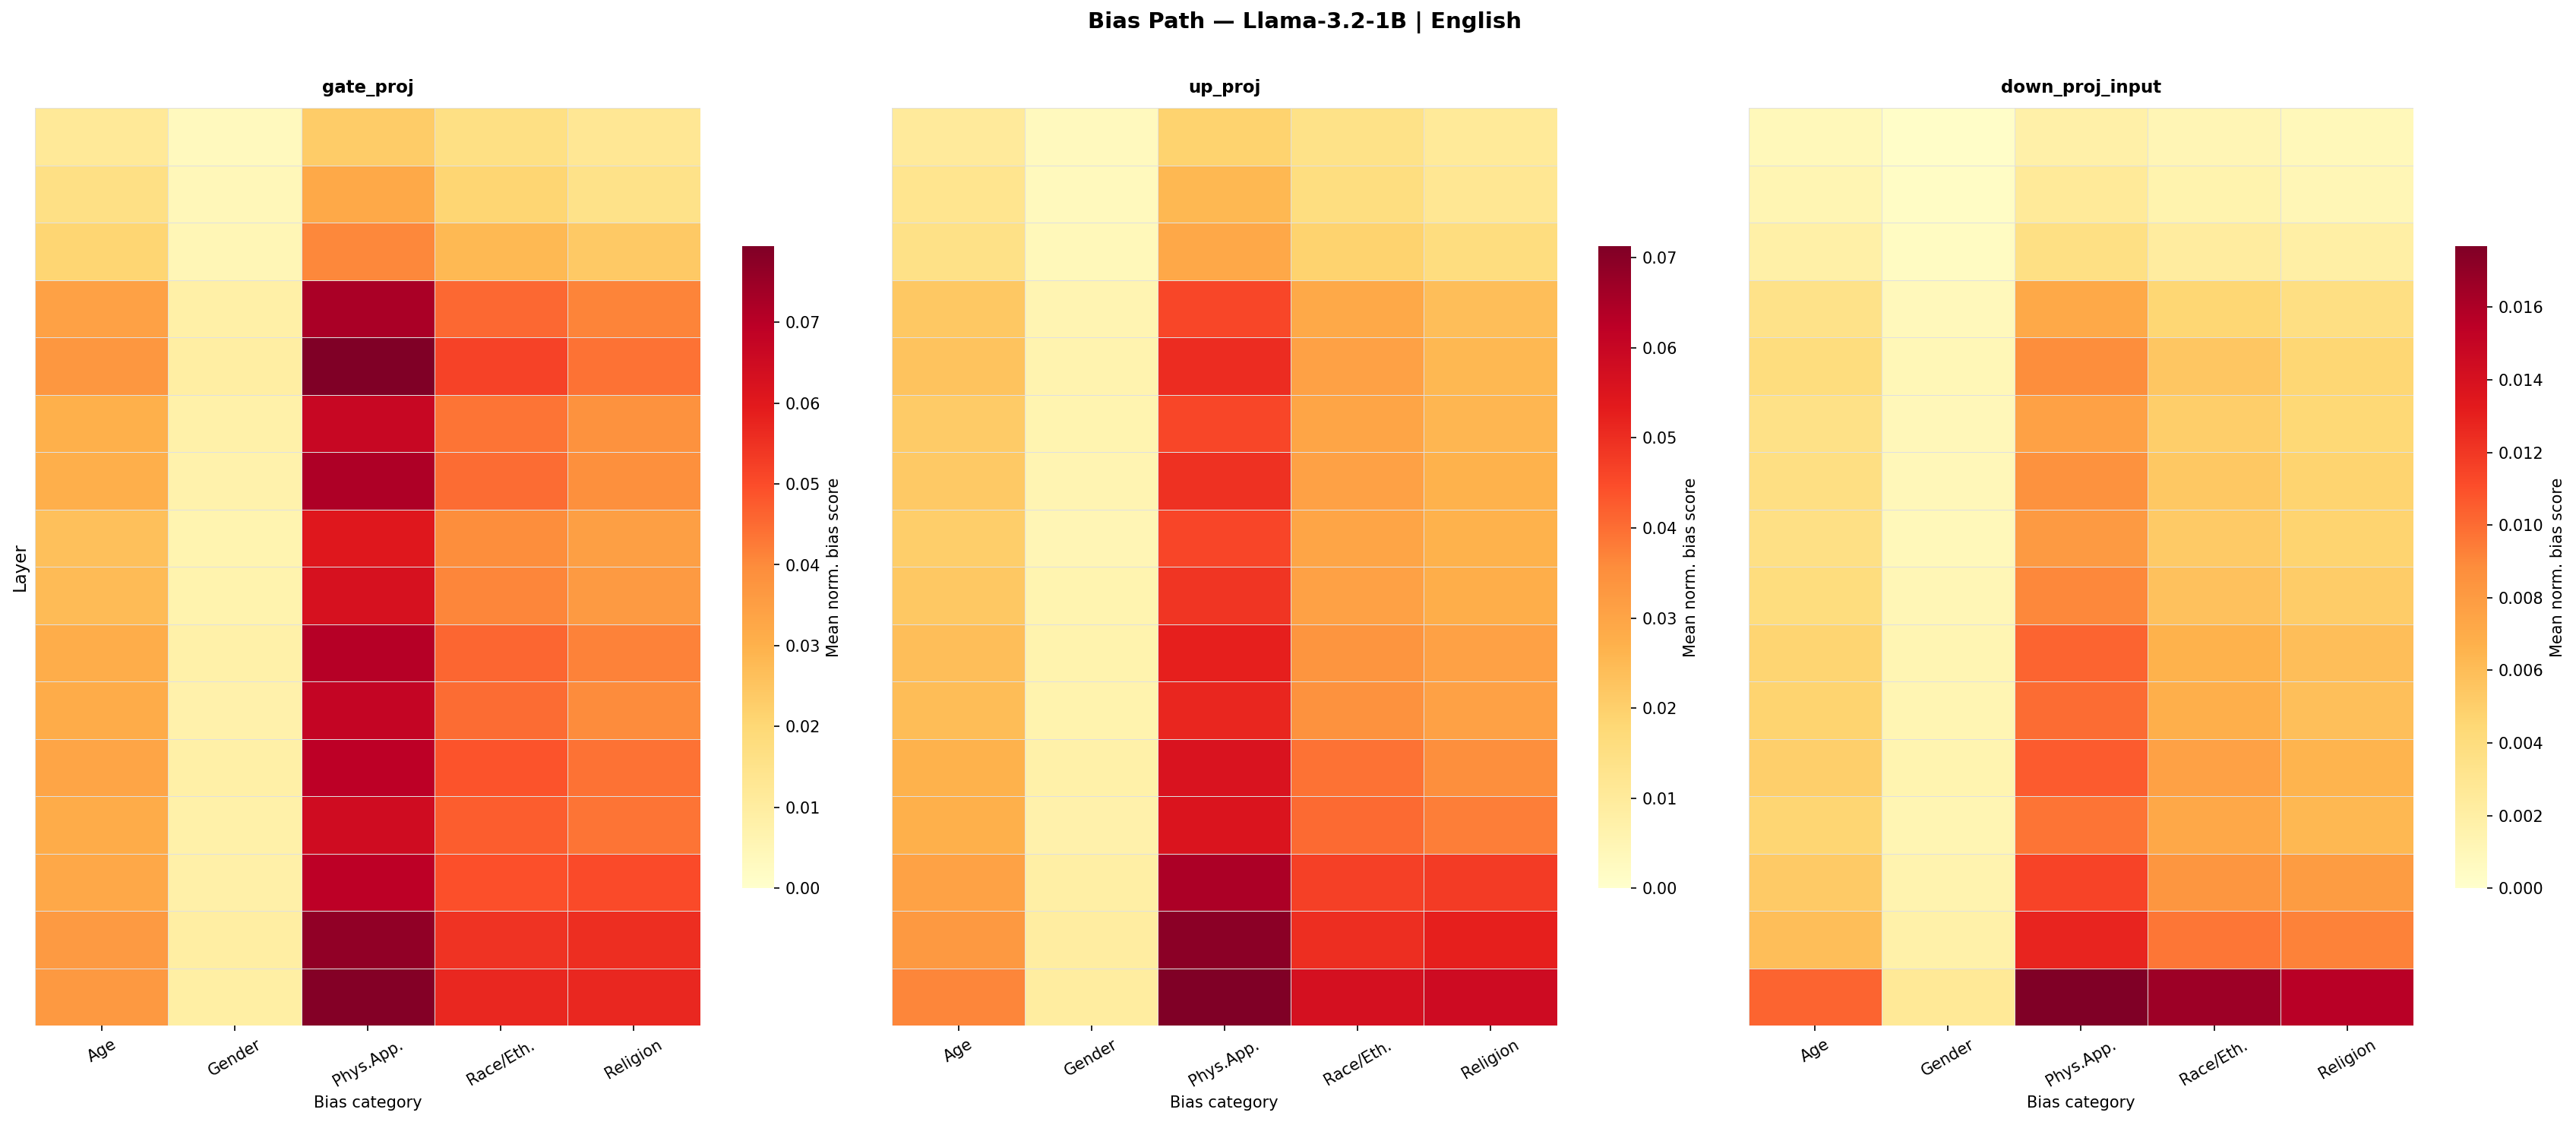

Saved: bias_path_heatmap_llama-3.2-1B_es


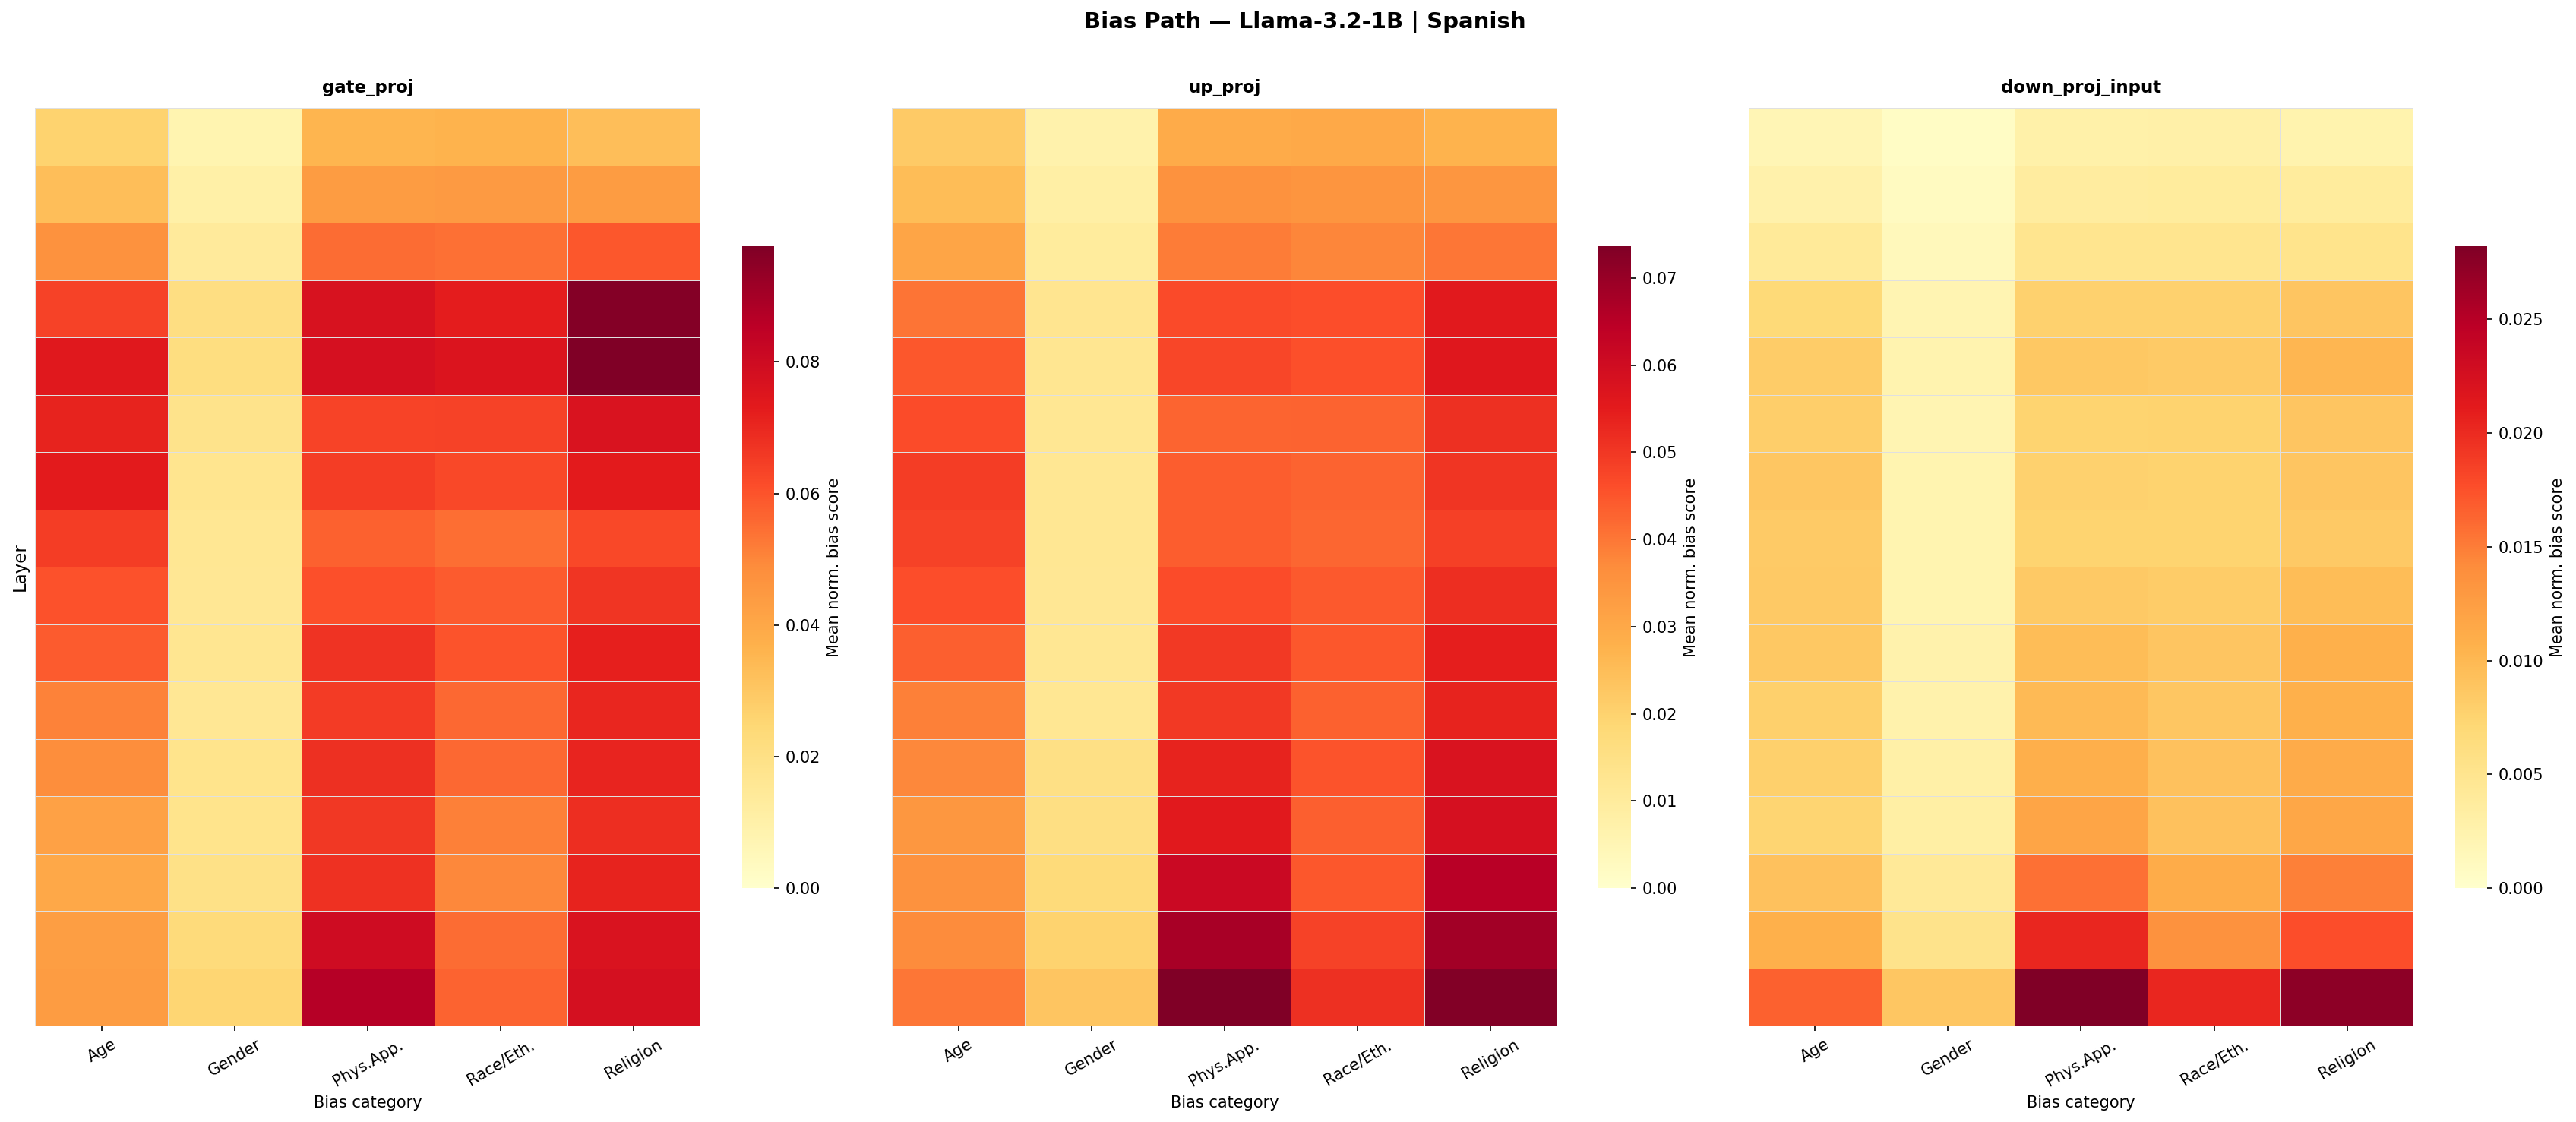

Saved: bias_path_heatmap_llama-3.2-3B_en


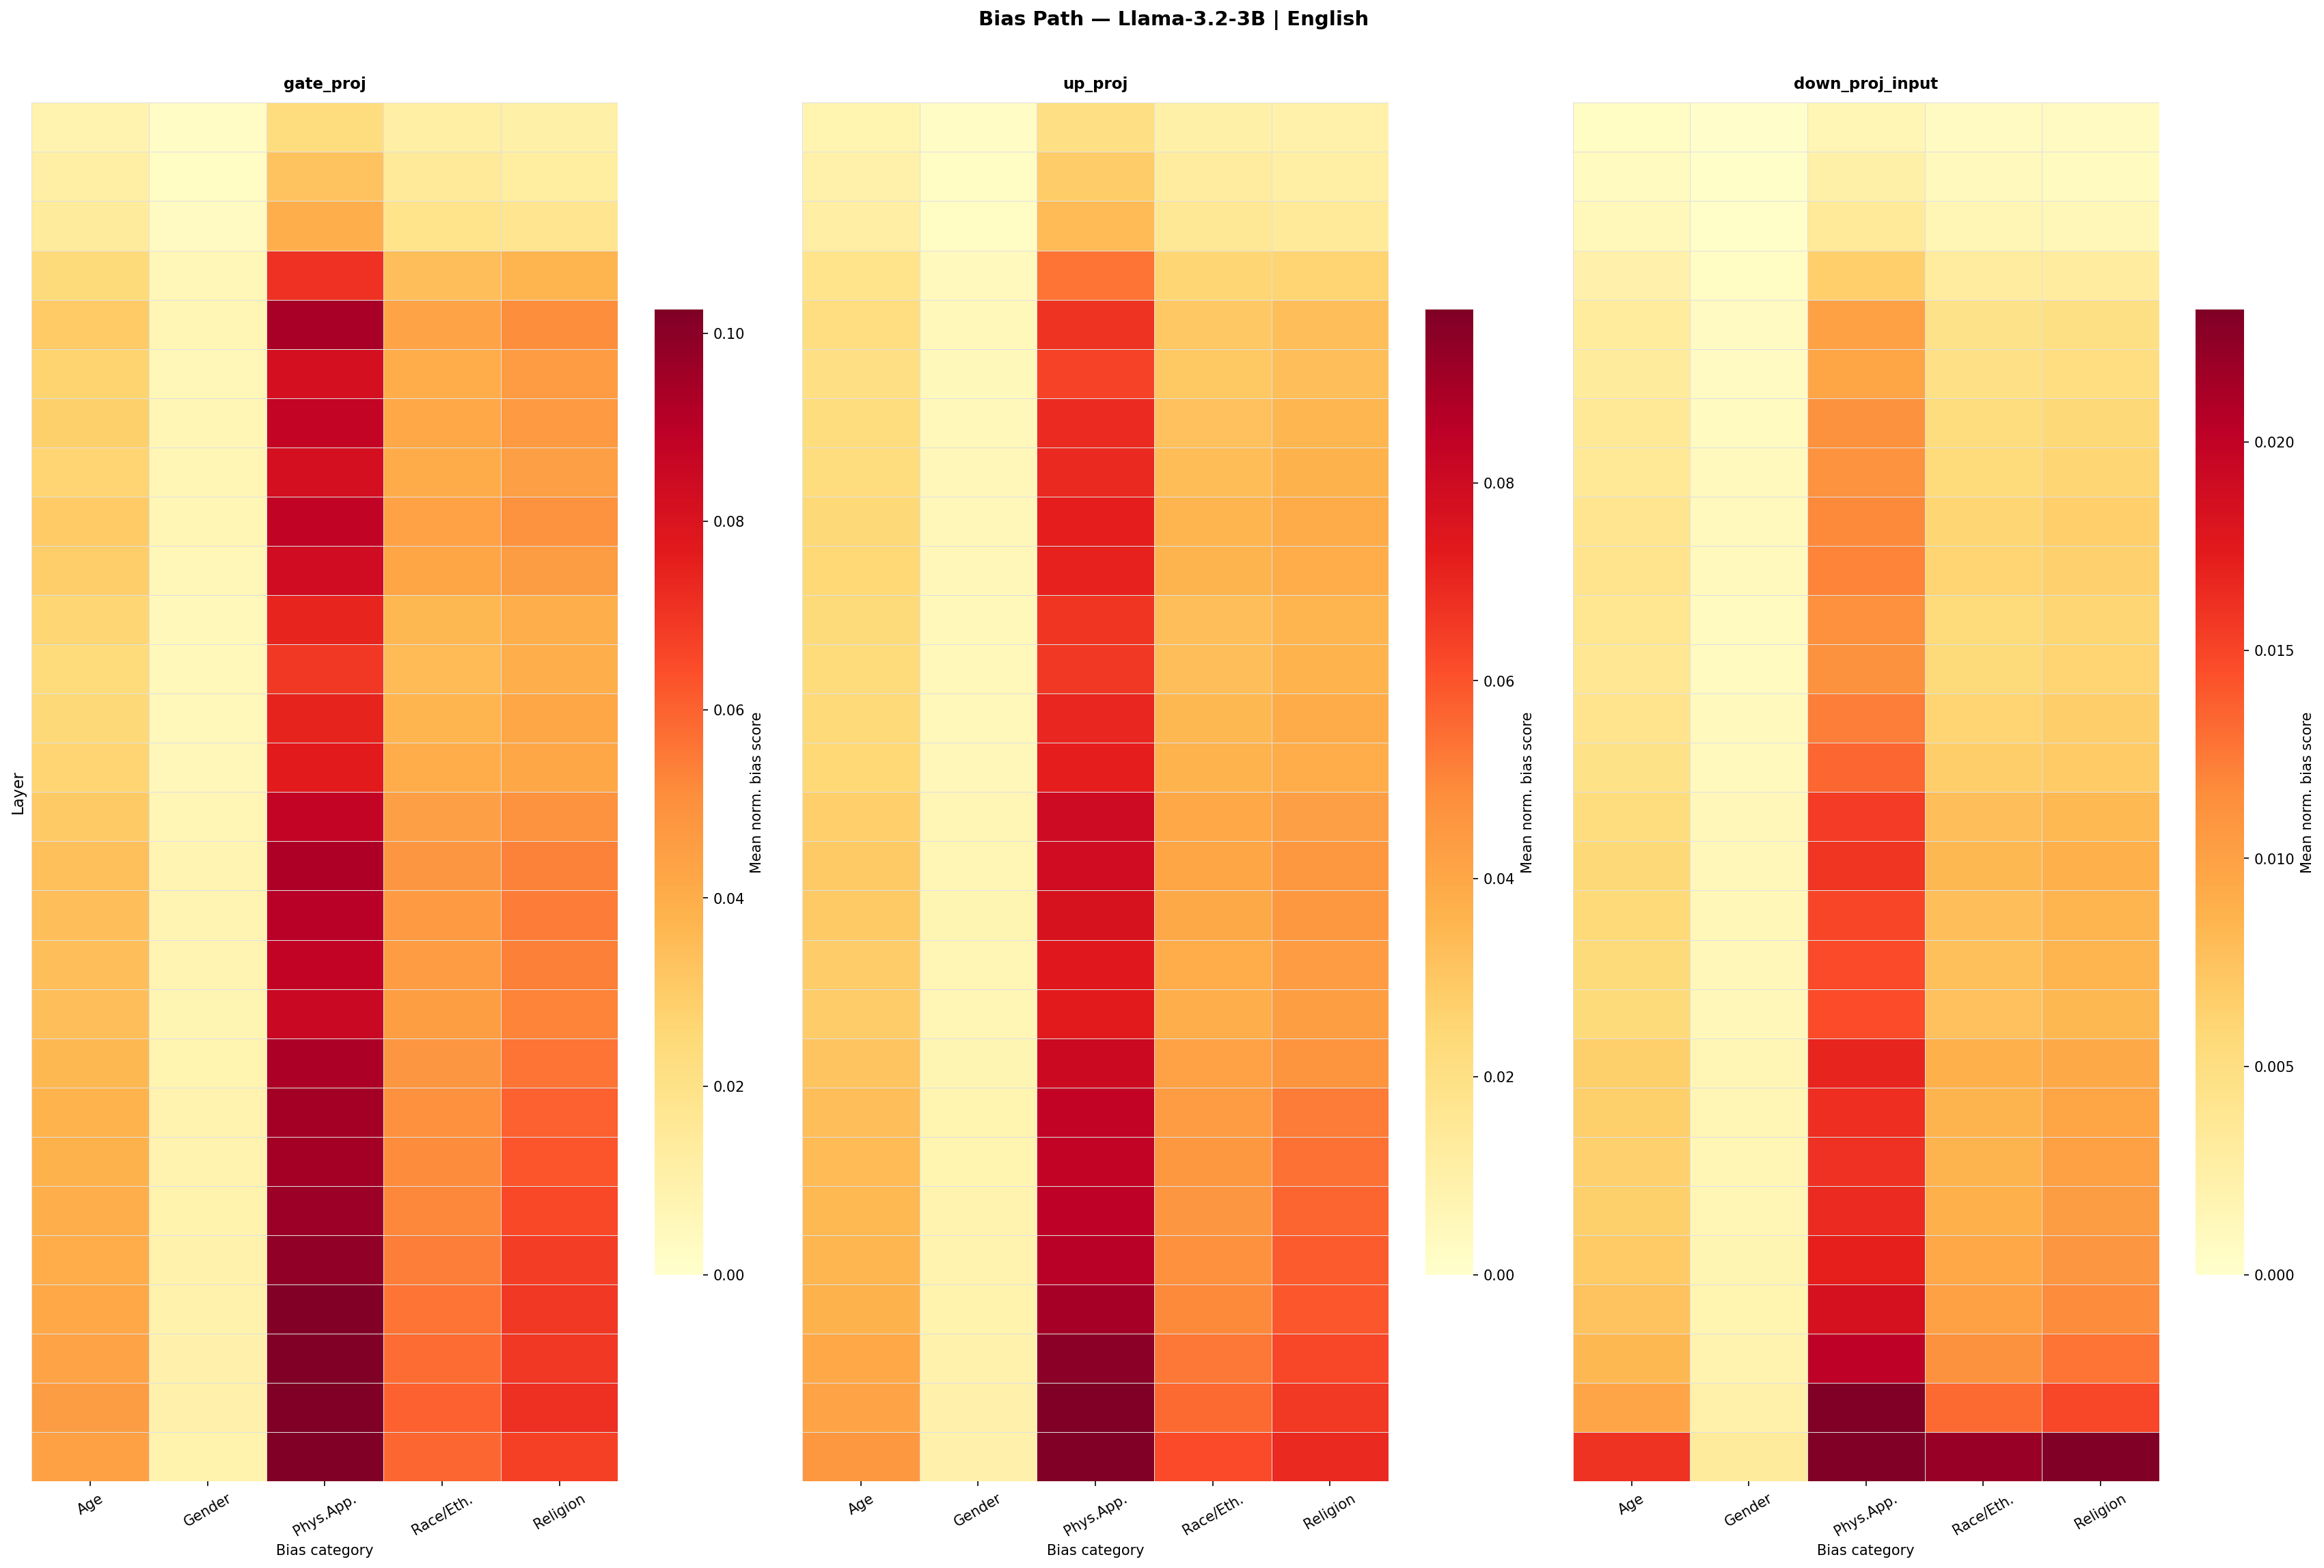

Saved: bias_path_heatmap_llama-3.2-3B_es


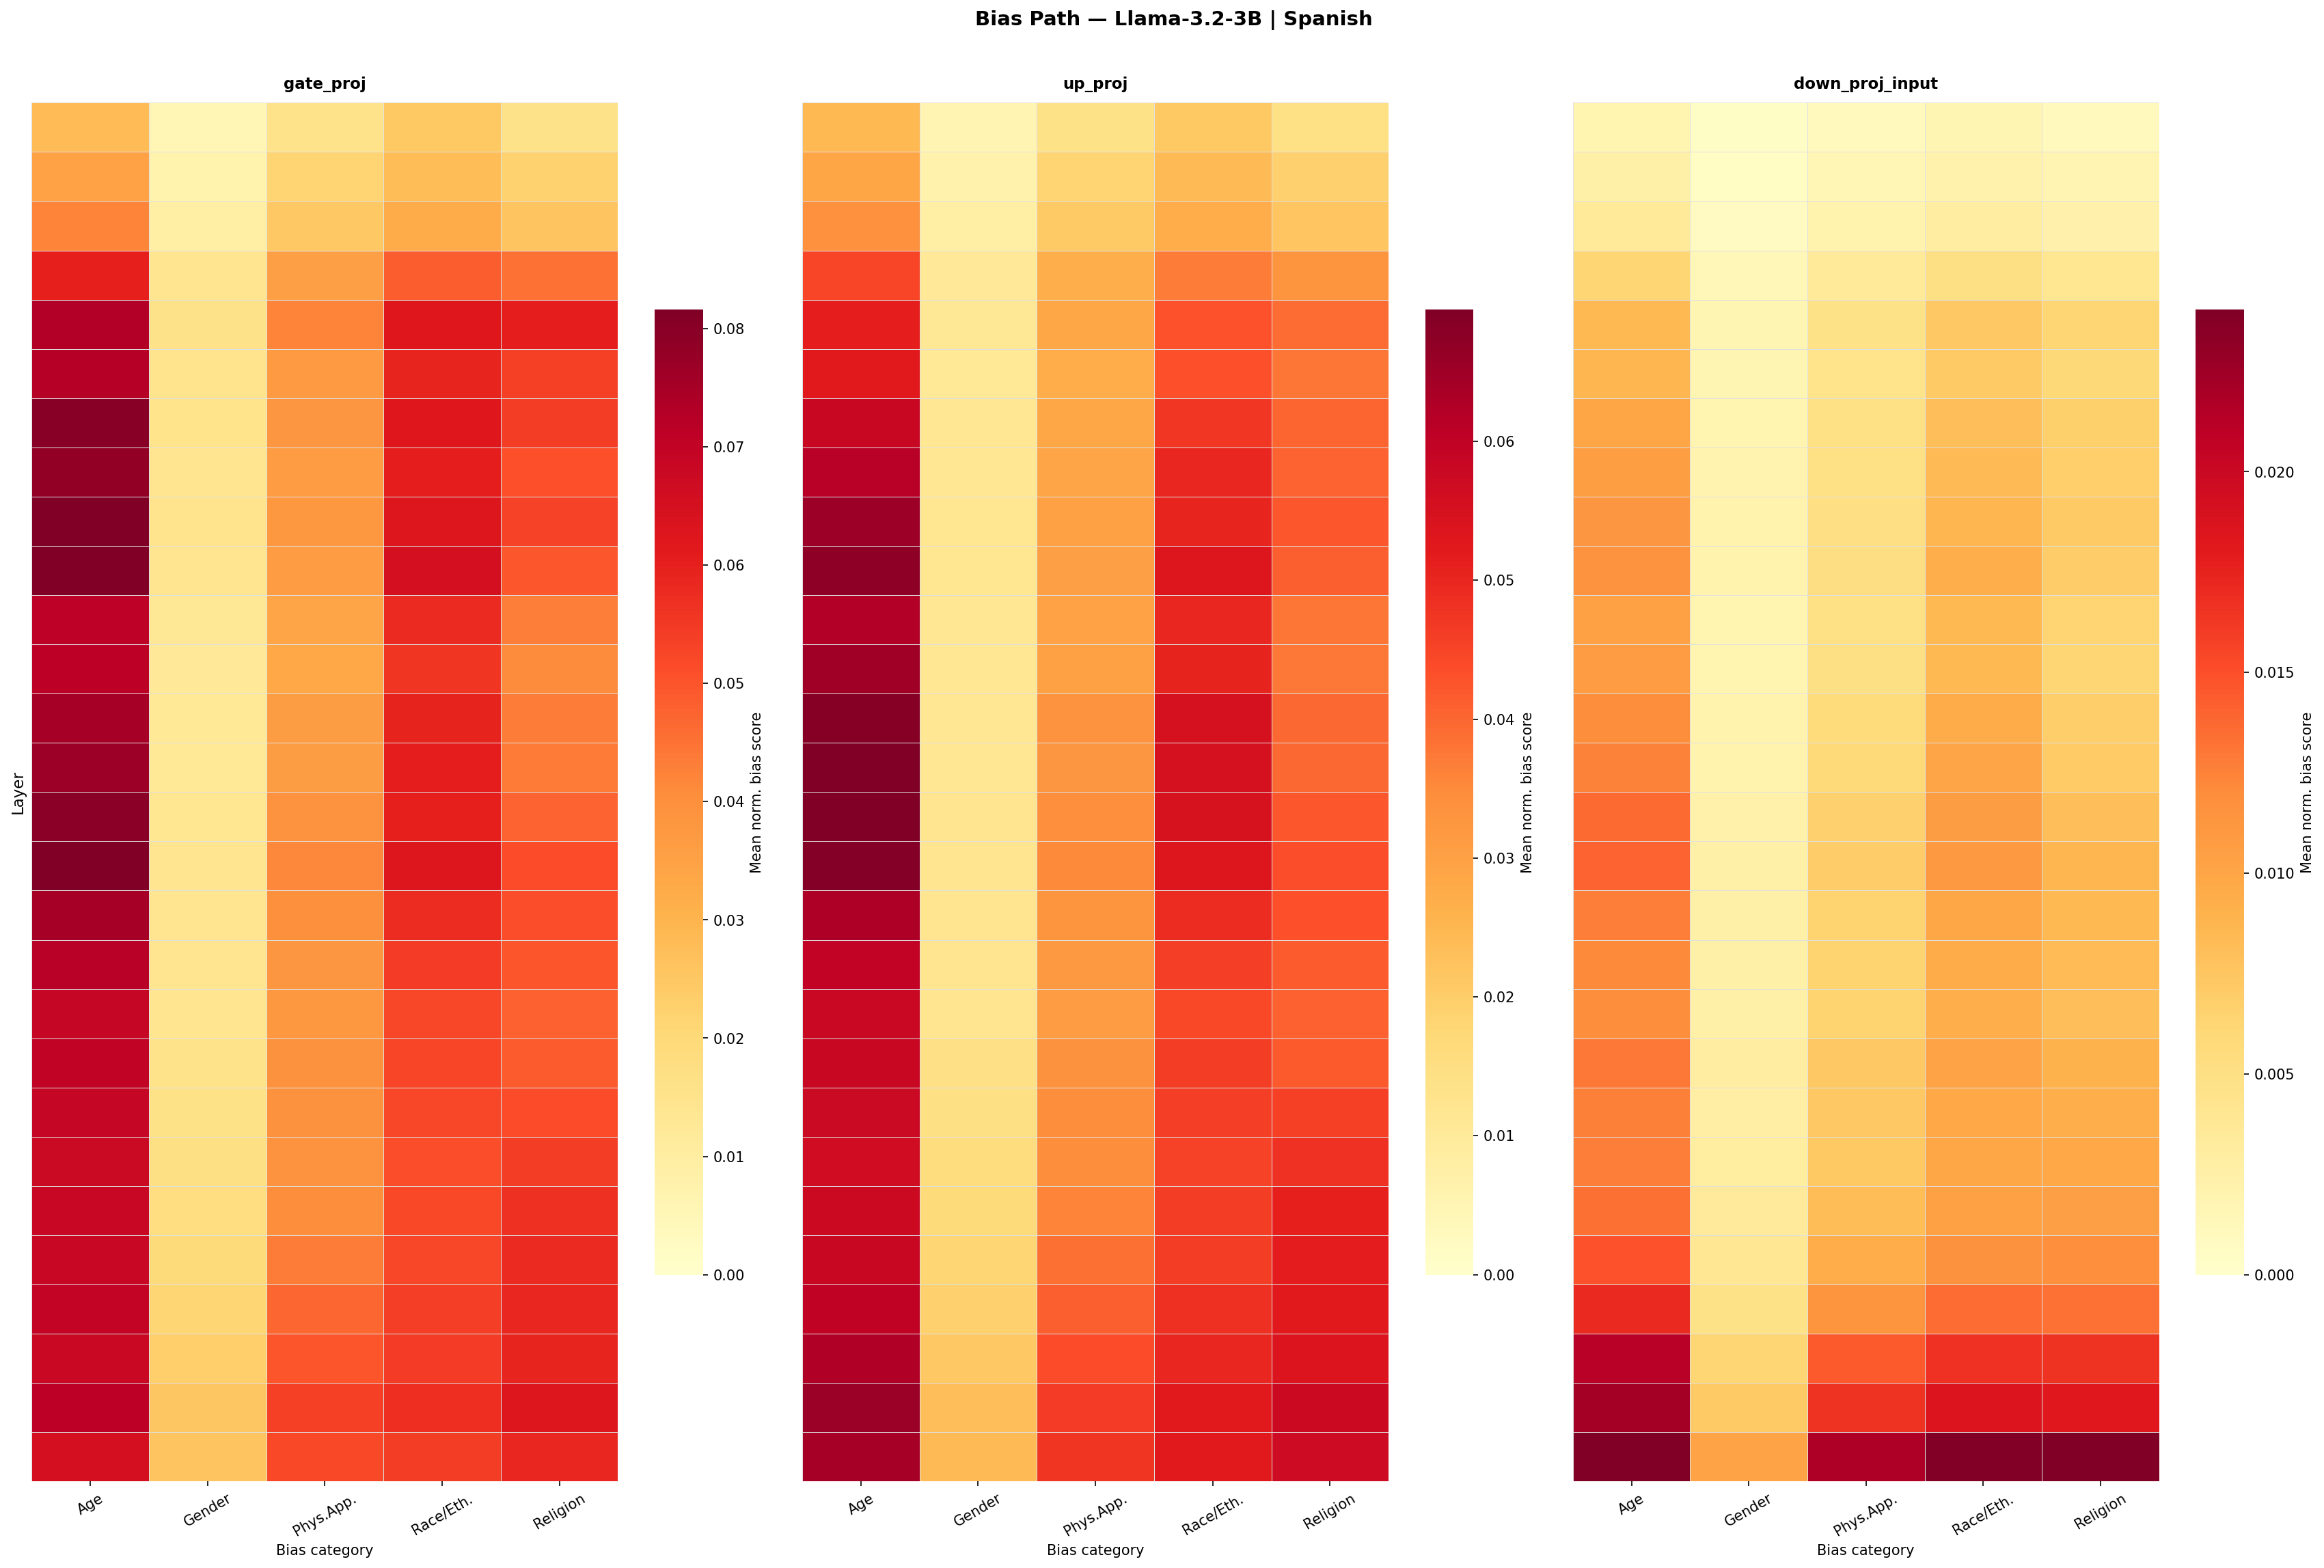

Saved: bias_path_heatmap_salamandra-2B_en


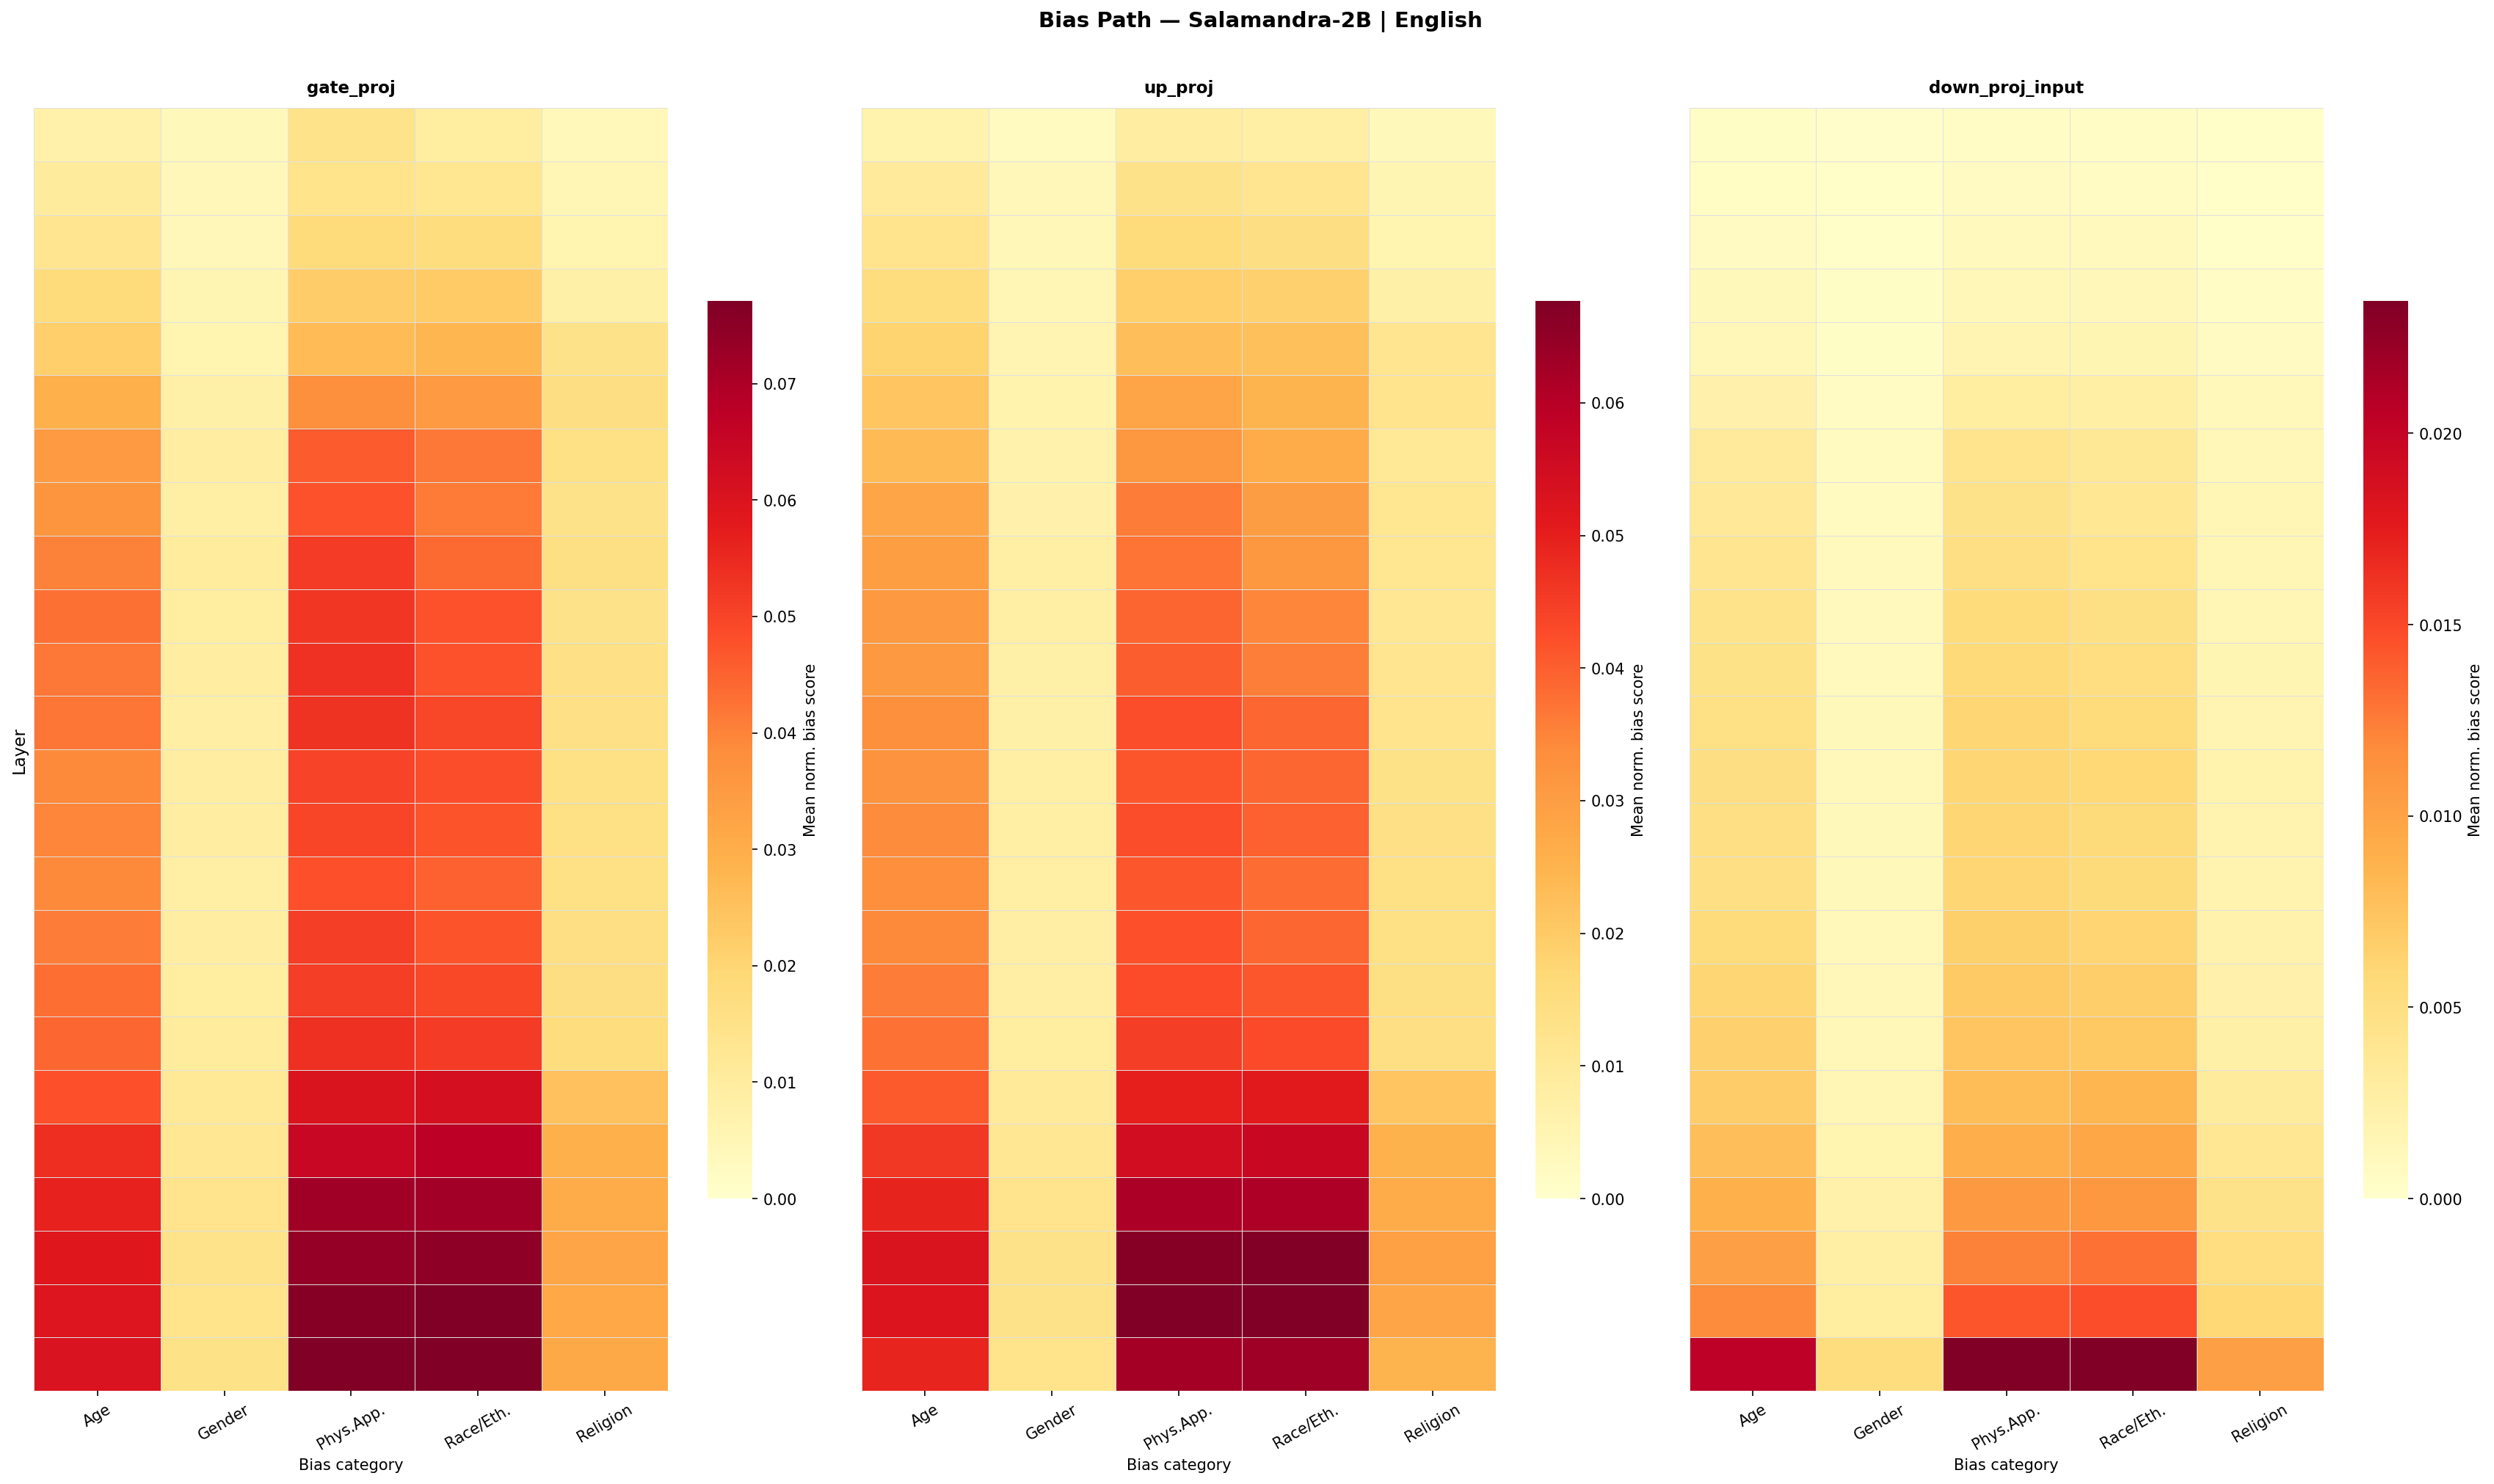

Saved: bias_path_heatmap_salamandra-2B_es


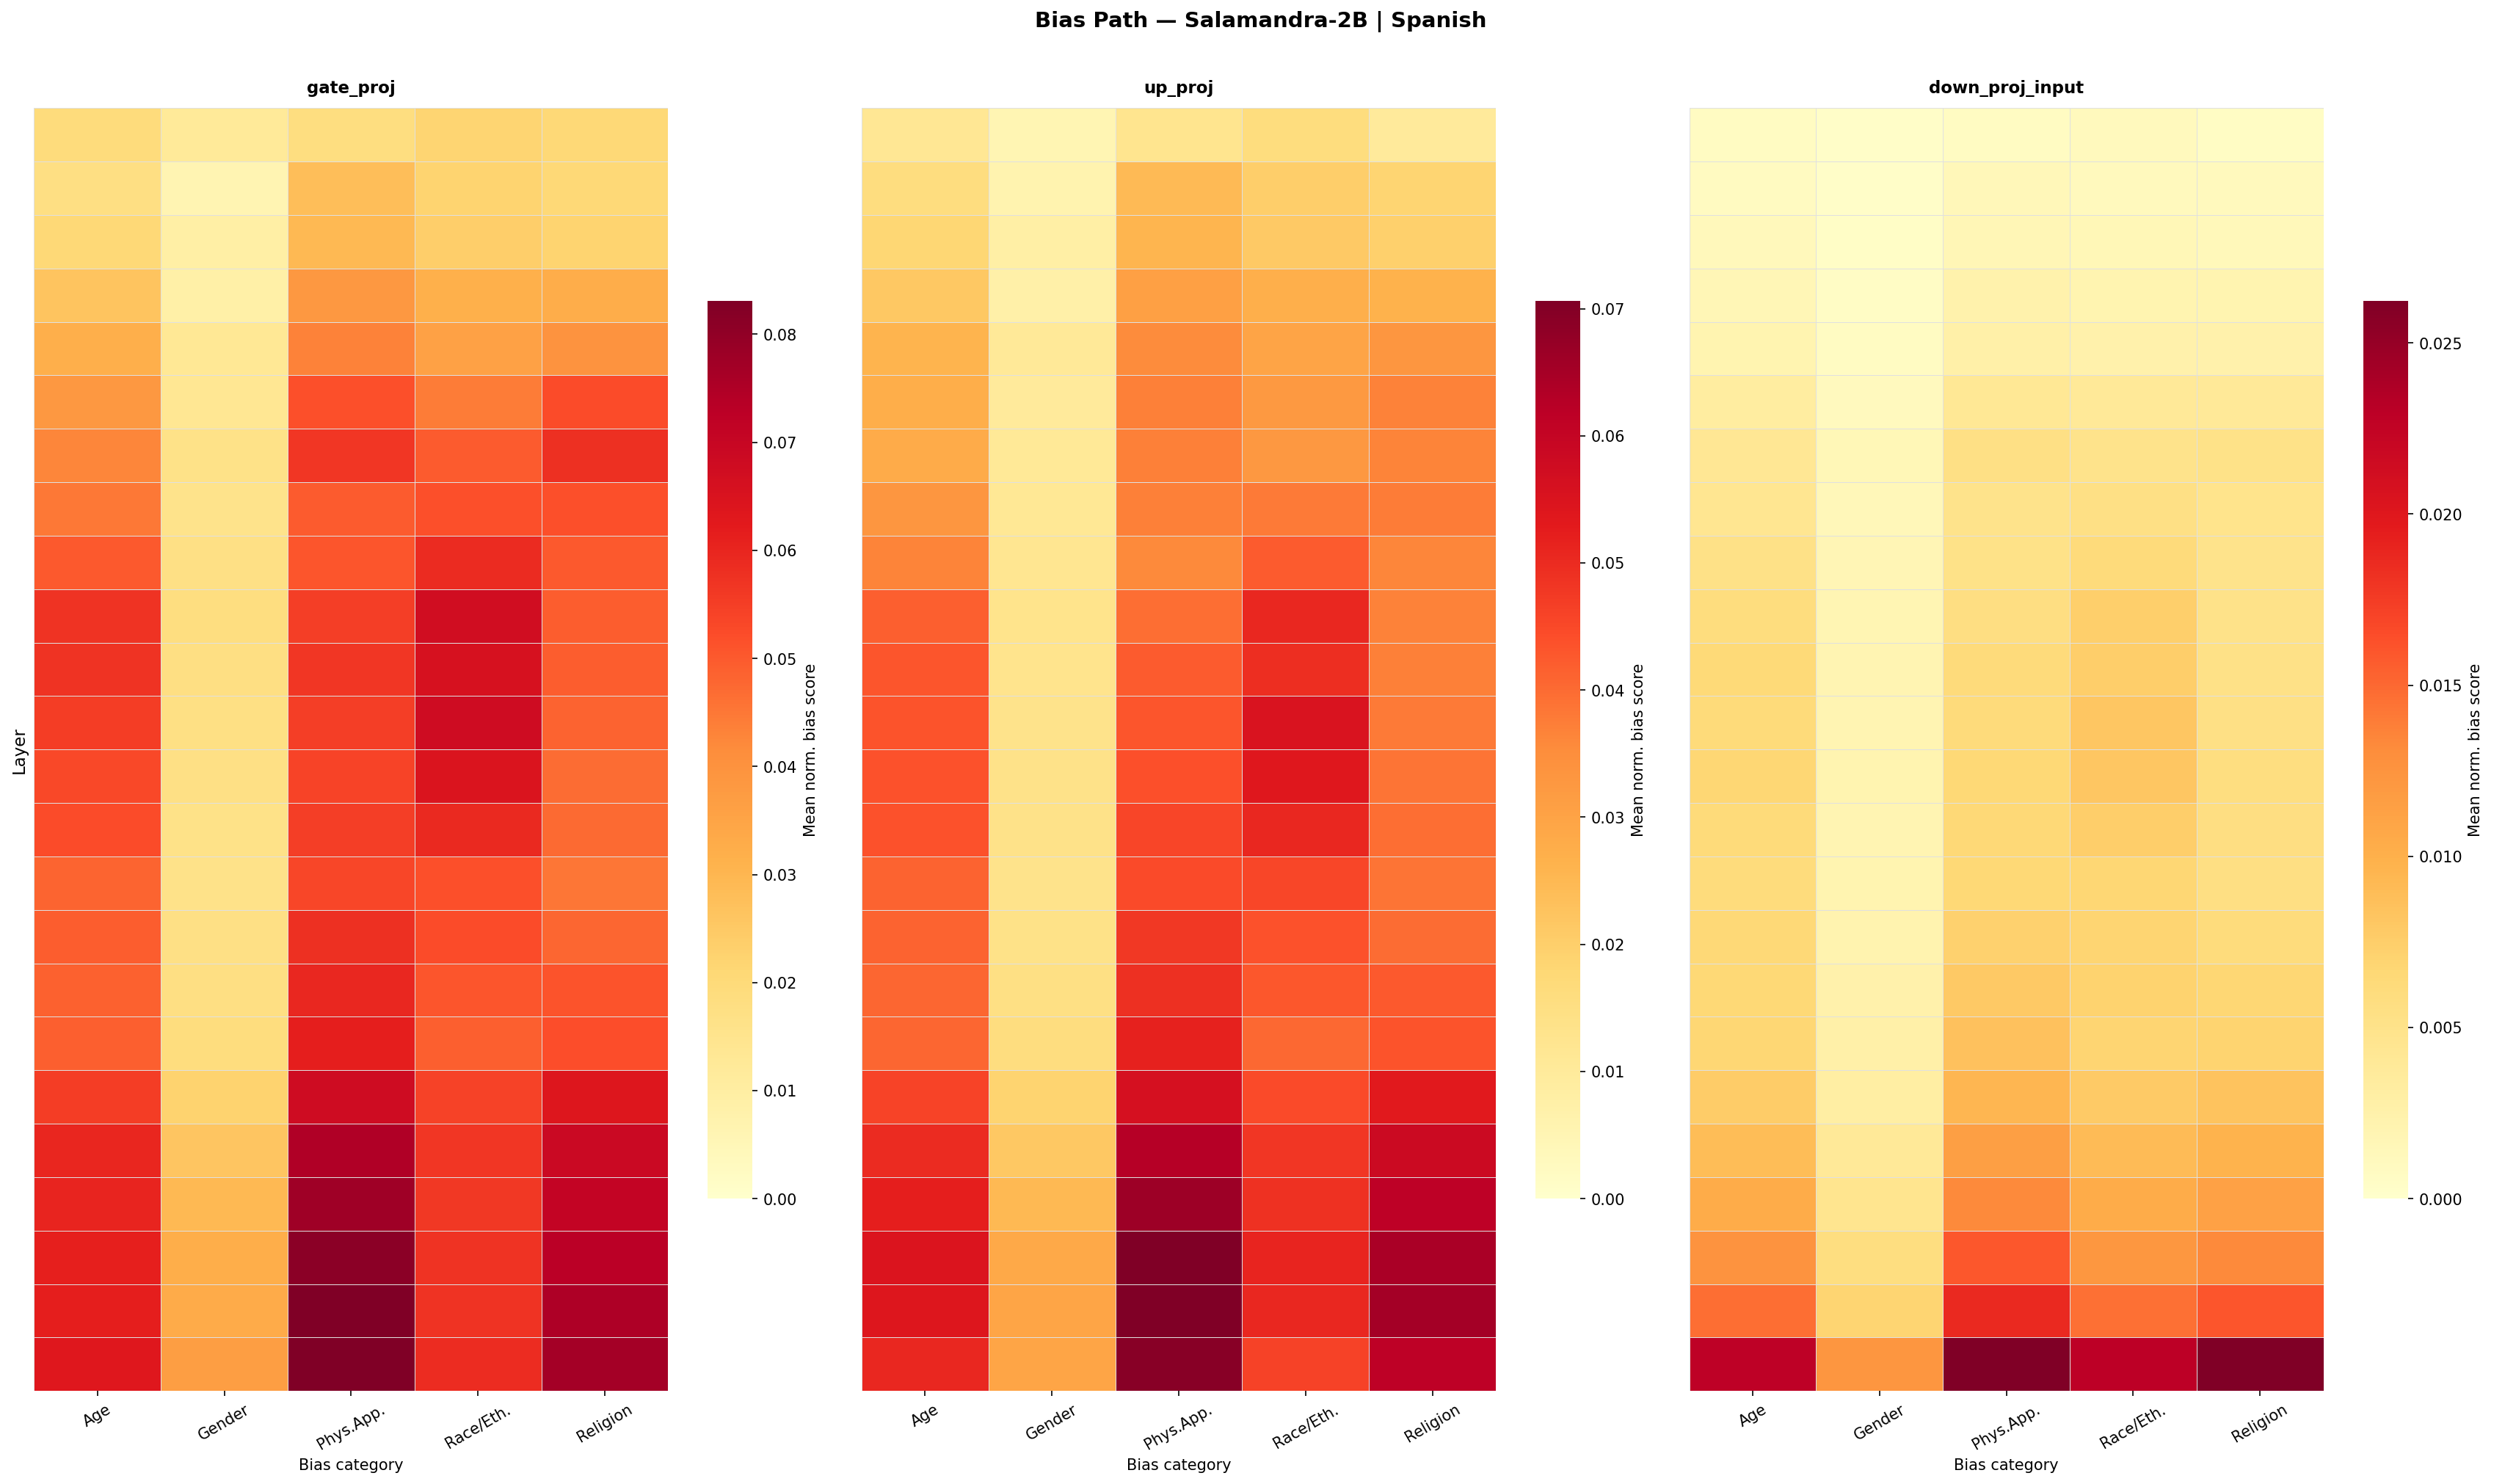

In [ ]:
# --- Generate heatmaps ---
for model_key in MODELS:
    for lang in ["en", "es"]:
        plot_bias_path_heatmap(model_key, lang)

**Utility**

Each figure presents three side-by-side heatmaps for a given model and language. Rows correspond to model layers (L0 at top, deepest layer at bottom); columns correspond to bias categories. All three panels use the same YlOrRd color scale and show mean normalized bias scores per layer: the left panel for gate_proj, the center for up_proj, and the right for down_proj_input — the activation measured at the input of the down projection, after the element-wise GLU multiplication has taken place. Unlike the previous approximation based on the product of gate and up scores, this third panel captures the actual post-GLU signal that reaches the compression step, making it the most direct available measure of which neurons carry bias into the model's residual stream.

**Interpretation**

Three patterns emerge consistently across the six figures, and one important exception breaks the consistency in a way that deserves its own mention.

The first consistent pattern is the universal weakness of Gender. Across all eighteen (model × language × projection) combinations, Gender is the category with the lowest mean normalized bias score — typically 5–8× below the dominant category of the same panel. The GLU multiplication does not change this ordering: Gender remains the weakest in down_proj_input for every model and every language, confirming that its sparse outlier-based encoding does not produce a coherent post-GLU signal.

The second pattern is the abrupt concentration of effective bias in the deepest layer. In down_proj_input, the layer carrying the maximum mean bias score is the final layer of the model — L15 for Llama-1B, L27 for Llama-3B, L23 for Salamandra-2B — for every category in every condition without exception. This is not the case in gate_proj or up_proj, where peaks frequently appear in middle layers (most strikingly in Llama-3B Spanish, where Age peaks at L8 in gate and L14 in up). The GLU multiplication is therefore acting as a sharp depth-filter: signal that builds up across many layers in the individual projections collapses into the final layer once both are combined.

The third pattern concerns PhysicalAppearance, which is the dominant category in five of the six figures — every English condition plus both Salamandra figures and Llama-1B Spanish (where it ties with Religion). In down_proj_input its lead over the runner-up category is largest in Llama-3B English (0.014 vs 0.008 for Religion, a 70% gap), more modest in Llama-1B English (0.009 vs 0.006 for RaceEthnicity), and reduces to a tie in Salamandra English (0.0066 vs 0.0064 for RaceEthnicity, a 3% gap that is operationally irrelevant). The combination of broad presence and post-GLU survival makes PhysicalAppearance the most reliable target for pruning interventions designed to generalize across architectures.

The exception is Llama-3B Spanish, which inverts the ranking that holds elsewhere. Age becomes the dominant category in all three panels (mean 0.069 / 0.058 / 0.012 in gate / up / down) and PhysicalAppearance falls to fourth position. This is not a marginal reordering: Age's signal in gate_proj reaches 0.083 at L8 — comparable in magnitude to PhysicalAppearance's peak in Llama-3B English, but in a different category and at a substantially shallower layer. The pattern persists into down_proj_input, where Age remains dominant at L27. No other (model × language) combination shows anything similar, and the effect does not appear in Llama-1B Spanish, suggesting it is specific to the larger model's interaction with Spanish prompts rather than a general property of the language. This is a finding worth flagging explicitly in the paper, both because it weakens any claim of universal category ordering and because it has direct implications for pruning: a Llama-3B model intended for Spanish use would need to prioritize Age neurons in a way that the English-trained pipeline would never select.

A secondary cross-lingual observation deserves mention: Religion's mean bias score in Llama-1B more than doubles from English to Spanish (0.039 → 0.070 in gate_proj, 0.006 → 0.011 in down_proj_input), making Spanish the language where Religion comes closest to displacing PhysicalAppearance as the dominant category. The pattern is consistent with the elevated max scores noted in Sprint 1 and points to a robust language-conditioned amplification of religious-attribute encoding in this family of models.



### 2.2 Combined heatmap: 1B vs 3B vs Salamandra side by side (gate_proj, EN)

This is the key figure for cross-model visual comparison (RQ1).

In [ ]:
def plot_model_comparison_heatmap(lang, projection, n_bins=16, save=True):
    """
    Side-by-side Layer × Category heatmap for Llama-1B and Llama-3B.

    Y axis uses relative depth (0% = input layer, 100% = output layer)
    so both models are directly comparable regardless of layer count.

    Parameters
    ----------
    lang       : str — "en" or "es"
    projection : str — "gate_proj" or "up_proj"
    n_bins     : int — number of depth bins (default 16, matches 1B layer count)
    save       : bool — export PNG + PDF at 300 dpi
    """
    categories  = CATEGORIES_BY_LANG[lang]
    col_labels  = [CATEGORY_LABELS[c] for c in categories]
    lang_label  = "English" if lang == "en" else "Spanish"

    # Shared color scale across both panels
    global_max = 0.0
    for model_key, model_cfg in MODELS.items():
        n_layers = model_cfg["n_layers"]
        data_norm = bias_data_norm[model_key][lang]
        for category in categories:
            if category not in data_norm:
                continue
            for layer_idx in range(n_layers):
                layer_name = f"{projection}_layer_{layer_idx}"
                if layer_name in data_norm[category]:
                    global_max = max(global_max, data_norm[category][layer_name].mean())

    n_models = len(MODELS)
    fig, axes = plt.subplots(
        1, n_models,
        figsize=(len(categories) * 2.8 * n_models + 2, n_bins * 0.55 + 2.5),
        sharey=True
    )
    fig.patch.set_facecolor("white")

    # Y-axis tick labels: relative depth percentages
    pct_labels = [f"{int(round(100 * b / (n_bins - 1)))}%" for b in range(n_bins)]

    for ax, model_key in zip(axes, MODELS):
        model_cfg  = MODELS[model_key]
        n_layers   = model_cfg["n_layers"]
        model_label = model_cfg["label"]
        data_norm  = bias_data_norm[model_key][lang]

        # Build raw matrix (n_layers × n_categories)
        raw_matrix = build_layer_category_matrix(
            data_norm, categories, n_layers, projection
        )

        # Bin into n_bins rows using equal-width layer groups
        binned = np.zeros((n_bins, len(categories)))
        bin_edges = np.linspace(0, n_layers, n_bins + 1).astype(int)
        for b in range(n_bins):
            start, end = bin_edges[b], bin_edges[b + 1]
            if end > start:
                binned[b] = raw_matrix[start:end].mean(axis=0)

        sns.heatmap(
            binned,
            ax=ax,
            cmap="YlOrRd",
            xticklabels=col_labels,
            yticklabels=pct_labels,
            linewidths=0.4,
            linecolor="#e0e0e0",
            vmin=0,
            vmax=global_max,
            cbar_kws={"label": "Mean norm. bias score", "shrink": 0.6},
        )

        ax.set_title(
            f"{model_label} | {lang_label} | {projection}",
            fontsize=12, fontweight="bold"
        )
        ax.set_xlabel("Bias category", fontsize=10)
        ax.set_ylabel("Relative depth", fontsize=10)
        ax.tick_params(axis="x", rotation=30)
        ax.tick_params(axis="y", rotation=0)

    plt.suptitle(
        f"Bias Path Comparison — {lang_label} | {projection}",
        fontsize=14, fontweight="bold", y=1.02
    )
    plt.tight_layout()

    if save:
        stem = f"bias_path_comparison_{lang}_{projection}"
        for ext in ["png", "pdf"]:
            fpath = FIGURES_DIR / f"{stem}.{ext}"
            plt.savefig(fpath, bbox_inches="tight", dpi=300)
        print(f"Saved: {stem}")

    plt.show()


In [11]:
import pandas as pd

N_BINS = 16
rows = []

for lang in ["en", "es"]:
    for model_key in MODELS:
        model_cfg = MODELS[model_key]
        n_layers = model_cfg["n_layers"]
        data_norm = bias_data_norm[model_key][lang]
        categories = CATEGORIES_BY_LANG[lang]

        # Build raw matrix (n_layers × n_categories)
        raw_matrix = build_layer_category_matrix(
            data_norm, categories, n_layers, "down_proj_input"
        )

        # Bin into N_BINS rows using equal-width layer groups
        bin_edges = np.linspace(0, n_layers, N_BINS + 1).astype(int)
        for b in range(N_BINS):
            start, end = bin_edges[b], bin_edges[b + 1]
            if end > start:
                bin_means = raw_matrix[start:end].mean(axis=0)
                depth_pct = int(round(100 * b / (N_BINS - 1)))
                for cat_idx, cat in enumerate(categories):
                    rows.append({
                        "lang": lang,
                        "model": model_key,
                        "depth_pct": depth_pct,
                        "bin_idx": b,
                        "category": cat,
                        "value": round(bin_means[cat_idx], 5),
                    })

df = pd.DataFrame(rows)

# Print one block per (lang, model) showing the binned matrix
for (lang, model_key), grp in df.groupby(["lang", "model"]):
    print(f"\n--- {model_key} | {lang} | down_proj_input | binned ---")
    pivot = grp.pivot(index="depth_pct", columns="category", values="value")
    # Reorder columns to canonical order
    cat_order = CATEGORIES_BY_LANG[lang]
    pivot = pivot[cat_order]
    print(pivot.to_string())

# Print signal concentrat


--- llama-3.2-1B | en | down_proj_input | binned ---
category       Age   Gender  PhysicalAppearance  RaceEthnicity  Religion
depth_pct                                                               
0          0.00094  0.00027             0.00182        0.00122   0.00096
7          0.00129  0.00035             0.00261        0.00157   0.00114
13         0.00187  0.00049             0.00373        0.00234   0.00194
20         0.00339  0.00089             0.00713        0.00451   0.00377
27         0.00406  0.00108             0.00883        0.00548   0.00451
33         0.00357  0.00101             0.00766        0.00509   0.00443
40         0.00376  0.00100             0.00853        0.00540   0.00474
47         0.00361  0.00092             0.00805        0.00529   0.00472
53         0.00408  0.00111             0.00901        0.00575   0.00512
60         0.00468  0.00126             0.01023        0.00667   0.00599
67         0.00475  0.00128             0.01001        0.00680   0.005

Saved: bias_path_comparison_en_down_proj_input


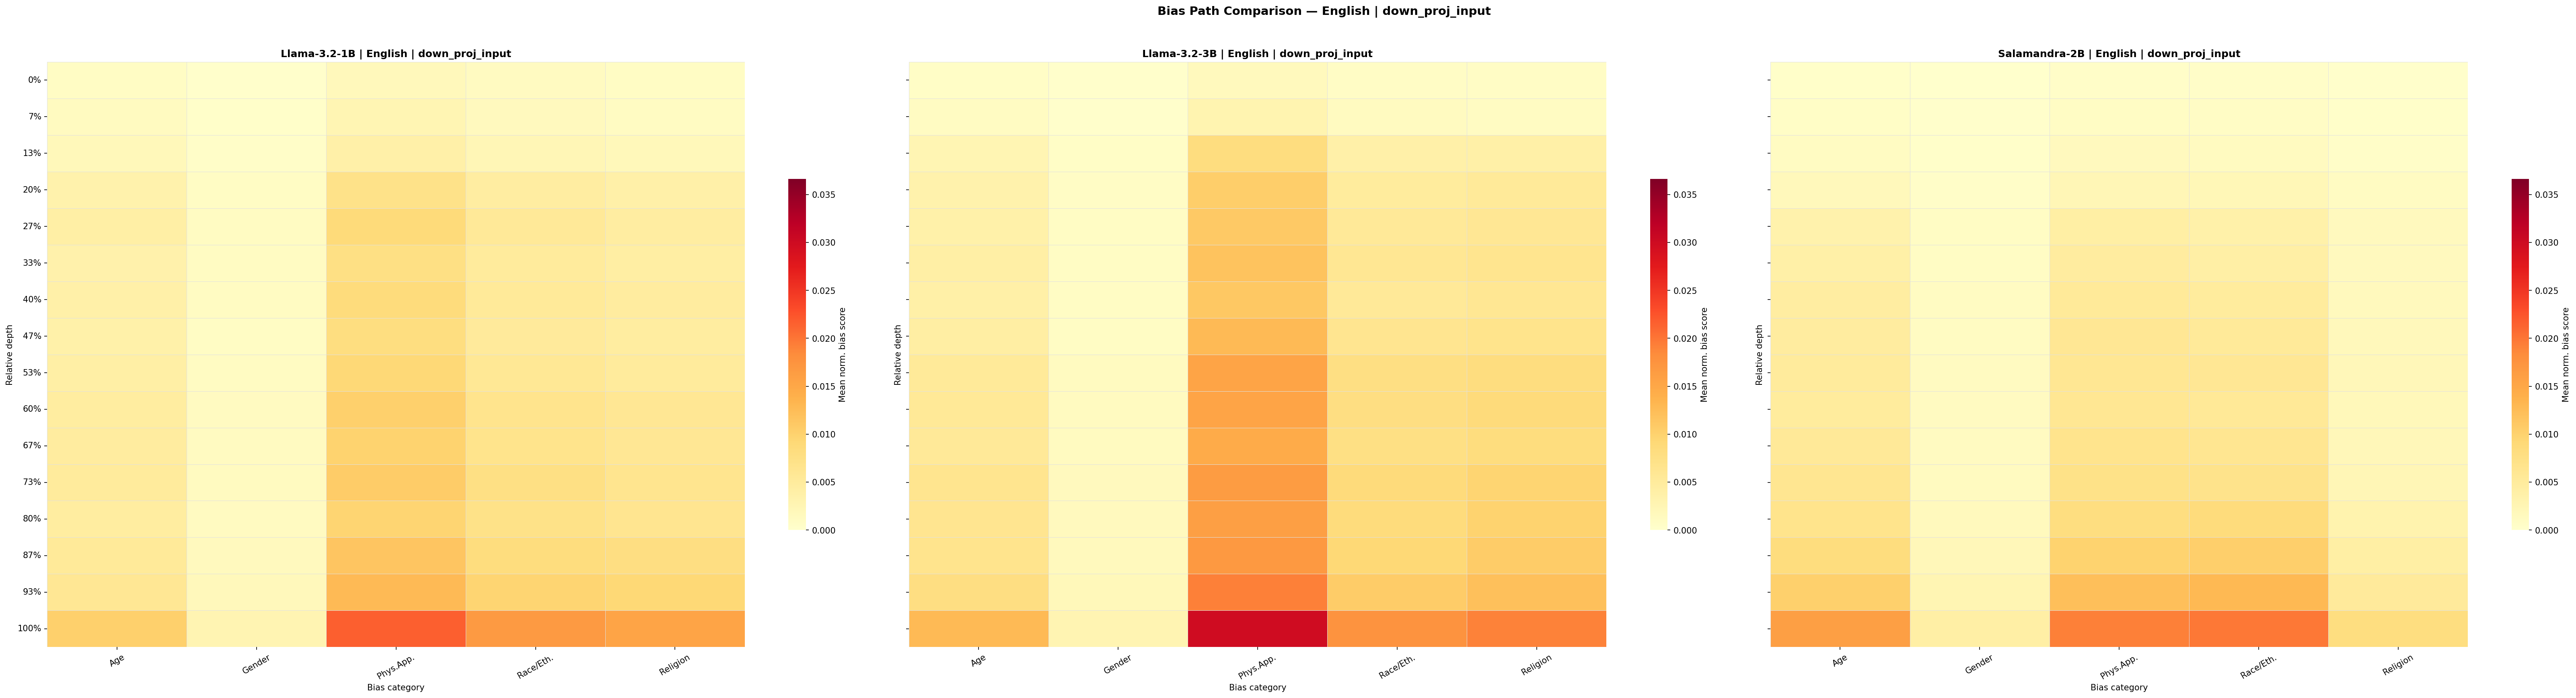

Saved: bias_path_comparison_es_down_proj_input


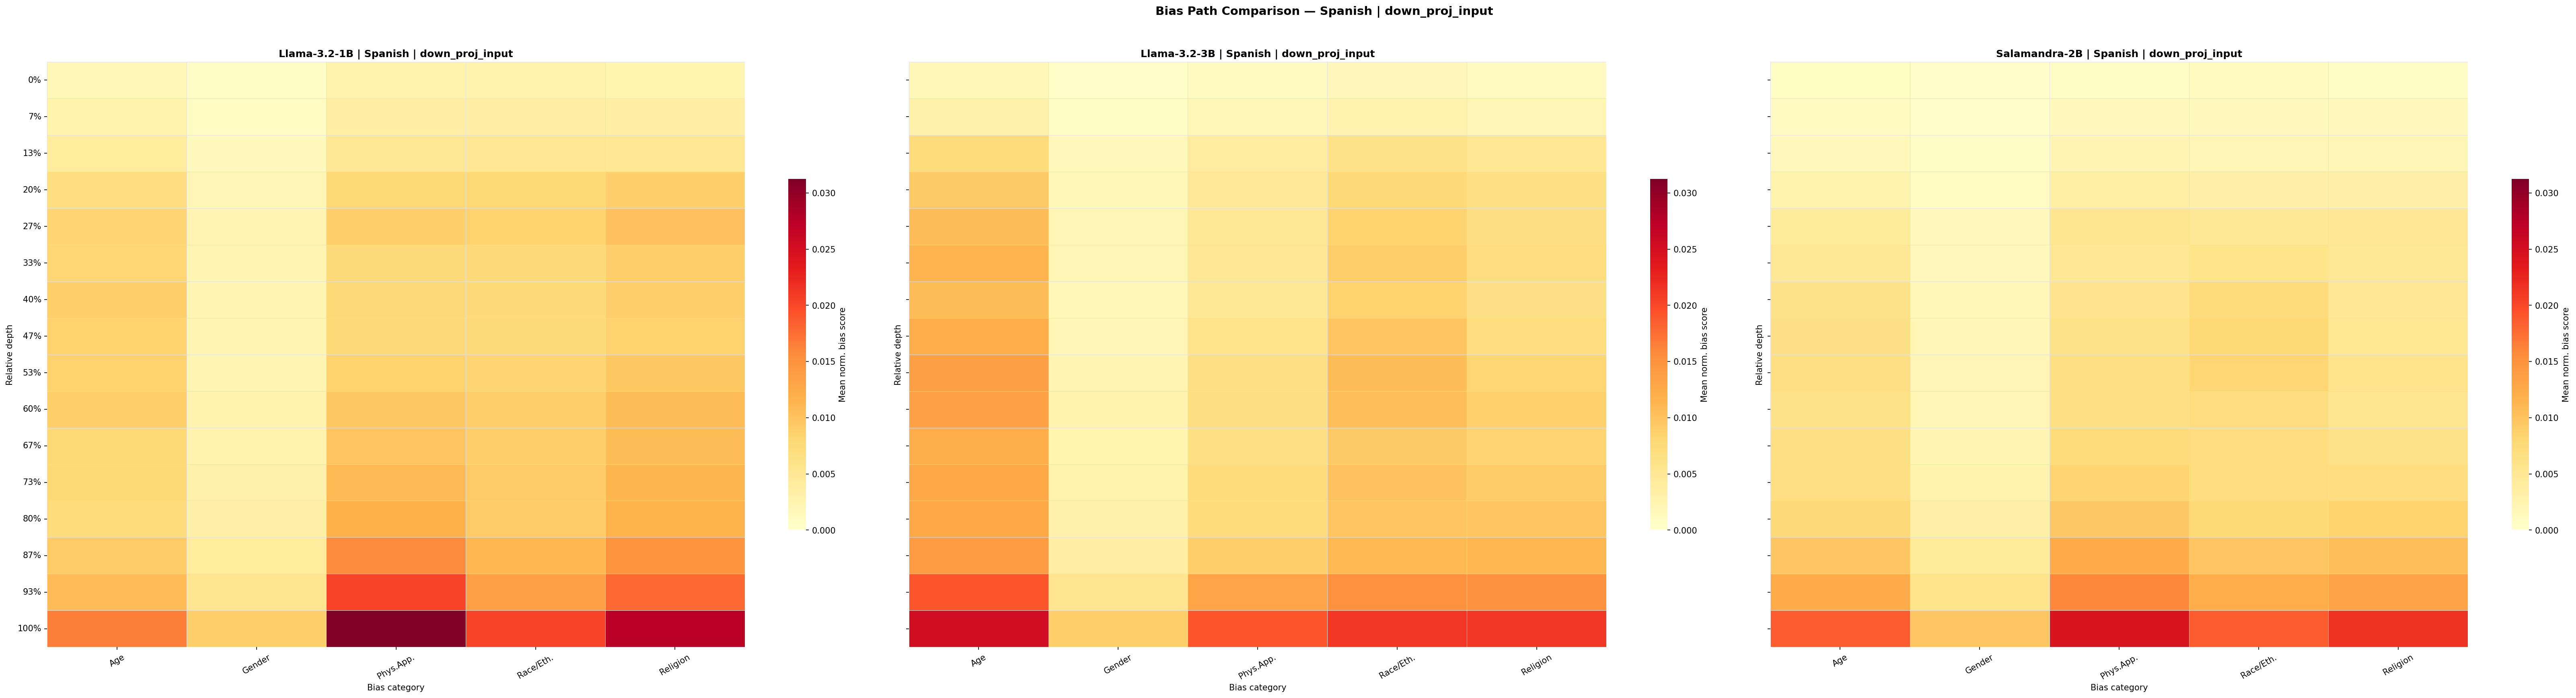

In [ ]:
# --- Generate updated comparison heatmaps ---
for lang in ["en", "es"]:
    for projection in PROJECTIONS_COMPARISON:
        plot_model_comparison_heatmap(lang, projection)

In [ ]:
print(bias_data_norm.keys())
print(bias_data_norm["salamandra-2B"].keys())

dict_keys(['llama-3.2-1B', 'llama-3.2-3B', 'salamandra-2B'])
dict_keys(['en', 'es'])


**Utility**

These two comparison figures show the down_proj_input bias path simultaneously for all three models and both languages, using a shared color scale and a relative depth axis (0% = input layer, 100% = output layer). Showing only down_proj_input — the actual post-GLU signal entering the residual stream — rather than gate and up separately removes the approximation introduced by the previous combined panel and provides a single, directly interpretable view of where effective bias is concentrated across architectures.

Placing the three models side by side on a common depth scale allows visual comparison regardless of absolute layer count.

**Interpretation**

The English and Spanish comparison figures tell two qualitatively different stories about how bias is distributed across model depth.

The English figures show progressive accumulation. Signal builds up gradually from around 20% relative depth and intensifies steadily until the final layer. The last bin carries roughly 15-19% of each category's total mass across all three models, and the last two bins together carry 25-30%. The remaining 70-75% is distributed across the bulk of the model rather than concentrated at the bottom. This contradicts a strict "deep-layer localization" reading: bias is strongest in the deepest layers but is far from absent above 80% depth.

The Spanish figures show the same shape only in Llama-1B and Salamandra-2B, with PhysicalAppearance and Religion now sharing dominance in Llama-1B (peaks of 0.031 and 0.027 in the final bin) and PhysicalAppearance reaching its highest cross-figure value of 0.031 — actually exceeding the equivalent English peak of 0.022. Llama-1B Spanish is the only condition where the 1B model produces a stronger absolute signal than the 3B in the same category.
Llama-3B Spanish breaks the pattern entirely. Age is the dominant category from 13% relative depth onwards and maintains the lead until the final bin (0.025). The signal is not concentrated at the bottom: the last bin carries only 11% of Age's total mass — the lowest concentration figure observed in the entire analysis — and roughly 63% of the mass sits above 80% depth. The contrast with Llama-3B English (where 55% of mass sits above 80% and PhysicalAppearance dominates by a wide margin) is one of the more striking findings of Sprint 2: the same architecture produces a fundamentally different bias profile when prompted in Spanish, with both the dominant category and the depth distribution shifting.

Salamandra-2B Spanish shows a third pattern. The final-layer distribution is the most uniform across categories of any condition: PhysicalAppearance (0.024), Religion (0.022) and RaceEthnicity (0.019) reach comparable intensity, and even Age (0.019) is not far behind. This is consistent with Salamandra's stronger Spanish pretraining producing a broader and more category-symmetric demographic encoding at depth, rather than the sharply differentiated profile observed in the Llama family.

Two general observations close the analysis. First, Gender remains the lightest column in all six panels without exception, confirming the pattern documented throughout Sprint 2.1 that its sparse outlier-based encoding does not survive the GLU multiplication into a coherent post-GLU signal. Second, the relative depth axis allows direct visual comparison of where bias concentrates regardless of layer count, and the answer is consistent in structure though not in magnitude: bias intensifies toward the final layers in every model, but the rate of accumulation and the dominant category at each depth depend on both architecture and language in non-trivial ways.

### 2.3 Neuron Bias Heatmap — Layer × Neuron-bin spatial analysis


In [ ]:
"""
Cell to add to 05_bias_path_analysis.ipynb after Sprint 2.

Neuron Bias Heatmap — Layer × Neuron bins
Three panels: gate_proj | up_proj | GLU combined (gate × up)

The GLU combined panel simulates the actual multiplicative interaction
of the two projections in the MLP block:
    output_i = gate_proj_i(x) * up_proj_i(x)

Combined bias score per neuron:
    combined_bias_i = bias_score_gate_i × bias_score_up_i

This reveals neurons that are jointly biased in both projections —
the true candidates for fairness pruning in GLU architectures.

Color scale: local per-panel (p99 of each panel's binned values).
bin_size controls neuron grouping granularity (must divide 8192).
"""
def plot_neuron_heatmap(model_key, lang, category, bin_size=64, save=True):
    """
    Layer × Neuron-bin heatmap of raw bias scores.
    Three panels: gate_proj | up_proj | GLU combined (gate × up, normalized)

    Parameters
    ----------
    model_key : str  — e.g. "llama-3.2-1B"
    lang      : str  — "en" or "es"
    category  : str  — e.g. "PhysicalAppearance"
    bin_size  : int  — neurons per bin, must divide 8192 (e.g. 8, 16, 32, 64, 128, 256, 512)
    save      : bool — export PNG + PDF at 300 dpi
    """
    model_cfg   = MODELS[model_key]
    n_layers    = model_cfg["n_layers"]
    model_label = model_cfg["label"]
    lang_label  = "English" if lang == "en" else "Spanish"
    data_raw    = bias_data[model_key][lang]

    if category not in data_raw:
        print(f"Category '{category}' not found for {model_key}/{lang}")
        return

    n_neurons = len(list(data_raw[category].values())[0])
    n_bins    = n_neurons // bin_size

    # --- Build gate, up and down_proj_input matrices ---
    matrices = {}
    for projection in ["gate_proj", "up_proj", "down_proj_input"]:
        matrix = np.zeros((n_layers, n_bins))
        for layer_idx in range(n_layers):
            layer_name = f"{projection}_layer_{layer_idx}"
            if layer_name not in data_raw[category]:
                continue
            values = data_raw[category][layer_name]
            trimmed = values[: n_bins * bin_size]
            matrix[layer_idx] = trimmed.reshape(n_bins, bin_size).mean(axis=1)
        matrices[projection] = matrix

    panel_keys = ["gate_proj", "up_proj", "down_proj_input"]
    panel_cmaps = ["YlOrRd", "YlOrRd", "YlOrRd"]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(28, n_layers * 0.52 + 2.5),
        sharey=True,
    )
    fig.patch.set_facecolor("white")

    for ax, panel_key, cmap in zip(axes, panel_keys, panel_cmaps):
        matrix    = matrices[panel_key]
        local_vmax = np.percentile(matrix, 99)

        im = ax.imshow(
            matrix,
            aspect="auto",
            cmap=cmap,
            vmin=0,
            vmax=local_vmax,
            interpolation="nearest",
            origin="upper",
        )

        ax.set_yticks(range(n_layers))
        ax.set_yticklabels([f"L{i}" for i in range(n_layers)], fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel("Layer", fontsize=11)

        n_xticks   = 9
        xtick_bins = np.linspace(0, n_bins - 1, n_xticks).astype(int)
        ax.set_xticks(xtick_bins)
        ax.set_xticklabels(
            [str(int(b * bin_size)) for b in xtick_bins],
            fontsize=8, rotation=30,
        )
        ax.set_xlabel("Neuron index", fontsize=11)
        ax.set_title(panel_key, fontsize=12, fontweight="bold", pad=10)

        cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
        cbar.set_label(f"[0.000 – {local_vmax:.4f}] (p99)", fontsize=9)
        cbar.ax.tick_params(labelsize=8)

        label = panel_key.split("\n")[0]
        print(f"  {label:30s}: vmax(p99)={local_vmax:.6f} | abs max={matrix.max():.6f}")

    fig.suptitle(
        f"Neuron Bias Heatmap — {model_label} | {lang_label} | {category} | bin={bin_size}",
        fontsize=14, fontweight="bold", y=1.01,
    )
    plt.tight_layout()

    if save:
        stem = f"neuron_heatmap_{model_key}_{lang}_{category}_bin{bin_size}"
        for ext in ["png", "pdf"]:
            plt.savefig(FIGURES_DIR / f"{stem}.{ext}", bbox_inches="tight", dpi=300)
        print(f"Saved: {stem}")

    plt.show()

In [13]:
import pandas as pd

# Configuración: qué top-K neuronas mirar dentro de cada capa
TOP_N_PER_LAYER = 50

rows_concentration = []   # Concentración espacial de top neuronas por capa
rows_layer_dist = []      # Distribución por capa de top global
rows_glu_filter = []      # Efecto del filtrado GLU

for model_key in MODELS:
    n_layers = MODELS[model_key]["n_layers"]
    for lang in ["en", "es"]:
        categories = CATEGORIES_BY_LANG[lang]
        data_raw = bias_data[model_key][lang]

        for category in categories:
            if category not in data_raw:
                continue

            # ============================================================
            # TABLA 1 — Concentración espacial intra-capa (down_proj_input)
            # Para cada capa: dónde están las top-50 neuronas en el índice
            # ============================================================
            for layer_idx in range(n_layers):
                layer_name = f"down_proj_input_layer_{layer_idx}"
                if layer_name not in data_raw[category]:
                    continue
                values = data_raw[category][layer_name]
                n_neurons = len(values)
                # Get top 50 neuron indices
                top_idx = np.argsort(values)[-TOP_N_PER_LAYER:]
                # Statistics on neuron index distribution
                idx_mean = top_idx.mean() / n_neurons  # fraction of position
                idx_std = top_idx.std() / n_neurons
                # Span: range covered as fraction of total
                idx_span = (top_idx.max() - top_idx.min()) / n_neurons
                rows_concentration.append({
                    "model": model_key, "lang": lang, "category": category,
                    "layer": layer_idx,
                    "top50_mean_pos": round(idx_mean, 3),
                    "top50_span": round(idx_span, 3),
                    "top50_value_mean": round(float(values[top_idx].mean()), 5),
                })

            # ============================================================
            # TABLA 2 — Distribución de top-K global por capa (down_proj_input)
            # Para cada categoría: cuántas de las top-200 globales caen en cada capa
            # ============================================================
            global_pool = []
            for layer_idx in range(n_layers):
                layer_name = f"down_proj_input_layer_{layer_idx}"
                if layer_name not in data_raw[category]:
                    continue
                values = data_raw[category][layer_name]
                for n_idx, val in enumerate(values):
                    global_pool.append((float(val), layer_idx, n_idx))
            global_pool.sort(reverse=True)
            top_global = global_pool[:200]
            # Count by layer
            layer_counts = {}
            for val, layer_idx, n_idx in top_global:
                layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1
            for layer_idx, count in layer_counts.items():
                rows_layer_dist.append({
                    "model": model_key, "lang": lang, "category": category,
                    "layer": layer_idx,
                    "count_in_top200_global": count,
                })

            # ============================================================
            # TABLA 3 — Efecto del filtrado GLU
            # Comparar la concentración de señal en gate, up y down_proj_input
            # para los top-50 neuronas globales de cada categoría
            # ============================================================
            for projection in ["gate_proj", "up_proj", "down_proj_input"]:
                proj_pool = []
                for layer_idx in range(n_layers):
                    layer_name = f"{projection}_layer_{layer_idx}"
                    if layer_name not in data_raw[category]:
                        continue
                    values = data_raw[category][layer_name]
                    for n_idx, val in enumerate(values):
                        proj_pool.append((float(val), layer_idx))
                proj_pool.sort(reverse=True)
                top50 = proj_pool[:50]
                # Layer distribution of top-50
                layer_set = set(li for _, li in top50)
                top_layer = max(set(li for _, li in top50),
                                key=lambda x: sum(1 for _, li in top50 if li == x))
                top_layer_count = sum(1 for _, li in top50 if li == top_layer)
                rows_glu_filter.append({
                    "model": model_key, "lang": lang, "category": category,
                    "projection": projection,
                    "top50_n_distinct_layers": len(layer_set),
                    "top50_dominant_layer": top_layer,
                    "top50_count_in_dominant": top_layer_count,
                    "top50_max_value": round(top50[0][0], 5),
                })

# === SALIDA TABLA 1 — Concentración intra-capa ===
# Filtramos solo las capas dominantes (las del 25% final del modelo)
df1 = pd.DataFrame(rows_concentration)
print("=" * 100)
print("TABLA 1 — Concentración espacial intra-capa de las top-50 neuronas por capa")
print("(Solo capas en el 25% final del modelo)")
print("=" * 100)
for (model_key, lang), grp in df1.groupby(["model", "lang"]):
    n_layers = MODELS[model_key]["n_layers"]
    threshold_layer = int(n_layers * 0.75)
    deep = grp[grp.layer >= threshold_layer]
    print(f"\n--- {model_key} | {lang} ---")
    for cat, cgrp in deep.groupby("category"):
        cgrp = cgrp.sort_values("layer")
        spans = cgrp["top50_span"].values
        means = cgrp["top50_value_mean"].values
        print(f"  {cat:20s} | layers L{cgrp['layer'].min()}-L{cgrp['layer'].max()} "
              f"| avg span={spans.mean():.3f} | avg top50 value={means.mean():.4f}")

# === SALIDA TABLA 2 — Distribución por capa de top-200 global ===
df2 = pd.DataFrame(rows_layer_dist)
print("\n" + "=" * 100)
print("TABLA 2 — Distribución por capa de las top-200 neuronas globales (down_proj_input)")
print("=" * 100)
for (model_key, lang), grp in df2.groupby(["model", "lang"]):
    print(f"\n--- {model_key} | {lang} ---")
    for cat, cgrp in grp.groupby("category"):
        cgrp = cgrp.sort_values("count_in_top200_global", ascending=False)
        top_layers = cgrp.head(5)
        layer_str = ", ".join([f"L{r['layer']}={r['count_in_top200_global']}"
                                for _, r in top_layers.iterrows()])
        print(f"  {cat:20s} | top layers: {layer_str}")

# === SALIDA TABLA 3 — Filtrado GLU ===
df3 = pd.DataFrame(rows_glu_filter)
print("\n" + "=" * 100)
print("TABLA 3 — Efecto del filtrado GLU sobre la distribución de top-50 neuronas")
print("=" * 100)
for (model_key, lang), grp in df3.groupby(["model", "lang"]):
    print(f"\n--- {model_key} | {lang} ---")
    for cat in CATEGORIES_BY_LANG[lang]:
        cat_grp = grp[grp.category == cat]
        if cat_grp.empty:
            continue
        row_str = []
        for proj in ["gate_proj", "up_proj", "down_proj_input"]:
            r = cat_grp[cat_grp.projection == proj].iloc[0]
            row_str.append(f"{proj:16s}: {r['top50_n_distinct_layers']:2d} layers "
                          f"(dom L{r['top50_dominant_layer']}={r['top50_count_in_dominant']})")
        print(f"  {cat:20s} | " + " | ".join(row_str))

TABLA 1 — Concentración espacial intra-capa de las top-50 neuronas por capa
(Solo capas en el 25% final del modelo)

--- llama-3.2-1B | en ---
  Age                  | layers L12-L15 | avg span=0.984 | avg top50 value=0.0966
  Gender               | layers L12-L15 | avg span=0.983 | avg top50 value=0.0619
  PhysicalAppearance   | layers L12-L15 | avg span=0.970 | avg top50 value=0.0644
  RaceEthnicity        | layers L12-L15 | avg span=0.966 | avg top50 value=0.0966
  Religion             | layers L12-L15 | avg span=0.969 | avg top50 value=0.1019

--- llama-3.2-1B | es ---
  Age                  | layers L12-L15 | avg span=0.968 | avg top50 value=0.0649
  Gender               | layers L12-L15 | avg span=0.966 | avg top50 value=0.0987
  PhysicalAppearance   | layers L12-L15 | avg span=0.961 | avg top50 value=0.0762
  RaceEthnicity        | layers L12-L15 | avg span=0.957 | avg top50 value=0.0485
  Religion             | layers L12-L15 | avg span=0.968 | avg top50 value=0.0900

--- llama


  llama-3.2-1B | EN | Age
  gate_proj                     : vmax(p99)=0.061543 | abs max=0.064212
  up_proj                       : vmax(p99)=0.060337 | abs max=0.063827
  down_proj_input               : vmax(p99)=0.017614 | abs max=0.018098
Saved: neuron_heatmap_llama-3.2-1B_en_Age_bin512


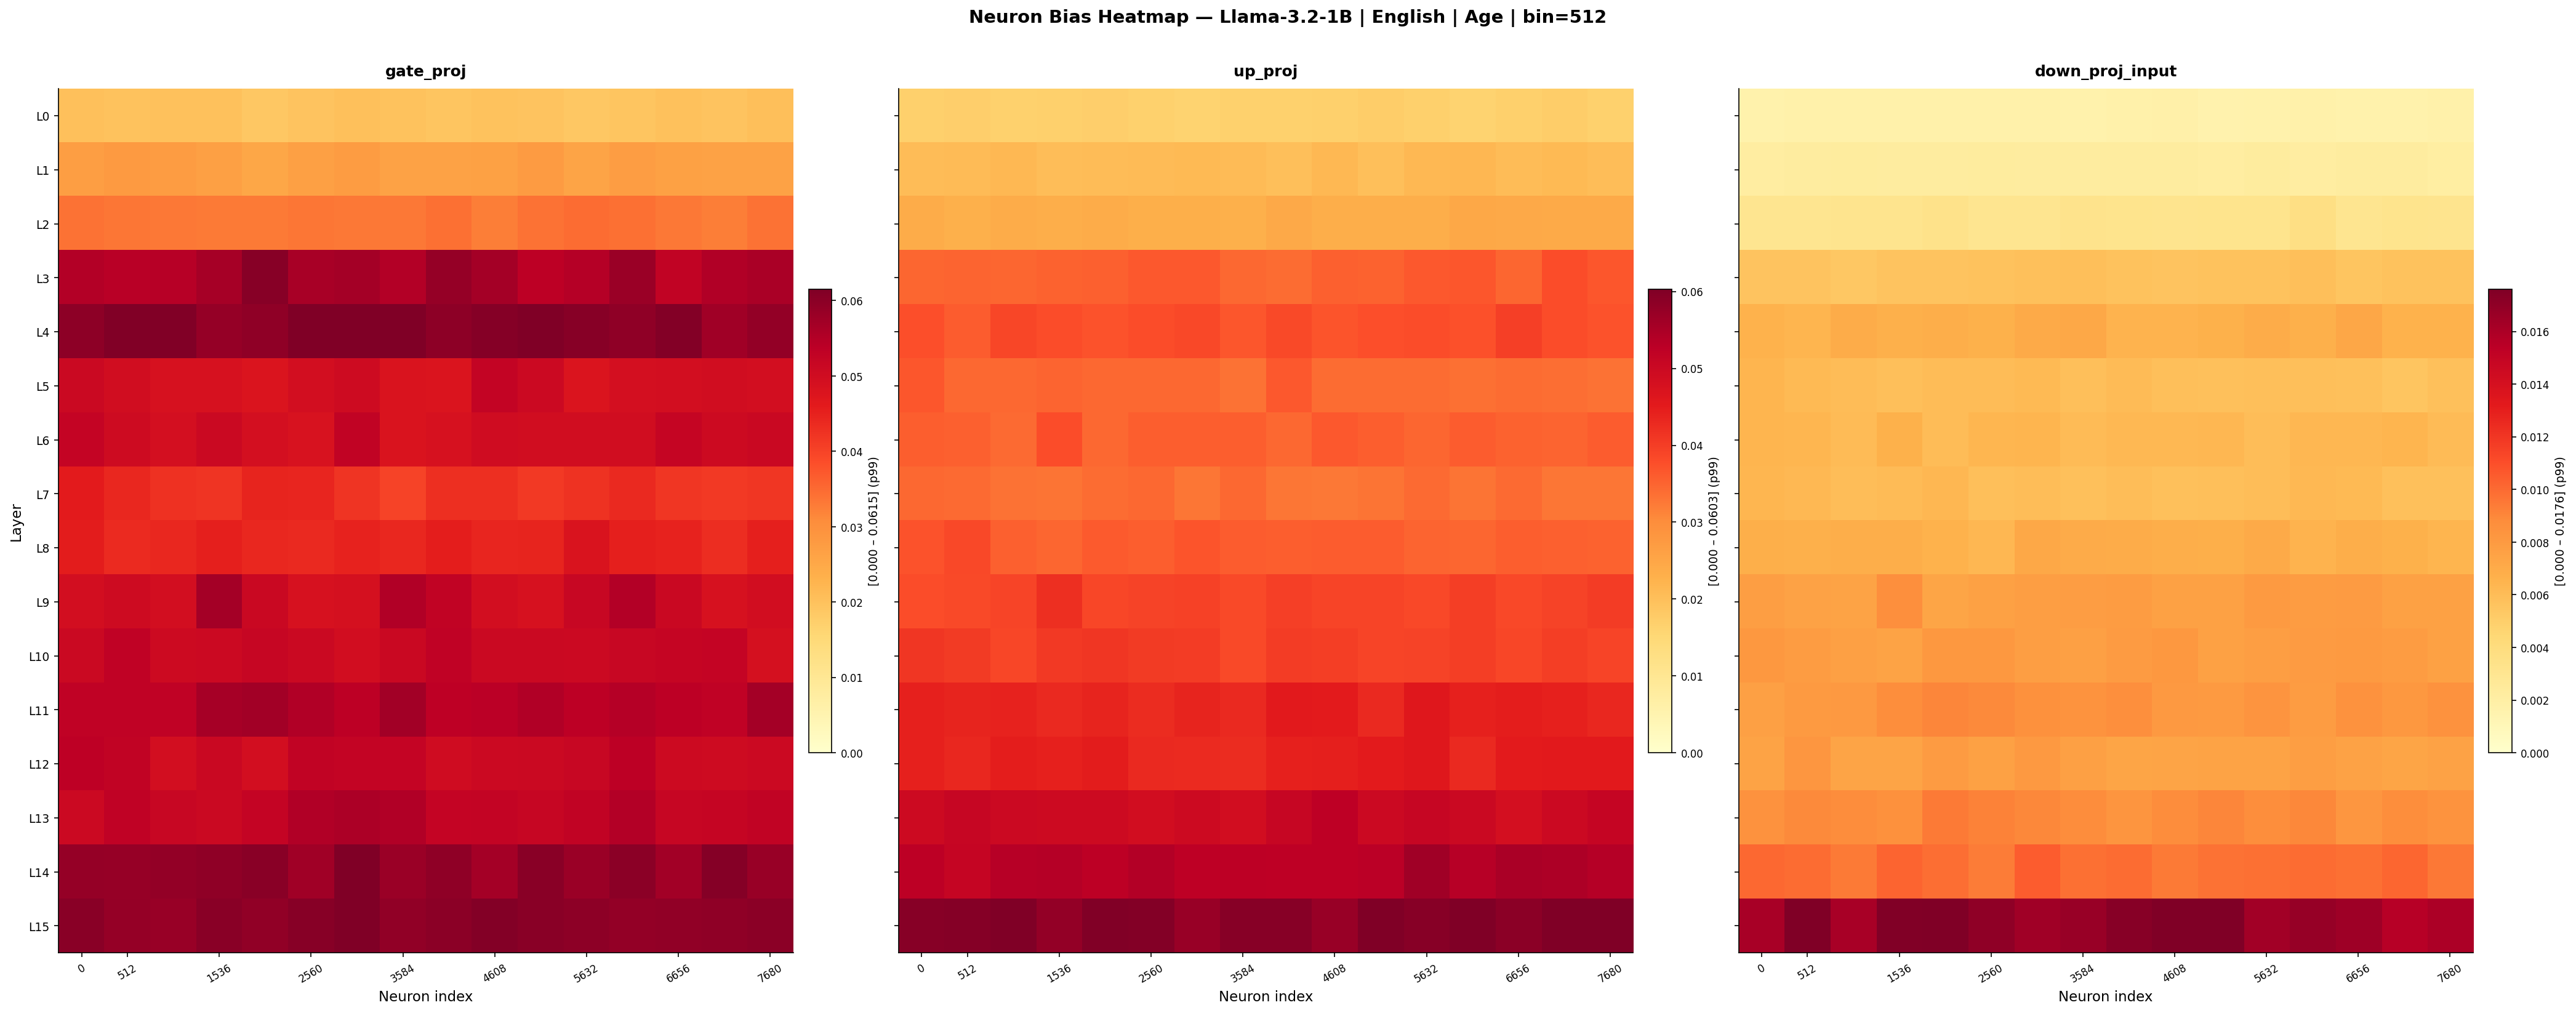


  llama-3.2-1B | EN | Gender
  gate_proj                     : vmax(p99)=0.032023 | abs max=0.032277
  up_proj                       : vmax(p99)=0.028559 | abs max=0.029491
  down_proj_input               : vmax(p99)=0.008839 | abs max=0.009492
Saved: neuron_heatmap_llama-3.2-1B_en_Gender_bin512


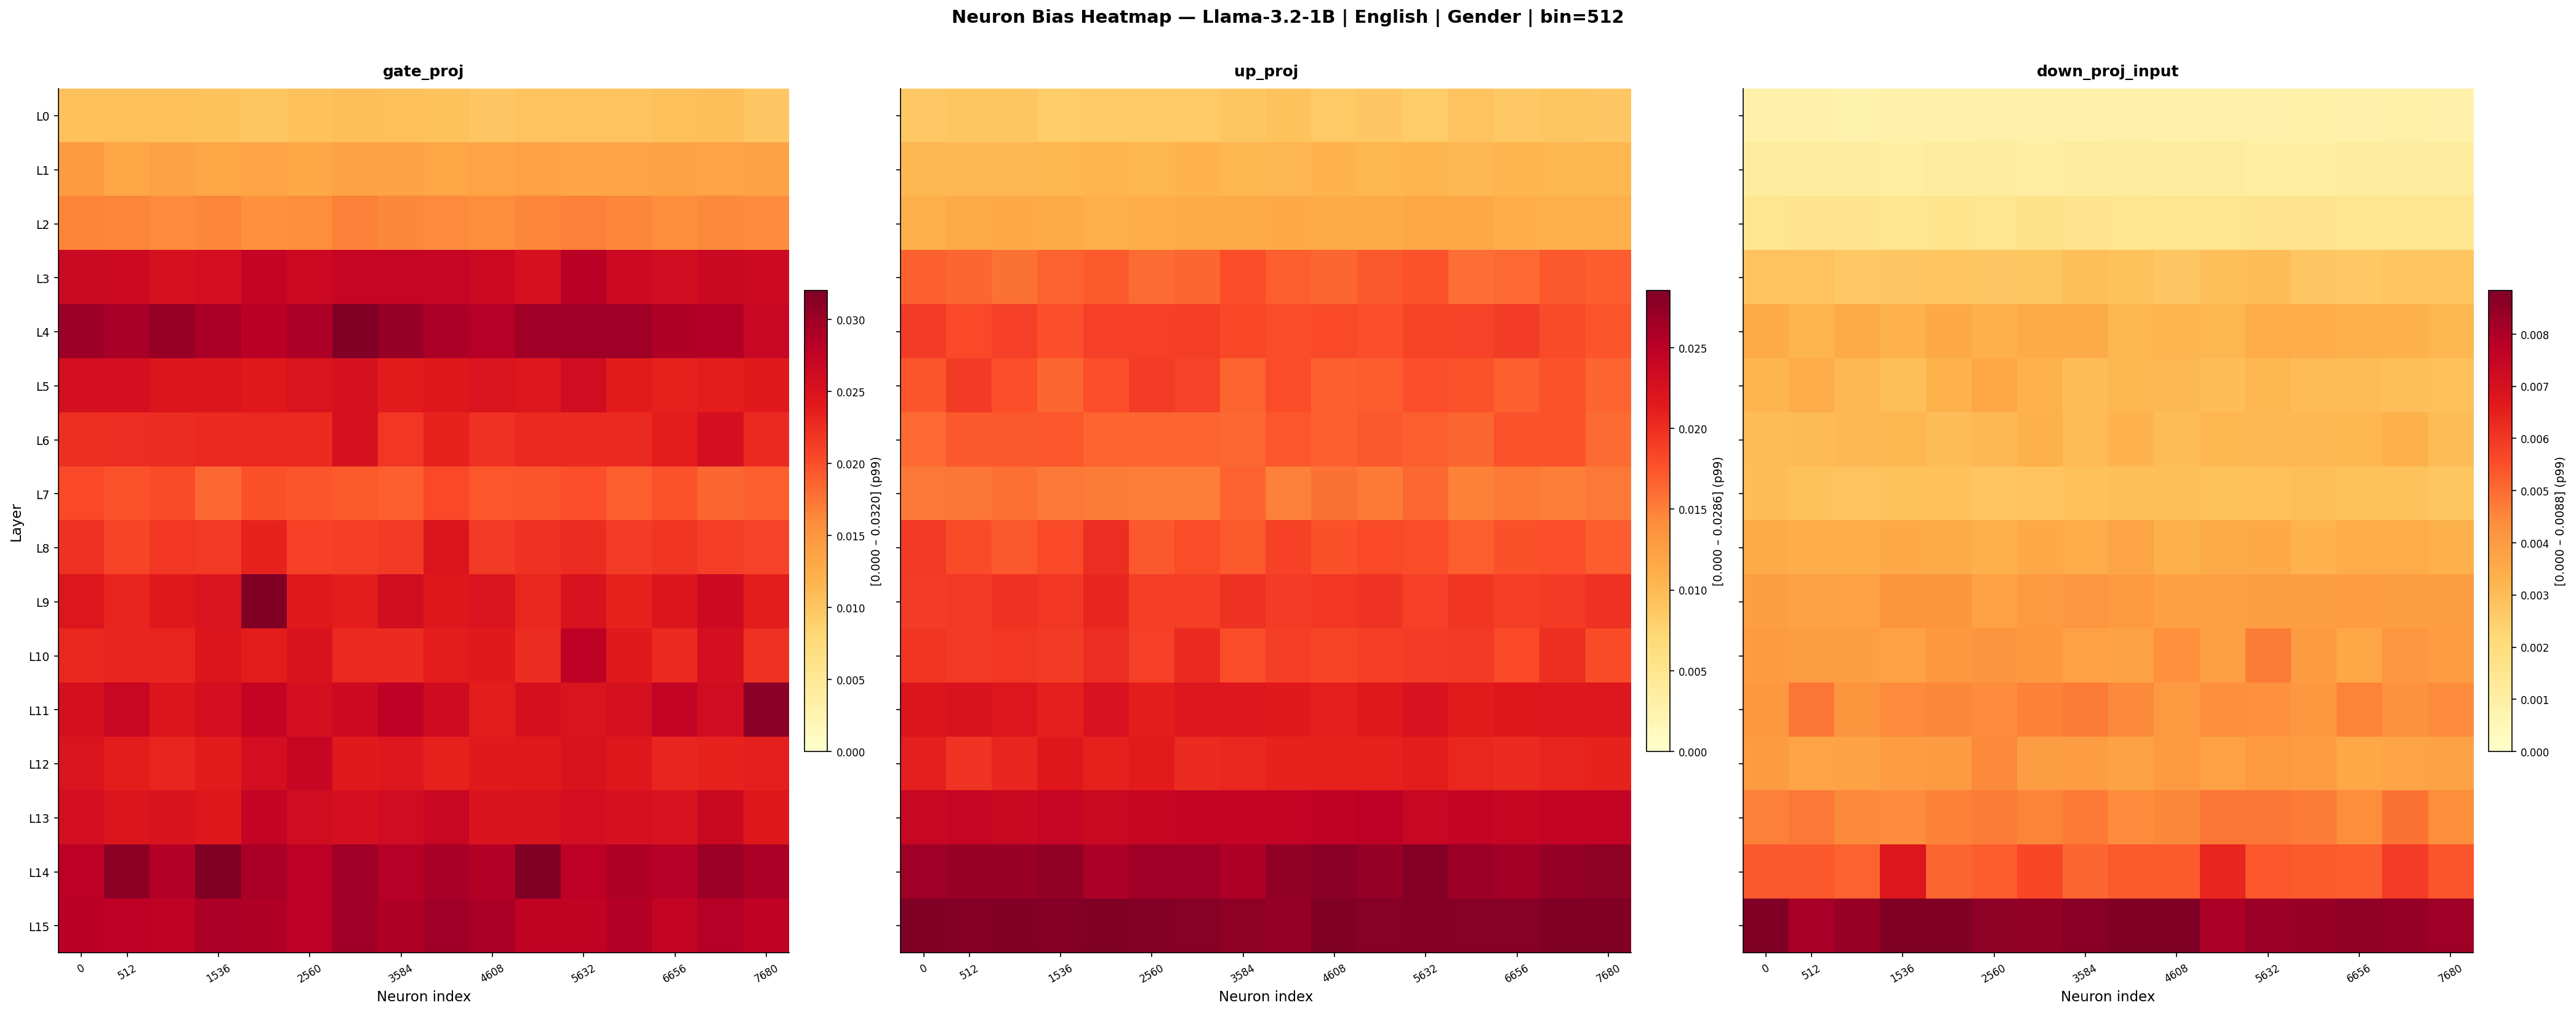


  llama-3.2-1B | EN | PhysicalAppearance
  gate_proj                     : vmax(p99)=0.053581 | abs max=0.055003
  up_proj                       : vmax(p99)=0.050708 | abs max=0.052732
  down_proj_input               : vmax(p99)=0.014376 | abs max=0.015257
Saved: neuron_heatmap_llama-3.2-1B_en_PhysicalAppearance_bin512


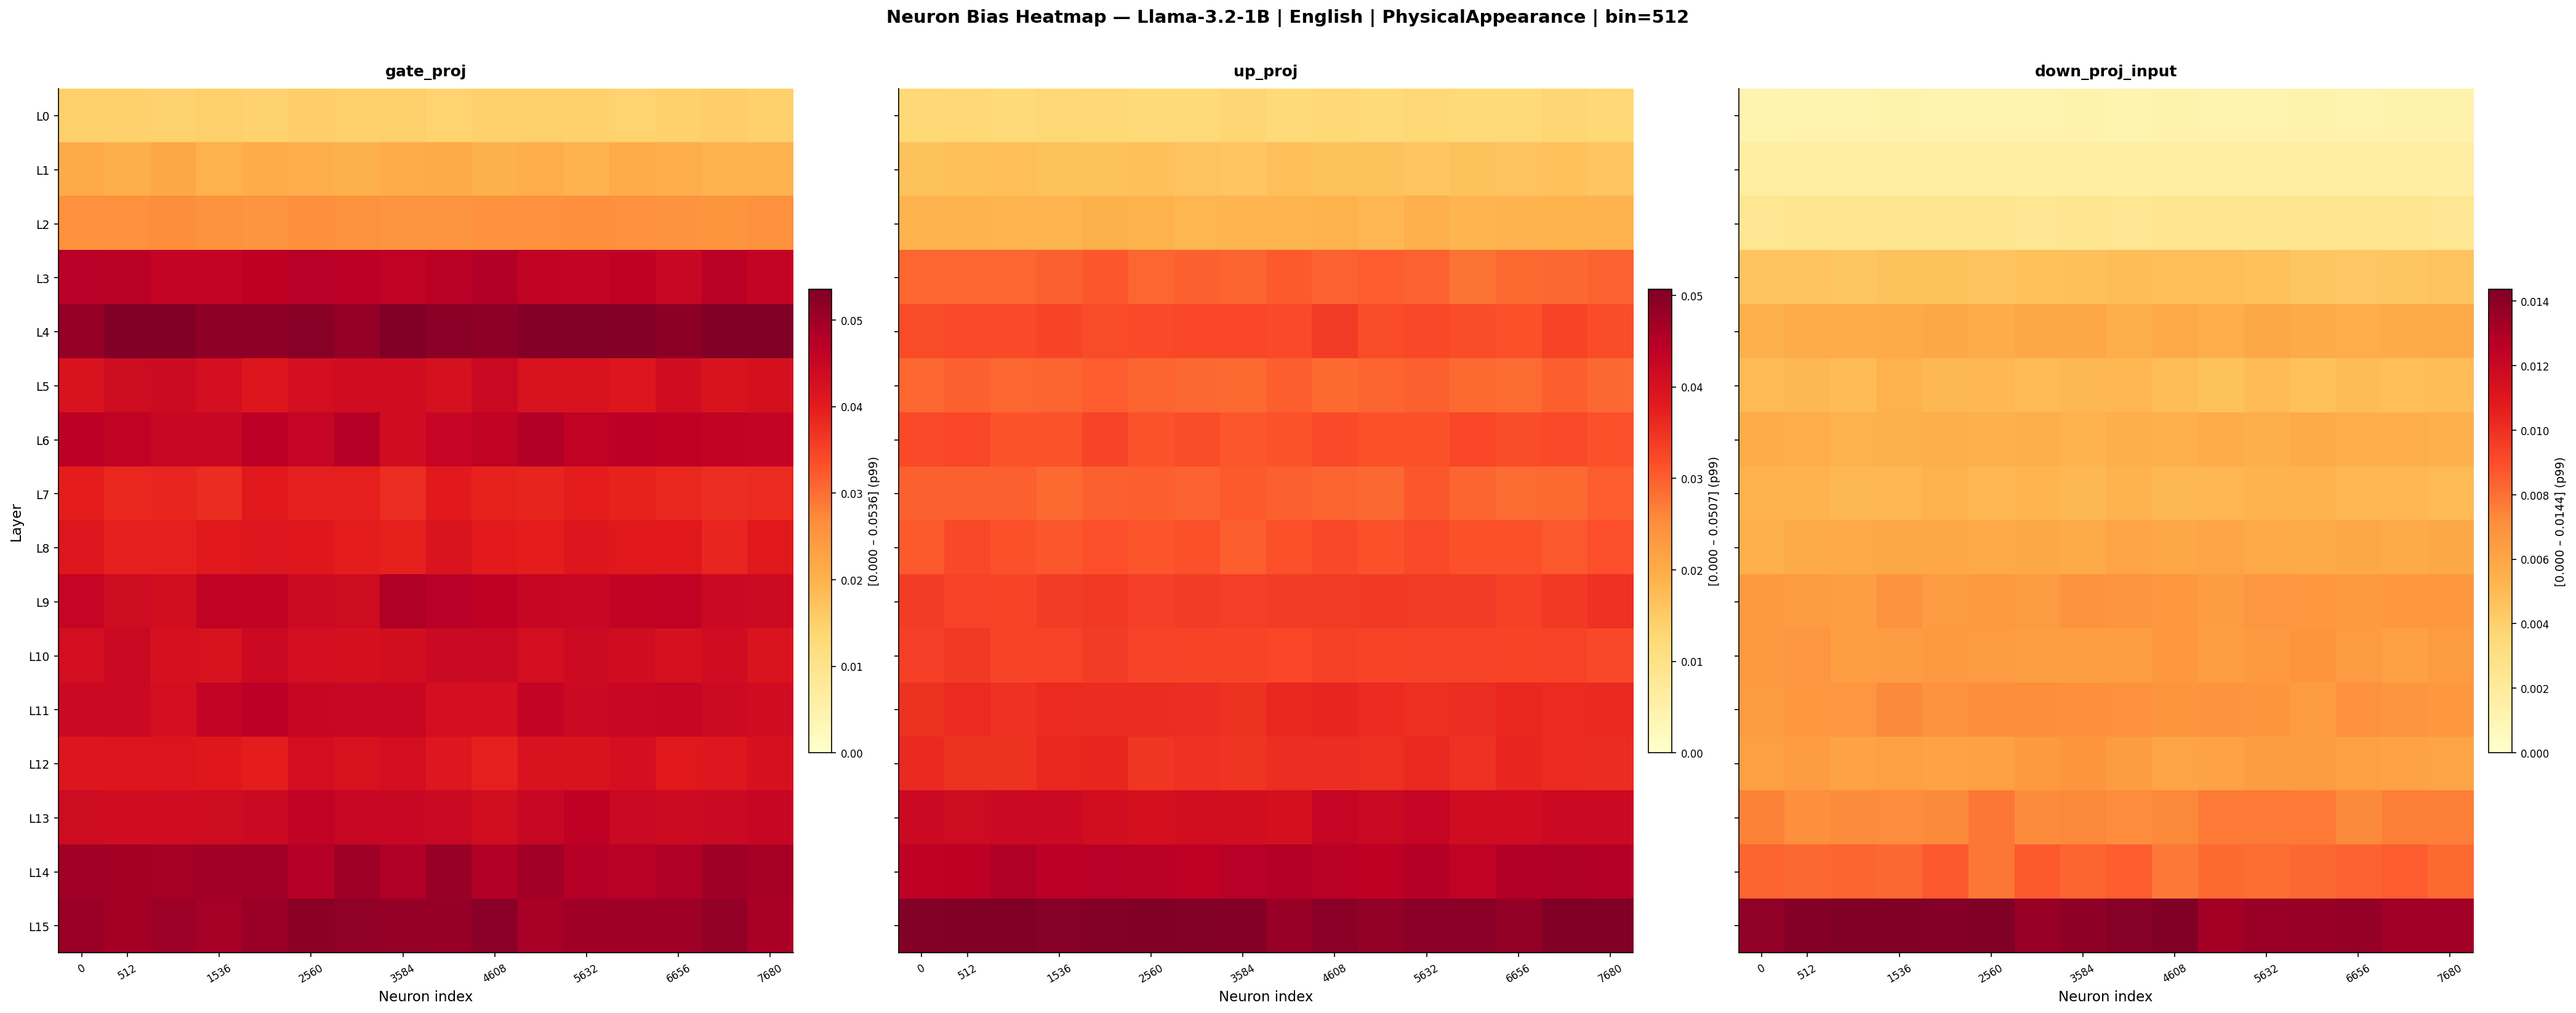


  llama-3.2-1B | EN | RaceEthnicity
  gate_proj                     : vmax(p99)=0.063124 | abs max=0.065710
  up_proj                       : vmax(p99)=0.063502 | abs max=0.065742
  down_proj_input               : vmax(p99)=0.018885 | abs max=0.019274
Saved: neuron_heatmap_llama-3.2-1B_en_RaceEthnicity_bin512


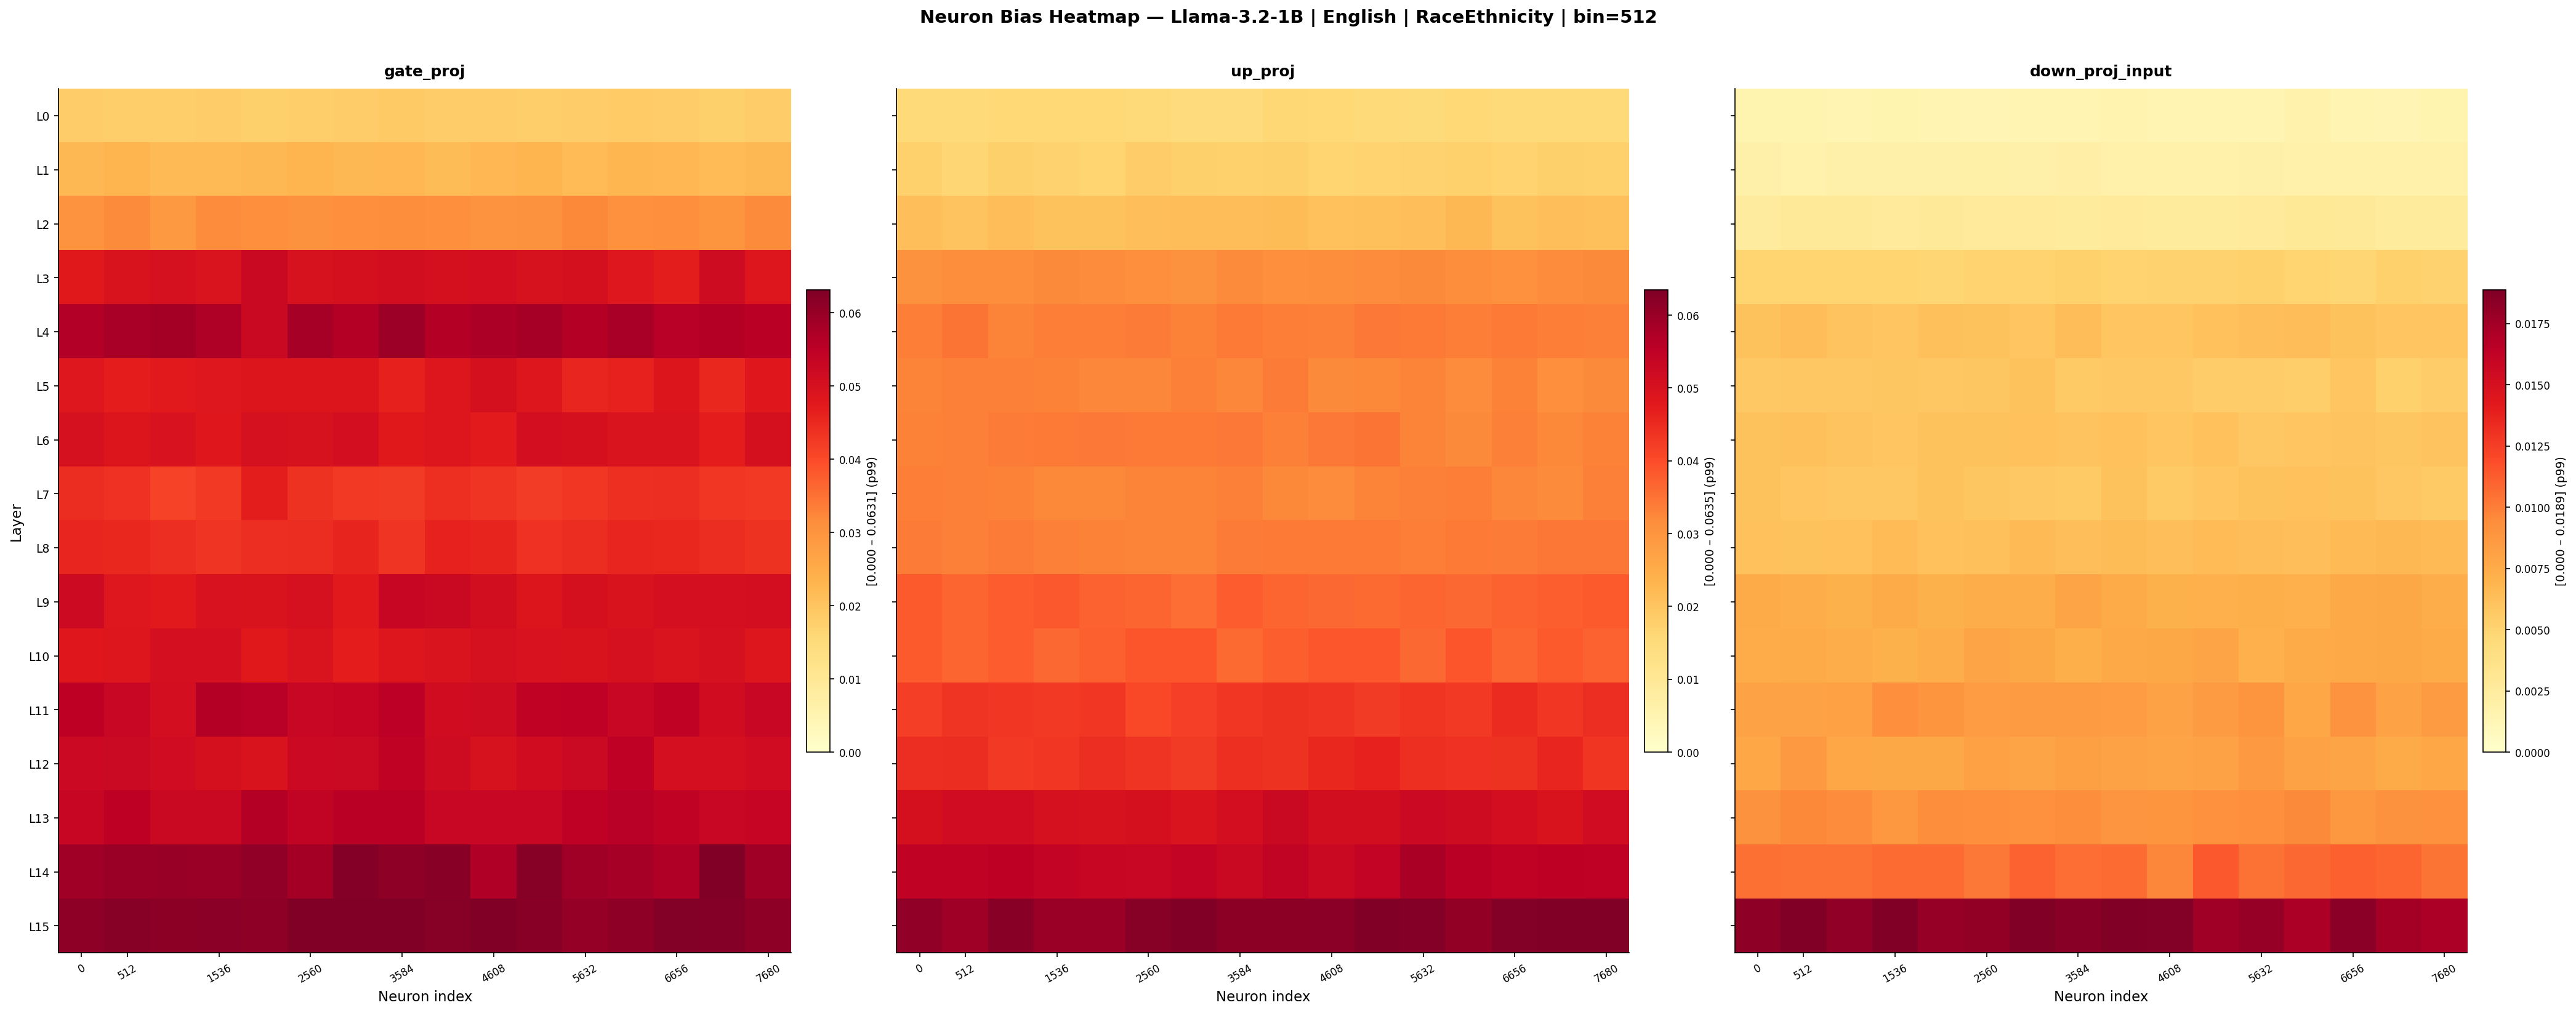


  llama-3.2-1B | EN | Religion
  gate_proj                     : vmax(p99)=0.078269 | abs max=0.080111
  up_proj                       : vmax(p99)=0.080303 | abs max=0.085474
  down_proj_input               : vmax(p99)=0.021584 | abs max=0.022907
Saved: neuron_heatmap_llama-3.2-1B_en_Religion_bin512


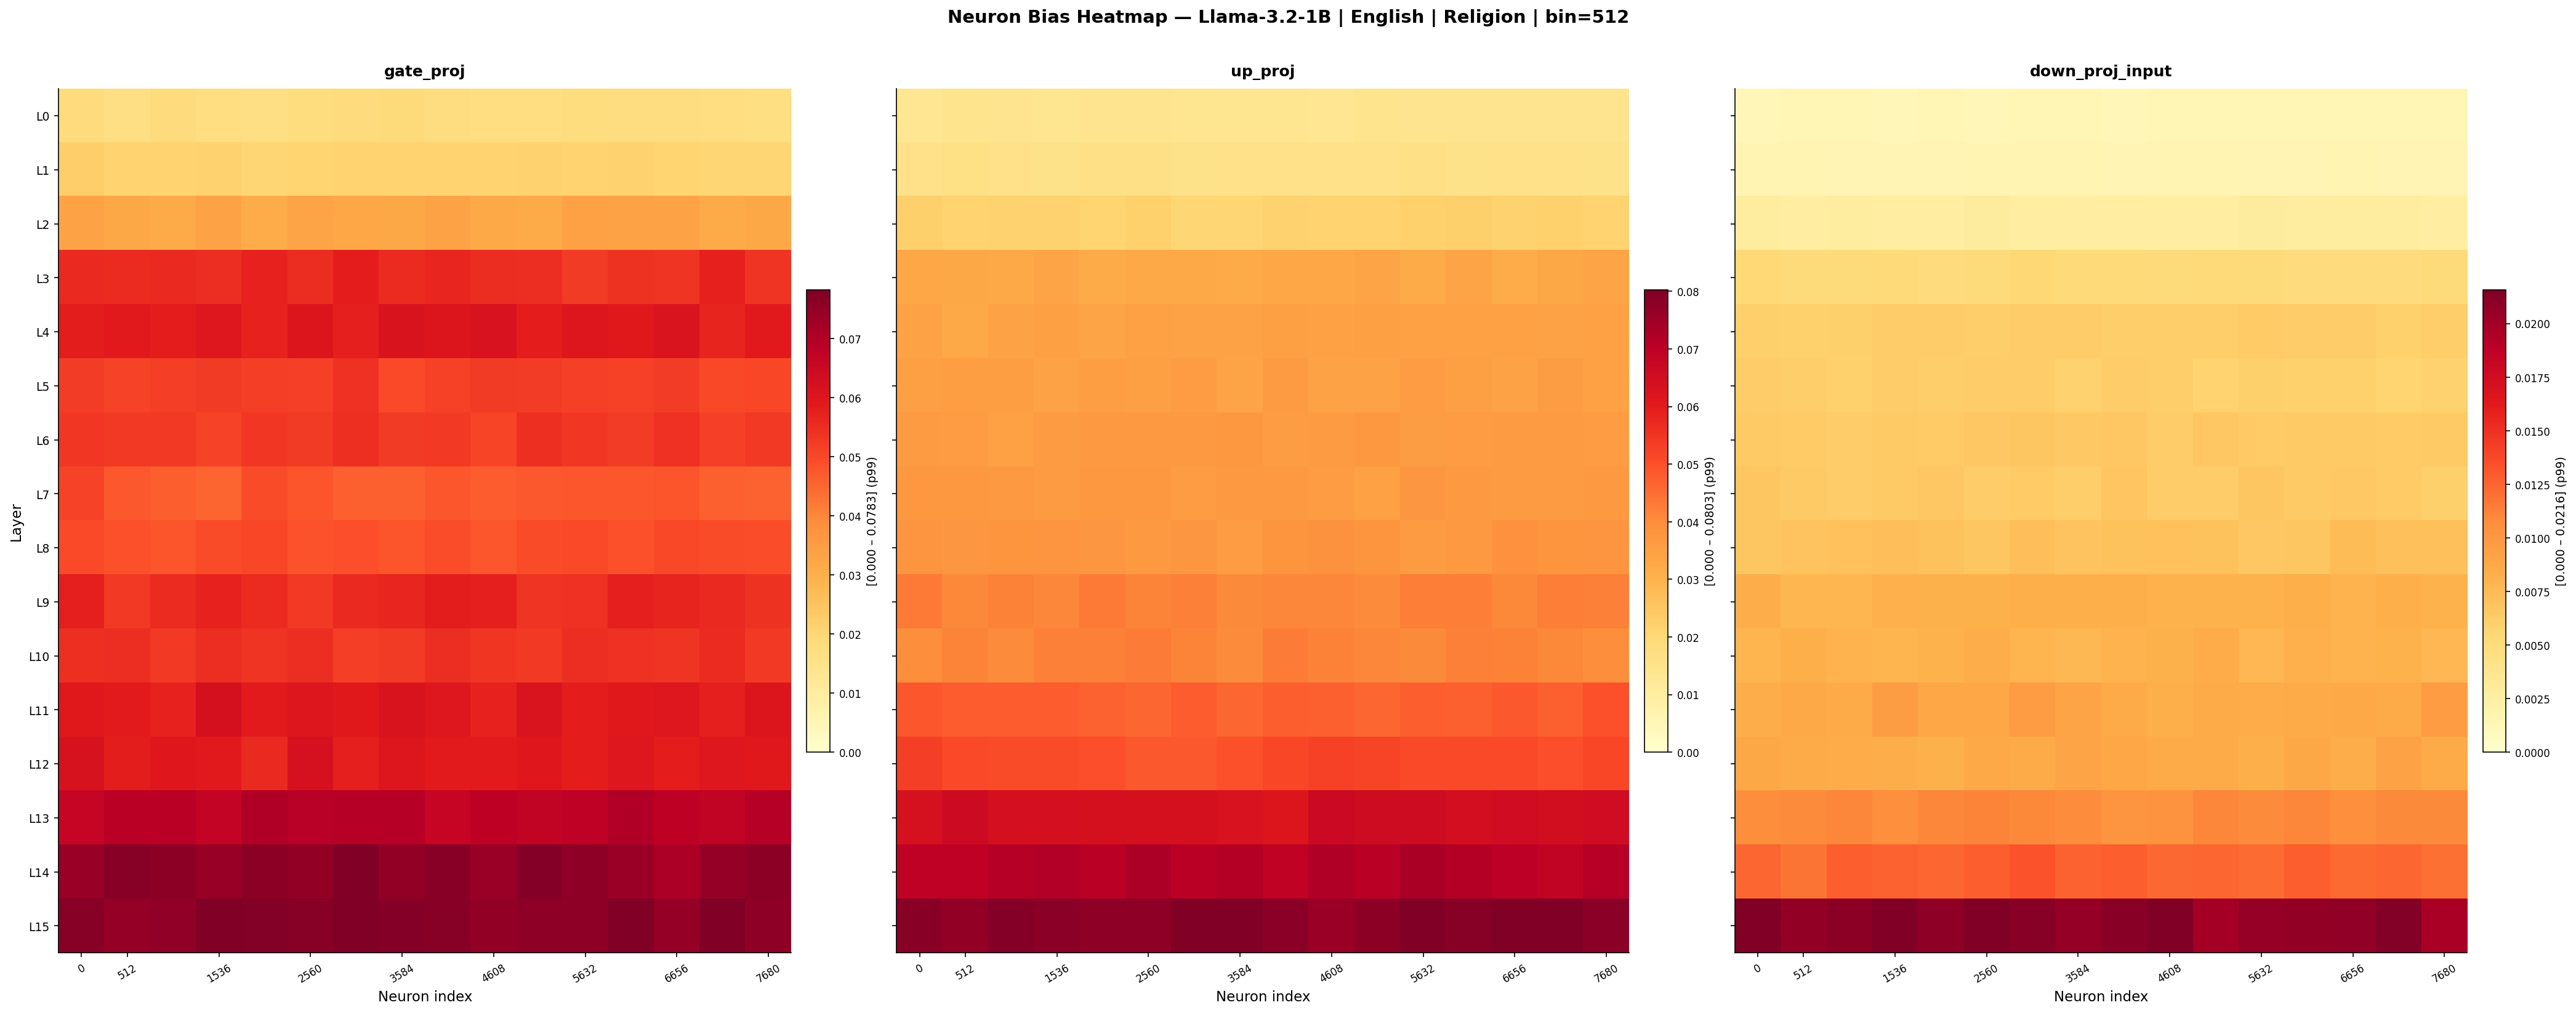


  llama-3.2-1B | ES | Age
  gate_proj                     : vmax(p99)=0.044460 | abs max=0.045926
  up_proj                       : vmax(p99)=0.028907 | abs max=0.029691
  down_proj_input               : vmax(p99)=0.009899 | abs max=0.010550
Saved: neuron_heatmap_llama-3.2-1B_es_Age_bin512


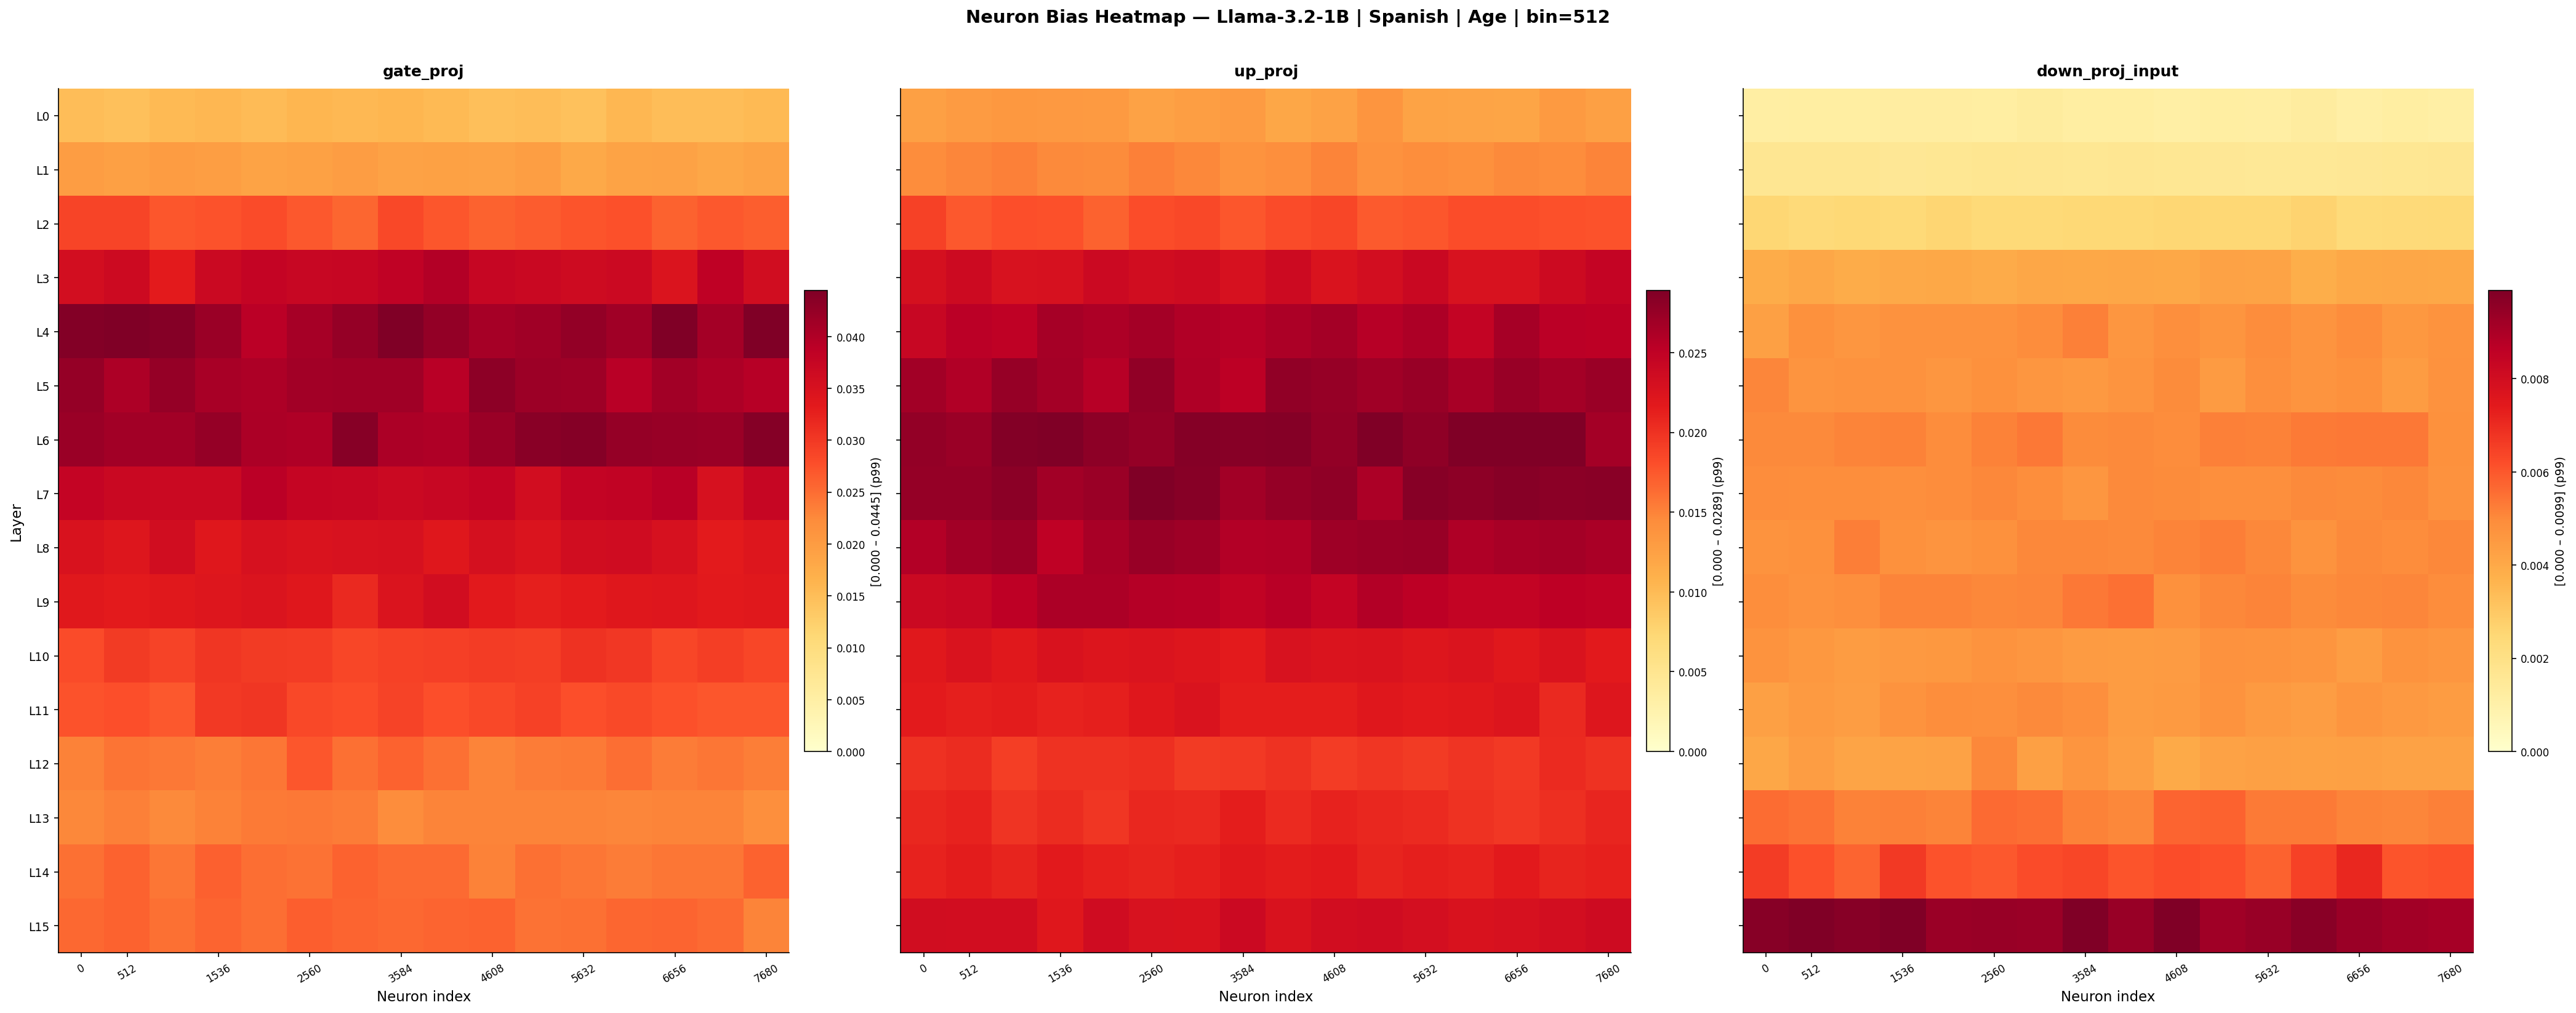


  llama-3.2-1B | ES | Gender
  gate_proj                     : vmax(p99)=0.047445 | abs max=0.048234
  up_proj                       : vmax(p99)=0.042413 | abs max=0.044615
  down_proj_input               : vmax(p99)=0.016690 | abs max=0.017163
Saved: neuron_heatmap_llama-3.2-1B_es_Gender_bin512


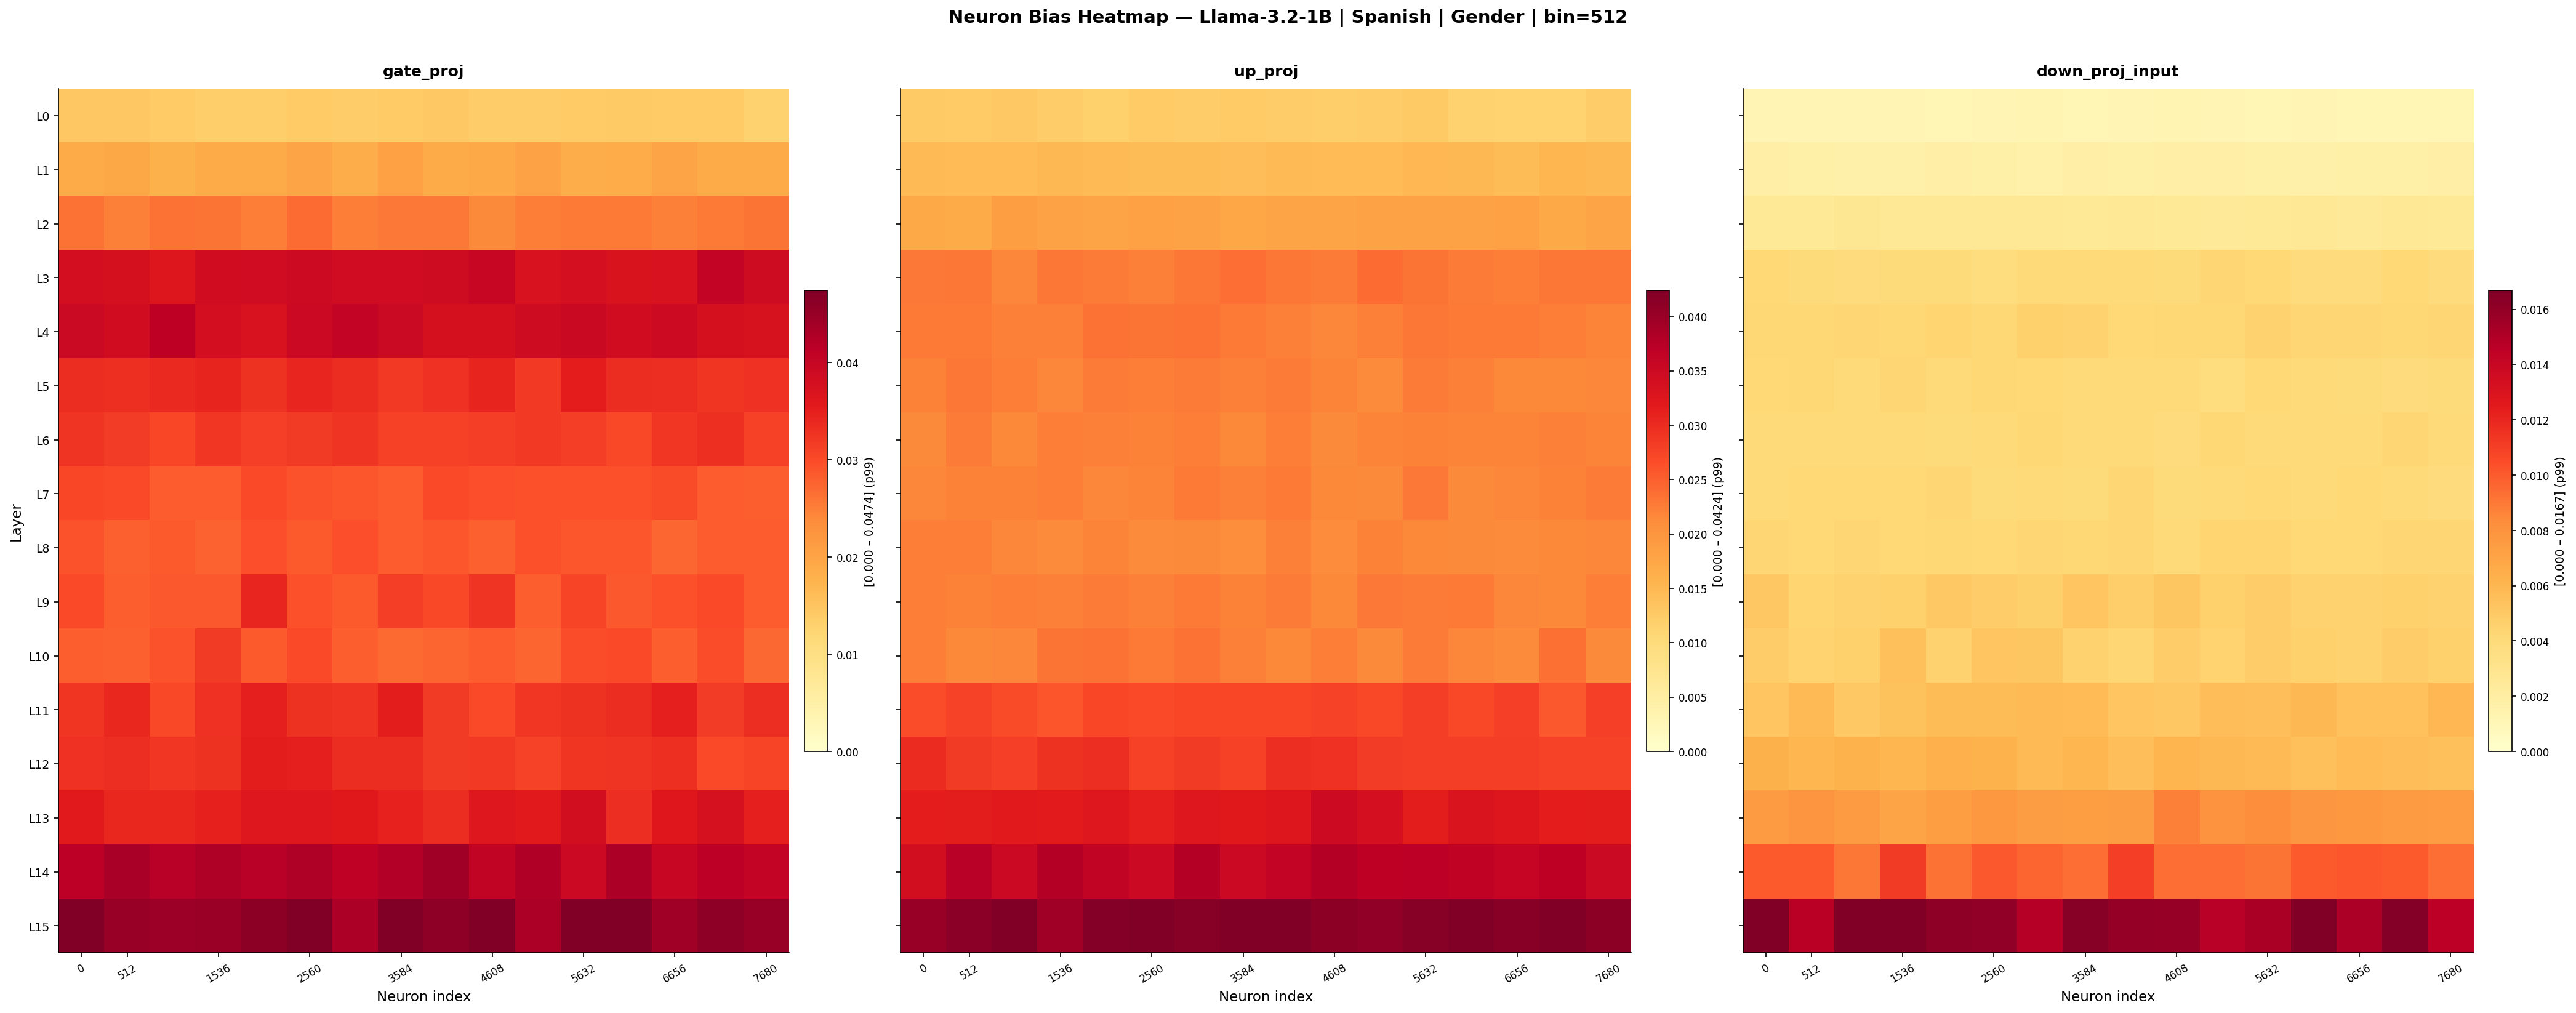


  llama-3.2-1B | ES | PhysicalAppearance
  gate_proj                     : vmax(p99)=0.044166 | abs max=0.045621
  up_proj                       : vmax(p99)=0.038349 | abs max=0.039010
  down_proj_input               : vmax(p99)=0.016254 | abs max=0.016729
Saved: neuron_heatmap_llama-3.2-1B_es_PhysicalAppearance_bin512


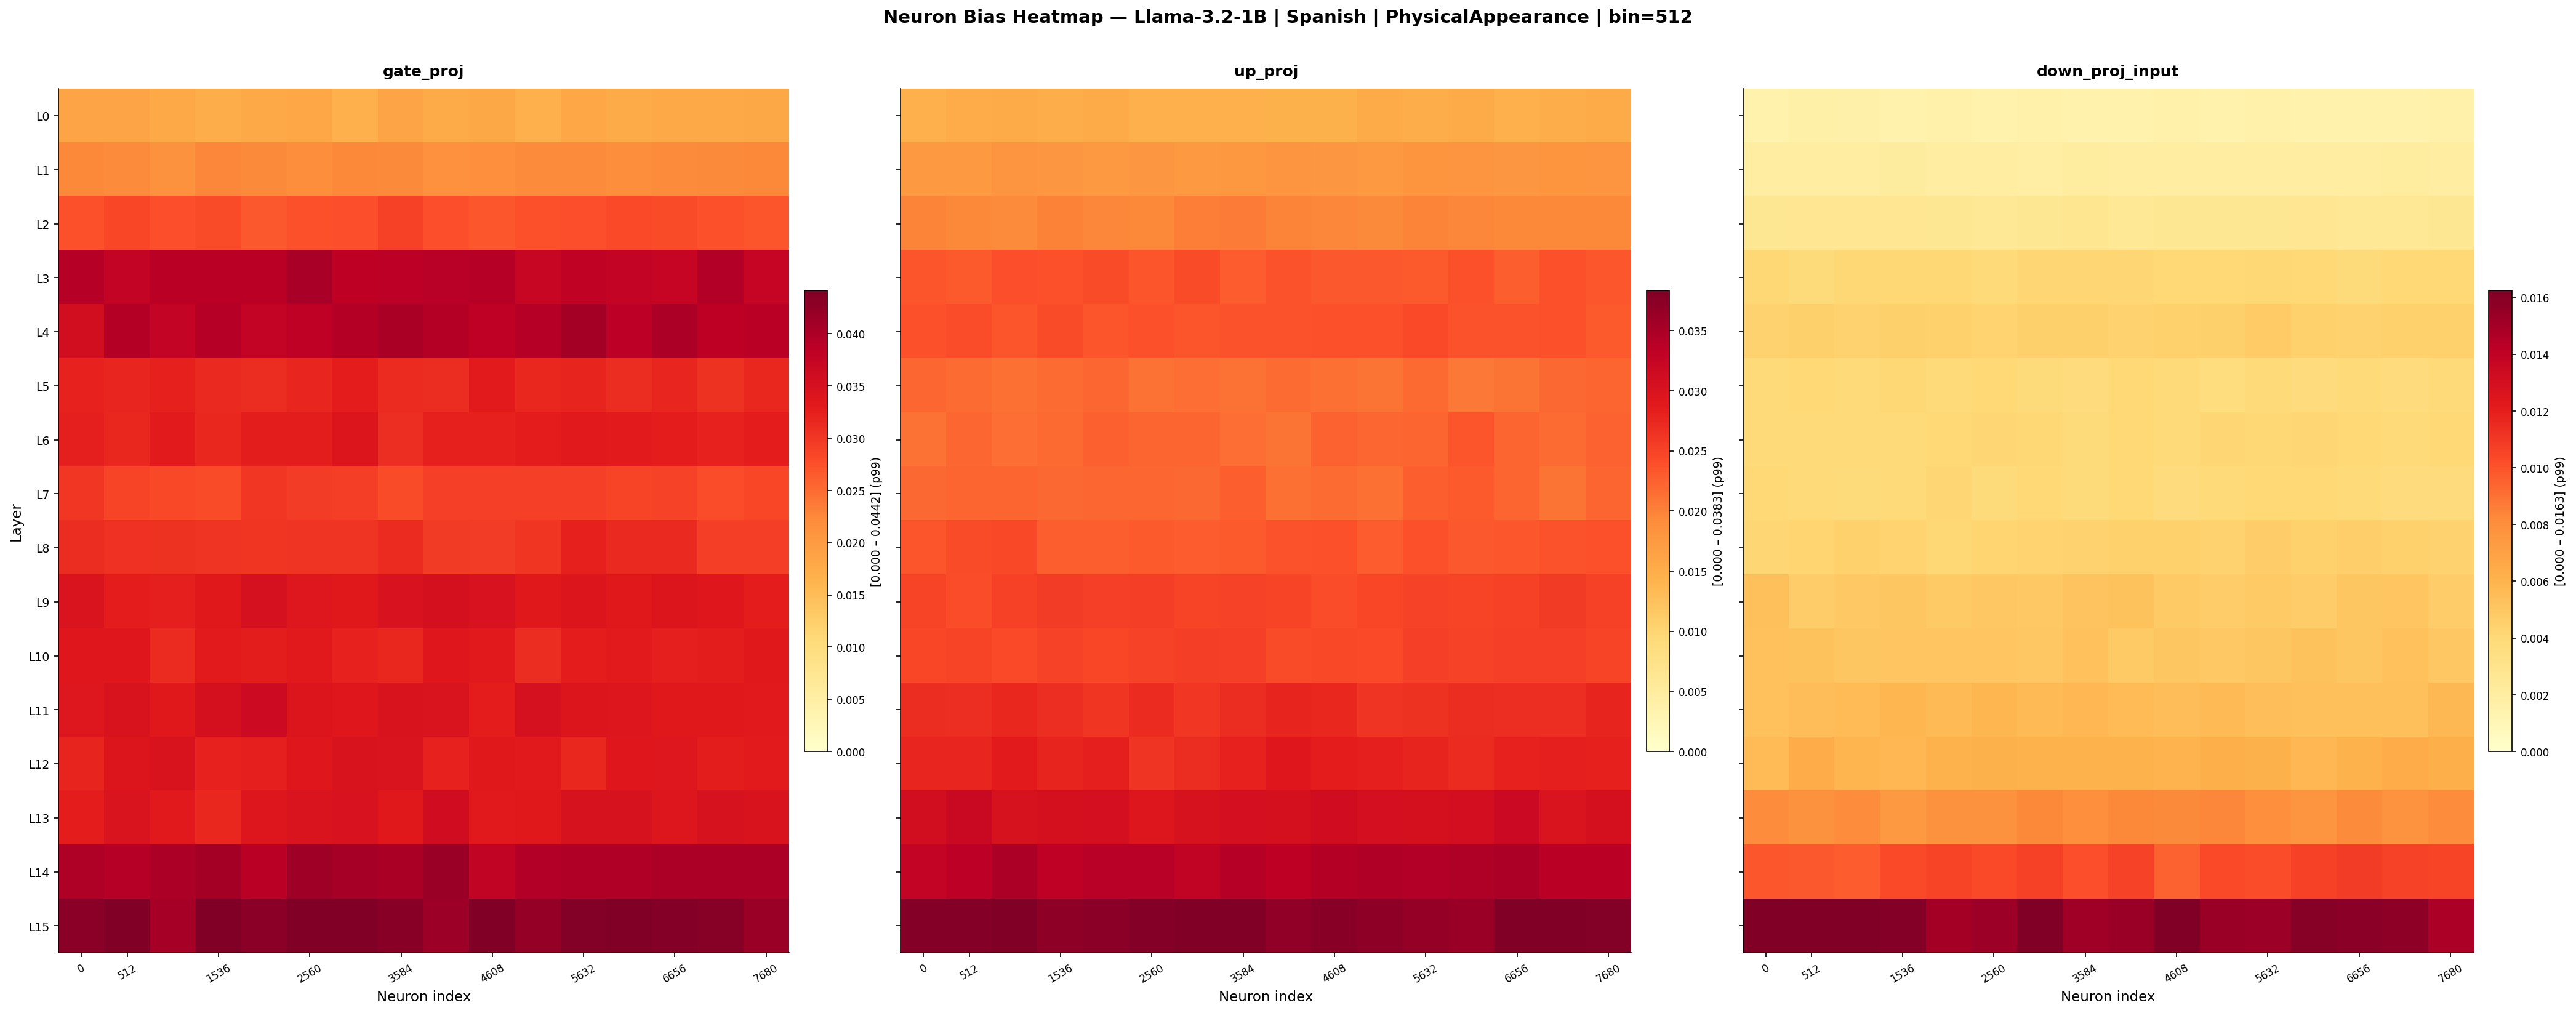


  llama-3.2-1B | ES | RaceEthnicity
  gate_proj                     : vmax(p99)=0.034069 | abs max=0.034870
  up_proj                       : vmax(p99)=0.022905 | abs max=0.023148
  down_proj_input               : vmax(p99)=0.009222 | abs max=0.009603
Saved: neuron_heatmap_llama-3.2-1B_es_RaceEthnicity_bin512


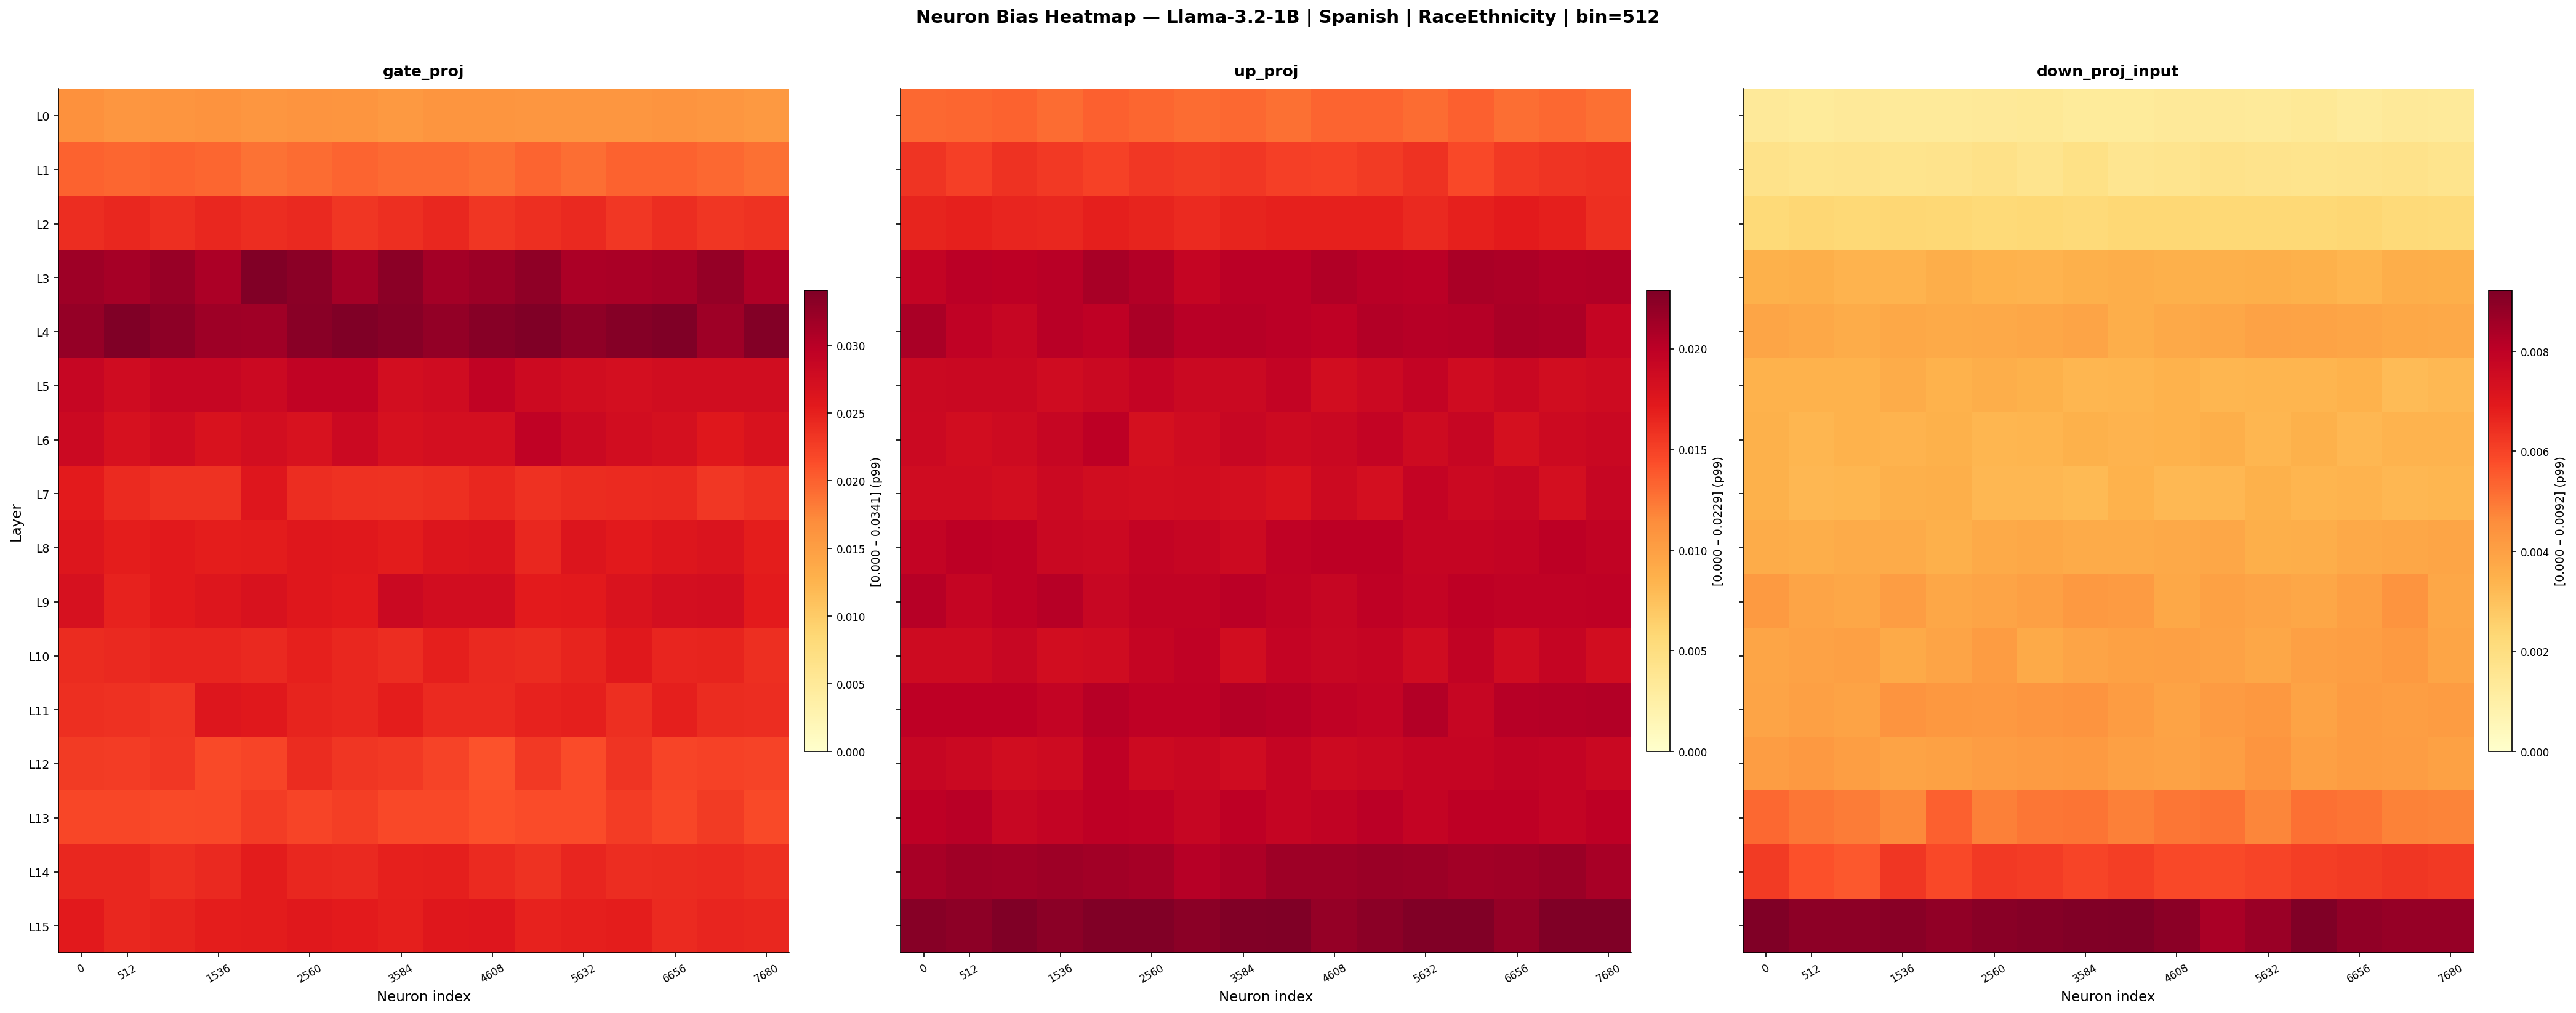


  llama-3.2-1B | ES | Religion
  gate_proj                     : vmax(p99)=0.066044 | abs max=0.068173
  up_proj                       : vmax(p99)=0.047347 | abs max=0.048777
  down_proj_input               : vmax(p99)=0.018077 | abs max=0.018286
Saved: neuron_heatmap_llama-3.2-1B_es_Religion_bin512


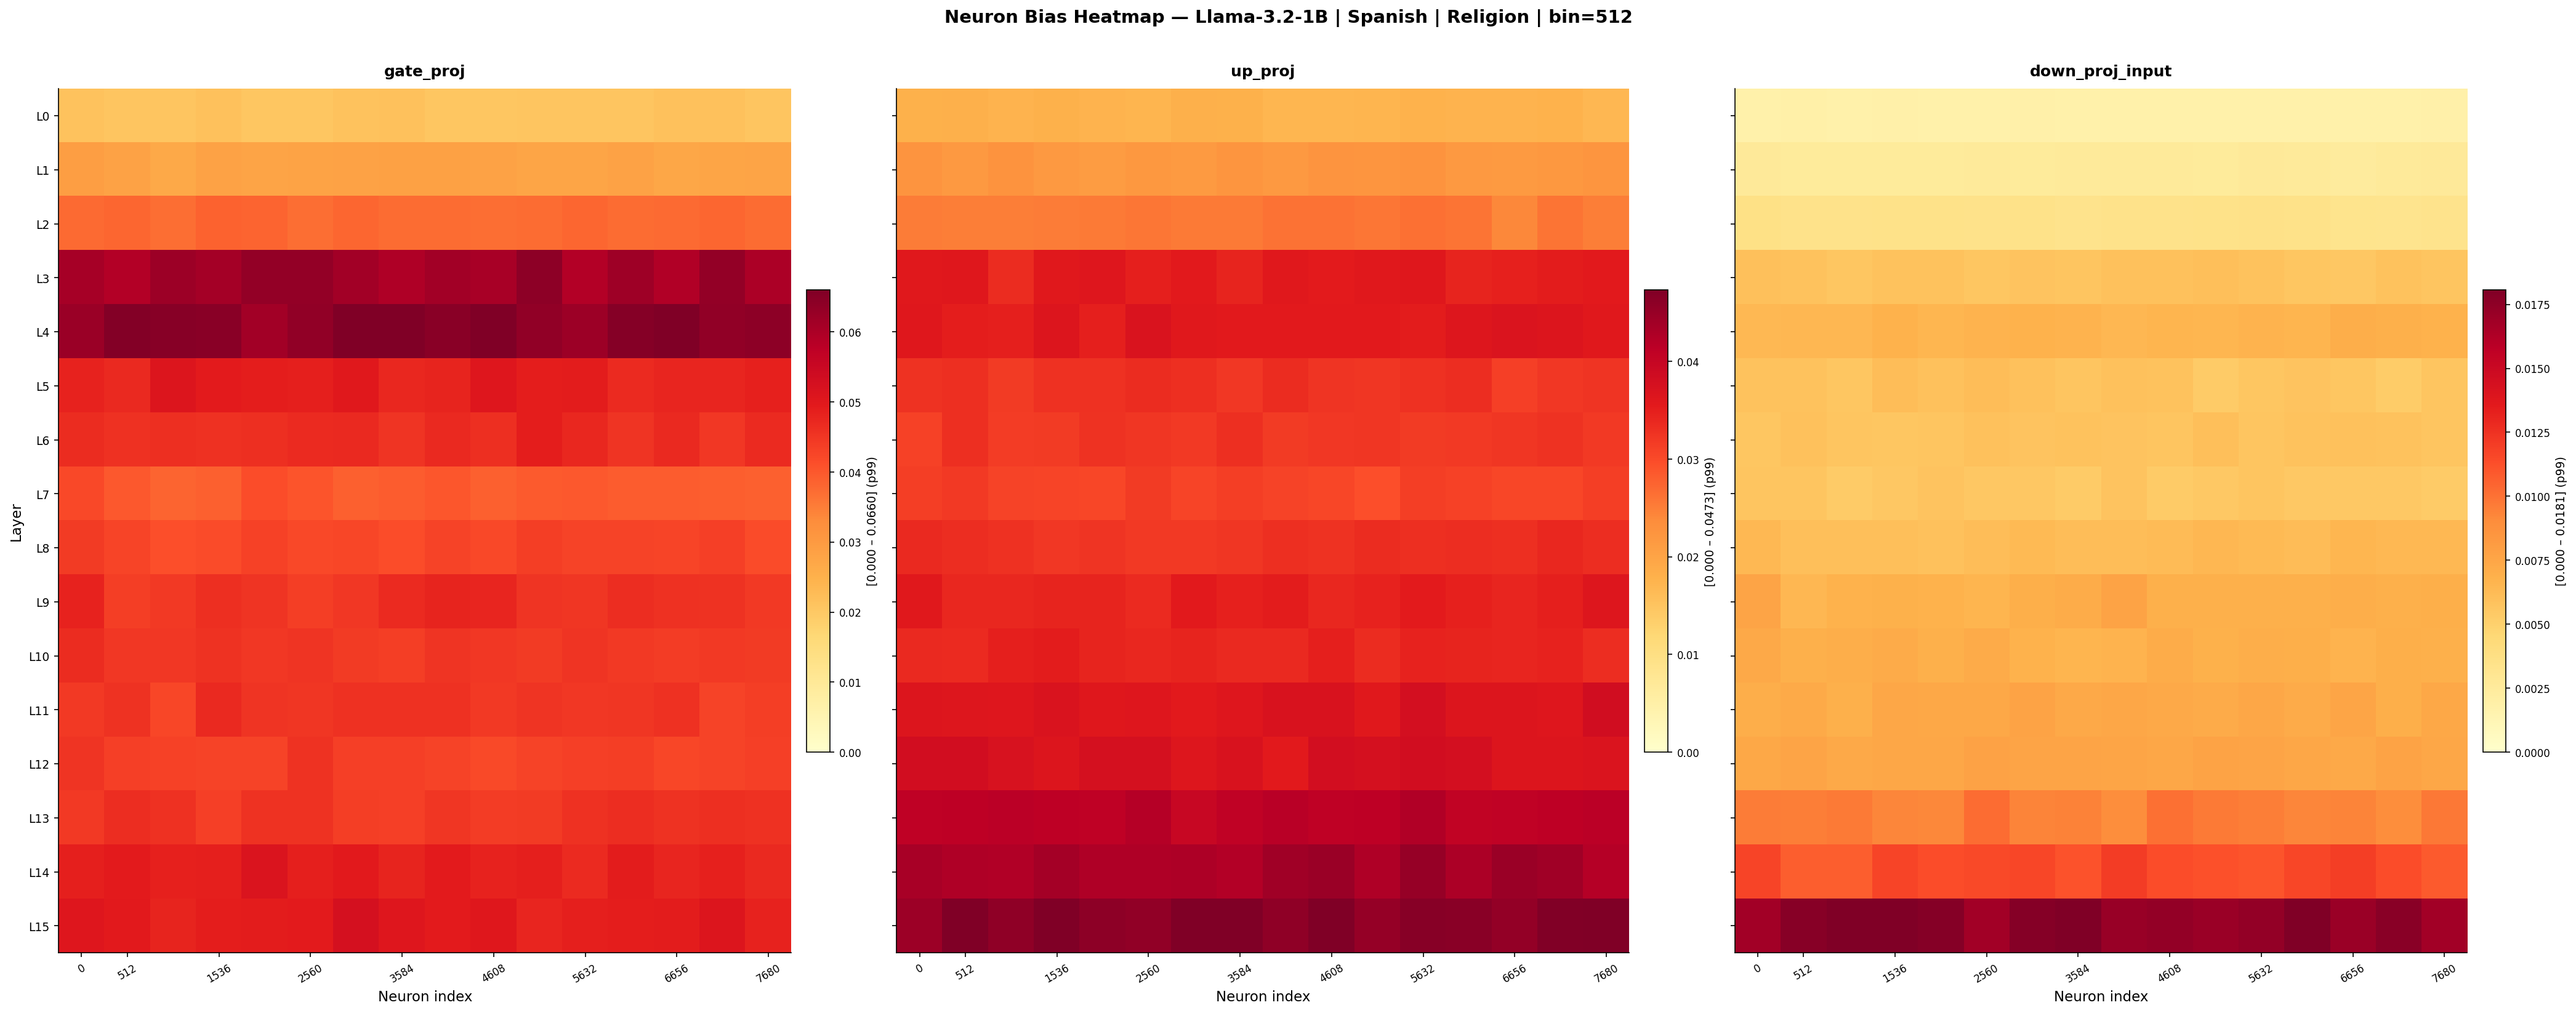


  llama-3.2-3B | EN | Age
  gate_proj                     : vmax(p99)=0.089574 | abs max=0.091201
  up_proj                       : vmax(p99)=0.087894 | abs max=0.091659
  down_proj_input               : vmax(p99)=0.030969 | abs max=0.034000
Saved: neuron_heatmap_llama-3.2-3B_en_Age_bin512


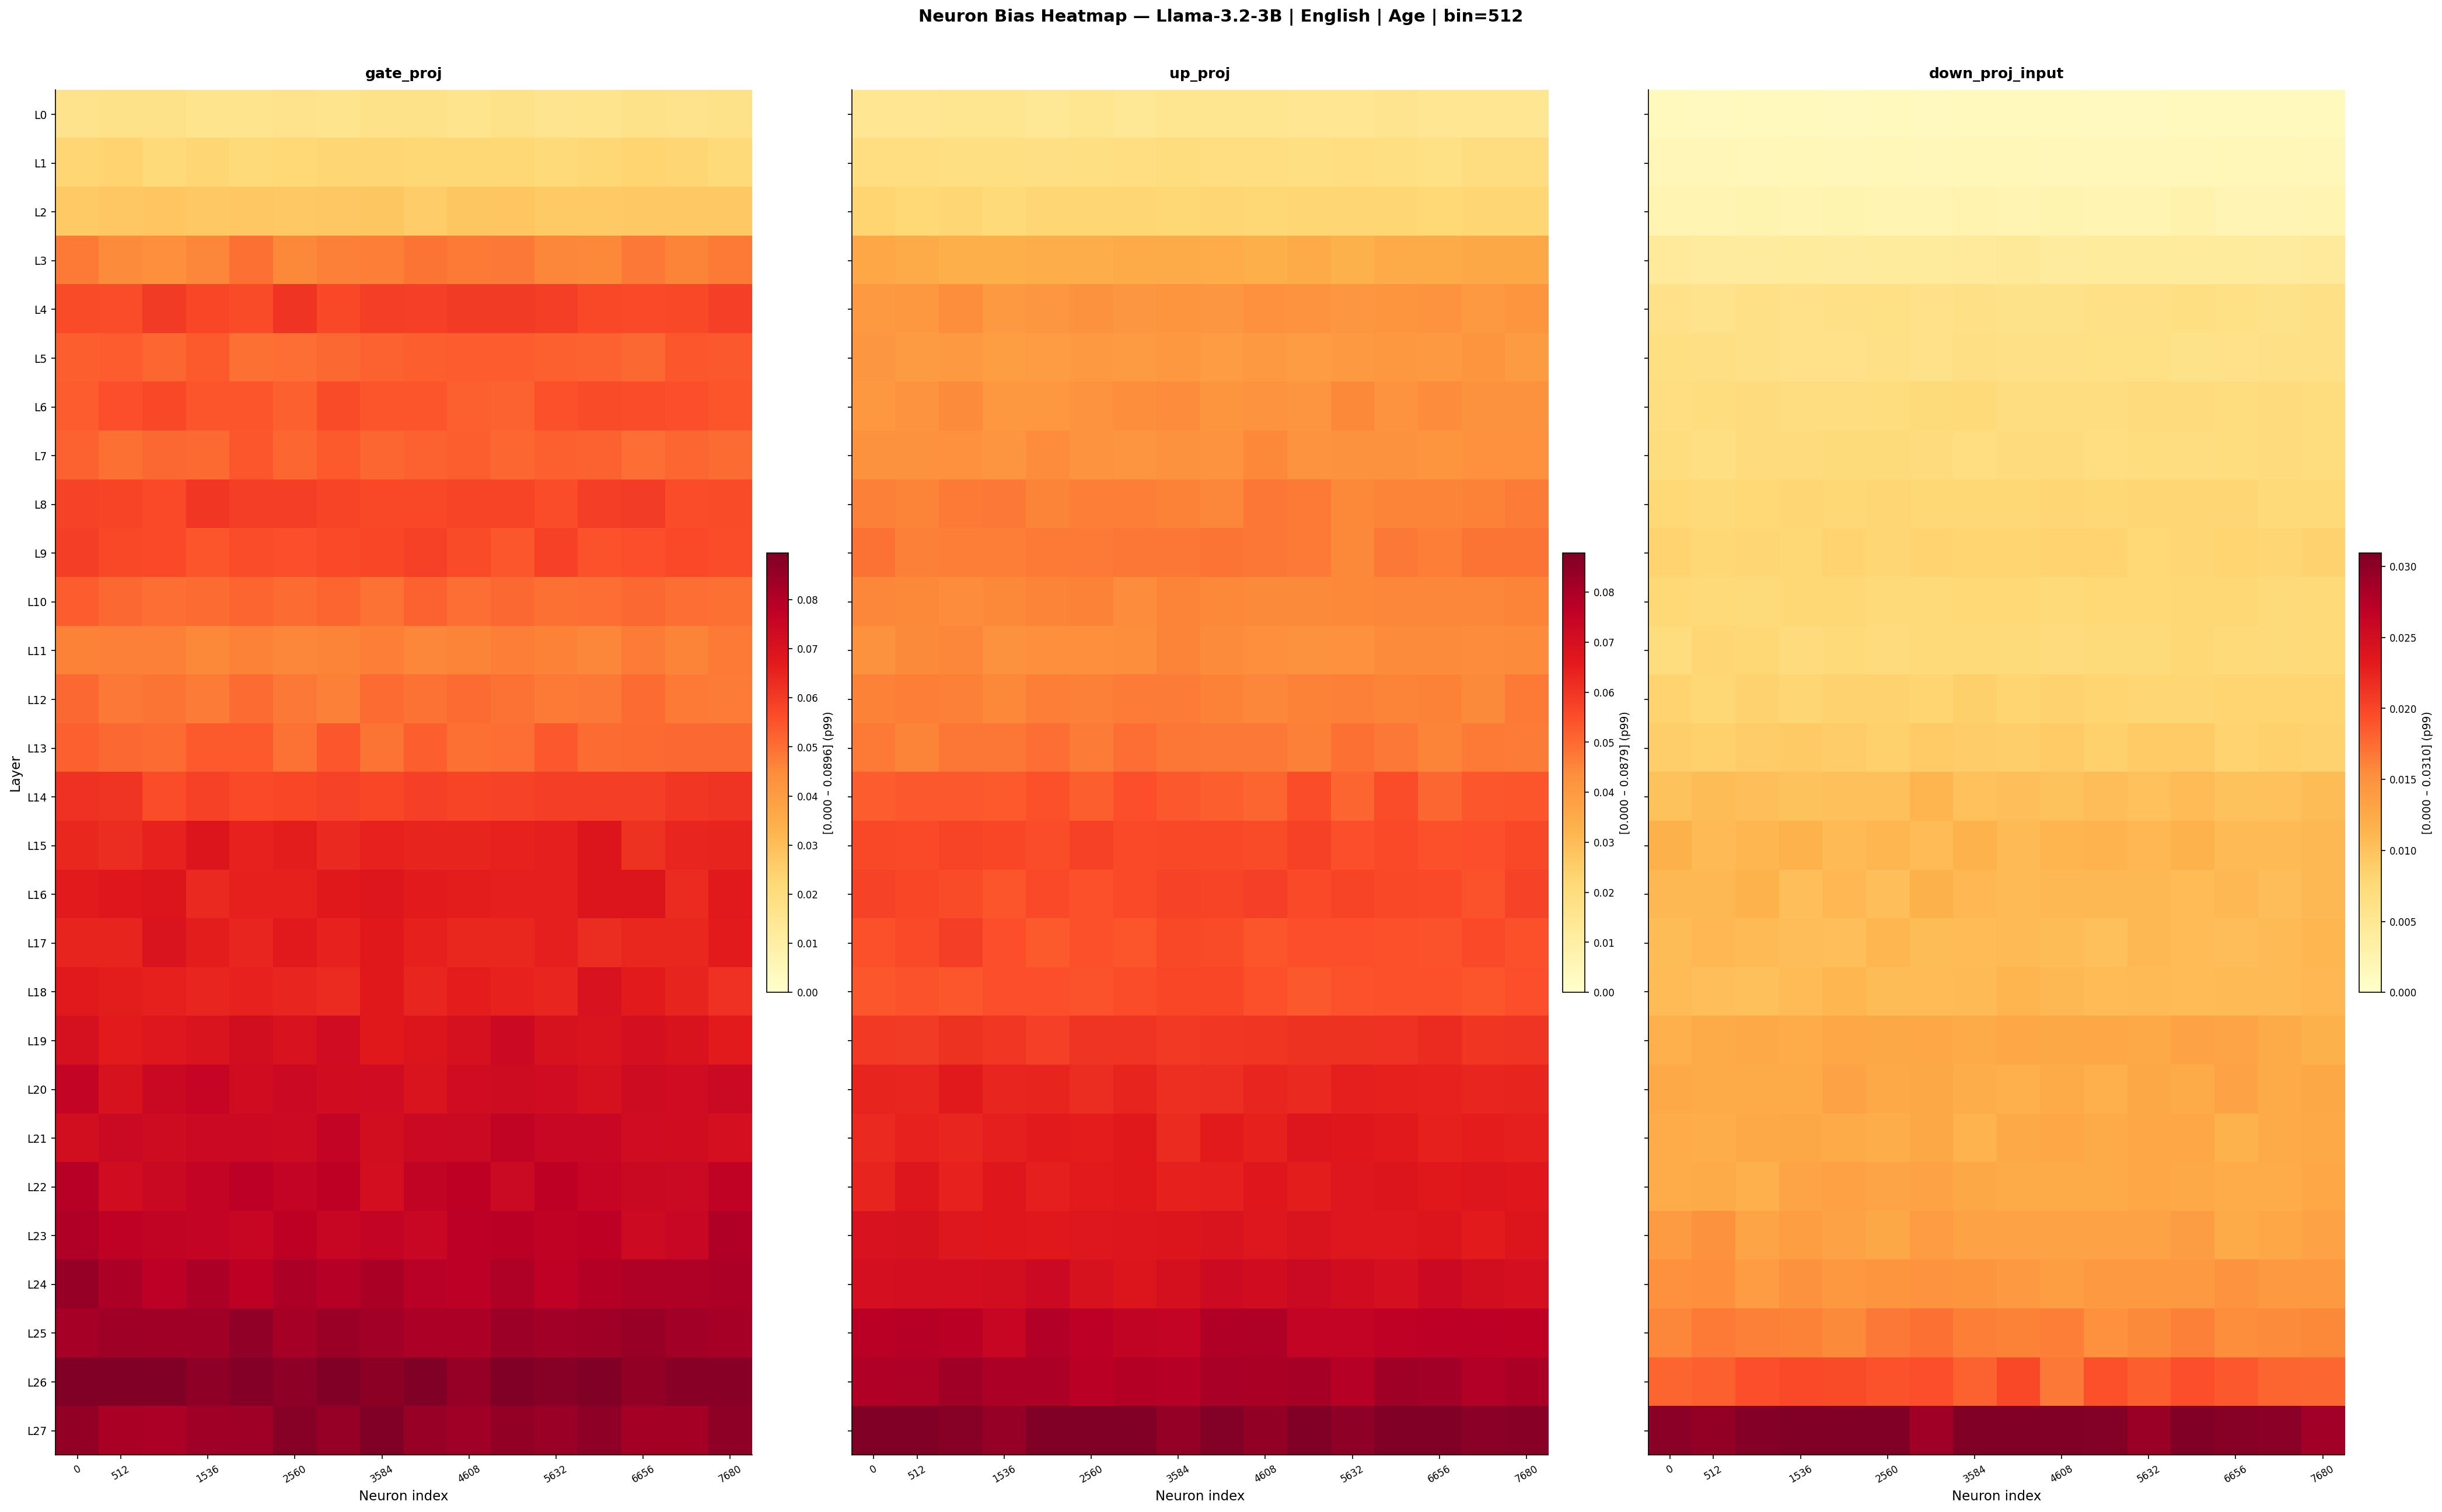


  llama-3.2-3B | EN | Gender
  gate_proj                     : vmax(p99)=0.038391 | abs max=0.040049
  up_proj                       : vmax(p99)=0.035812 | abs max=0.036872
  down_proj_input               : vmax(p99)=0.012622 | abs max=0.013578
Saved: neuron_heatmap_llama-3.2-3B_en_Gender_bin512


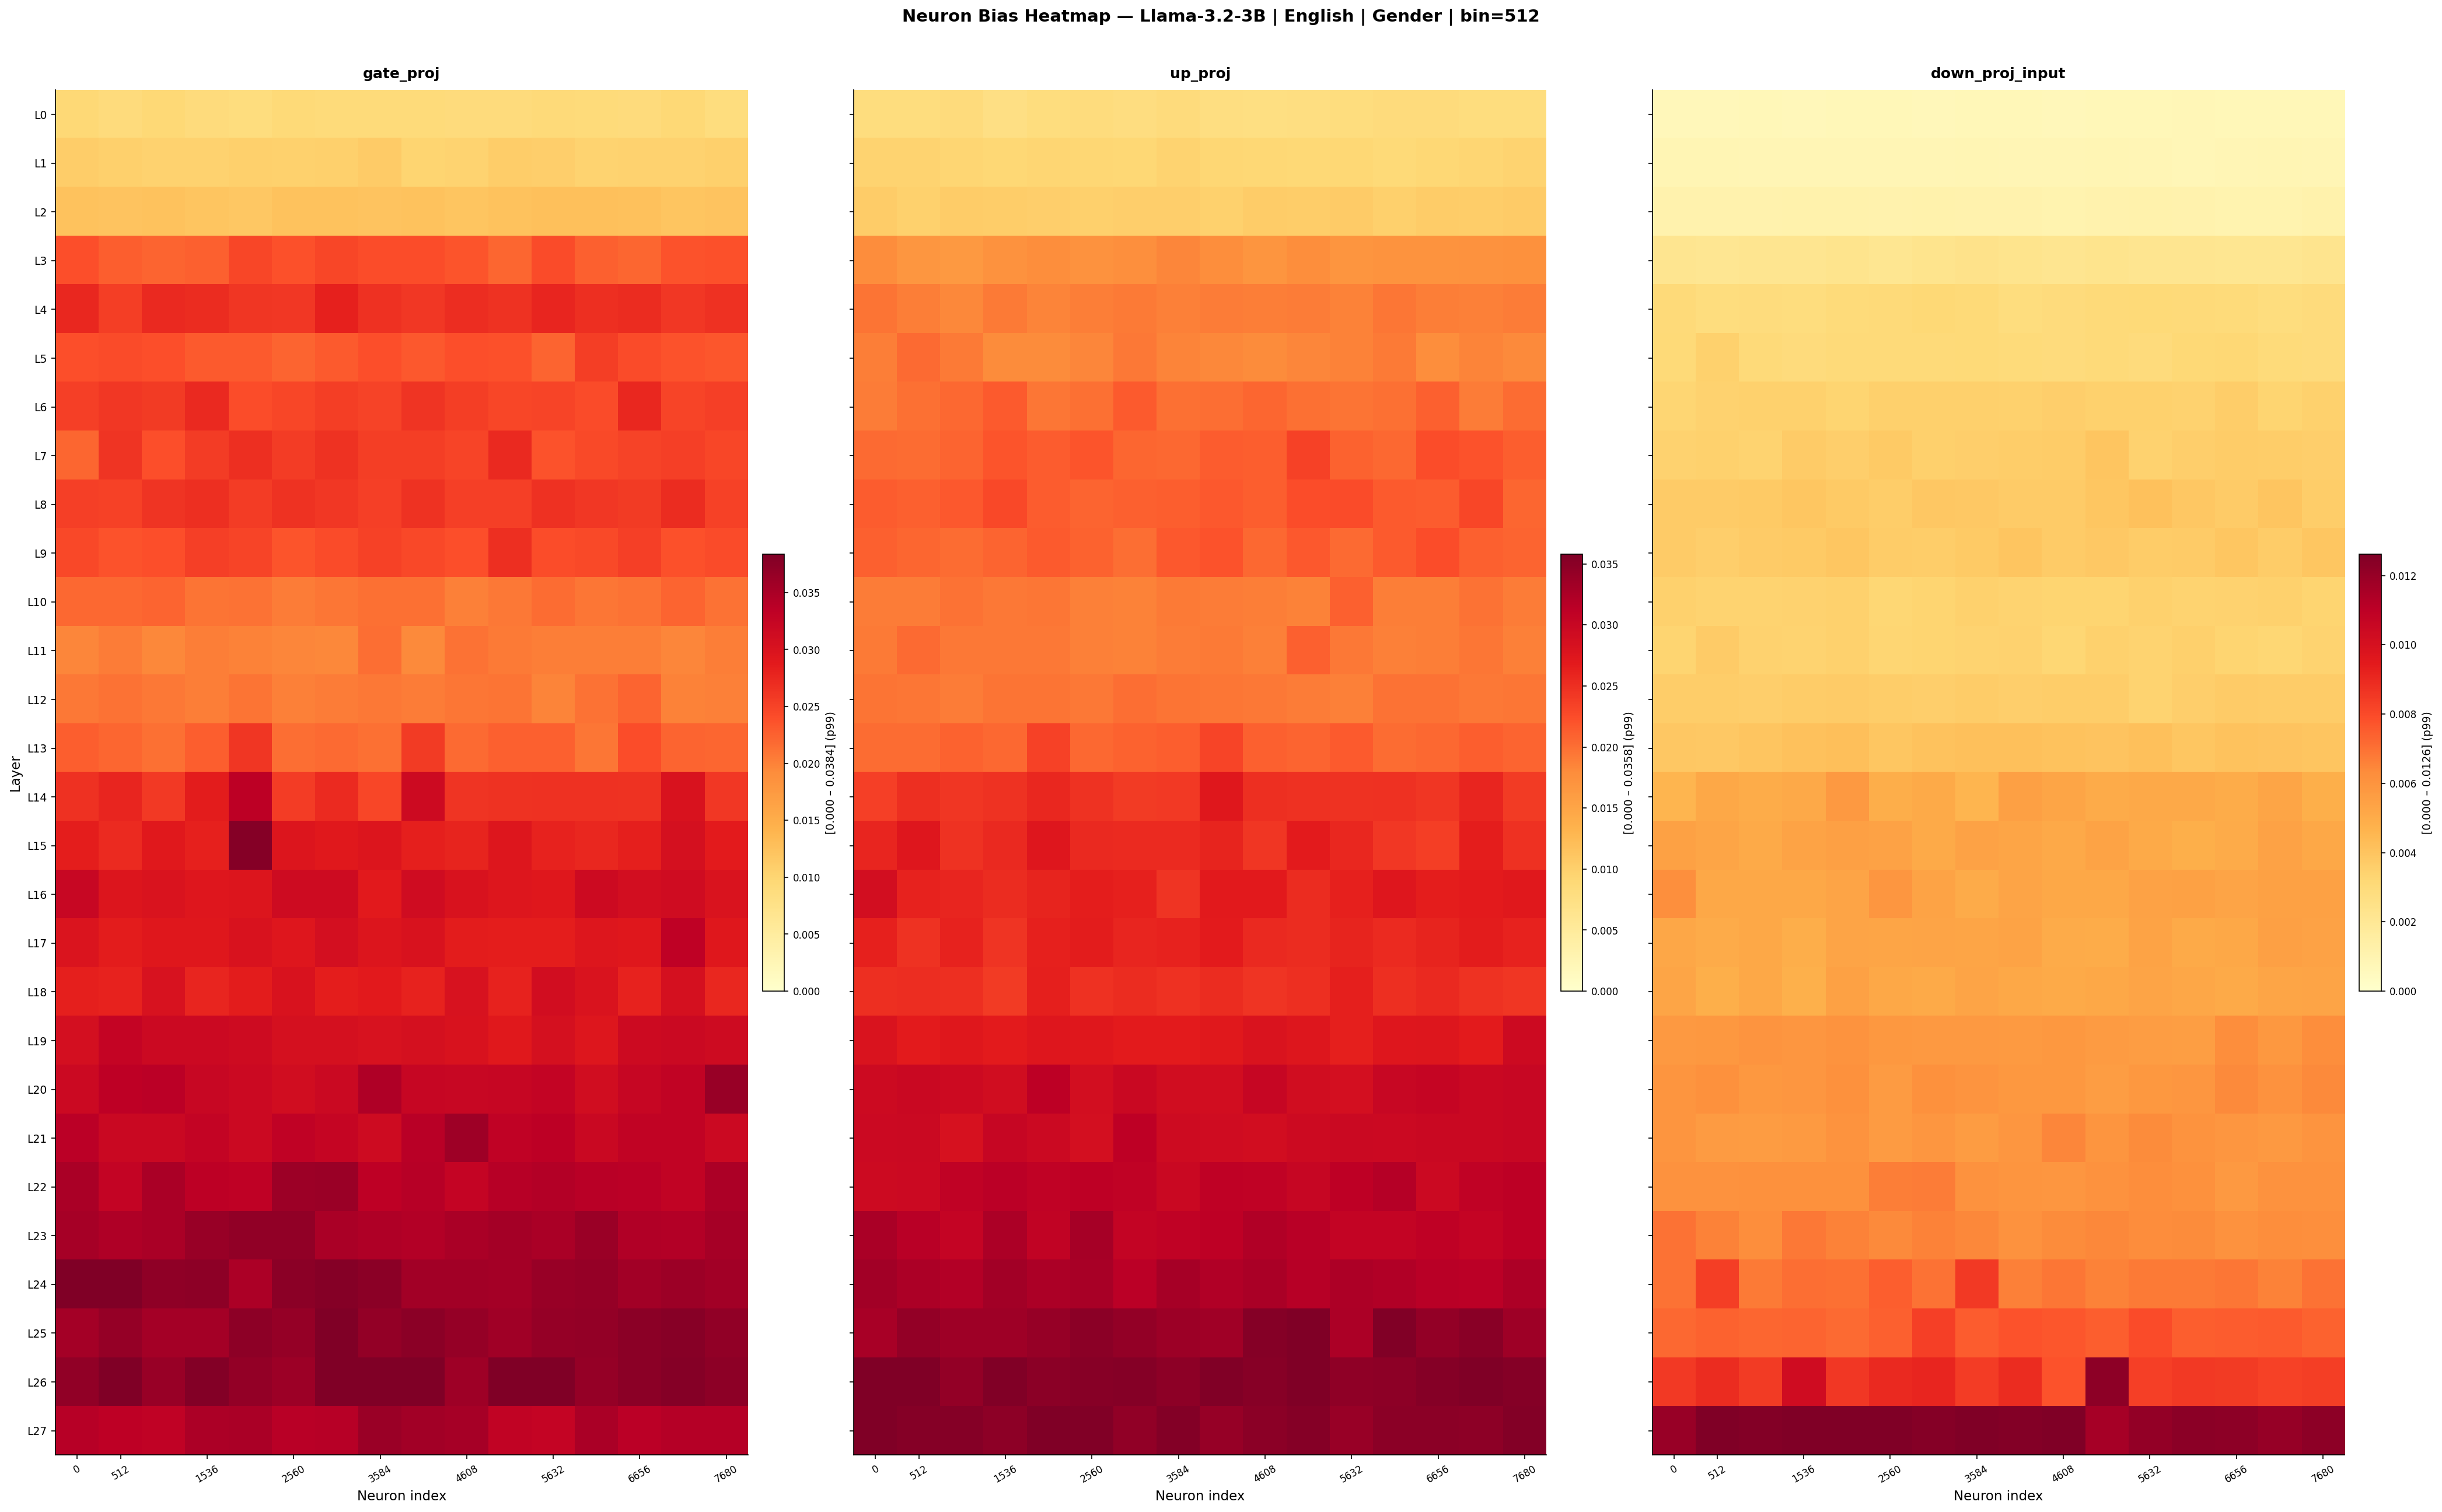


  llama-3.2-3B | EN | PhysicalAppearance
  gate_proj                     : vmax(p99)=0.057330 | abs max=0.058585
  up_proj                       : vmax(p99)=0.056742 | abs max=0.057580
  down_proj_input               : vmax(p99)=0.019870 | abs max=0.021083
Saved: neuron_heatmap_llama-3.2-3B_en_PhysicalAppearance_bin512


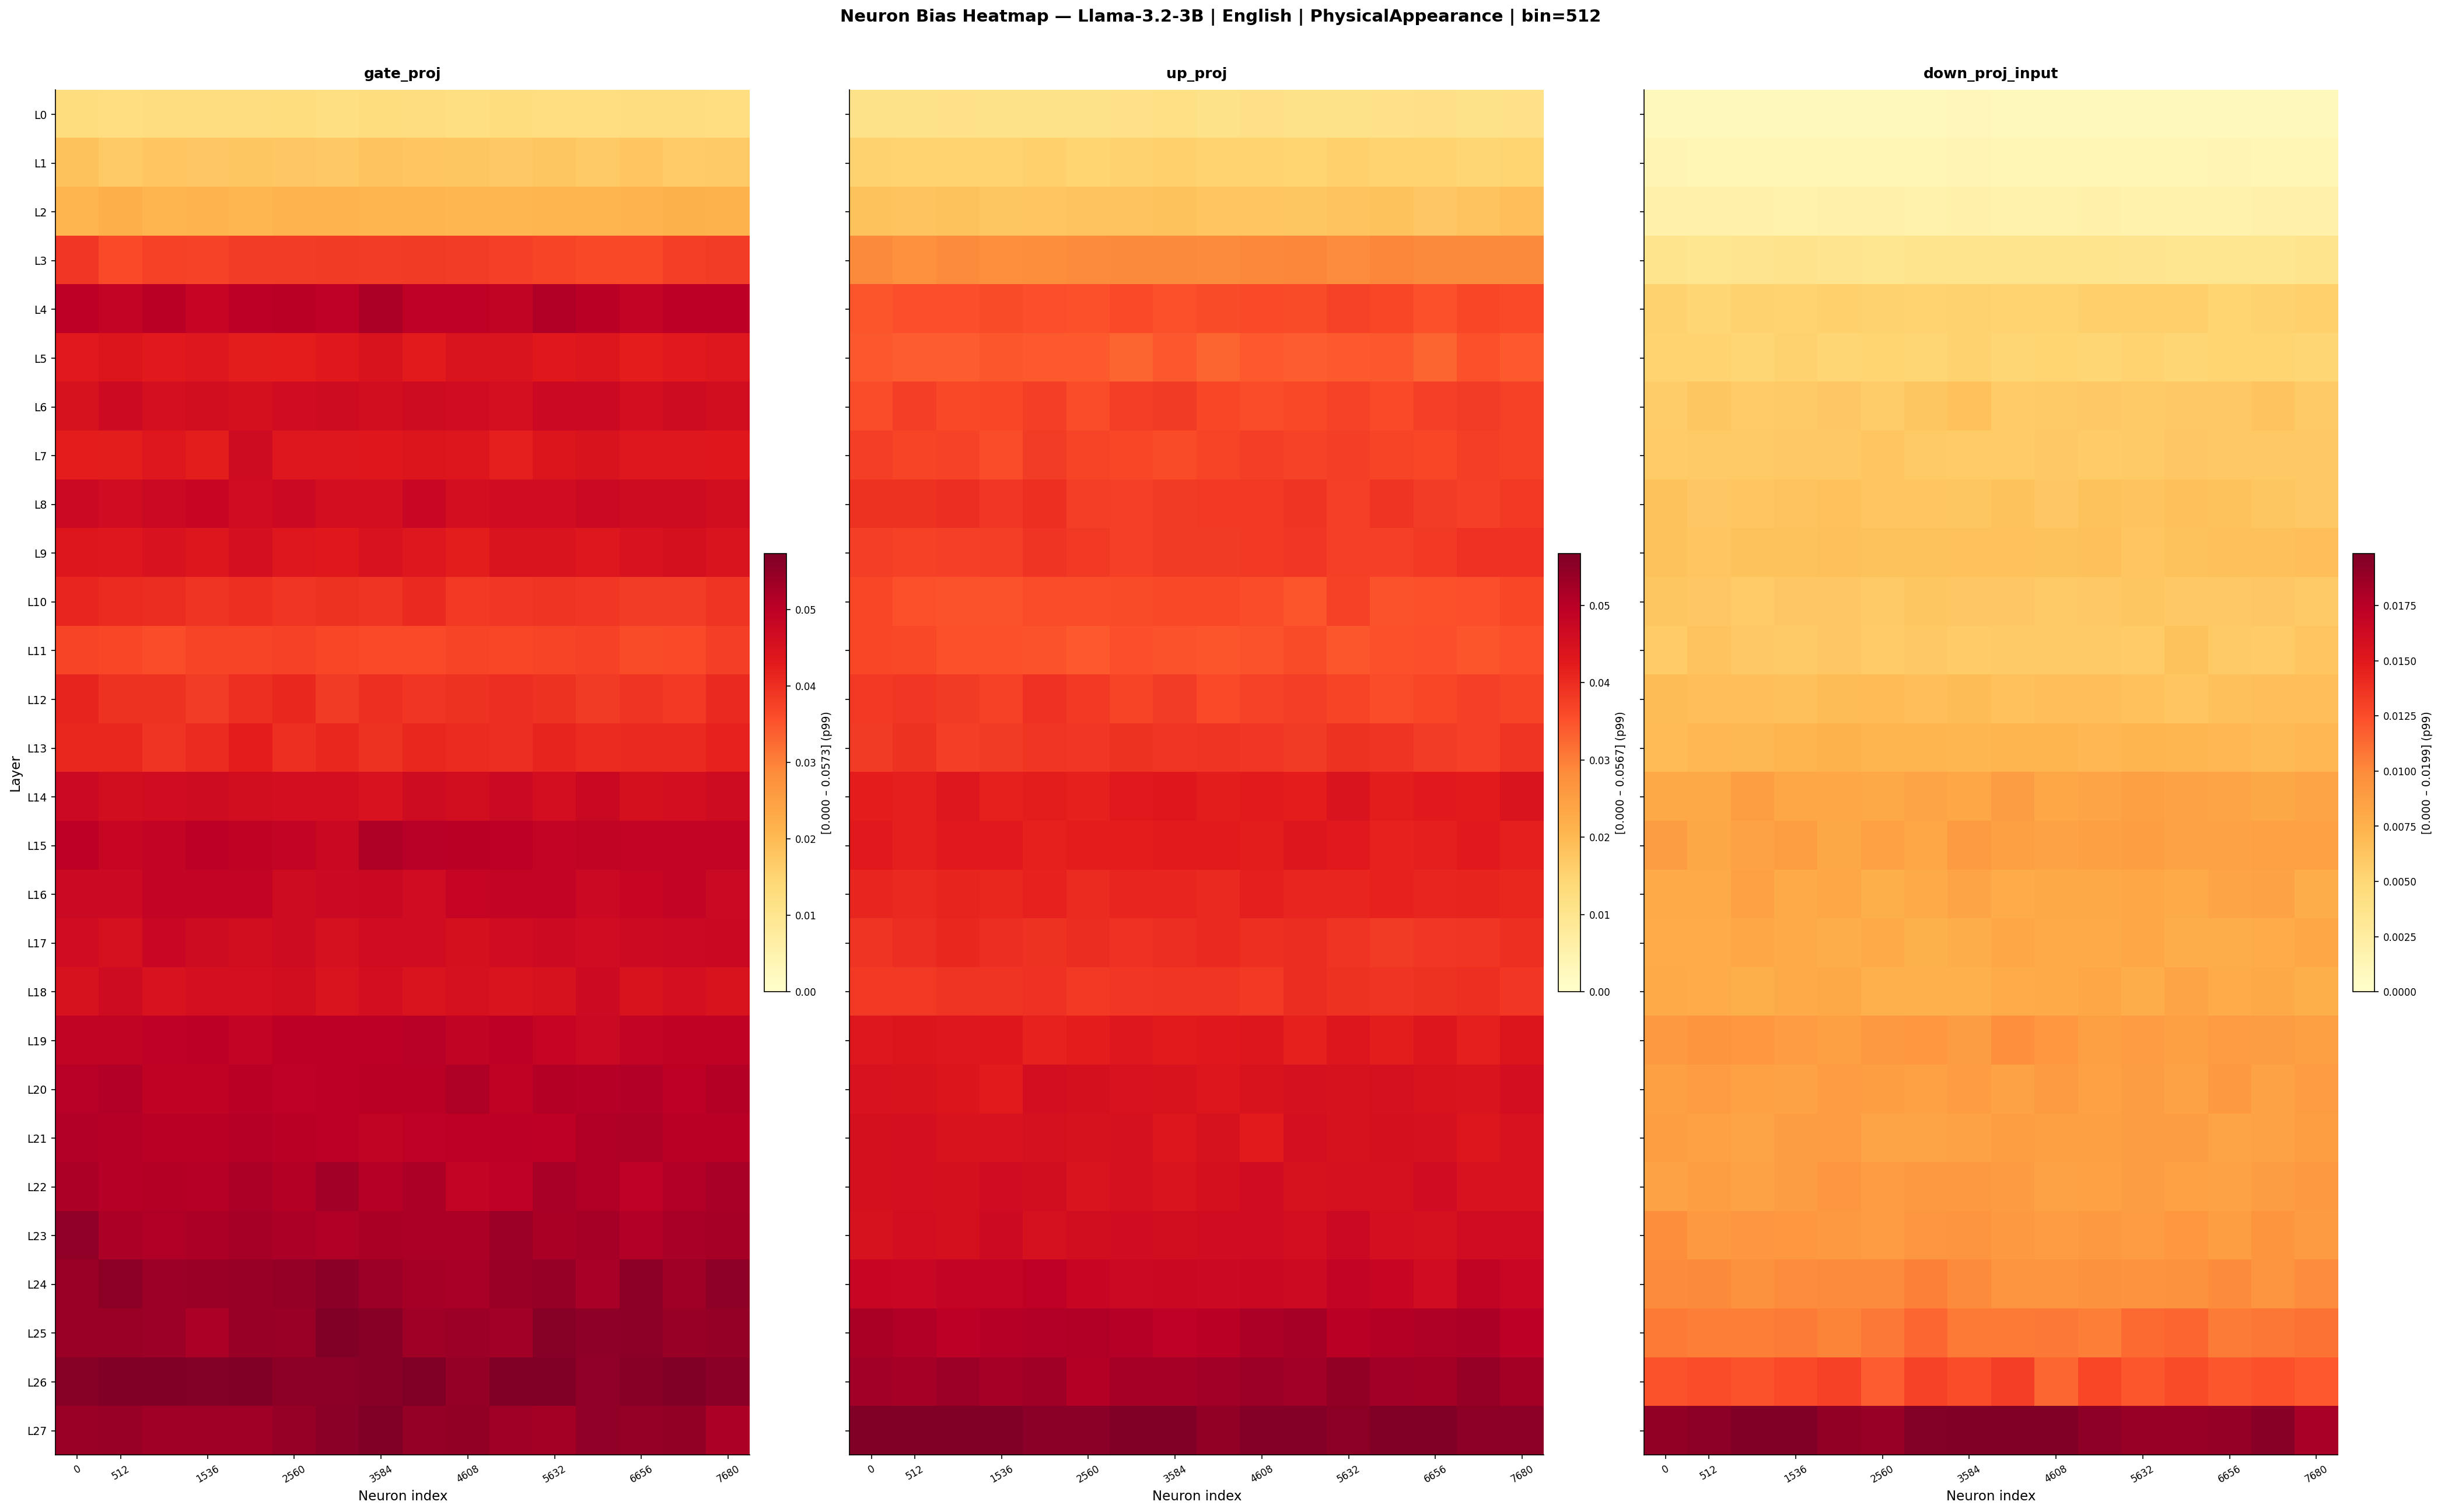


  llama-3.2-3B | EN | RaceEthnicity
  gate_proj                     : vmax(p99)=0.077805 | abs max=0.080705
  up_proj                       : vmax(p99)=0.079314 | abs max=0.080204
  down_proj_input               : vmax(p99)=0.028194 | abs max=0.031169
Saved: neuron_heatmap_llama-3.2-3B_en_RaceEthnicity_bin512


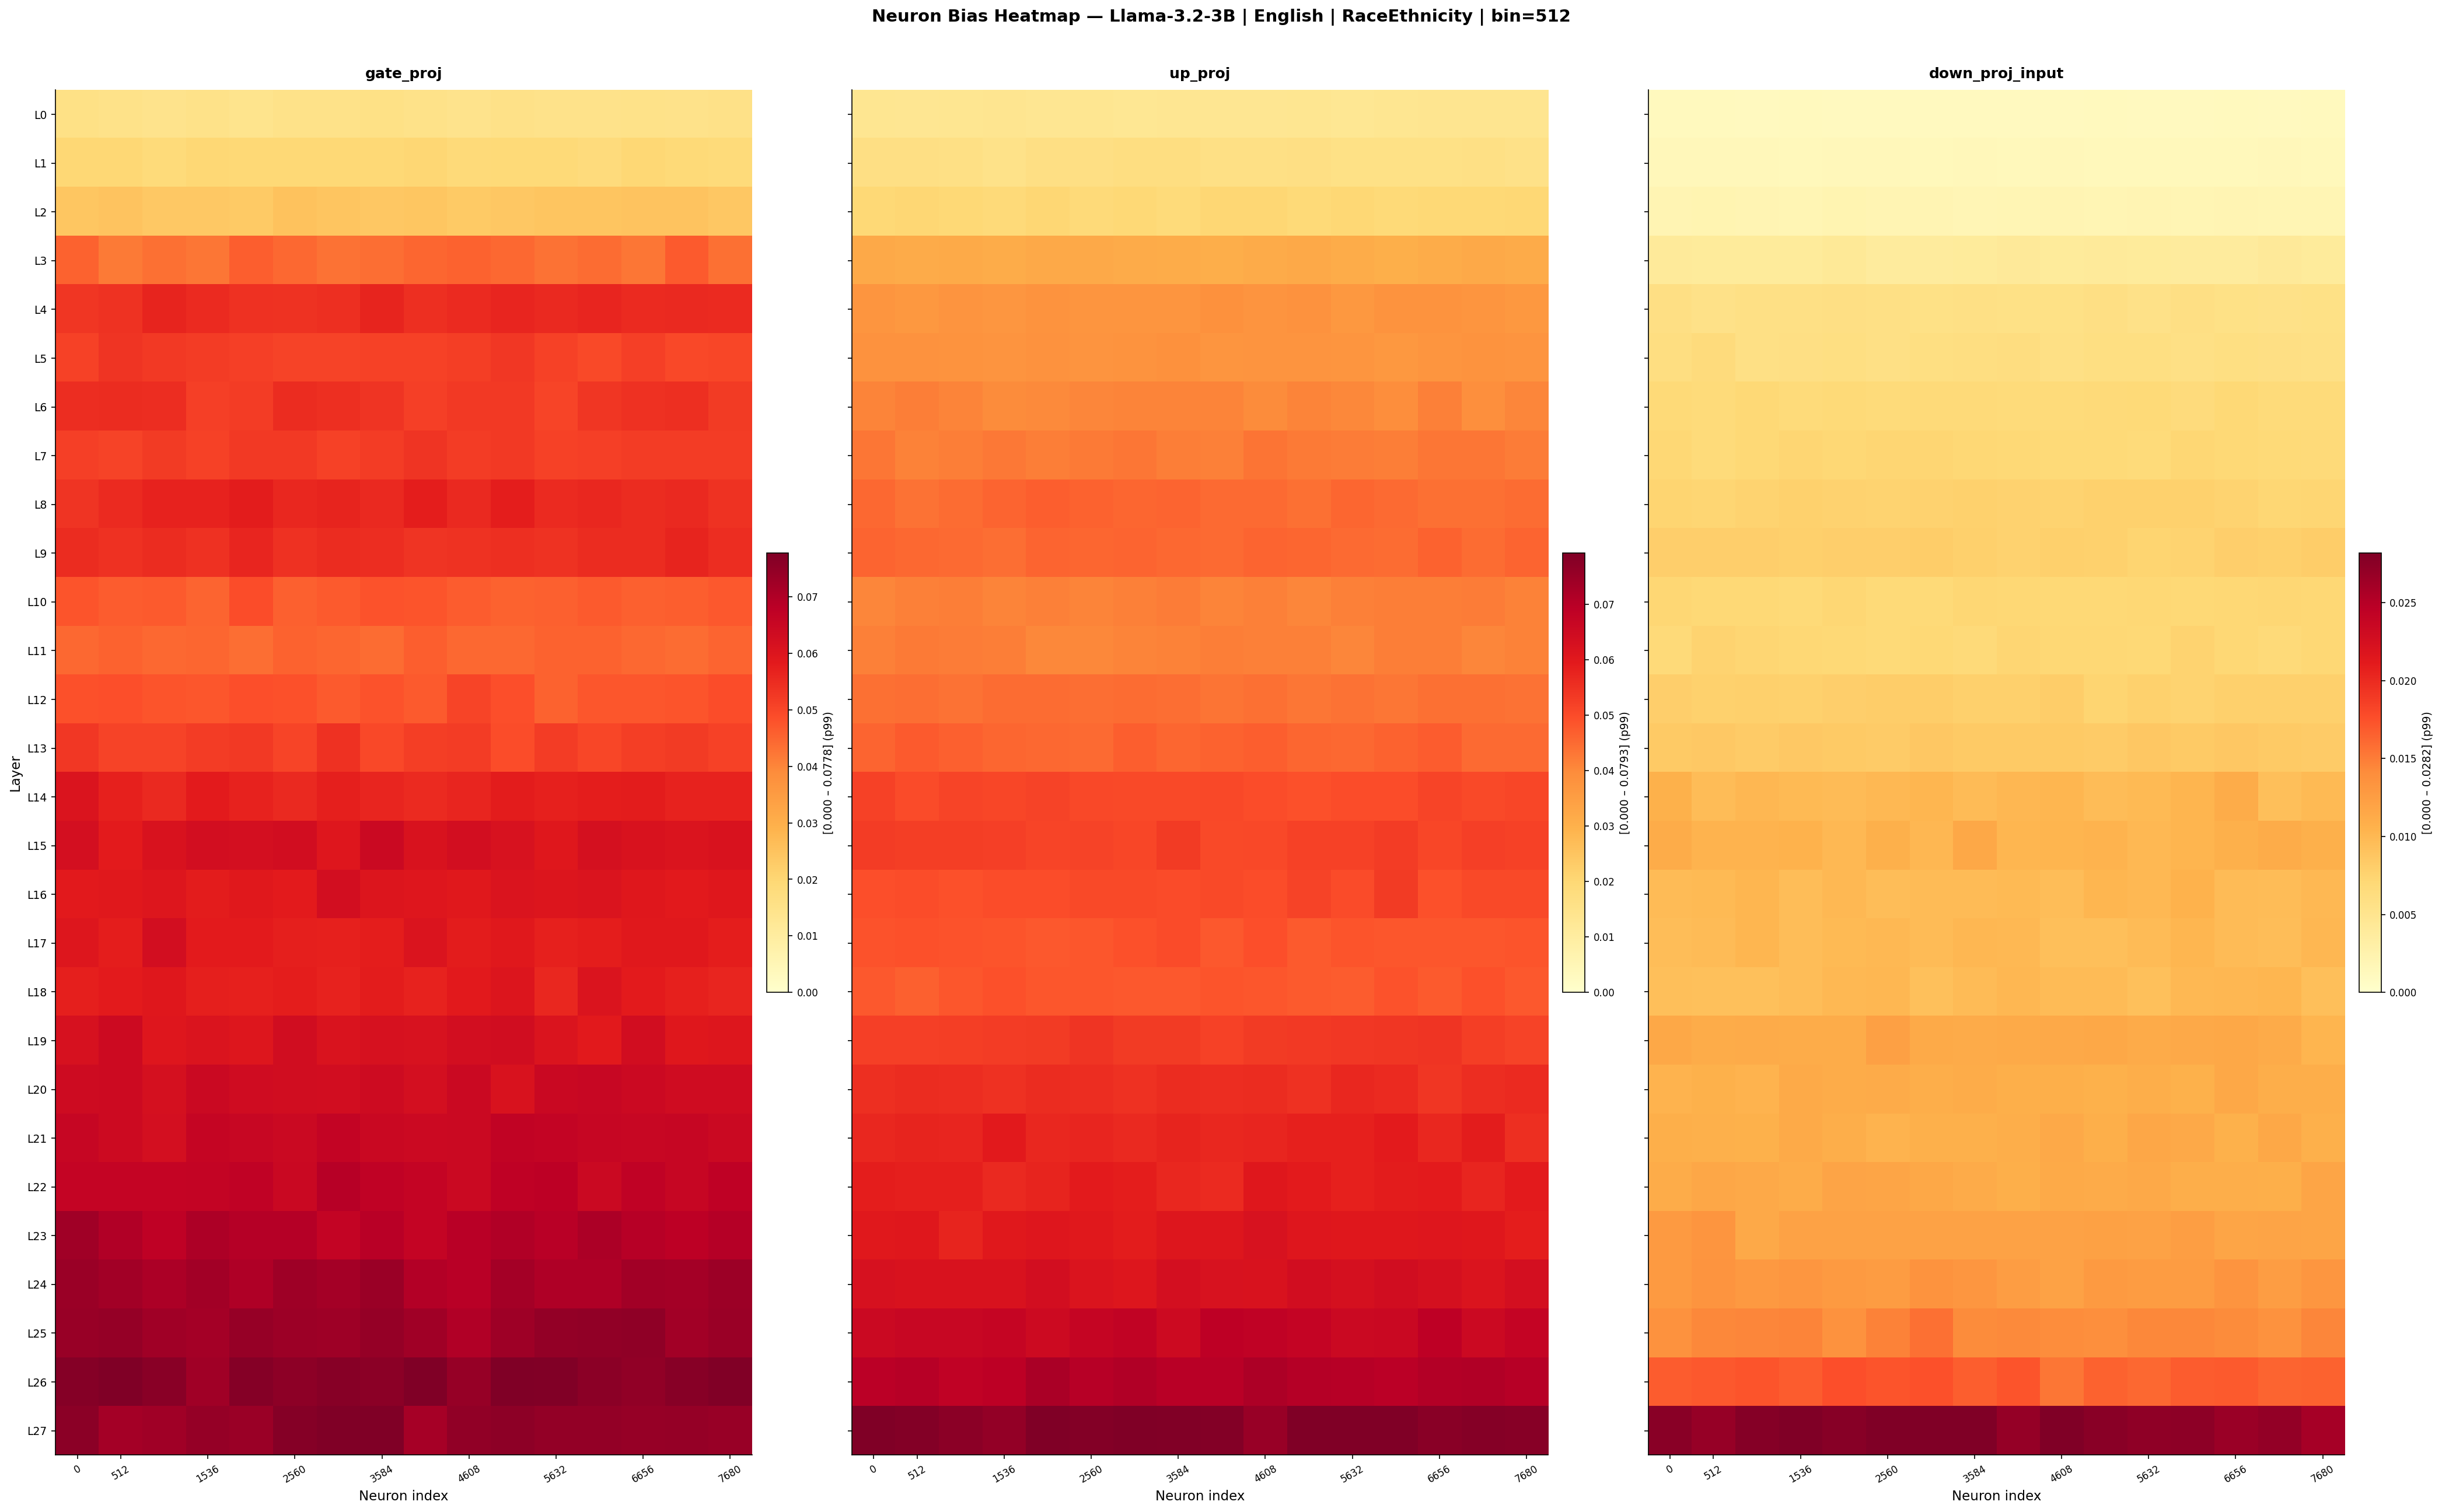


  llama-3.2-3B | EN | Religion
  gate_proj                     : vmax(p99)=0.092486 | abs max=0.096426
  up_proj                       : vmax(p99)=0.090183 | abs max=0.092225
  down_proj_input               : vmax(p99)=0.030400 | abs max=0.031327
Saved: neuron_heatmap_llama-3.2-3B_en_Religion_bin512


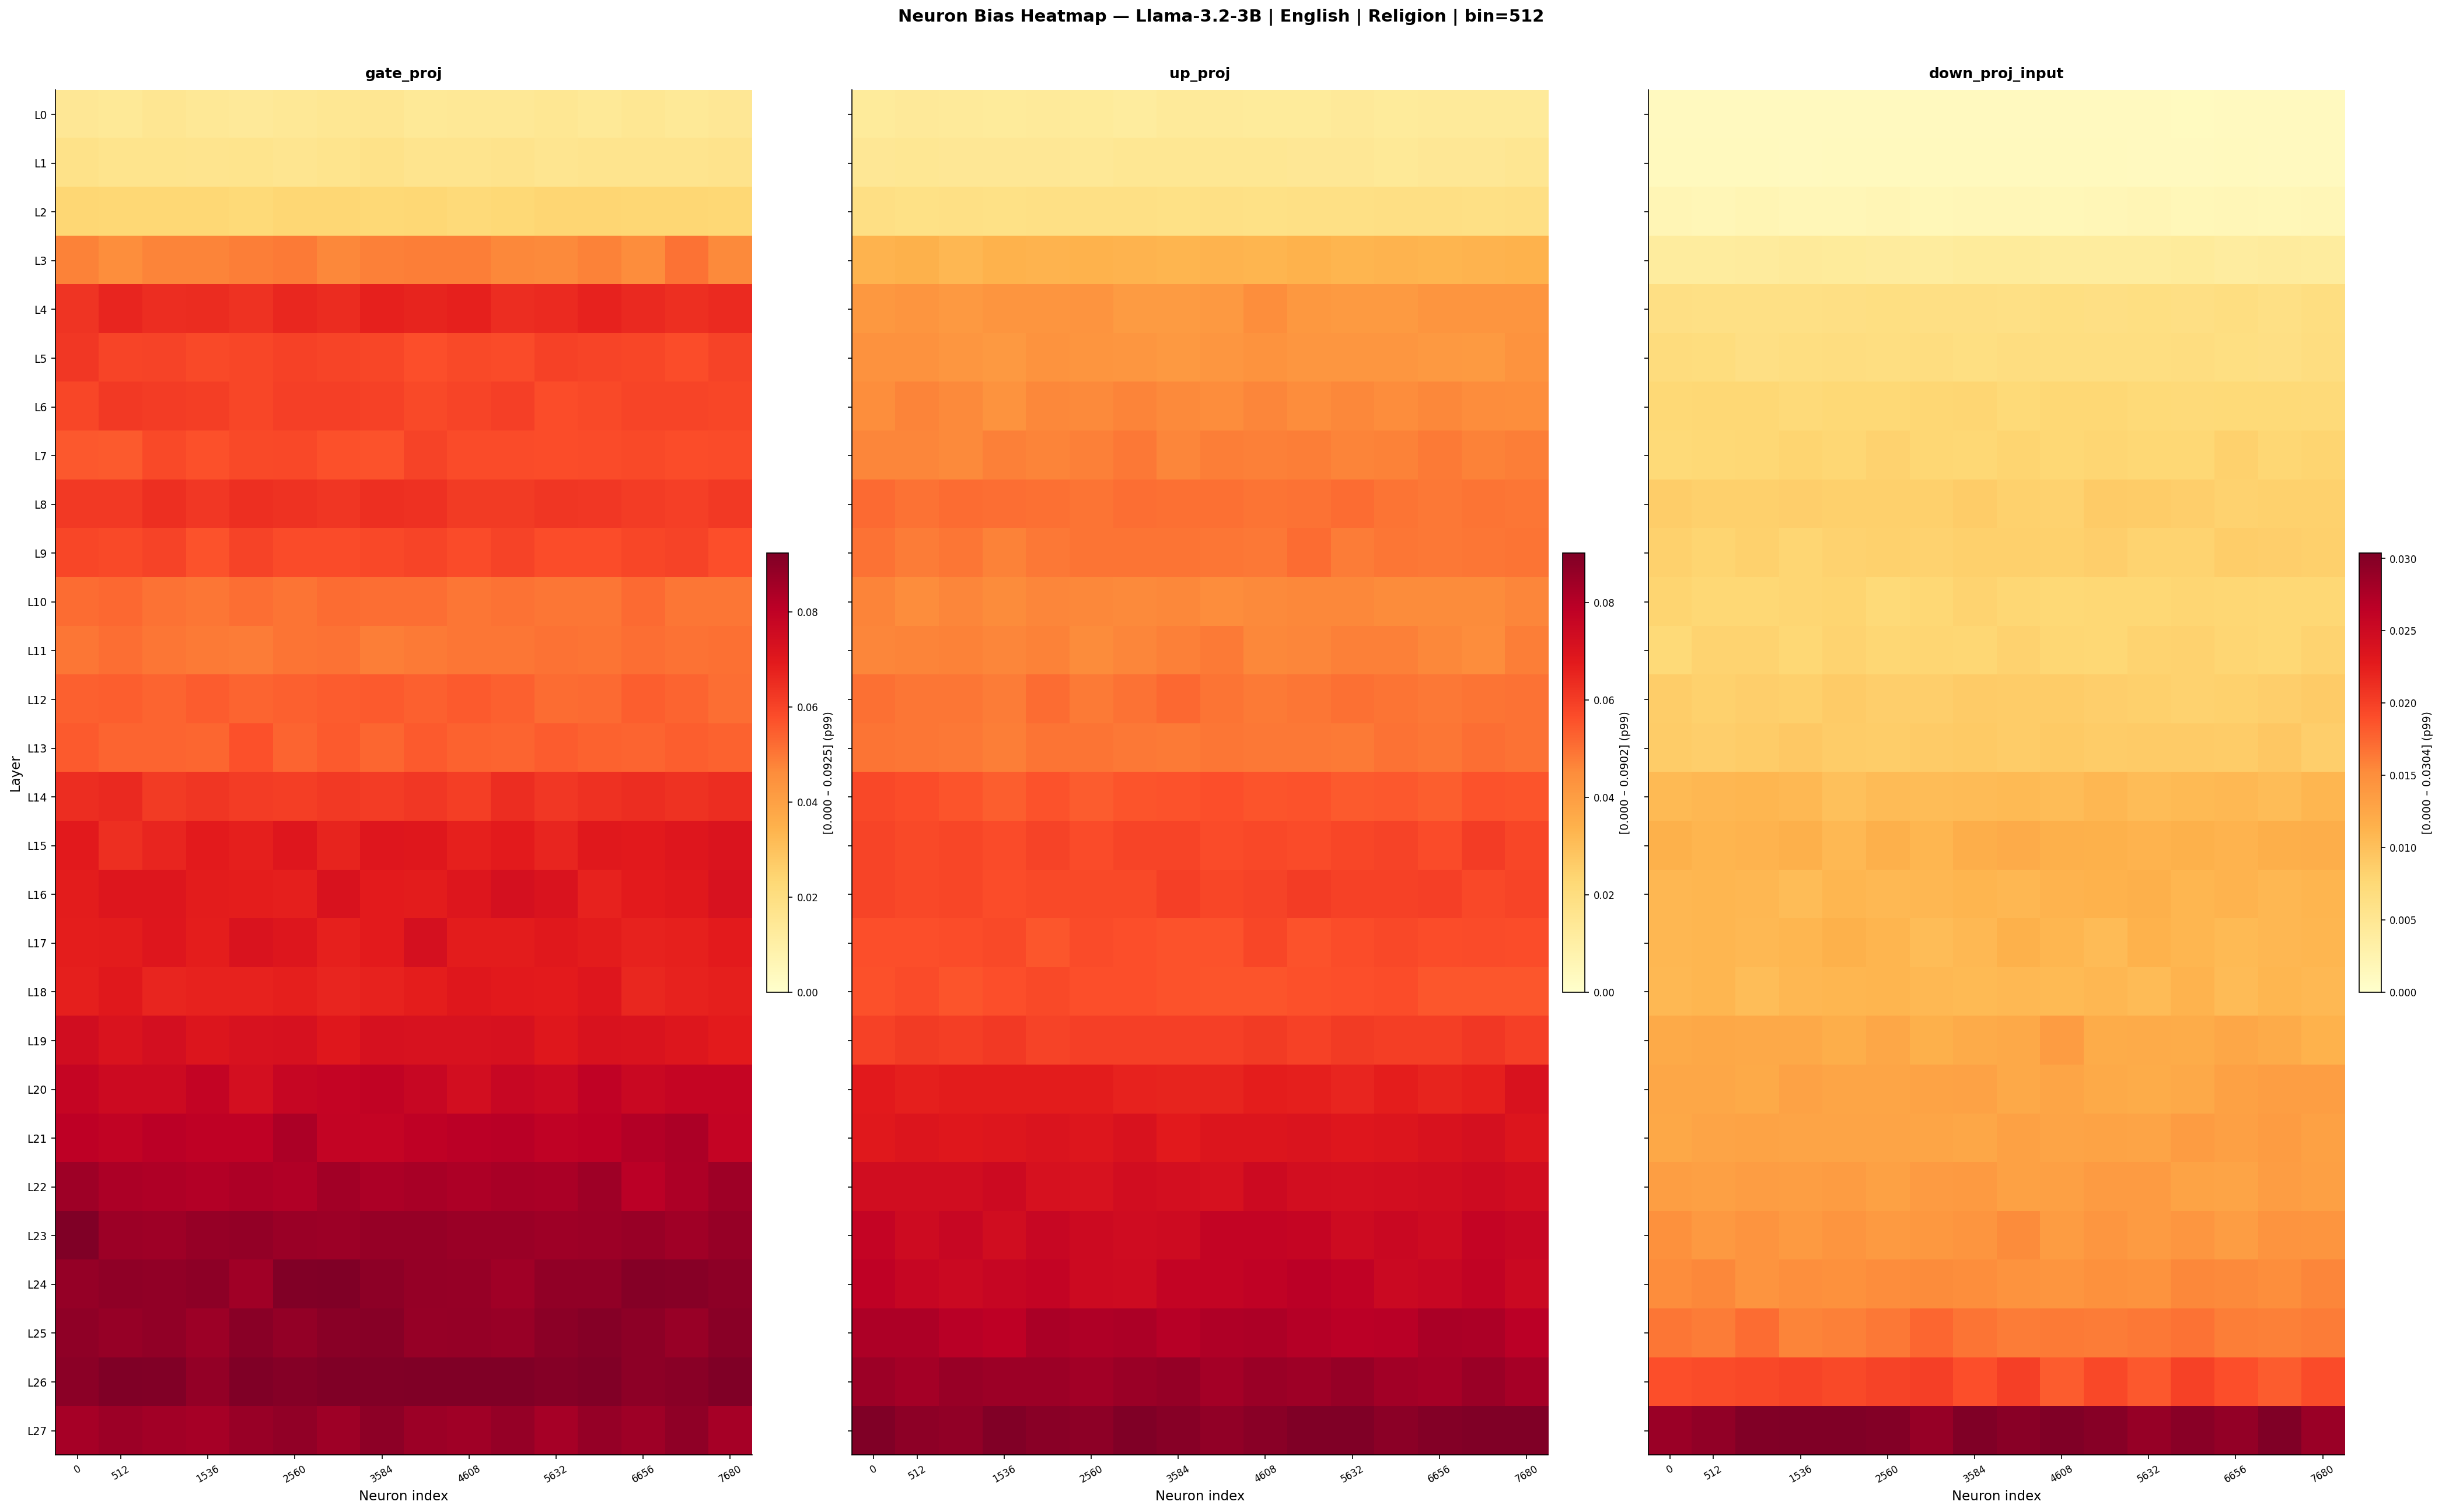


  llama-3.2-3B | ES | Age
  gate_proj                     : vmax(p99)=0.040841 | abs max=0.041532
  up_proj                       : vmax(p99)=0.034664 | abs max=0.036131
  down_proj_input               : vmax(p99)=0.014099 | abs max=0.014483
Saved: neuron_heatmap_llama-3.2-3B_es_Age_bin512


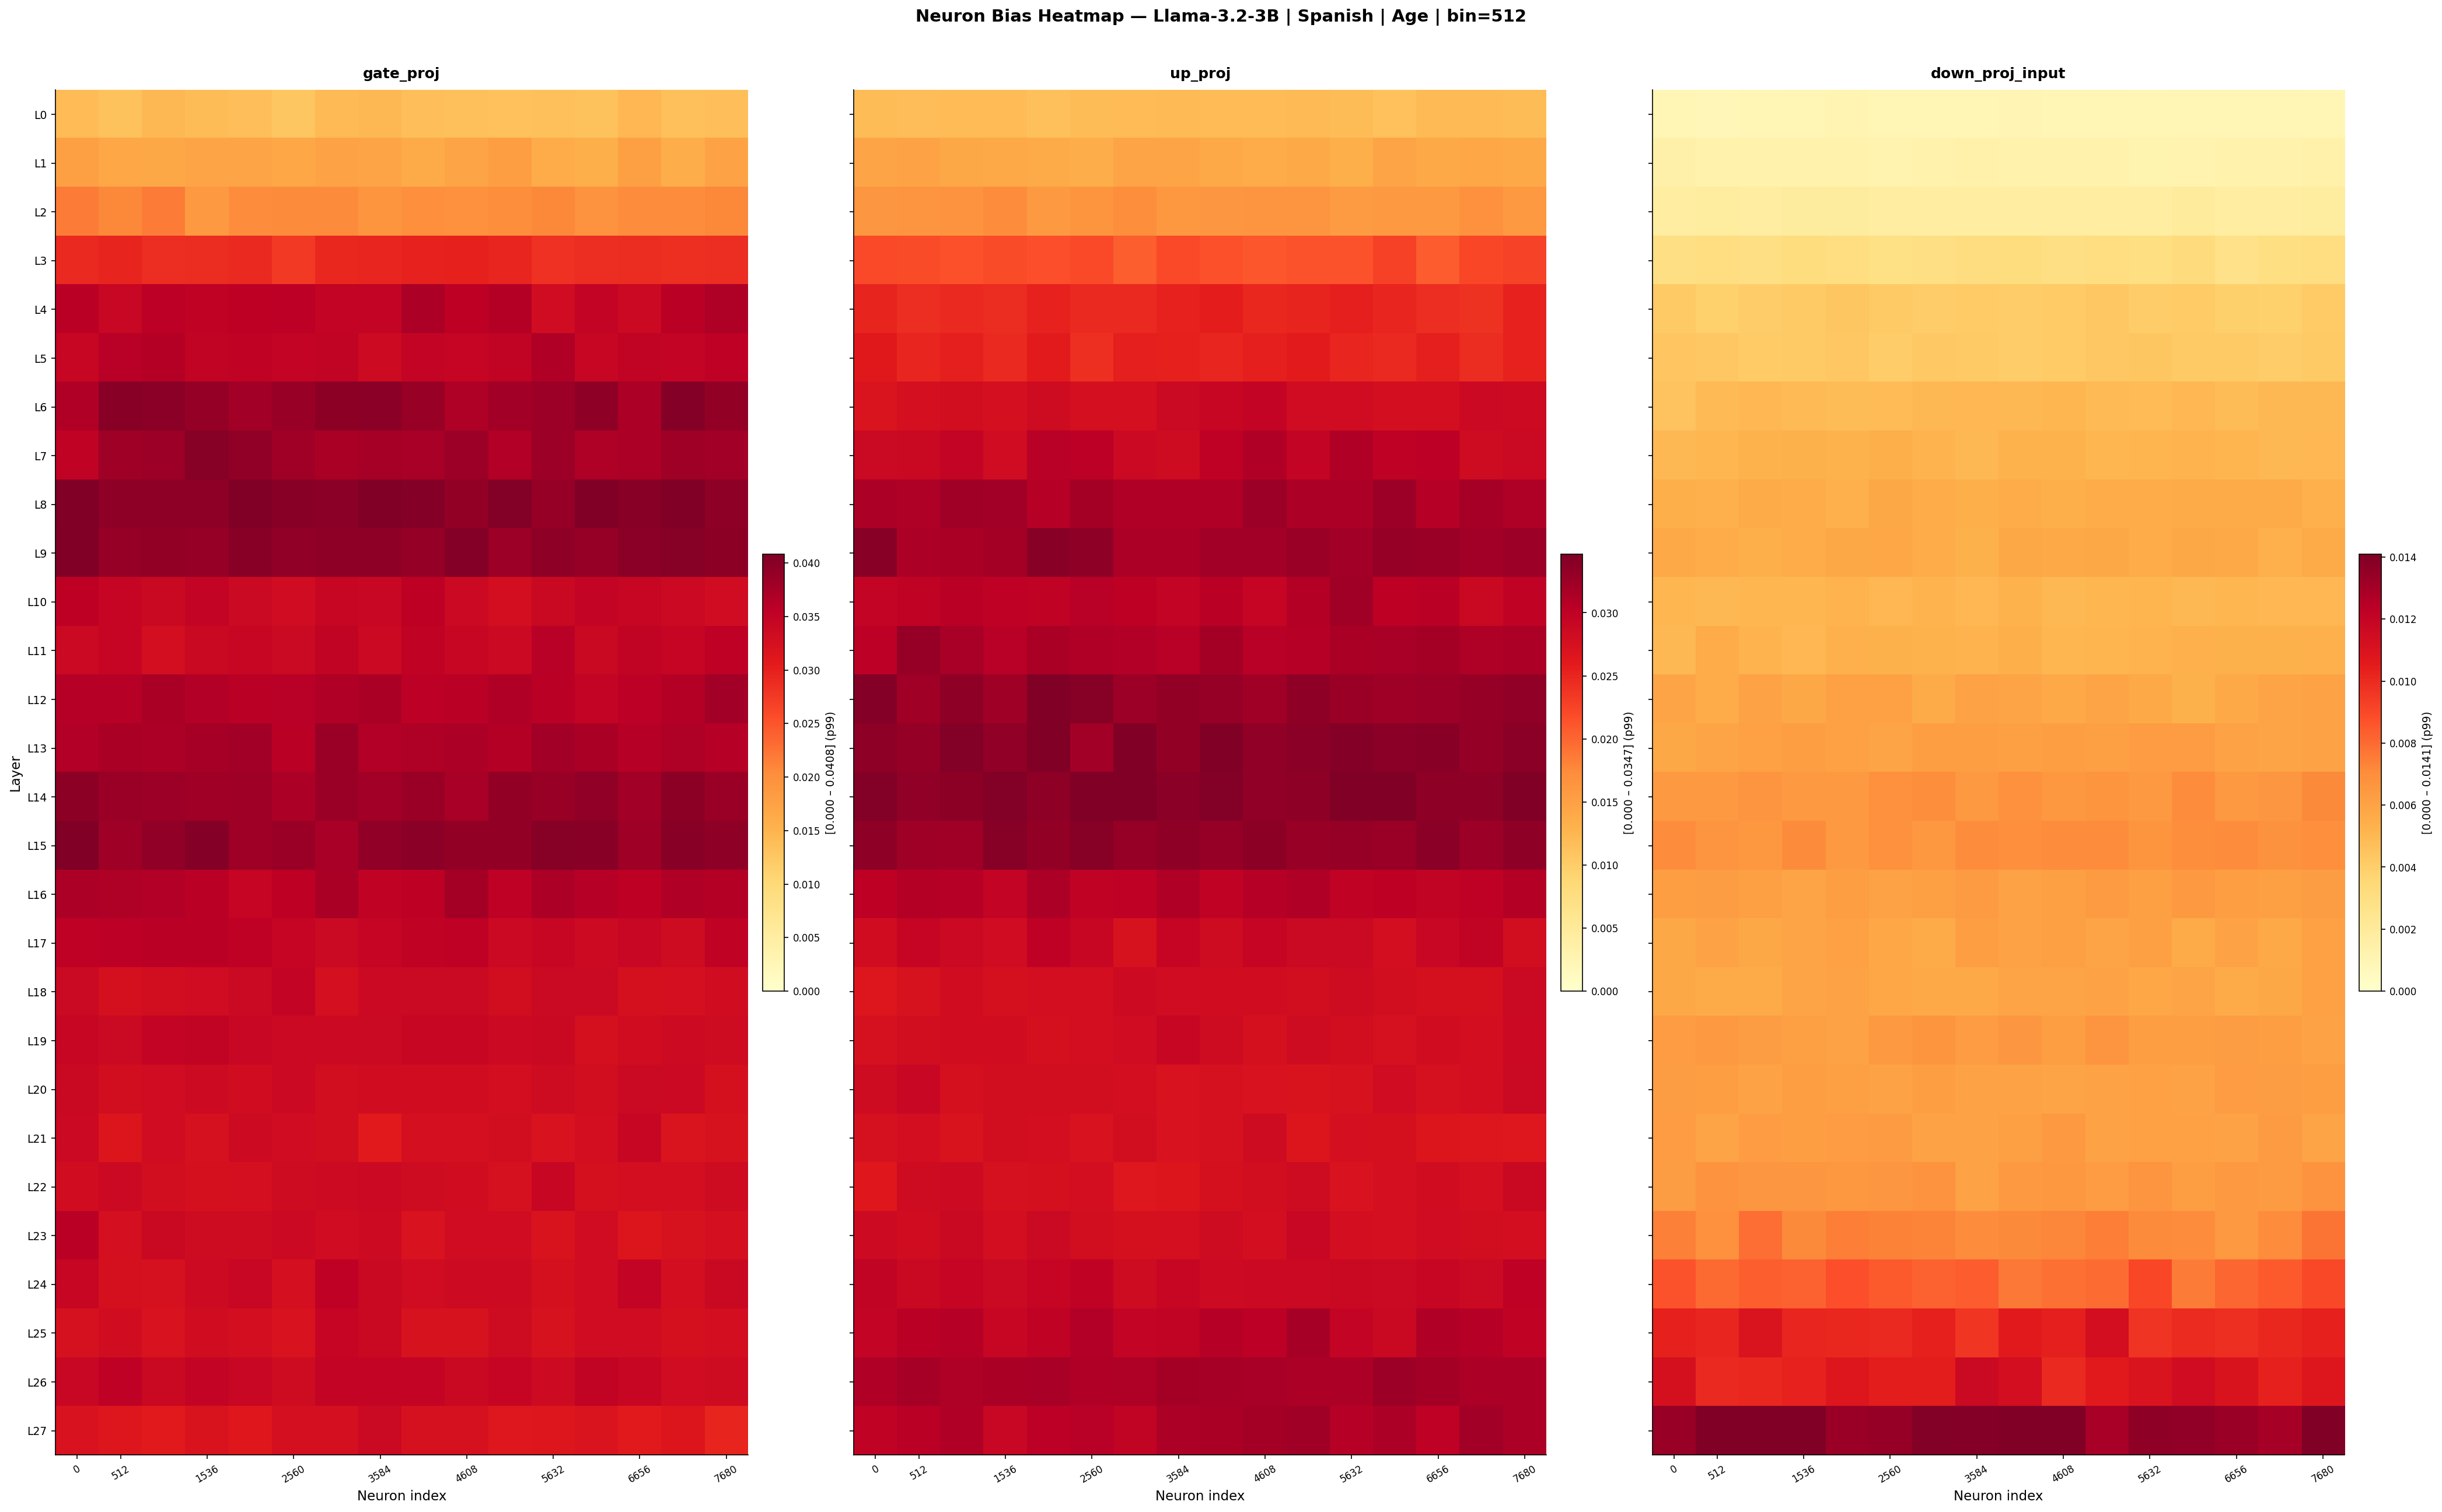


  llama-3.2-3B | ES | Gender
  gate_proj                     : vmax(p99)=0.057474 | abs max=0.060083
  up_proj                       : vmax(p99)=0.053355 | abs max=0.054939
  down_proj_input               : vmax(p99)=0.022745 | abs max=0.023409
Saved: neuron_heatmap_llama-3.2-3B_es_Gender_bin512


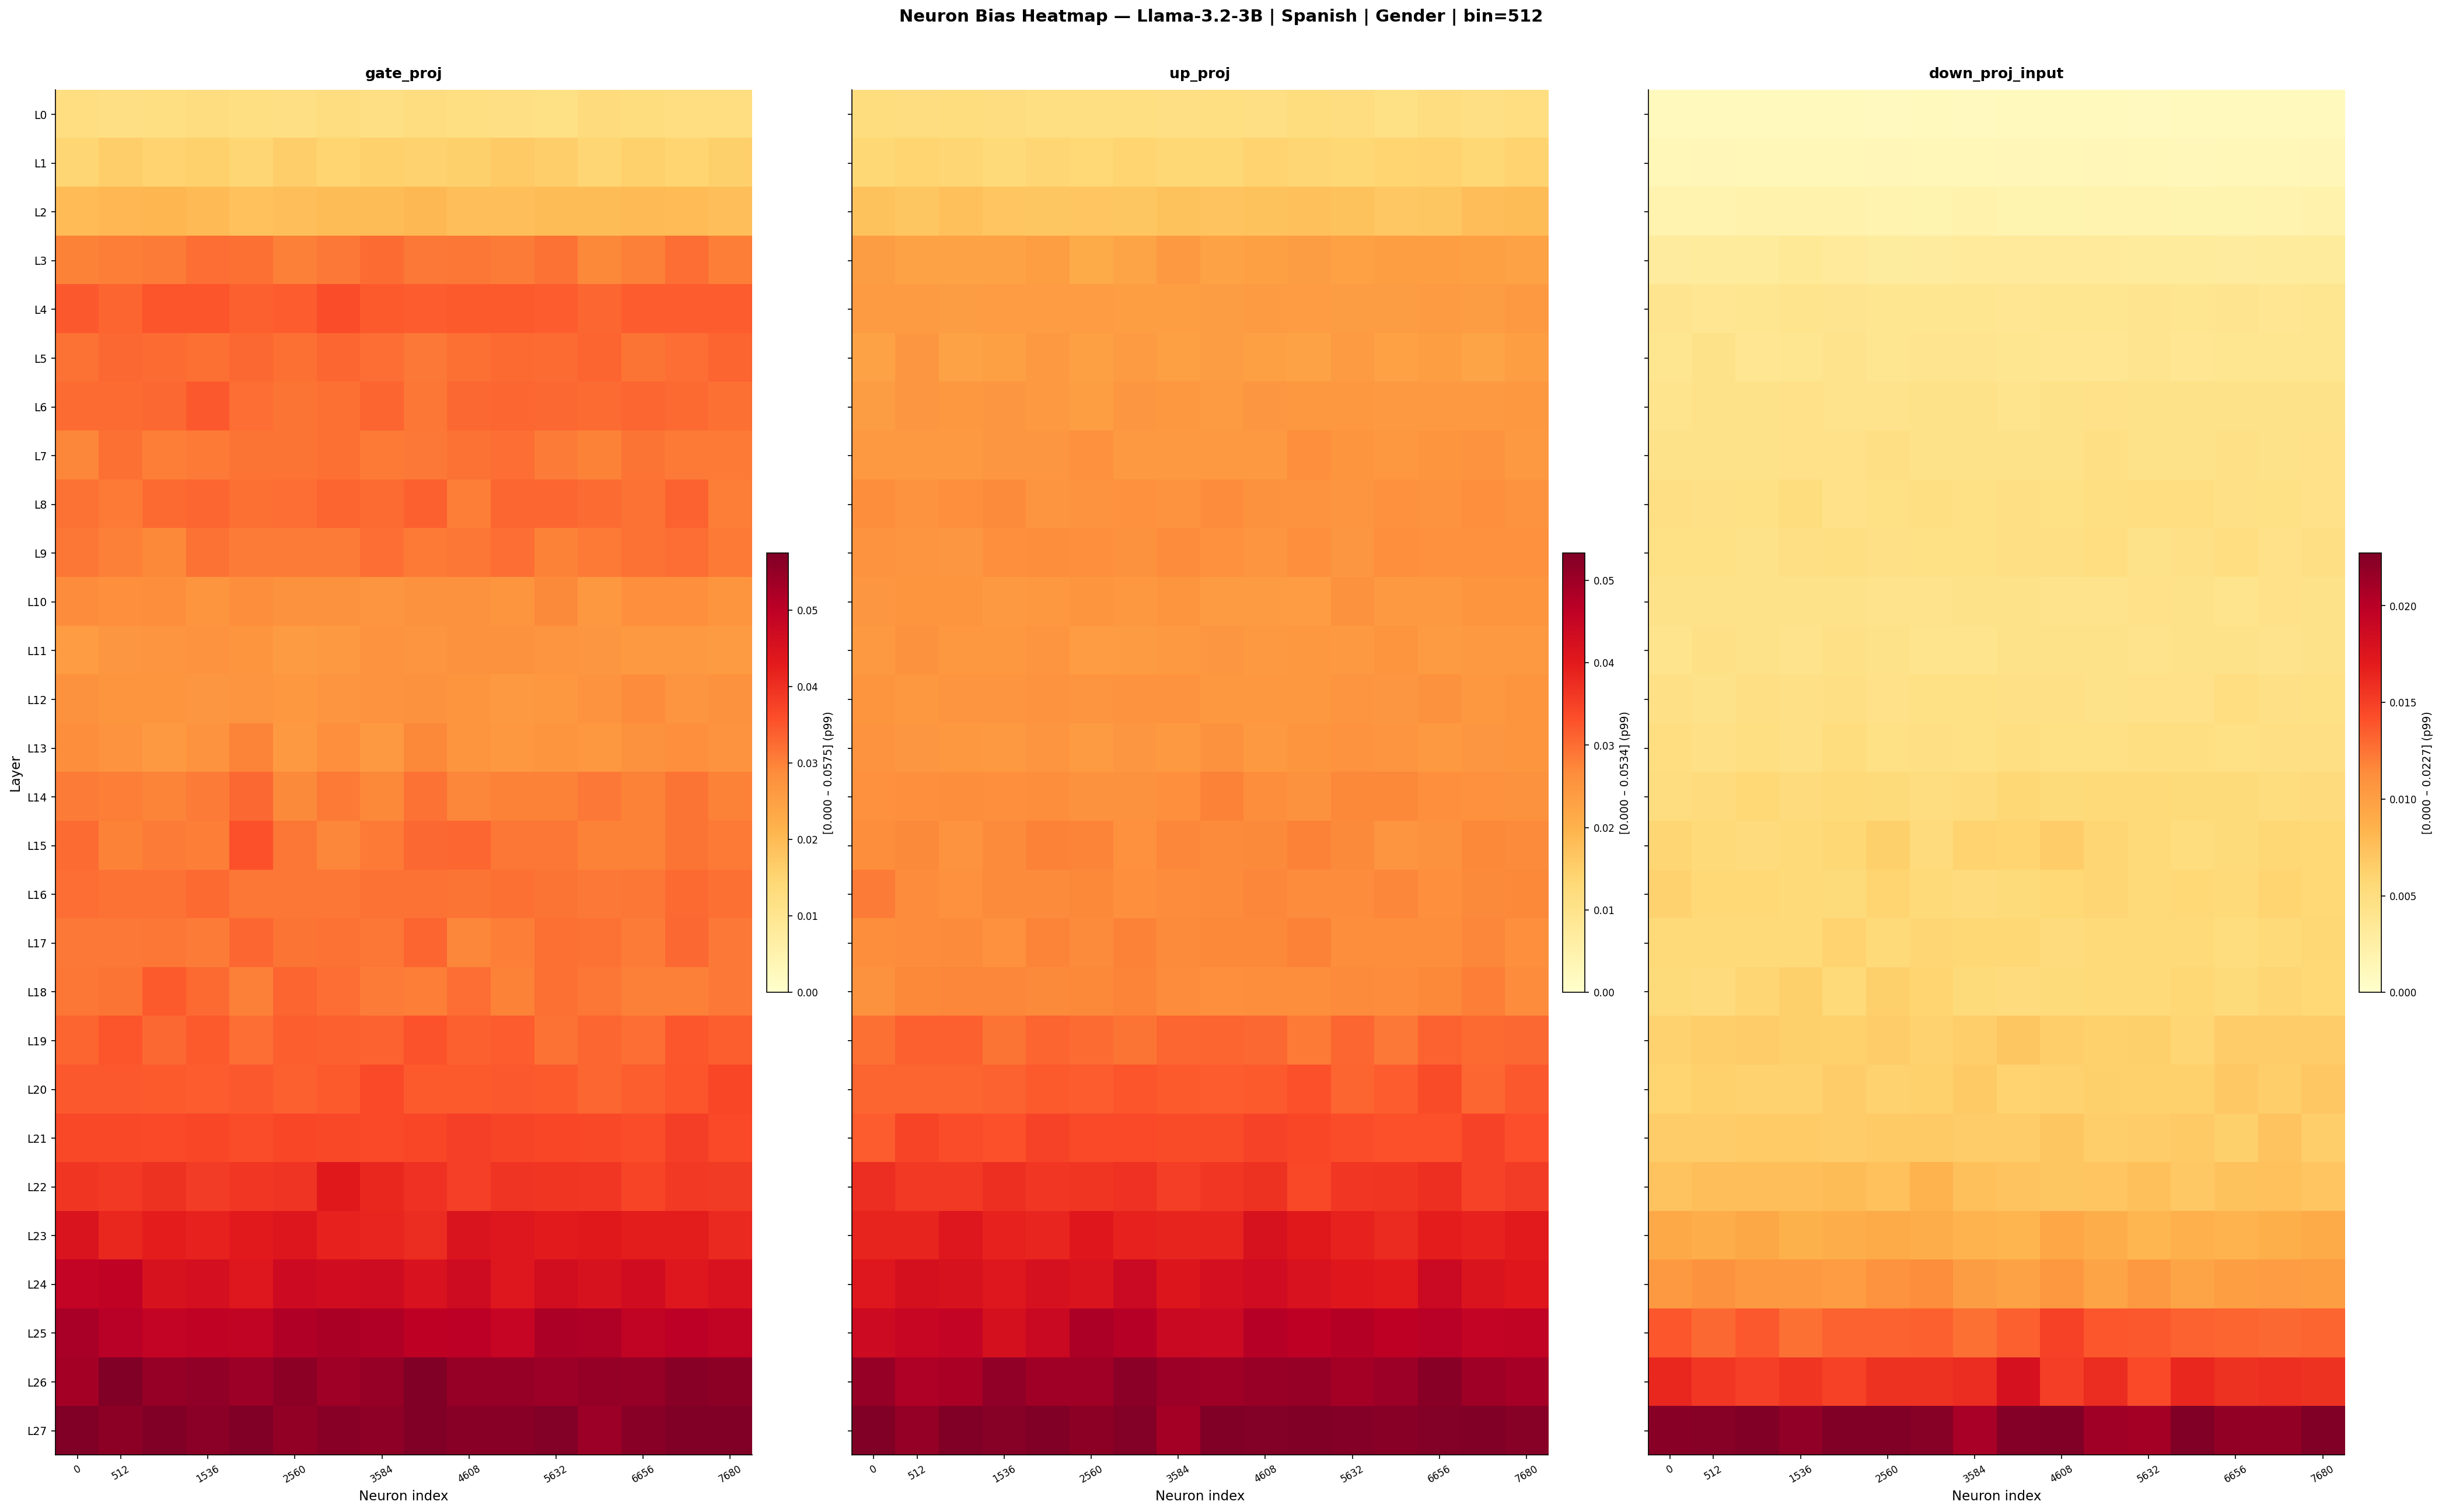


  llama-3.2-3B | ES | PhysicalAppearance
  gate_proj                     : vmax(p99)=0.051060 | abs max=0.052327
  up_proj                       : vmax(p99)=0.045136 | abs max=0.046906
  down_proj_input               : vmax(p99)=0.020764 | abs max=0.022490
Saved: neuron_heatmap_llama-3.2-3B_es_PhysicalAppearance_bin512


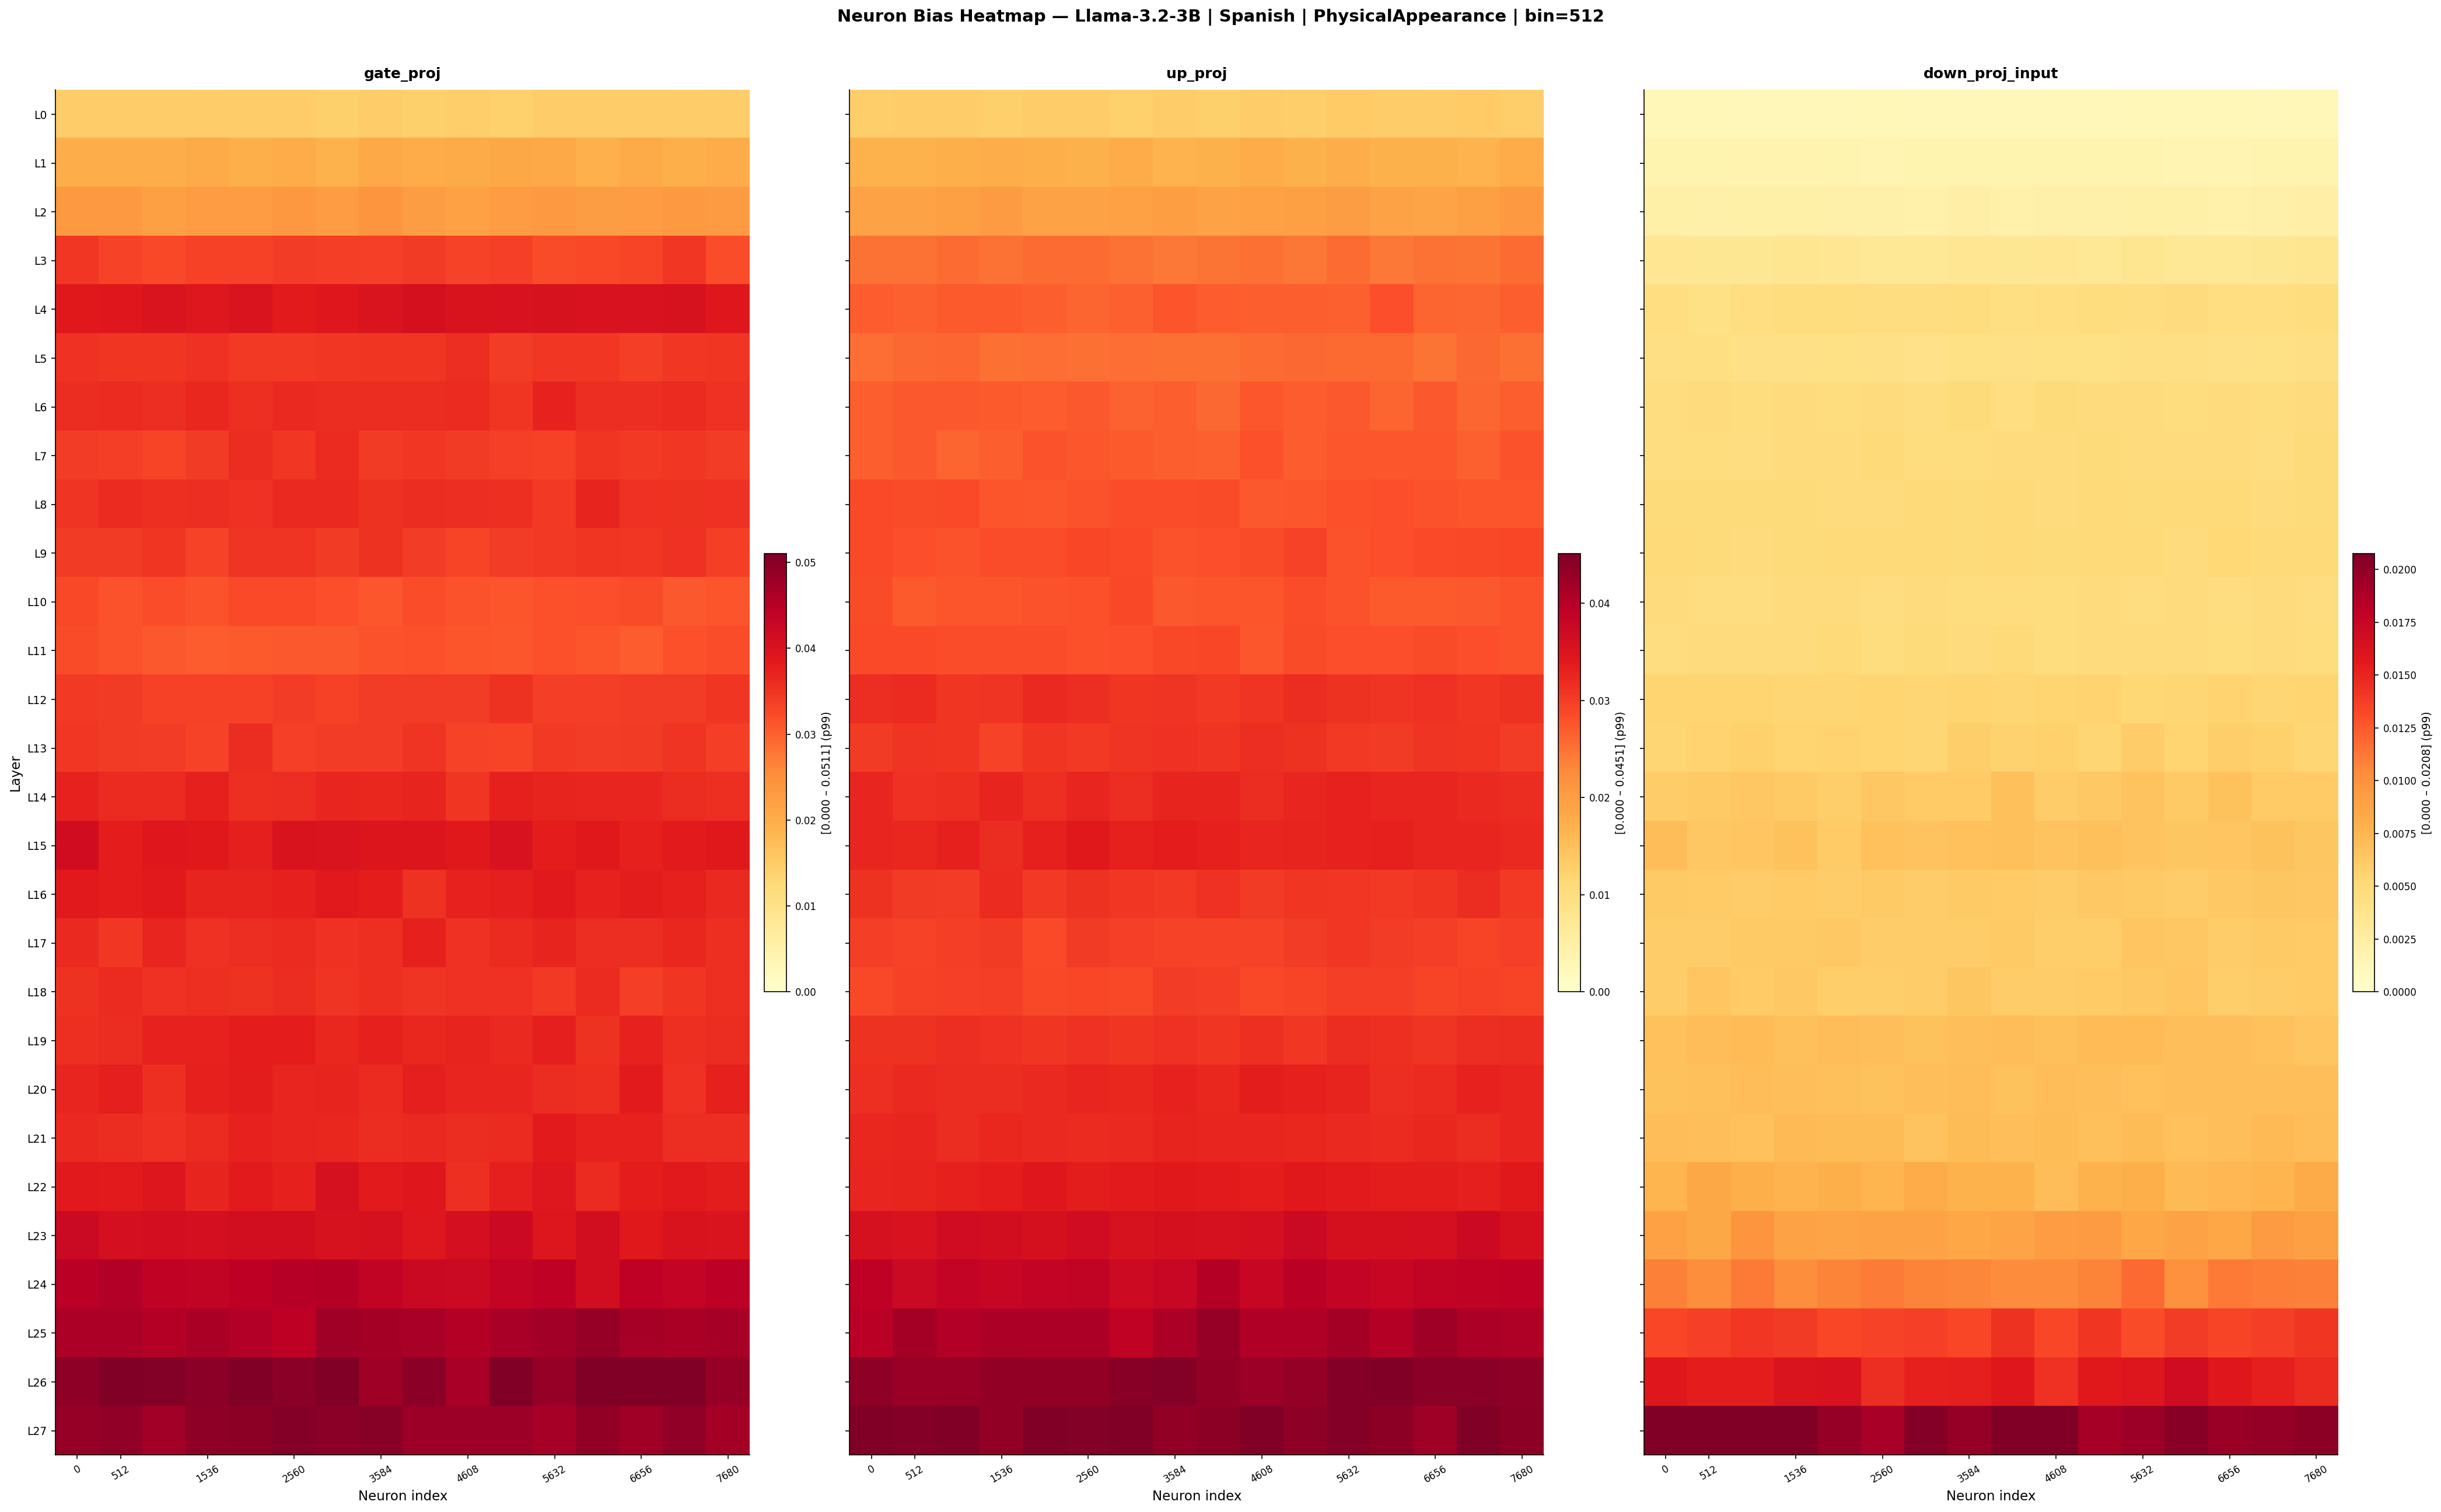


  llama-3.2-3B | ES | RaceEthnicity
  gate_proj                     : vmax(p99)=0.038218 | abs max=0.038798
  up_proj                       : vmax(p99)=0.032080 | abs max=0.032820
  down_proj_input               : vmax(p99)=0.014006 | abs max=0.014835
Saved: neuron_heatmap_llama-3.2-3B_es_RaceEthnicity_bin512


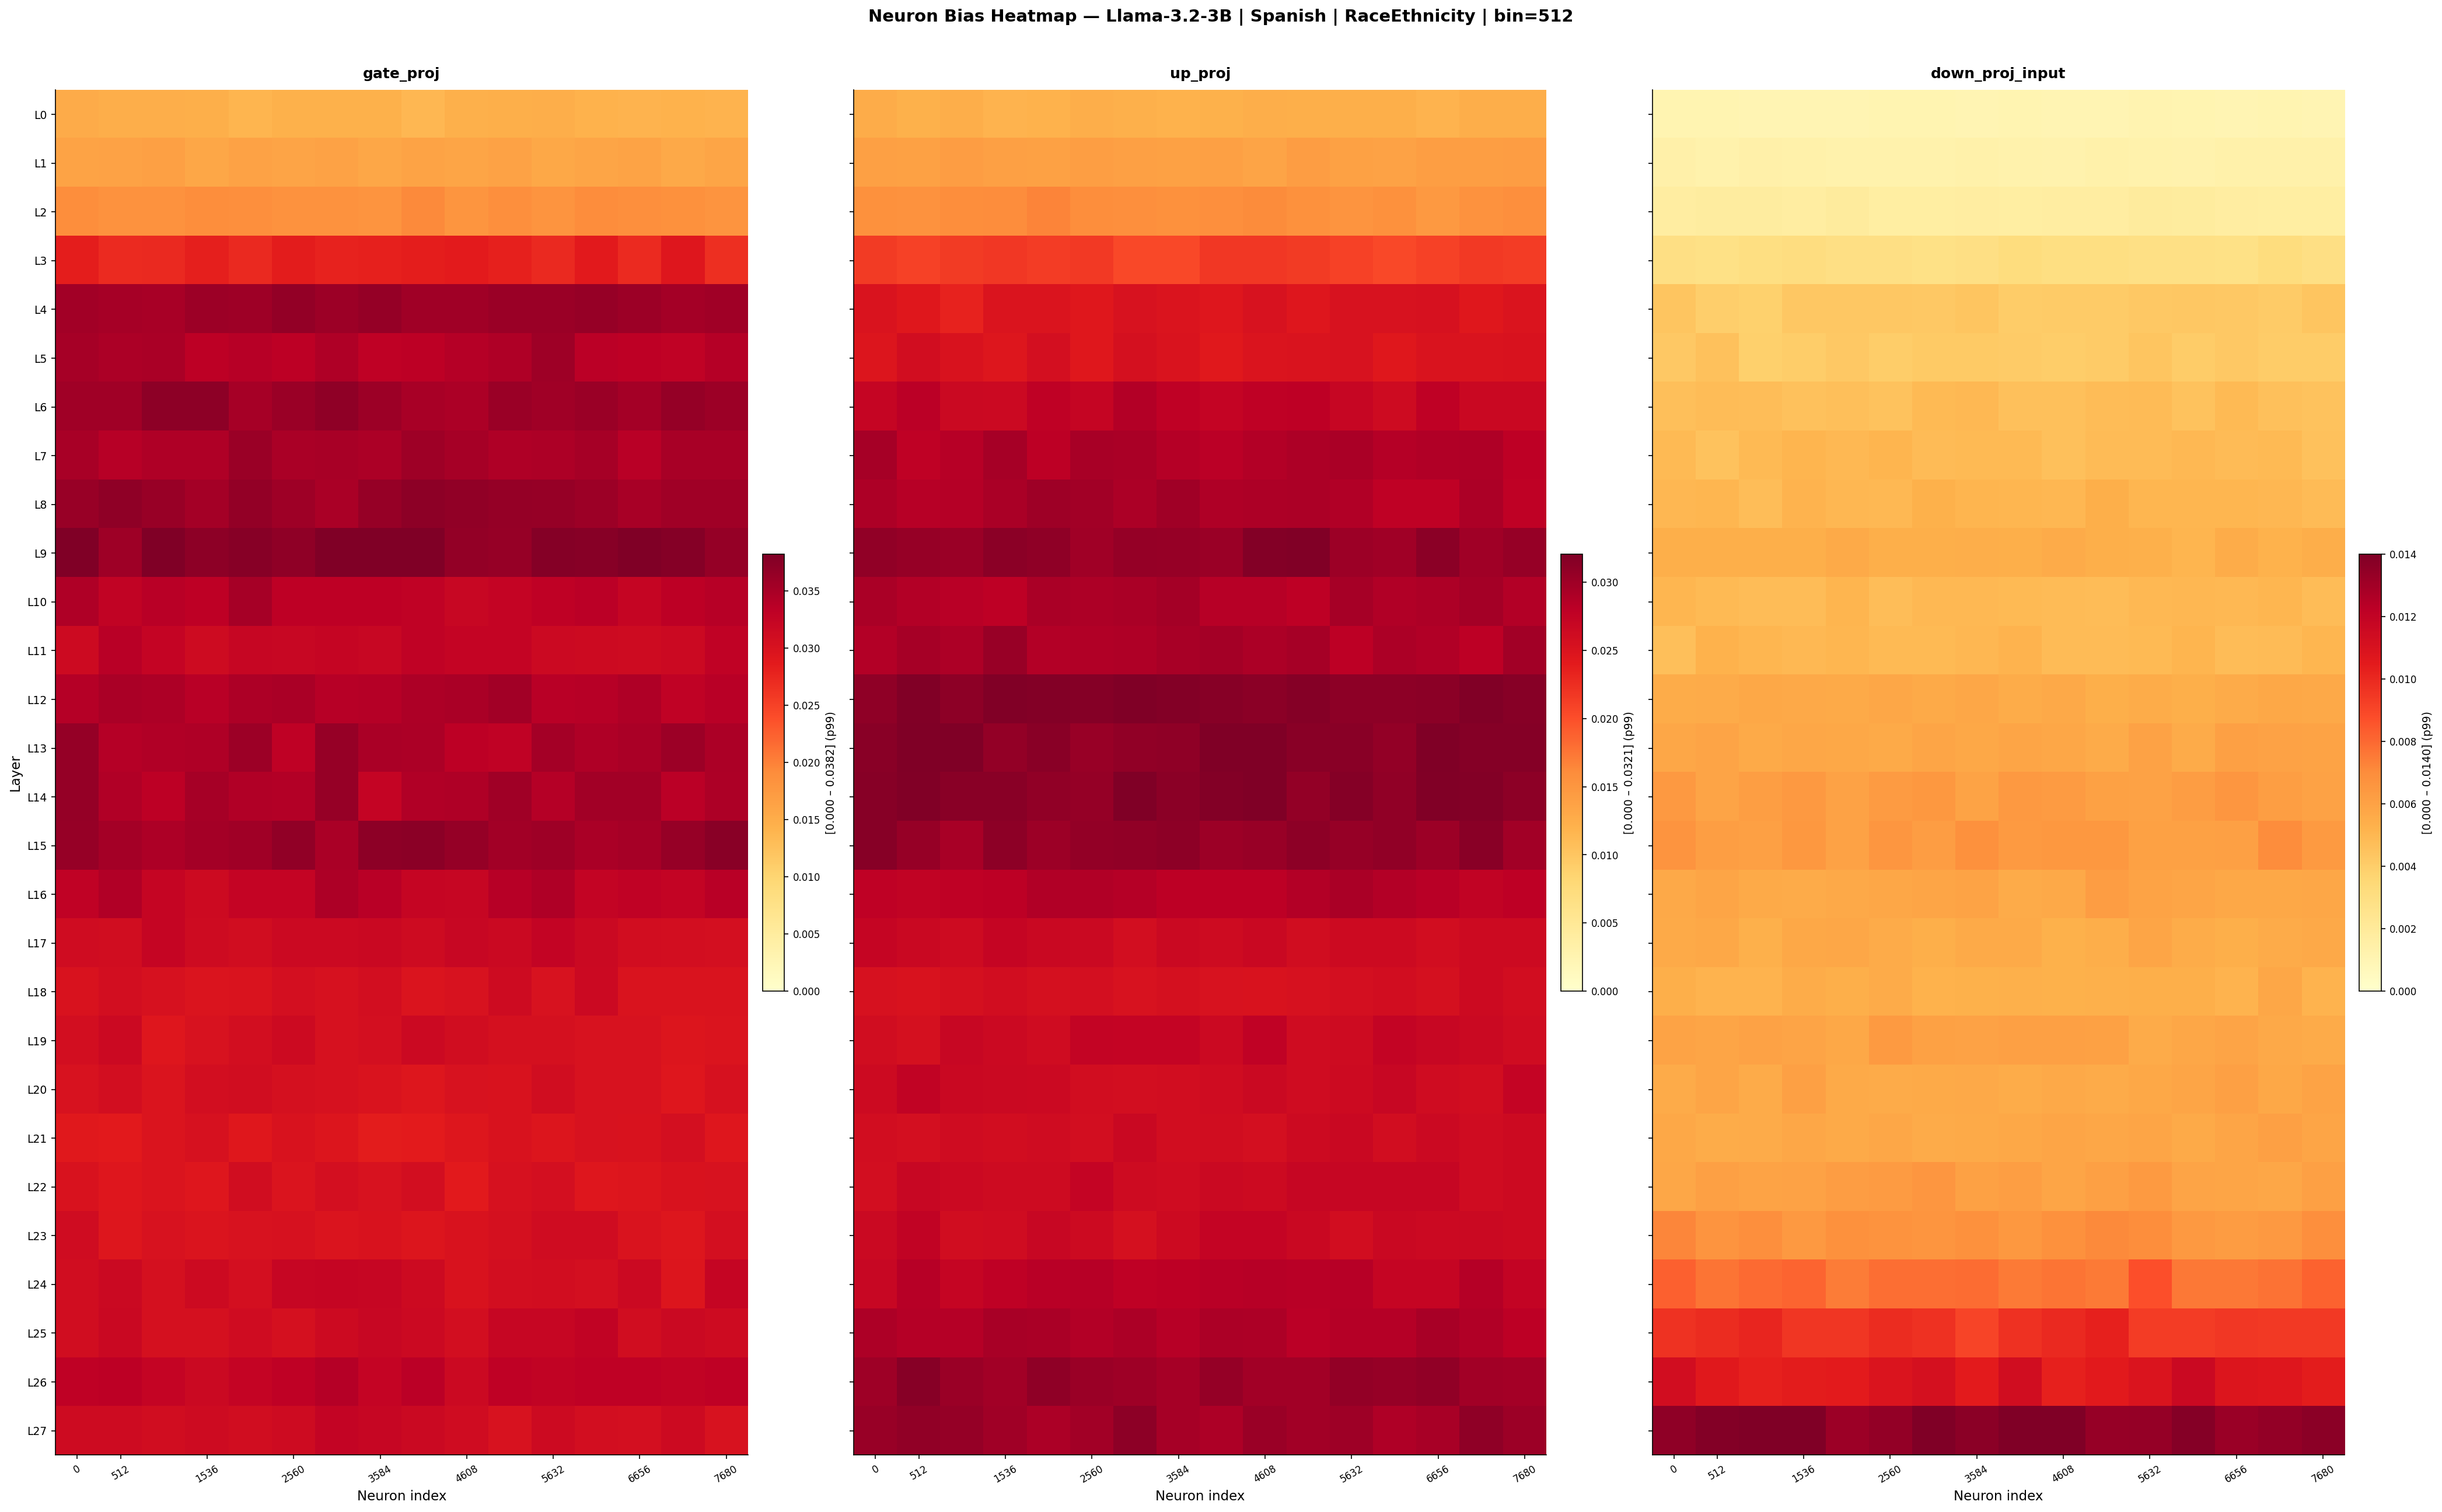


  llama-3.2-3B | ES | Religion
  gate_proj                     : vmax(p99)=0.068093 | abs max=0.071500
  up_proj                       : vmax(p99)=0.062550 | abs max=0.063886
  down_proj_input               : vmax(p99)=0.026443 | abs max=0.027580
Saved: neuron_heatmap_llama-3.2-3B_es_Religion_bin512


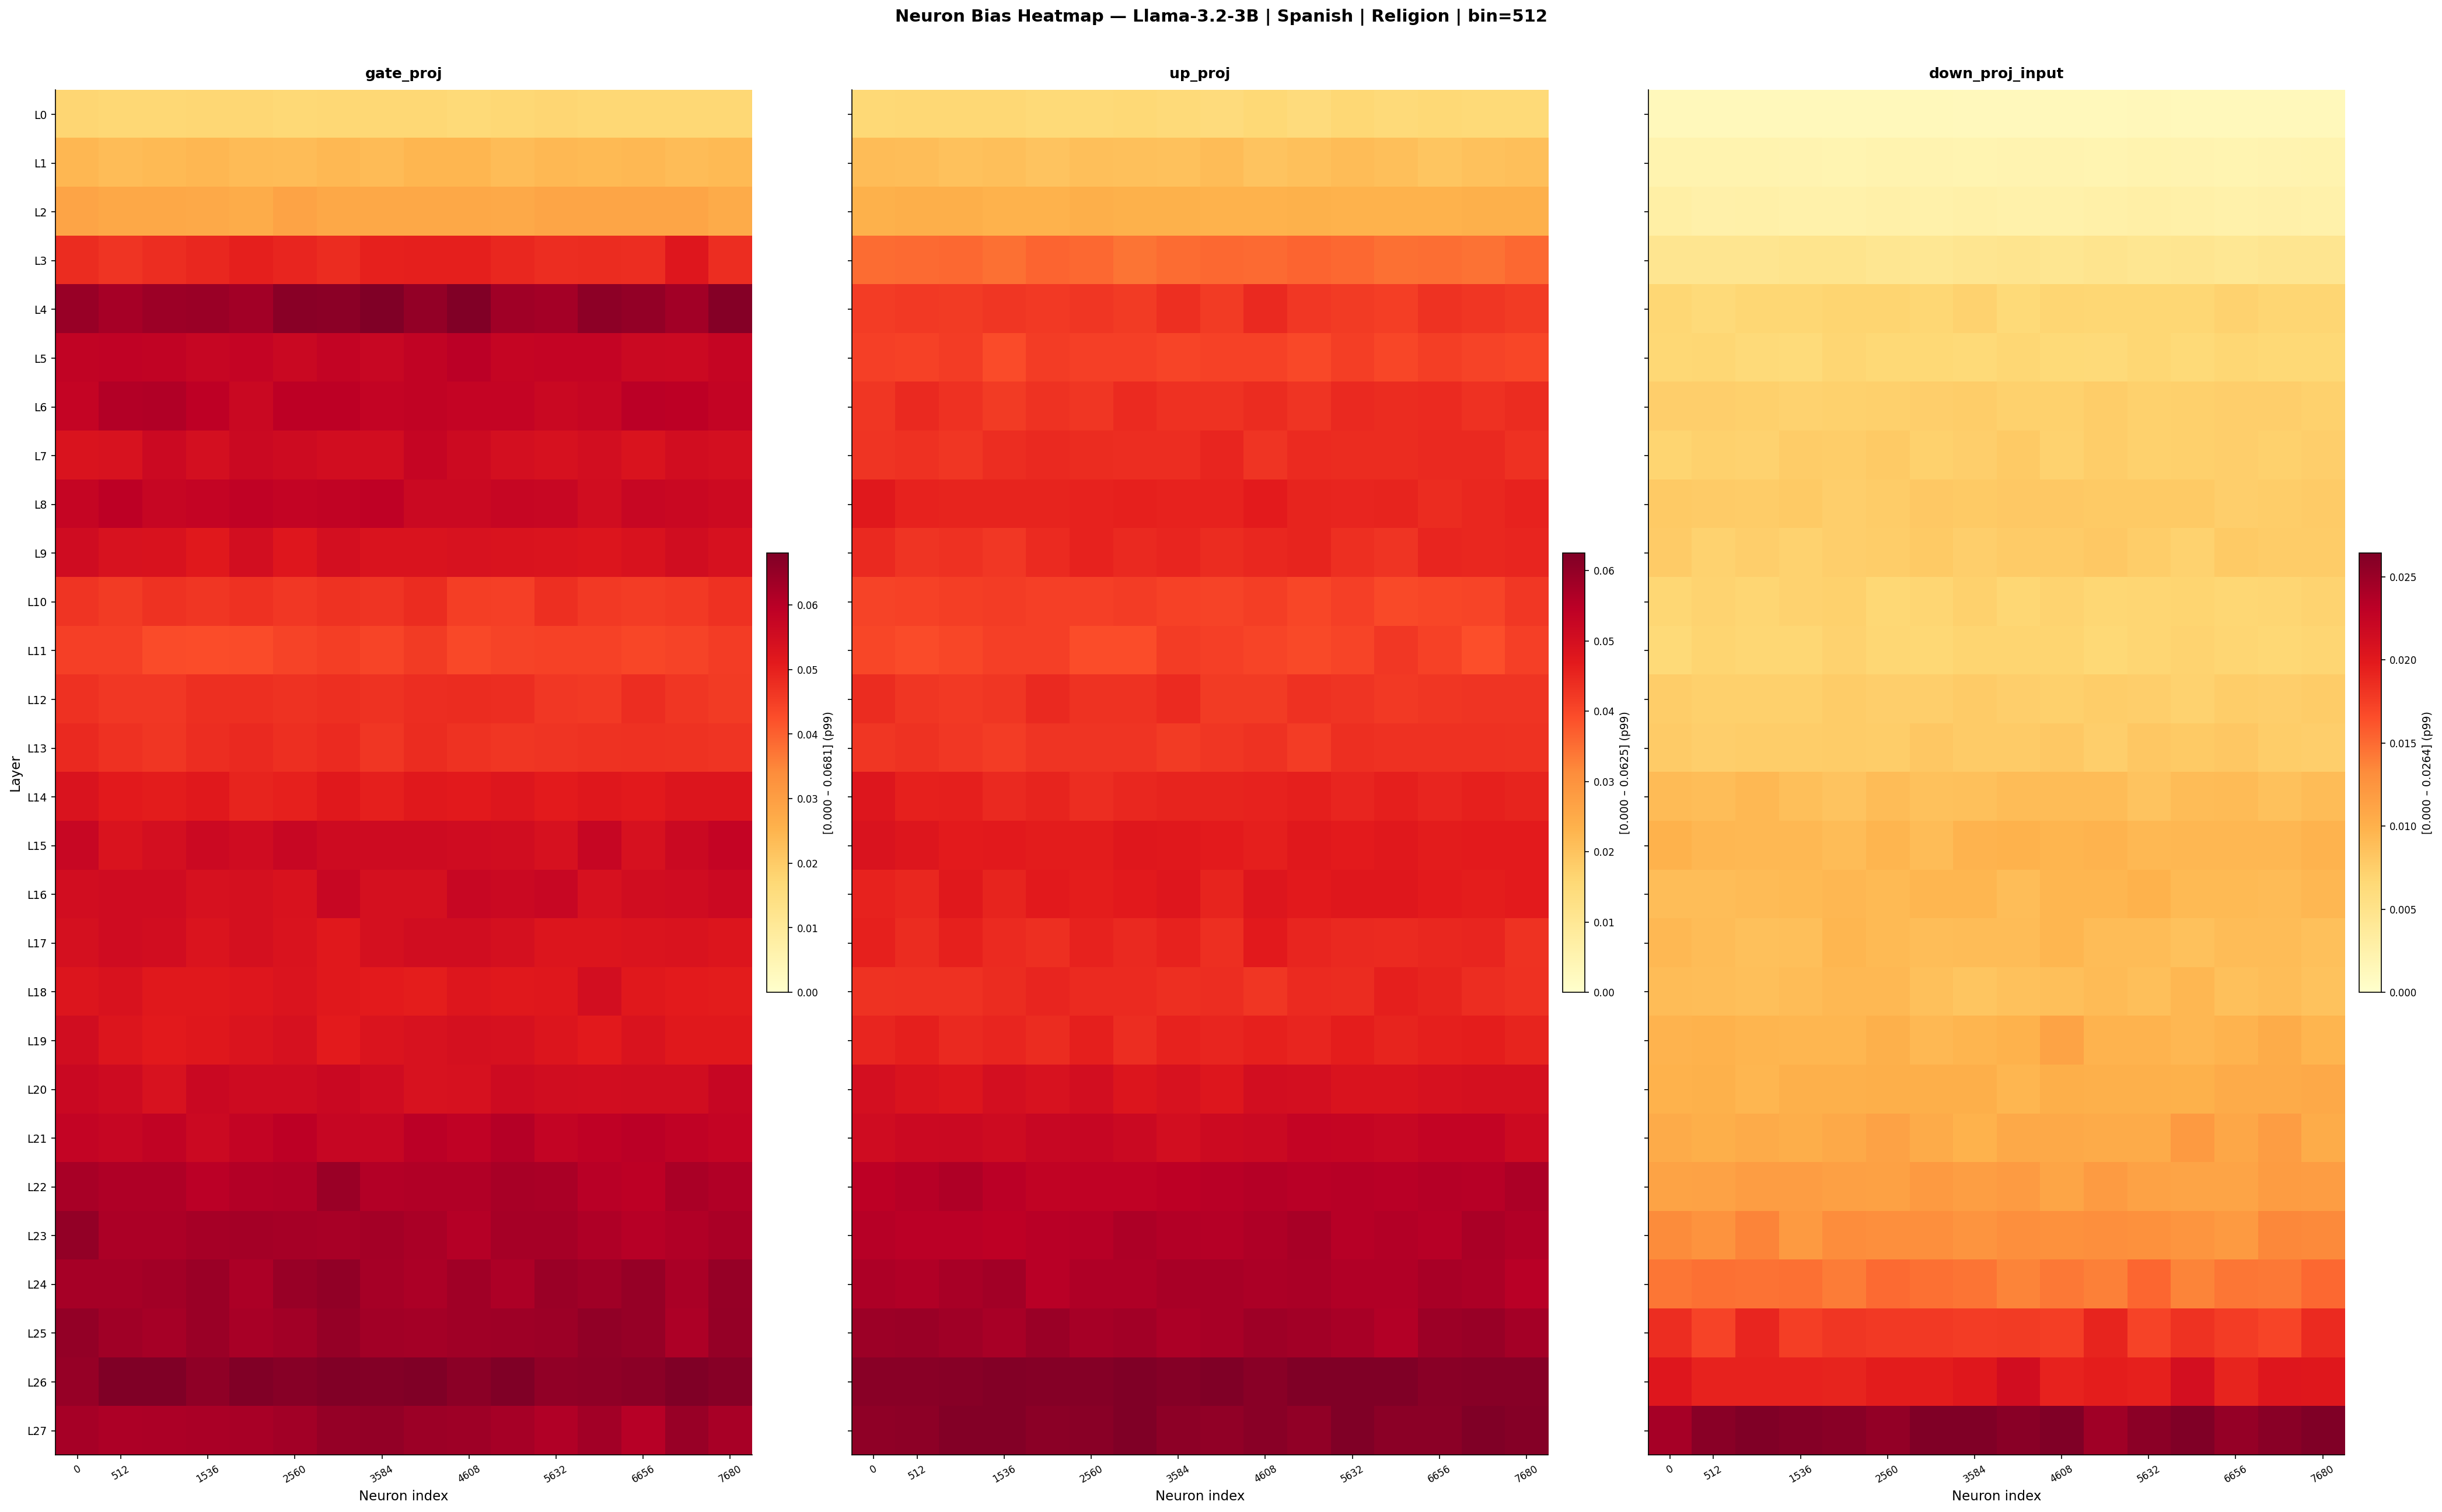


  salamandra-2B | EN | Age
  gate_proj                     : vmax(p99)=0.056229 | abs max=0.056944
  up_proj                       : vmax(p99)=0.049115 | abs max=0.050346
  down_proj_input               : vmax(p99)=0.019639 | abs max=0.021187
Saved: neuron_heatmap_salamandra-2B_en_Age_bin512


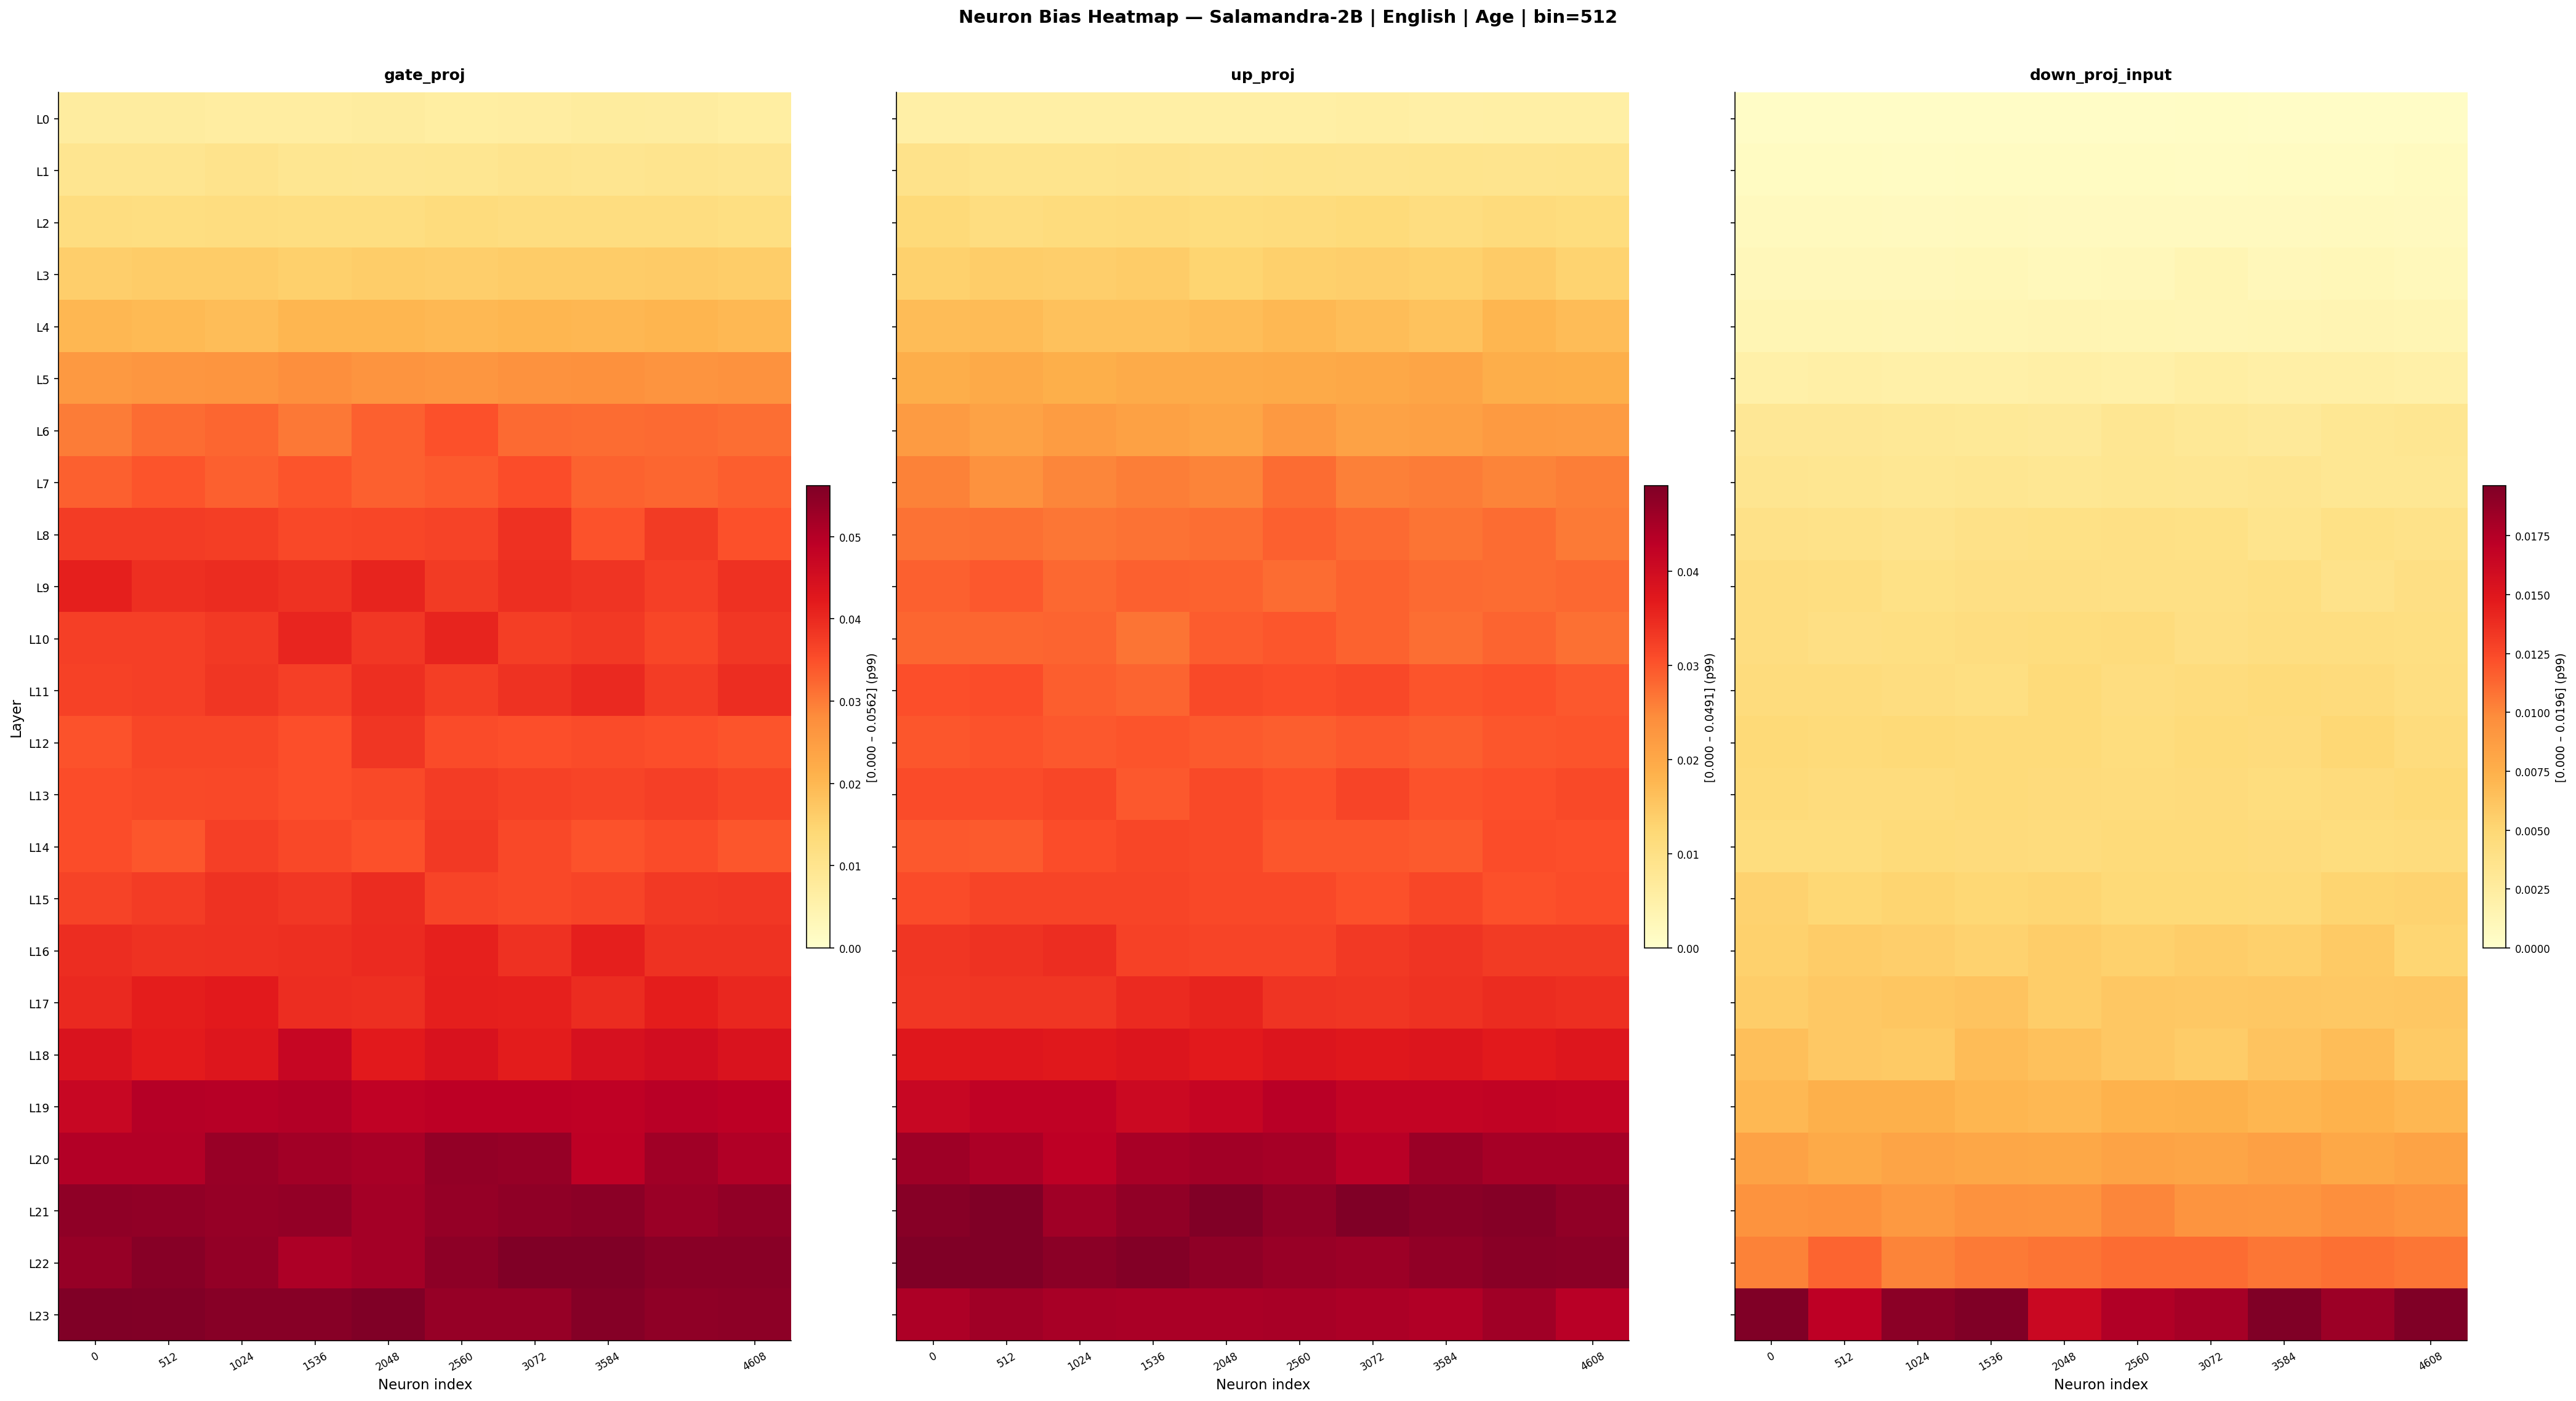


  salamandra-2B | EN | Gender
  gate_proj                     : vmax(p99)=0.028131 | abs max=0.028992
  up_proj                       : vmax(p99)=0.024262 | abs max=0.024517
  down_proj_input               : vmax(p99)=0.010144 | abs max=0.010924
Saved: neuron_heatmap_salamandra-2B_en_Gender_bin512


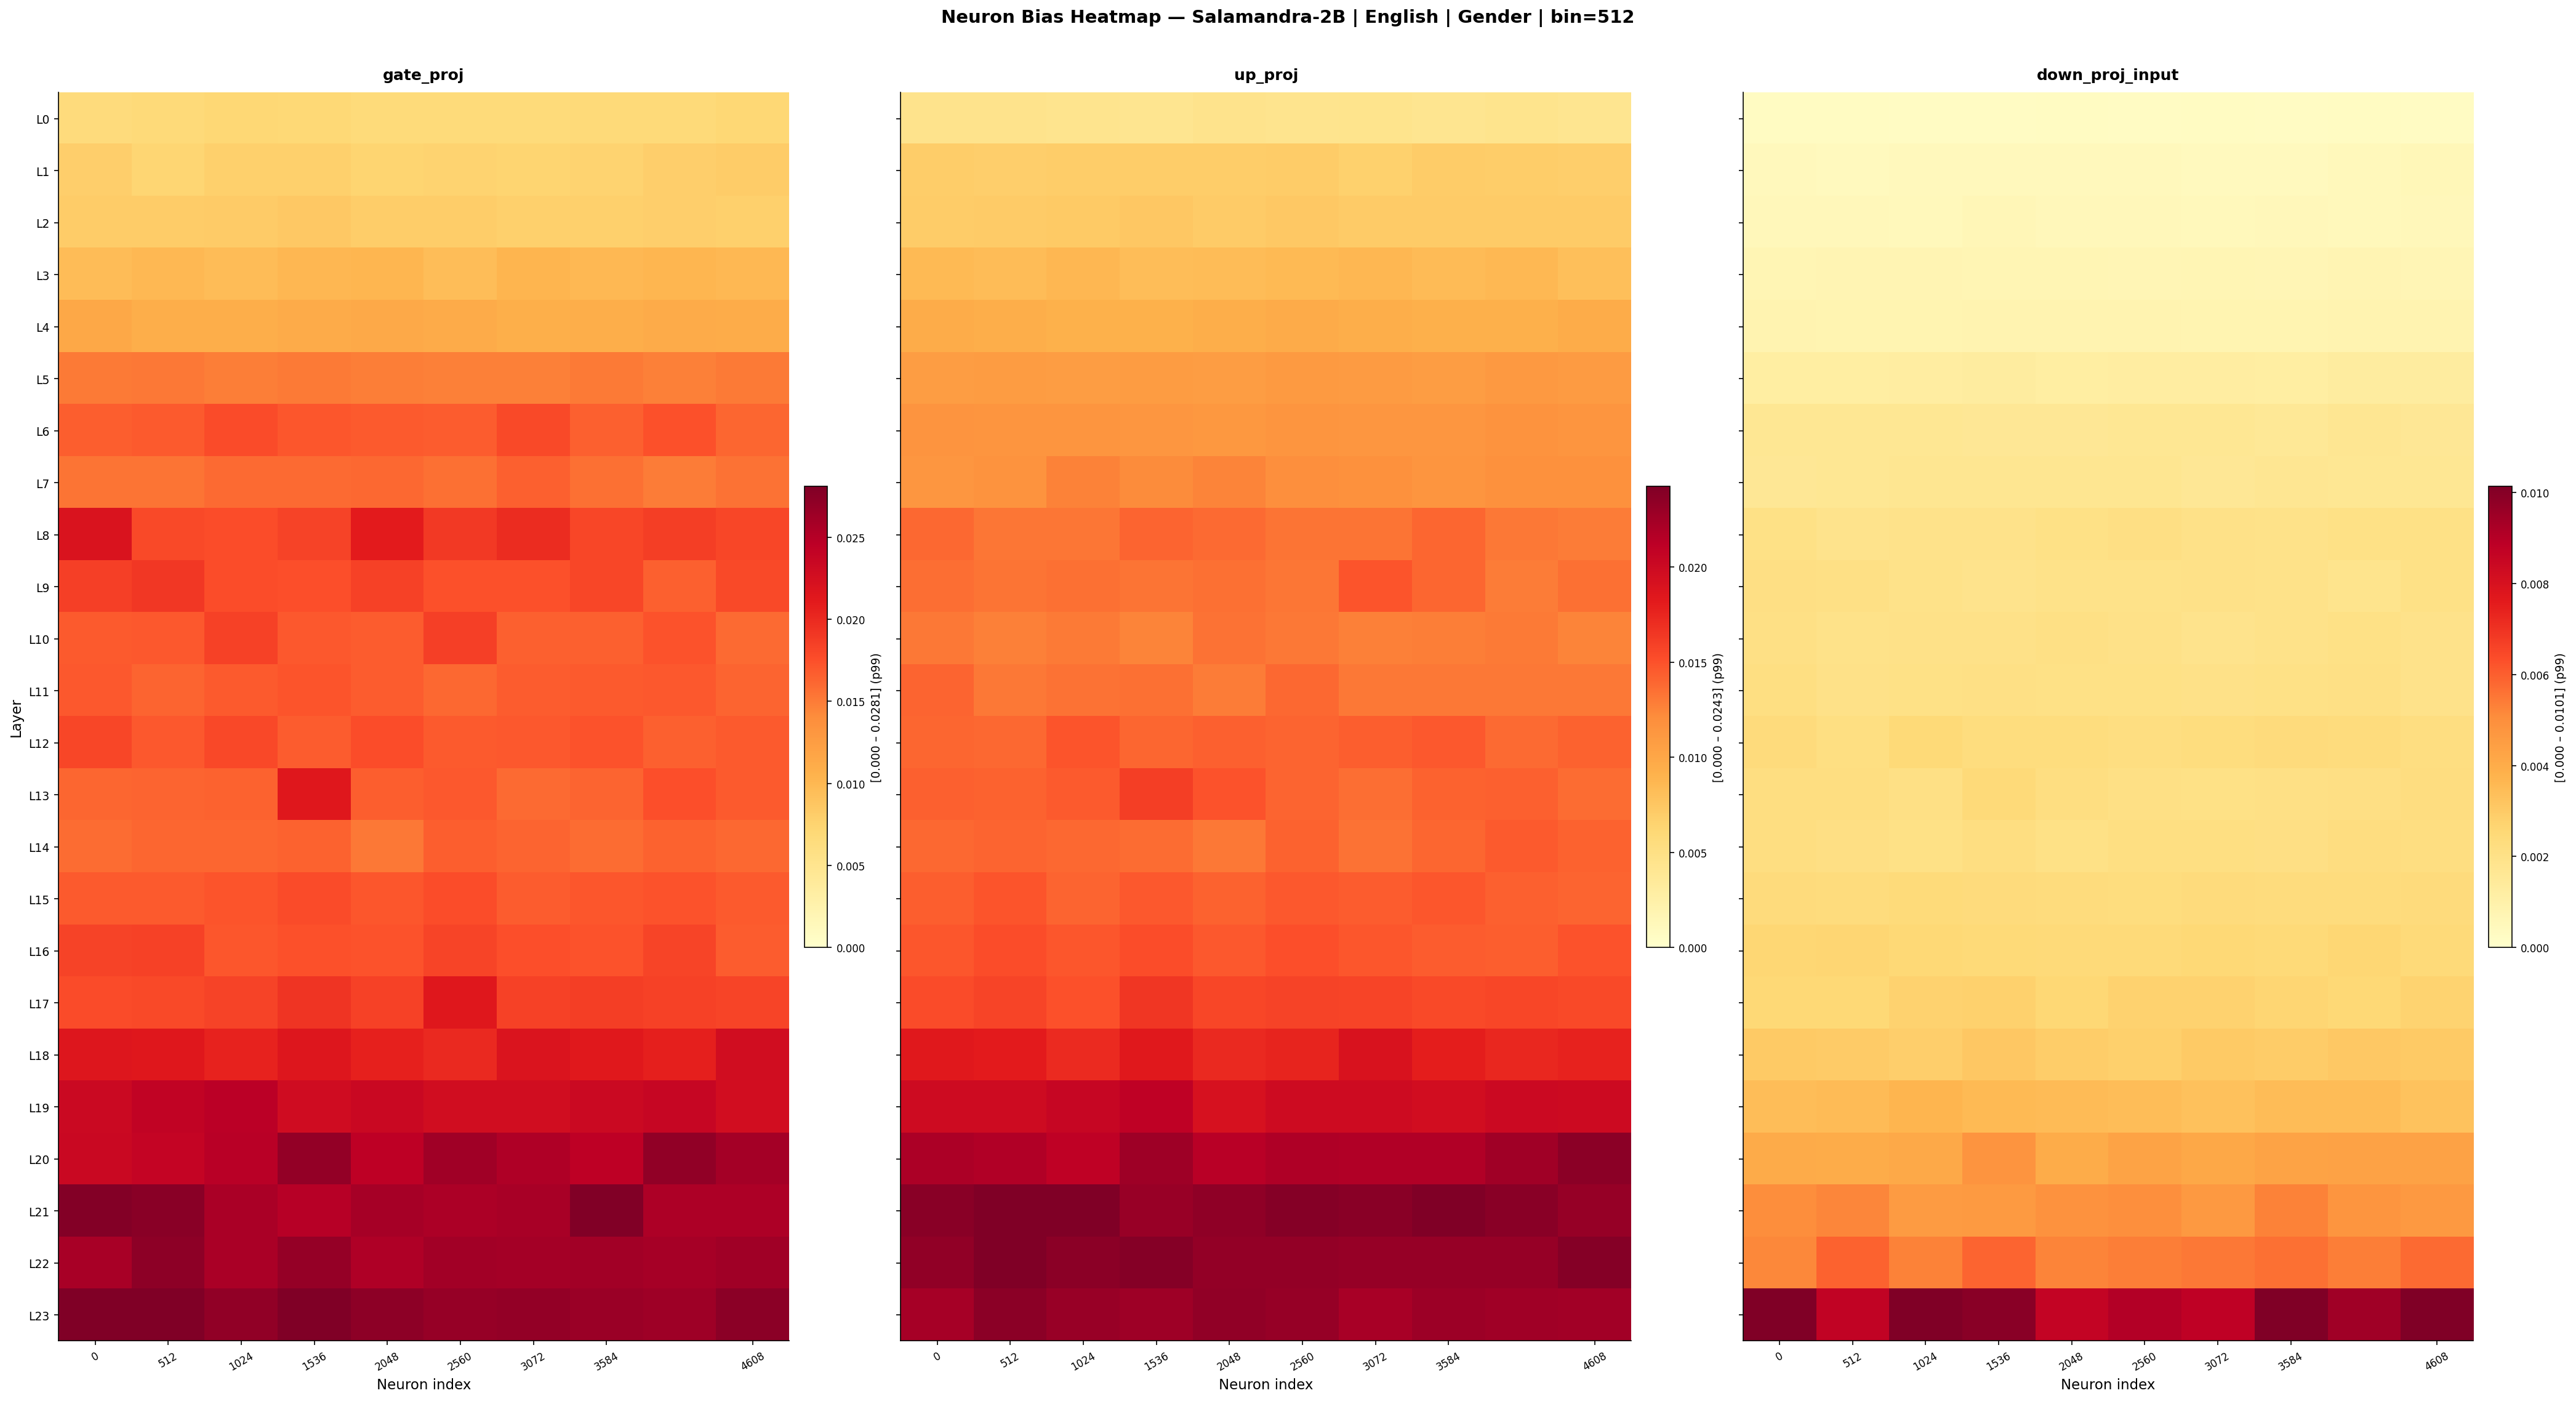


  salamandra-2B | EN | PhysicalAppearance
  gate_proj                     : vmax(p99)=0.046507 | abs max=0.046742
  up_proj                       : vmax(p99)=0.040642 | abs max=0.041220
  down_proj_input               : vmax(p99)=0.015100 | abs max=0.016019
Saved: neuron_heatmap_salamandra-2B_en_PhysicalAppearance_bin512


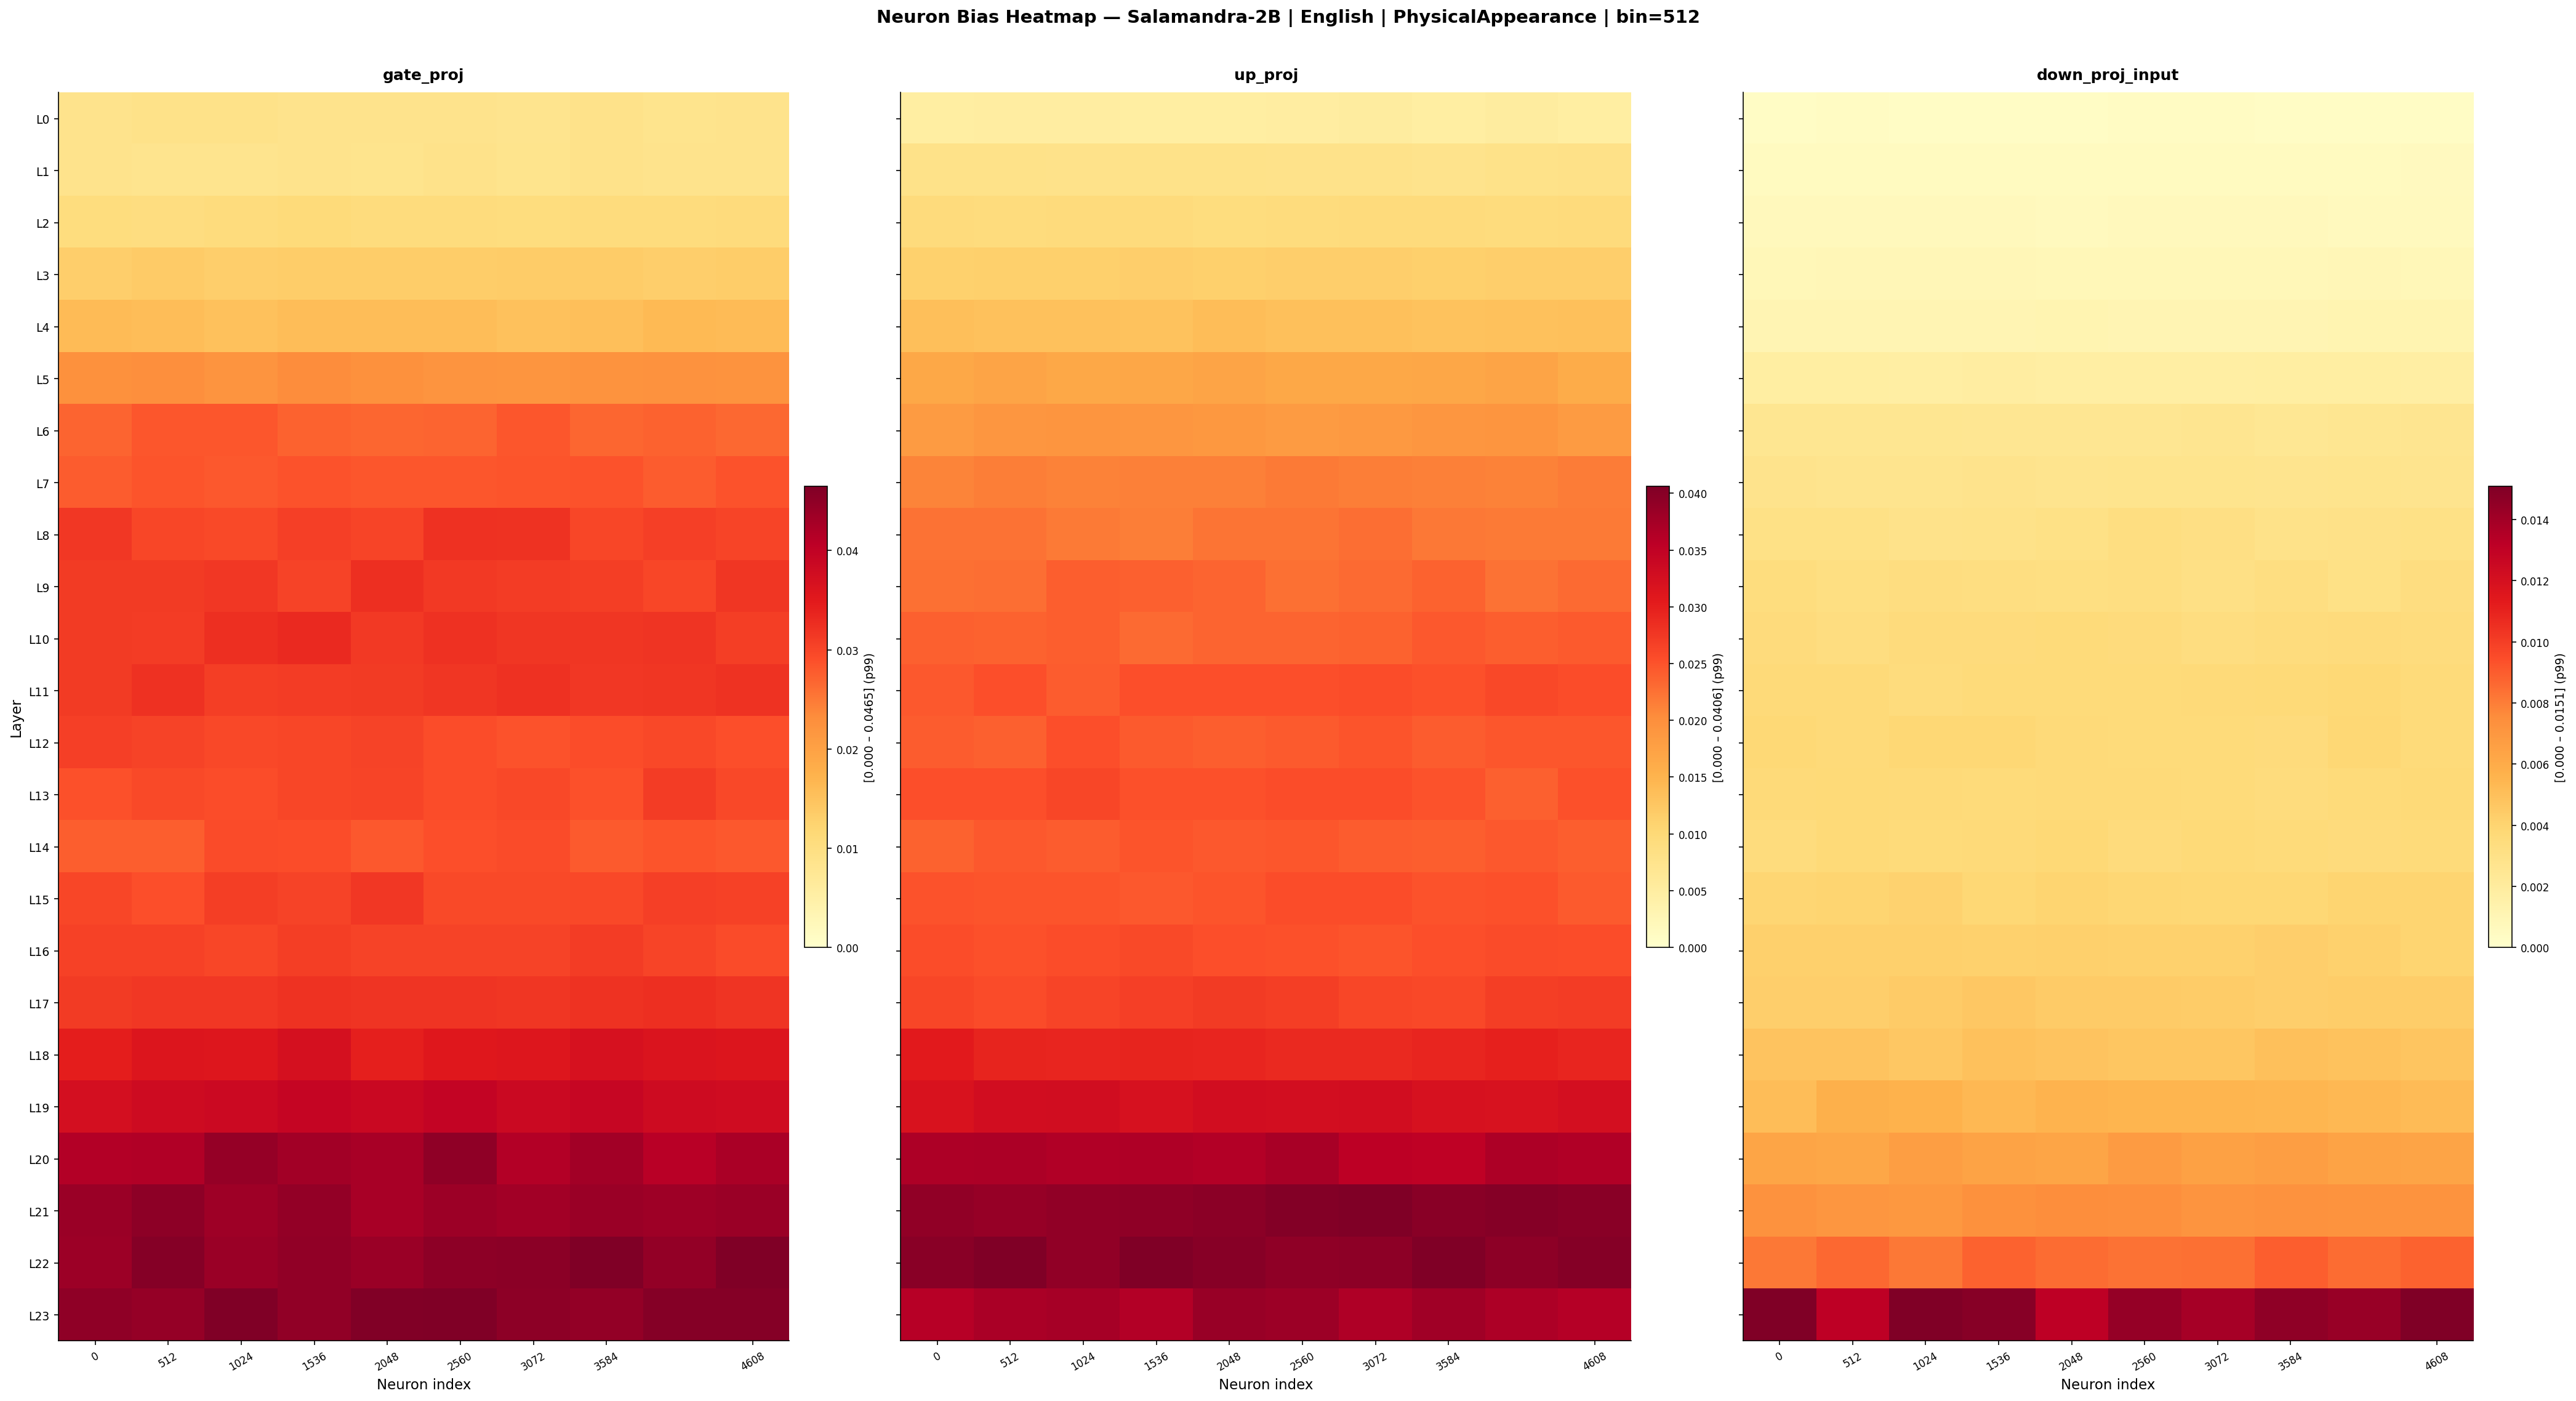


  salamandra-2B | EN | RaceEthnicity
  gate_proj                     : vmax(p99)=0.060563 | abs max=0.061968
  up_proj                       : vmax(p99)=0.052256 | abs max=0.055143
  down_proj_input               : vmax(p99)=0.020380 | abs max=0.021462
Saved: neuron_heatmap_salamandra-2B_en_RaceEthnicity_bin512


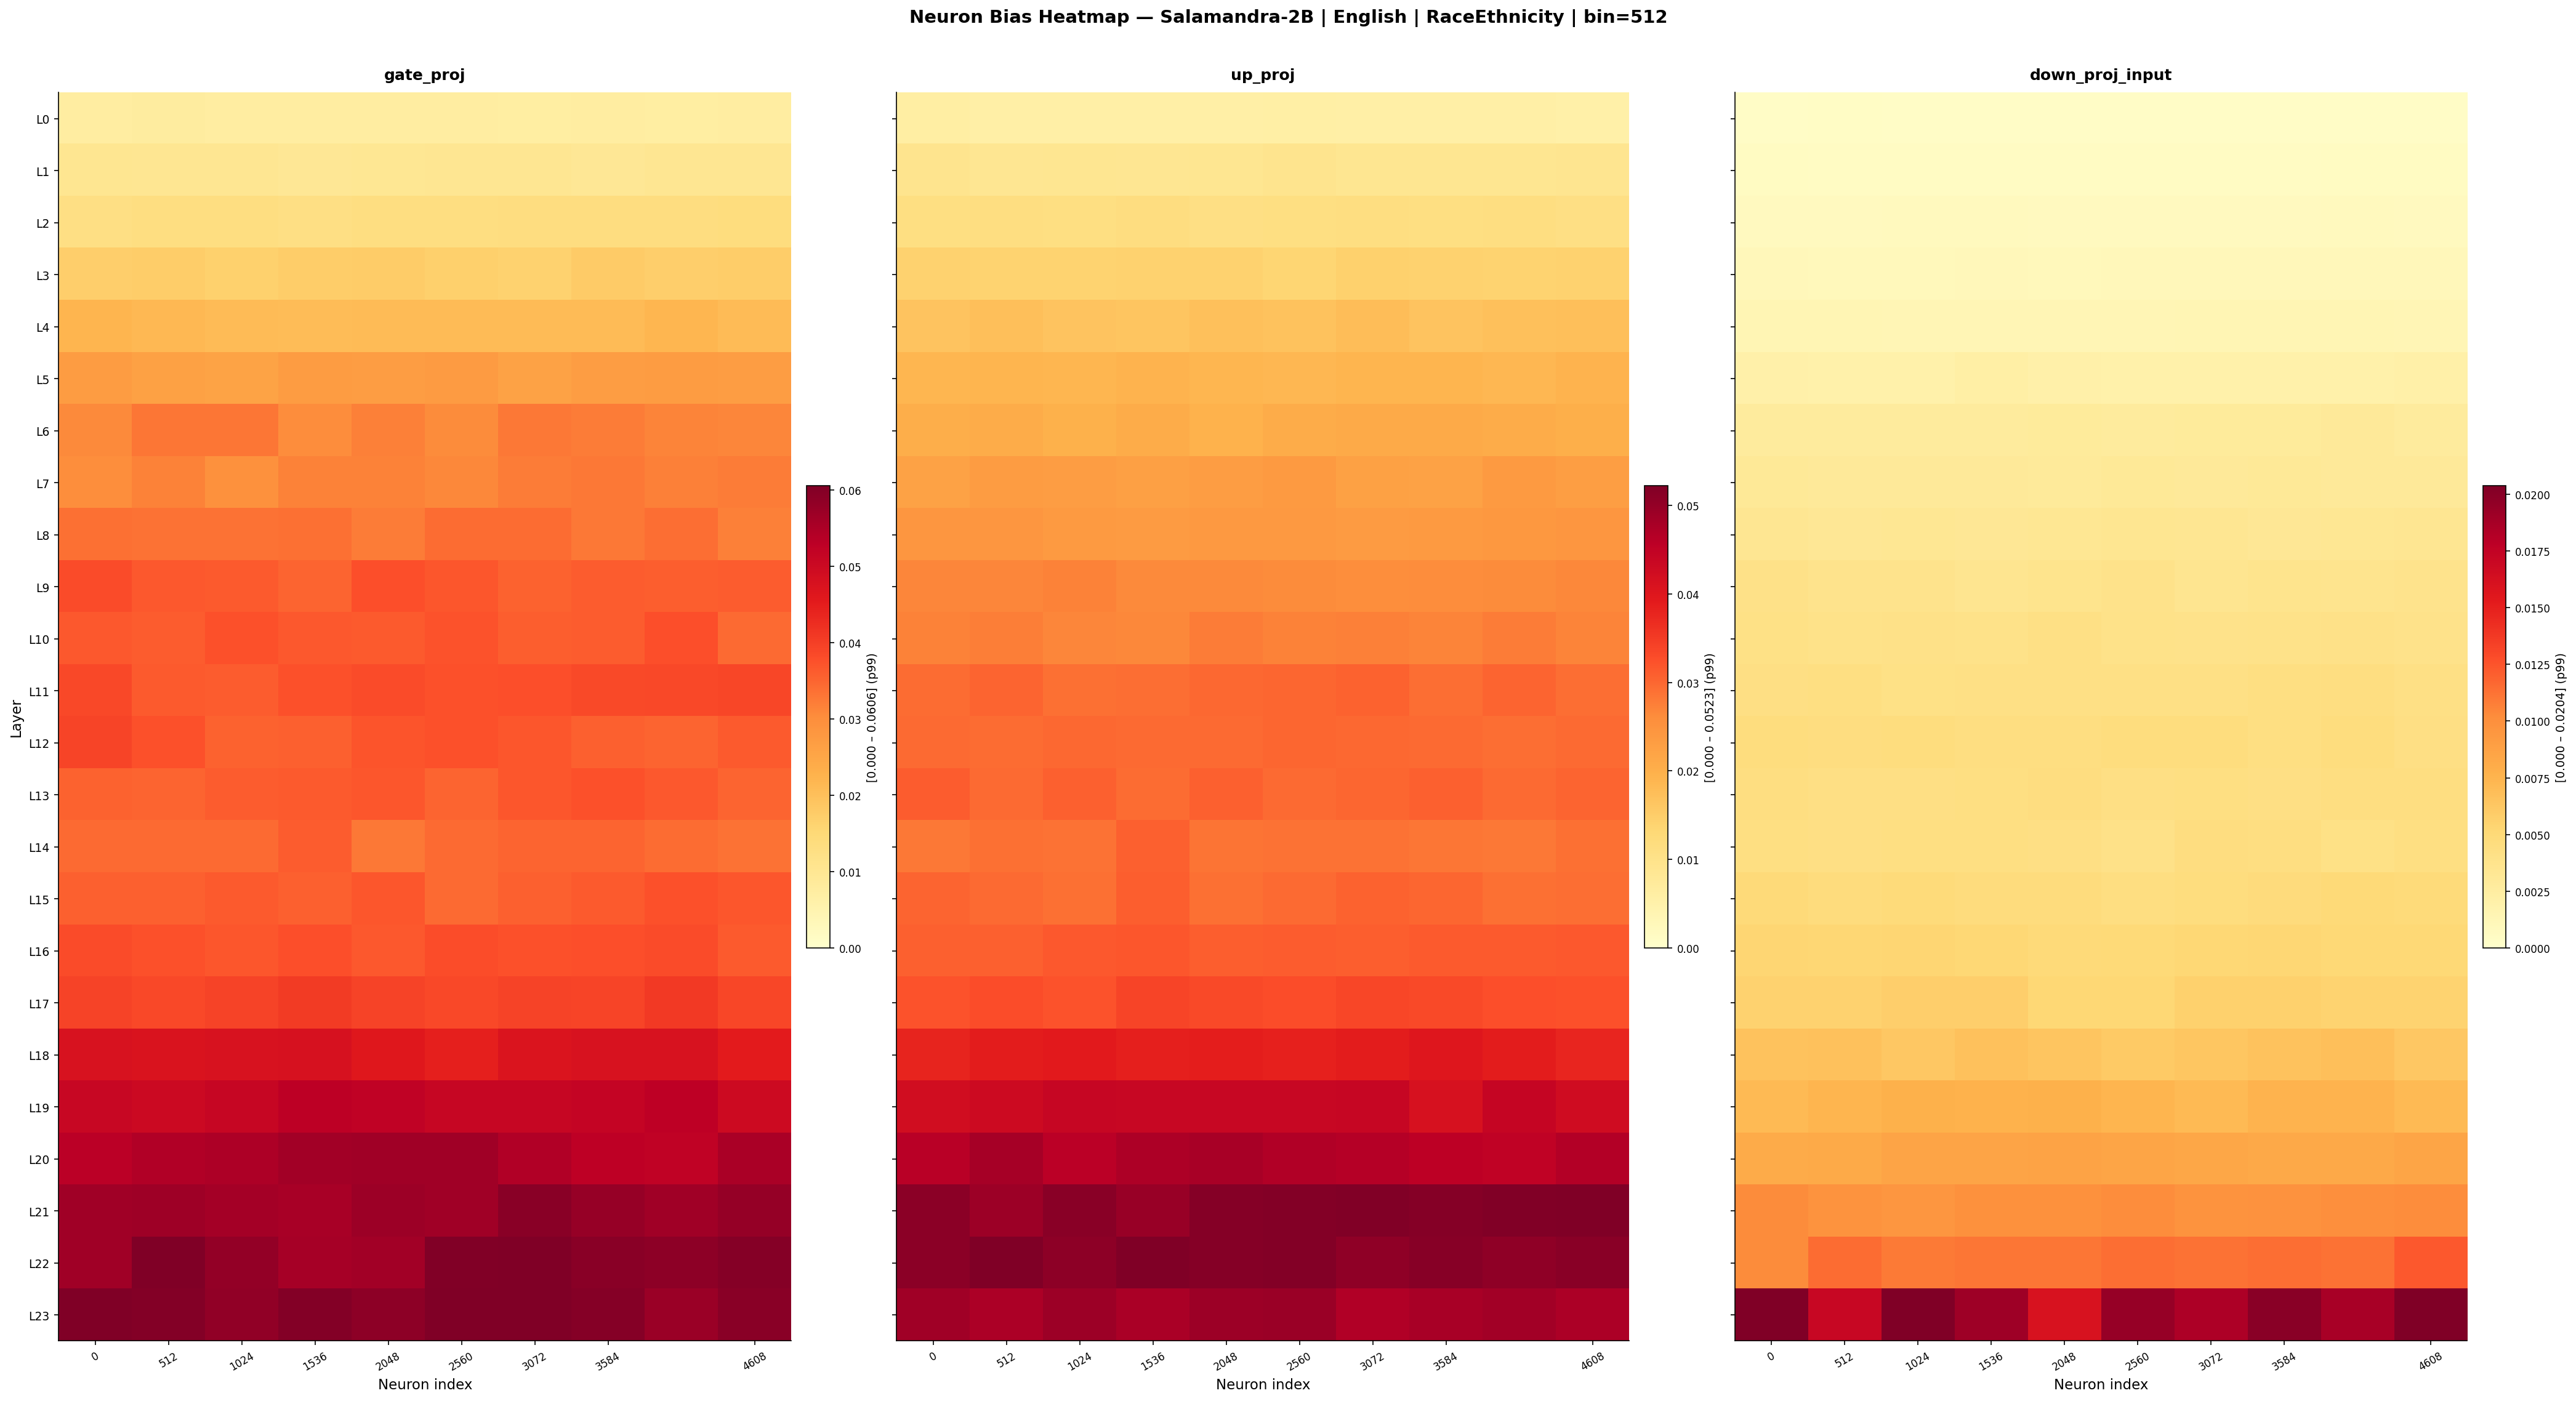


  salamandra-2B | EN | Religion
  gate_proj                     : vmax(p99)=0.052860 | abs max=0.055597
  up_proj                       : vmax(p99)=0.048549 | abs max=0.049529
  down_proj_input               : vmax(p99)=0.018367 | abs max=0.020858
Saved: neuron_heatmap_salamandra-2B_en_Religion_bin512


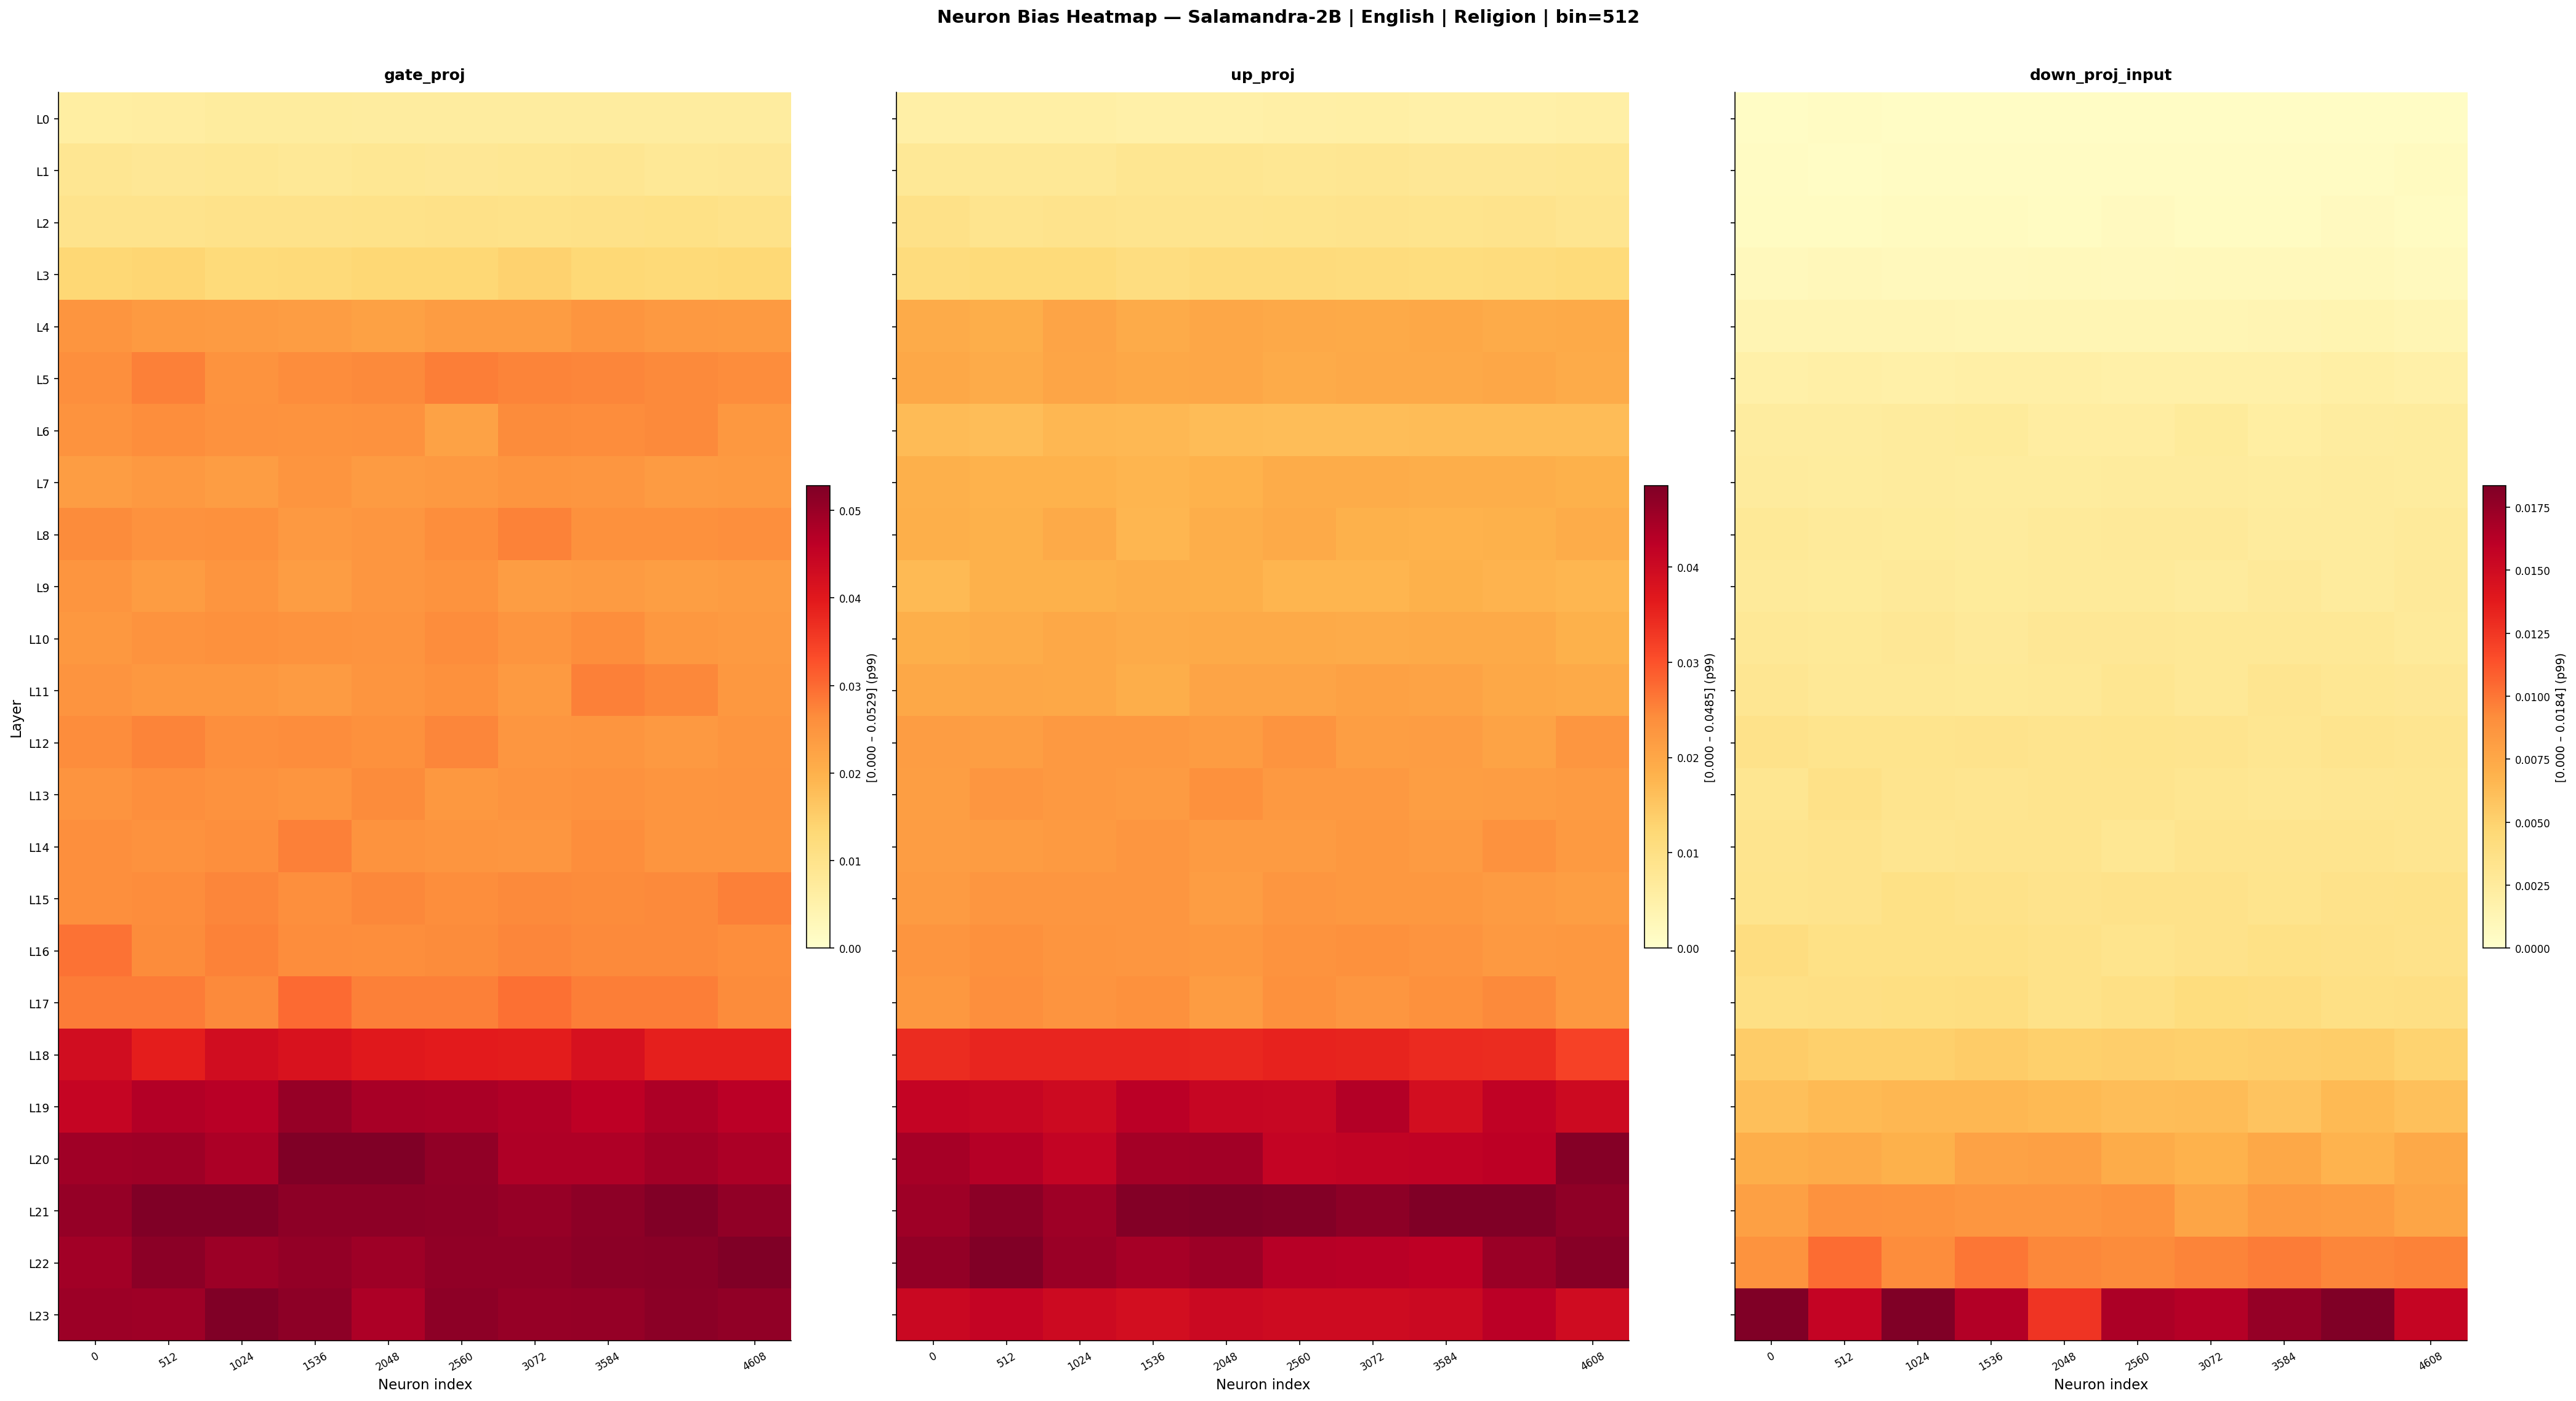


  salamandra-2B | ES | Age
  gate_proj                     : vmax(p99)=0.032547 | abs max=0.033094
  up_proj                       : vmax(p99)=0.028098 | abs max=0.028426
  down_proj_input               : vmax(p99)=0.011927 | abs max=0.012783
Saved: neuron_heatmap_salamandra-2B_es_Age_bin512


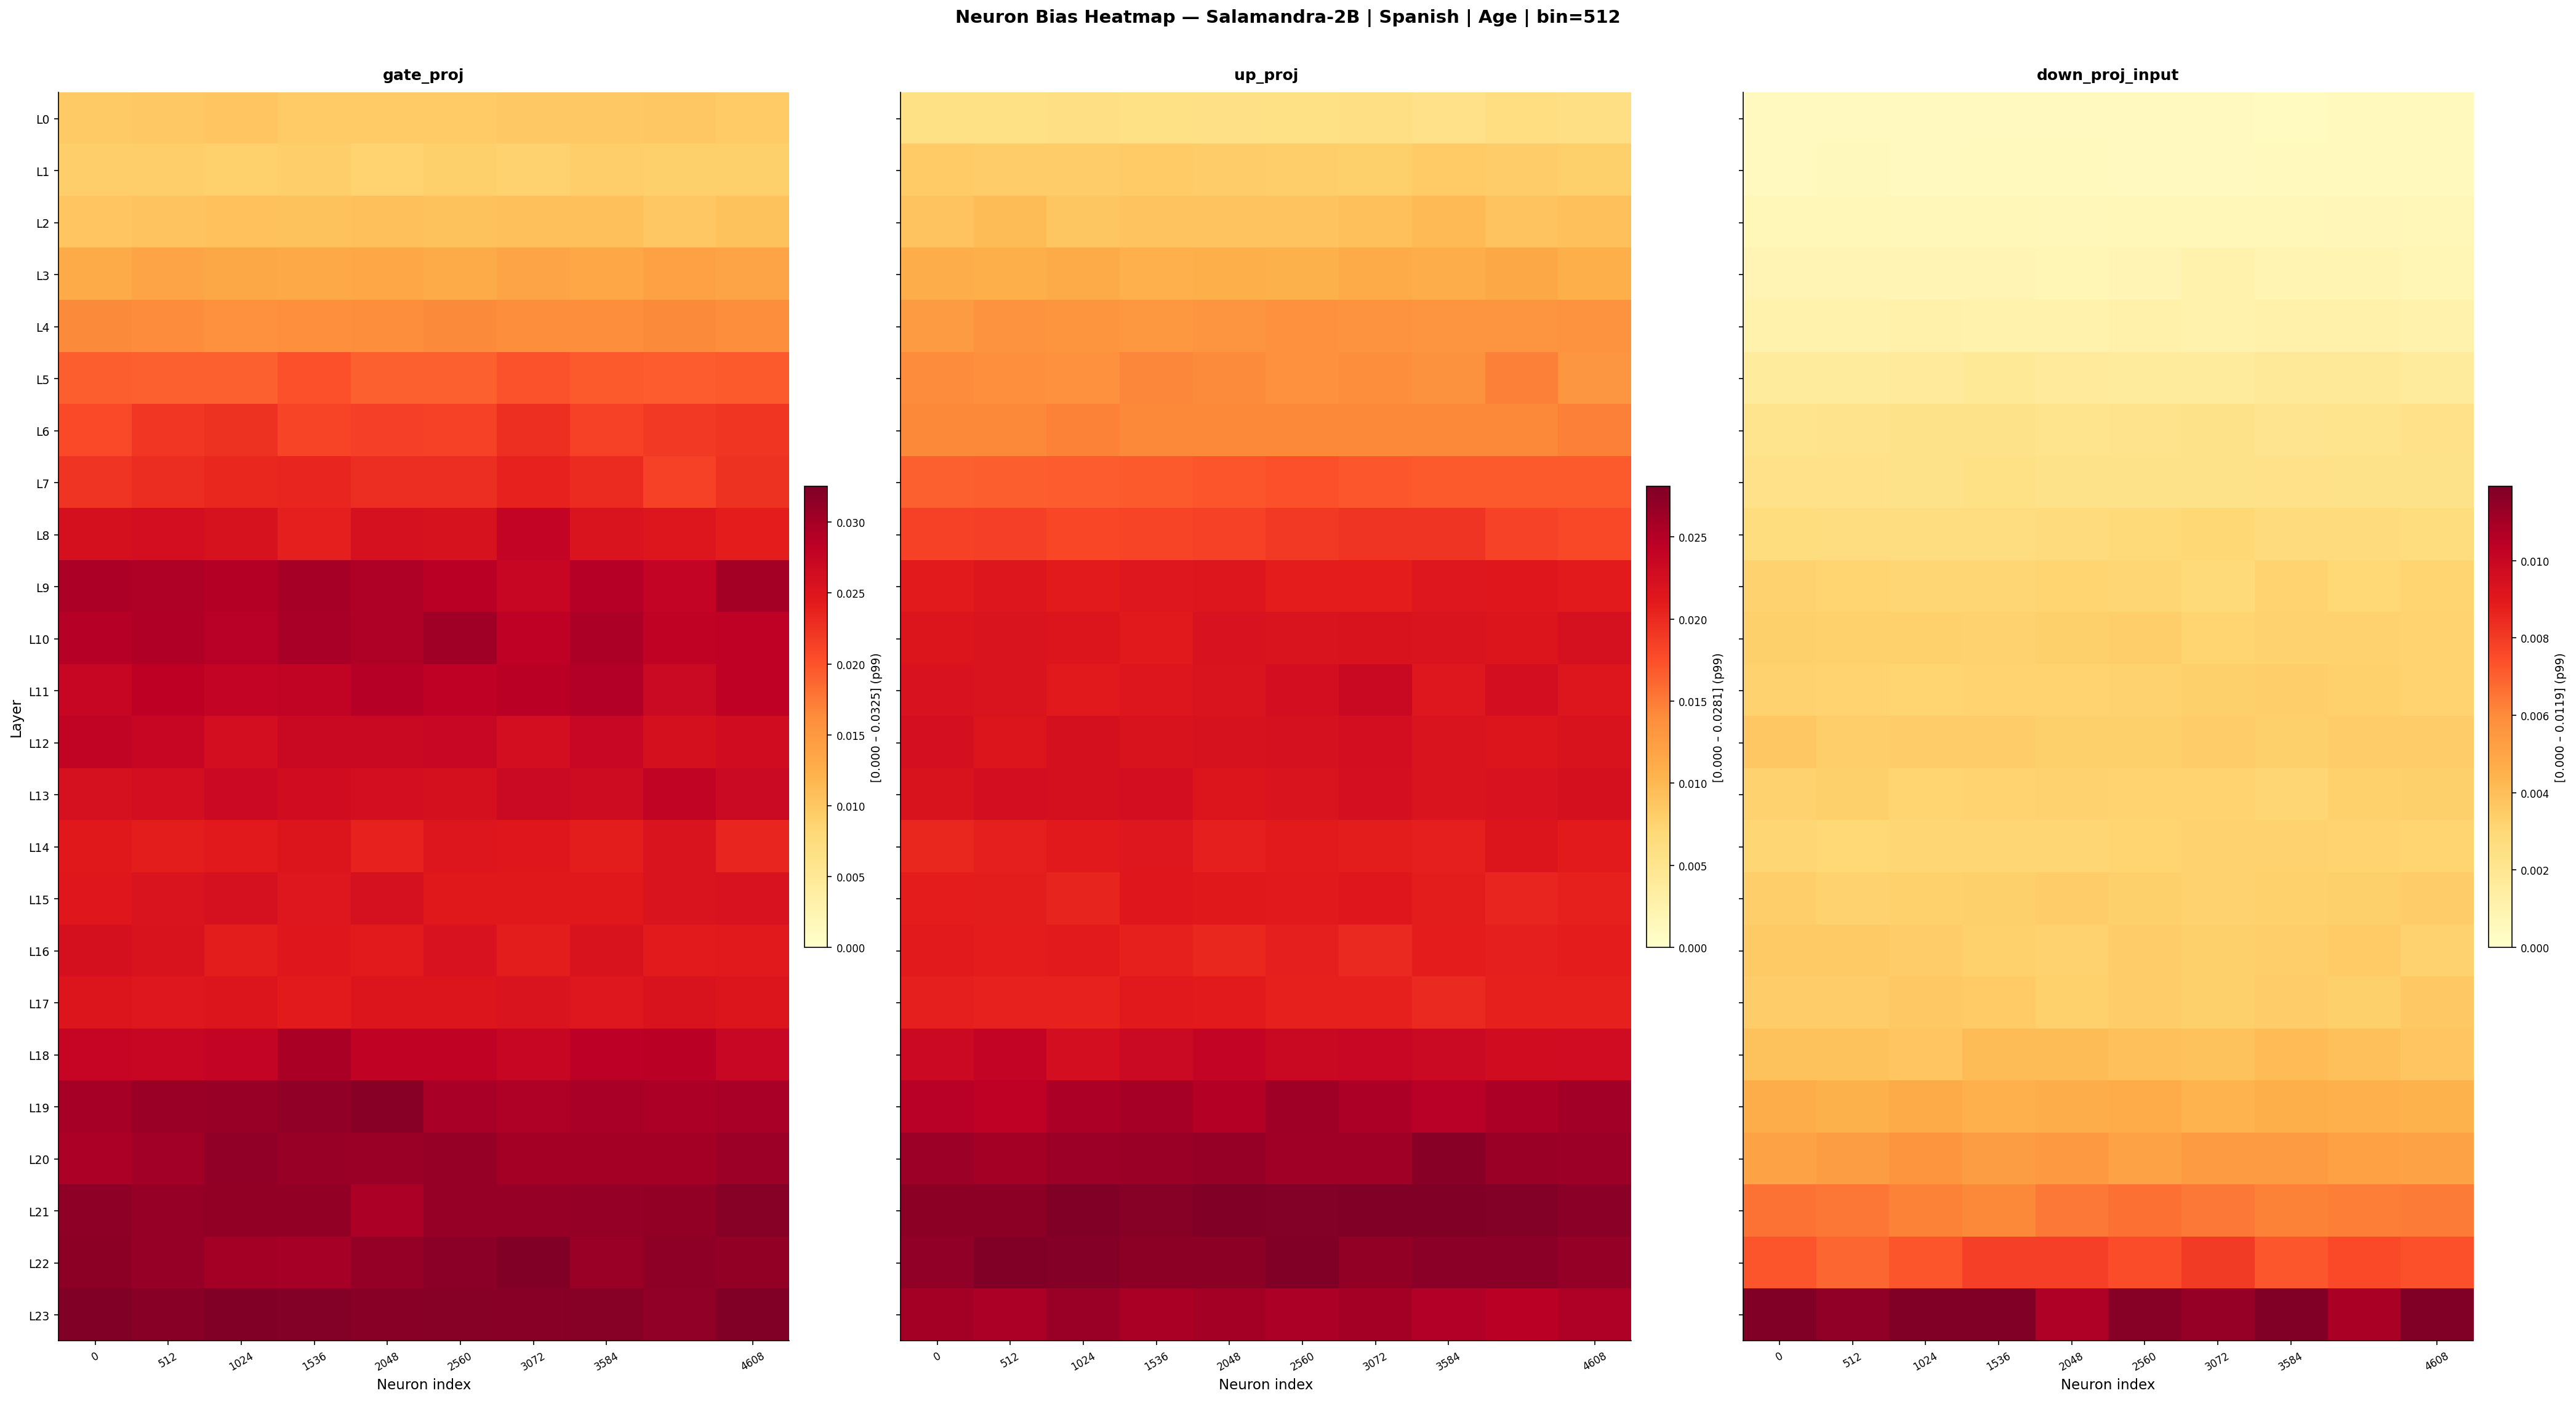


  salamandra-2B | ES | Gender
  gate_proj                     : vmax(p99)=0.052411 | abs max=0.054167
  up_proj                       : vmax(p99)=0.042409 | abs max=0.042986
  down_proj_input               : vmax(p99)=0.017974 | abs max=0.020666
Saved: neuron_heatmap_salamandra-2B_es_Gender_bin512


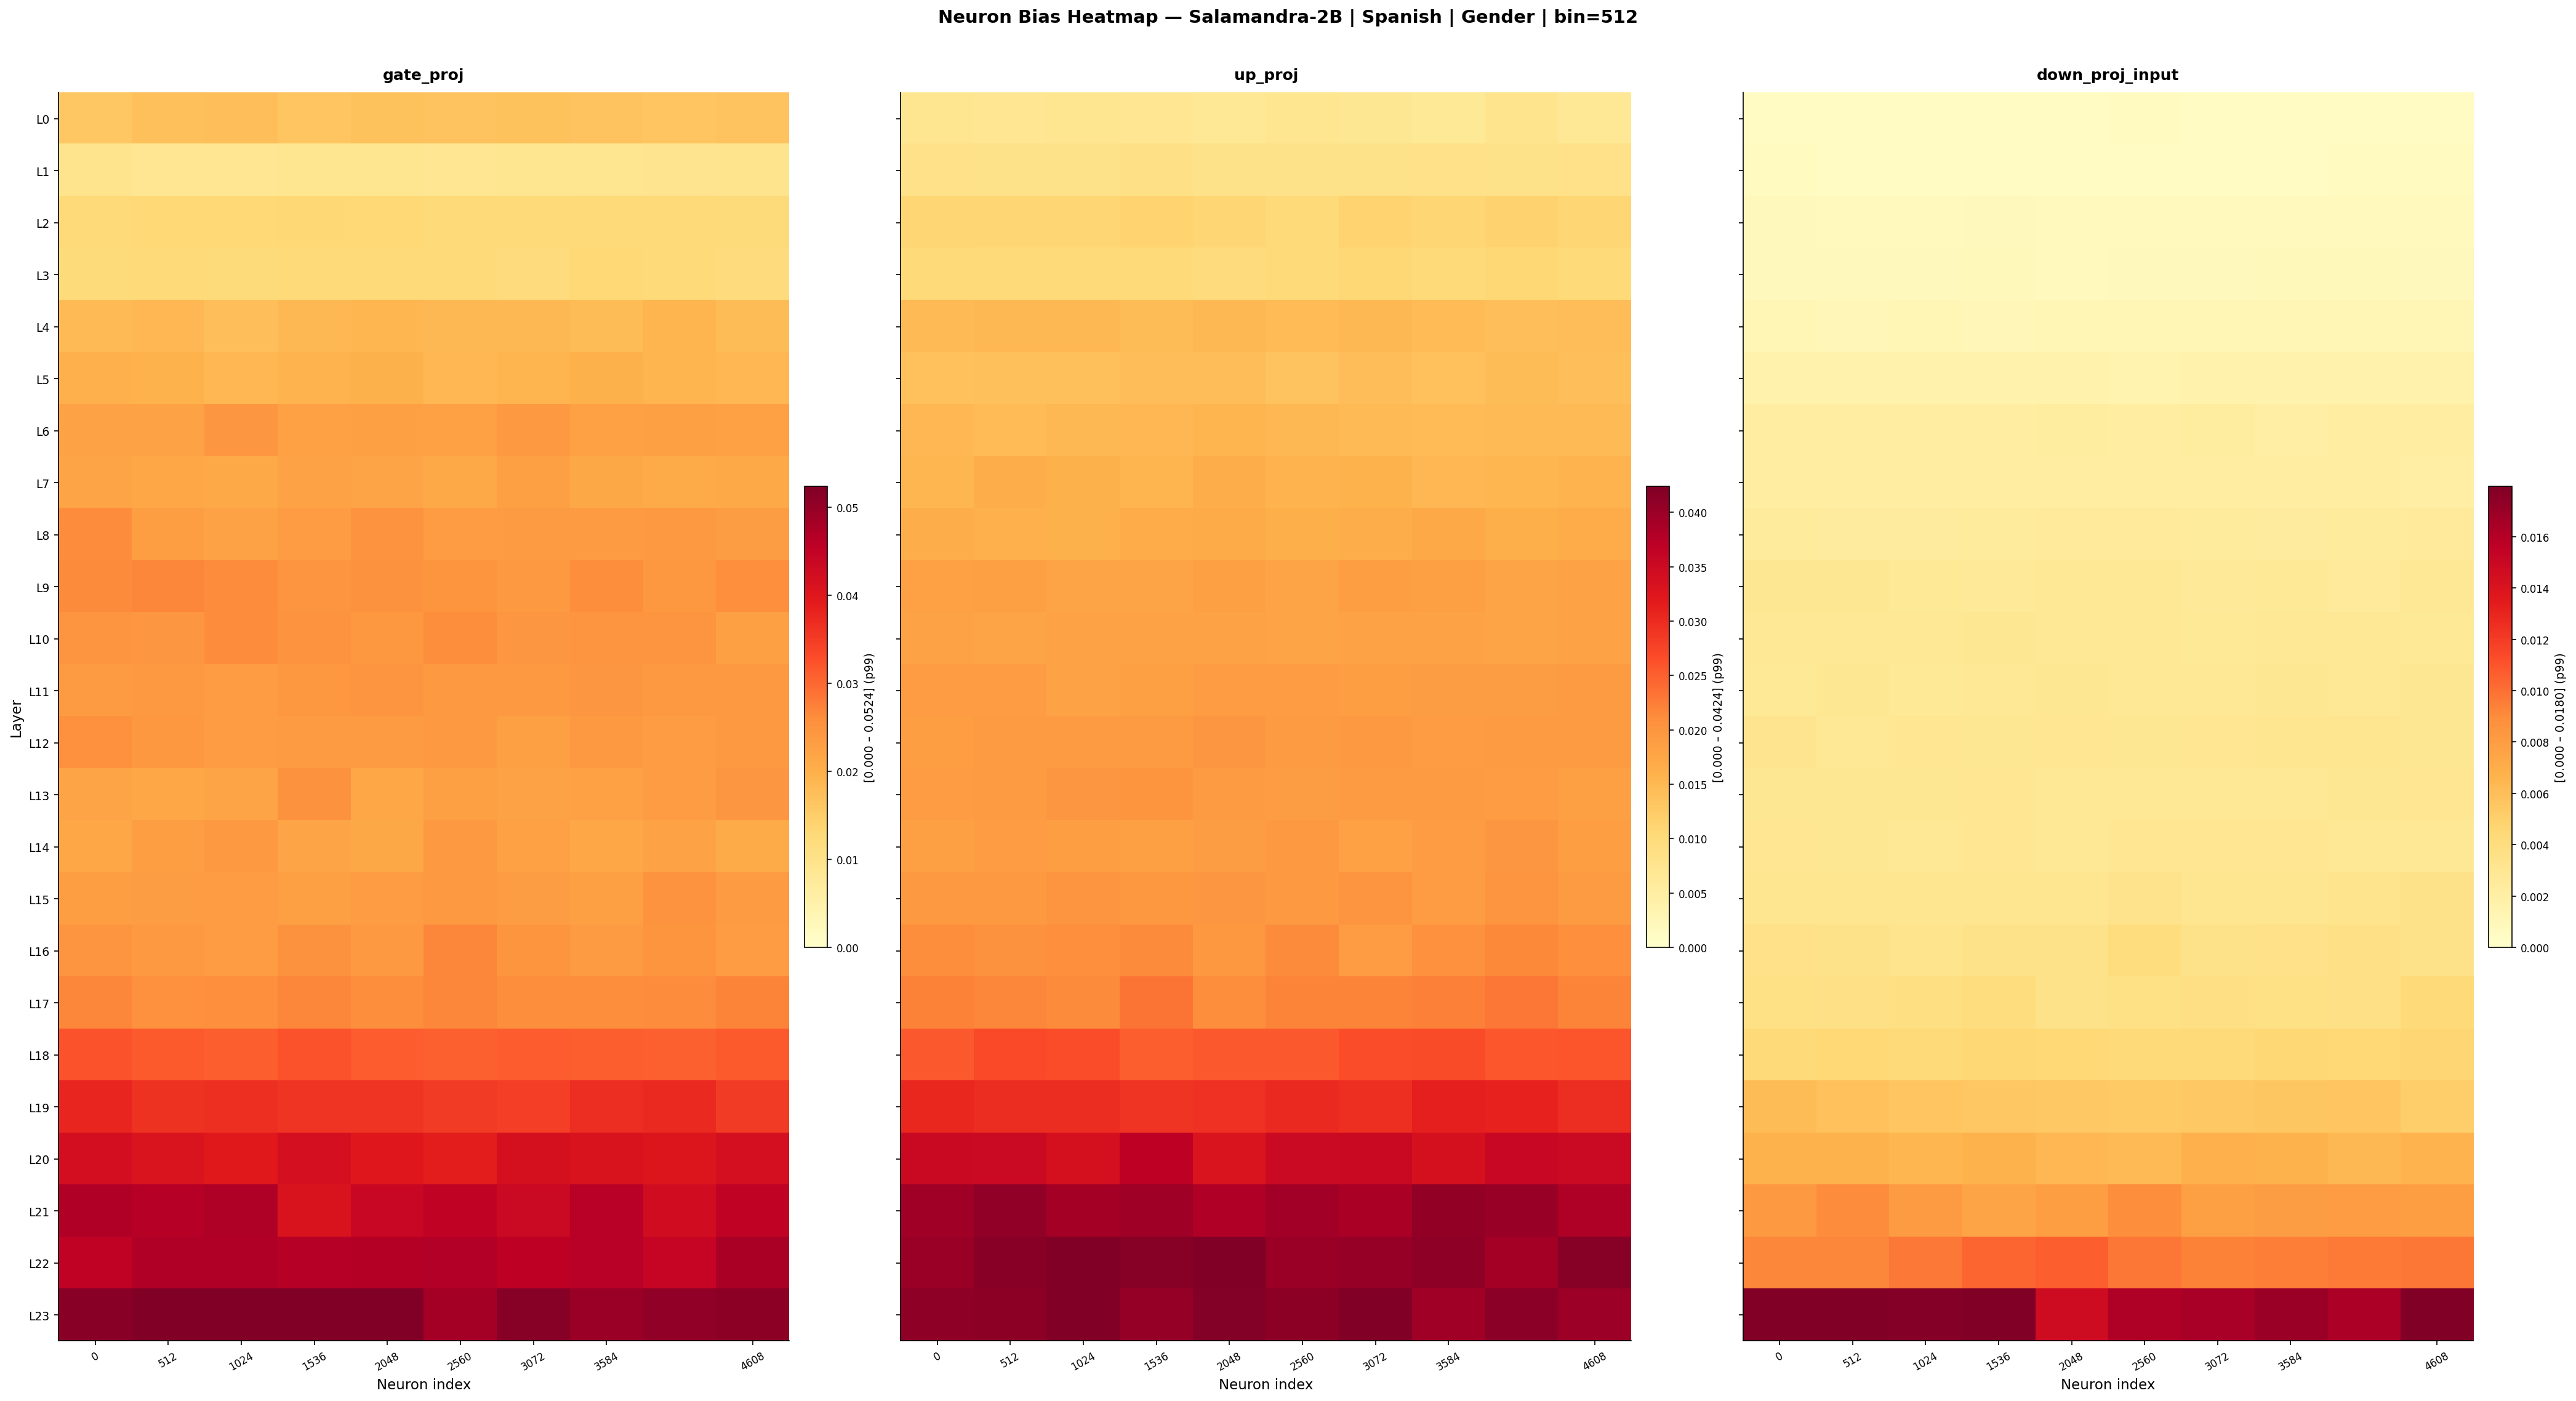


  salamandra-2B | ES | PhysicalAppearance
  gate_proj                     : vmax(p99)=0.045176 | abs max=0.045716
  up_proj                       : vmax(p99)=0.036522 | abs max=0.037568
  down_proj_input               : vmax(p99)=0.015760 | abs max=0.016539
Saved: neuron_heatmap_salamandra-2B_es_PhysicalAppearance_bin512


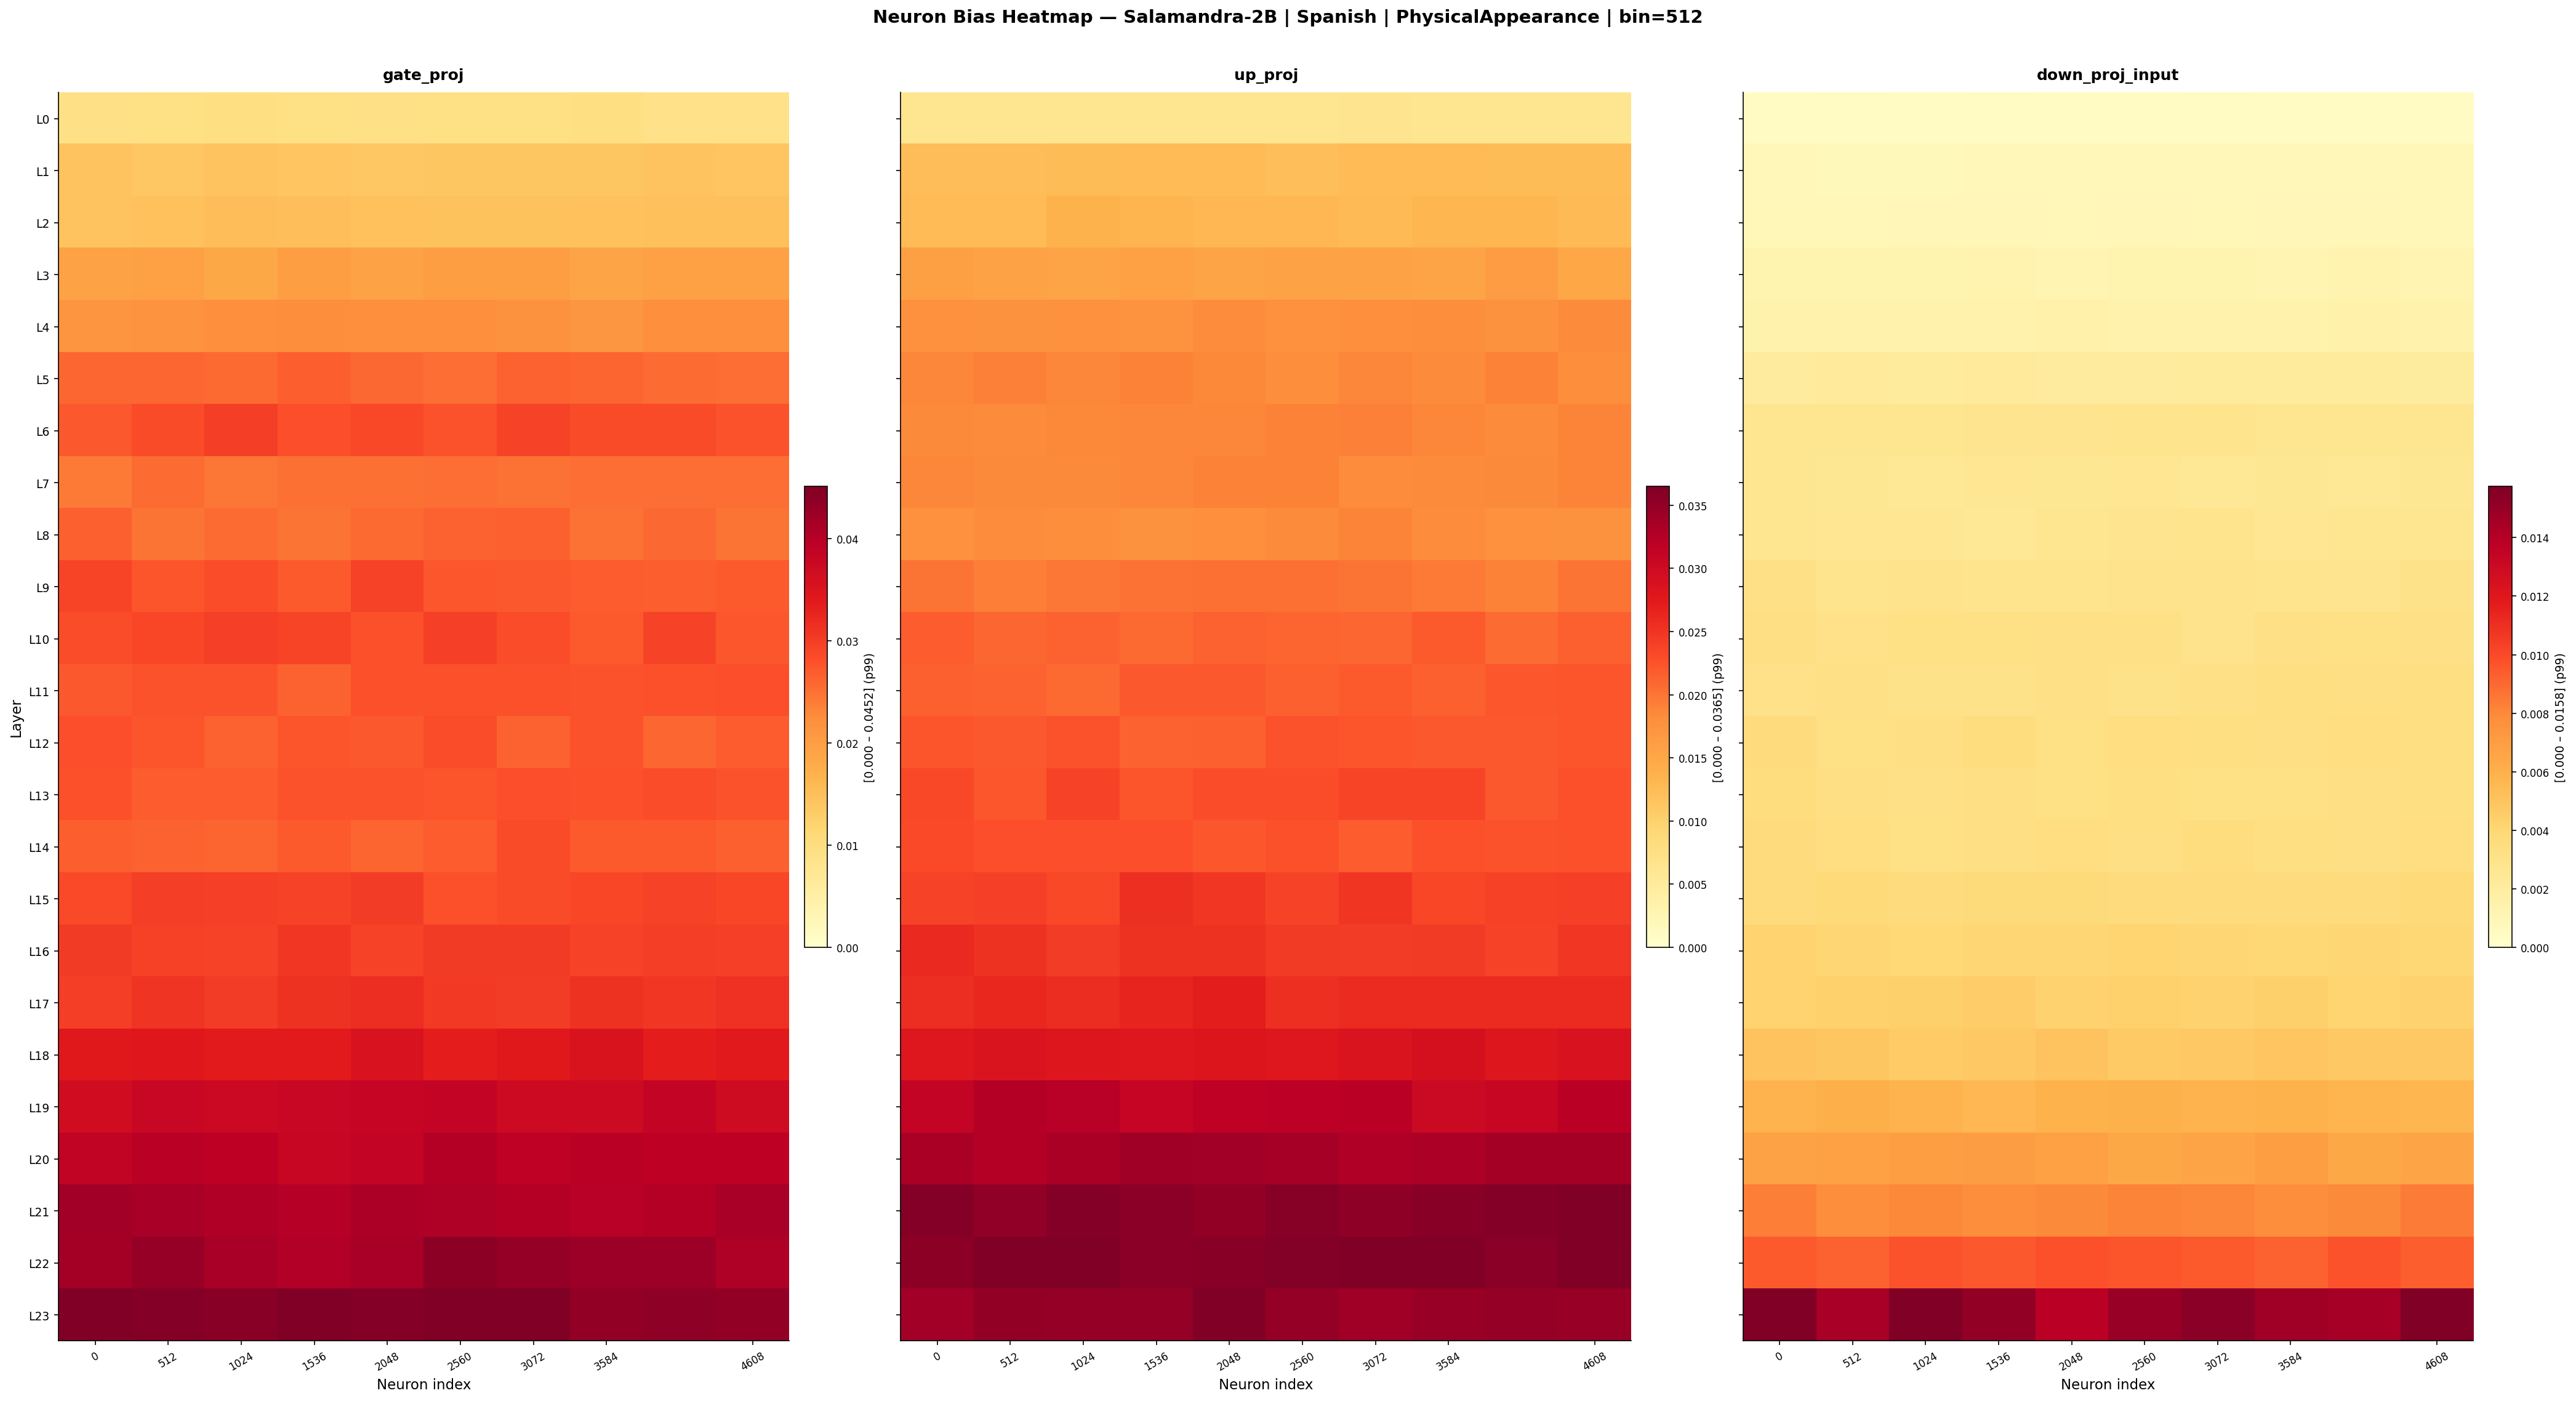


  salamandra-2B | ES | RaceEthnicity
  gate_proj                     : vmax(p99)=0.023028 | abs max=0.023471
  up_proj                       : vmax(p99)=0.018188 | abs max=0.018493
  down_proj_input               : vmax(p99)=0.008080 | abs max=0.008483
Saved: neuron_heatmap_salamandra-2B_es_RaceEthnicity_bin512


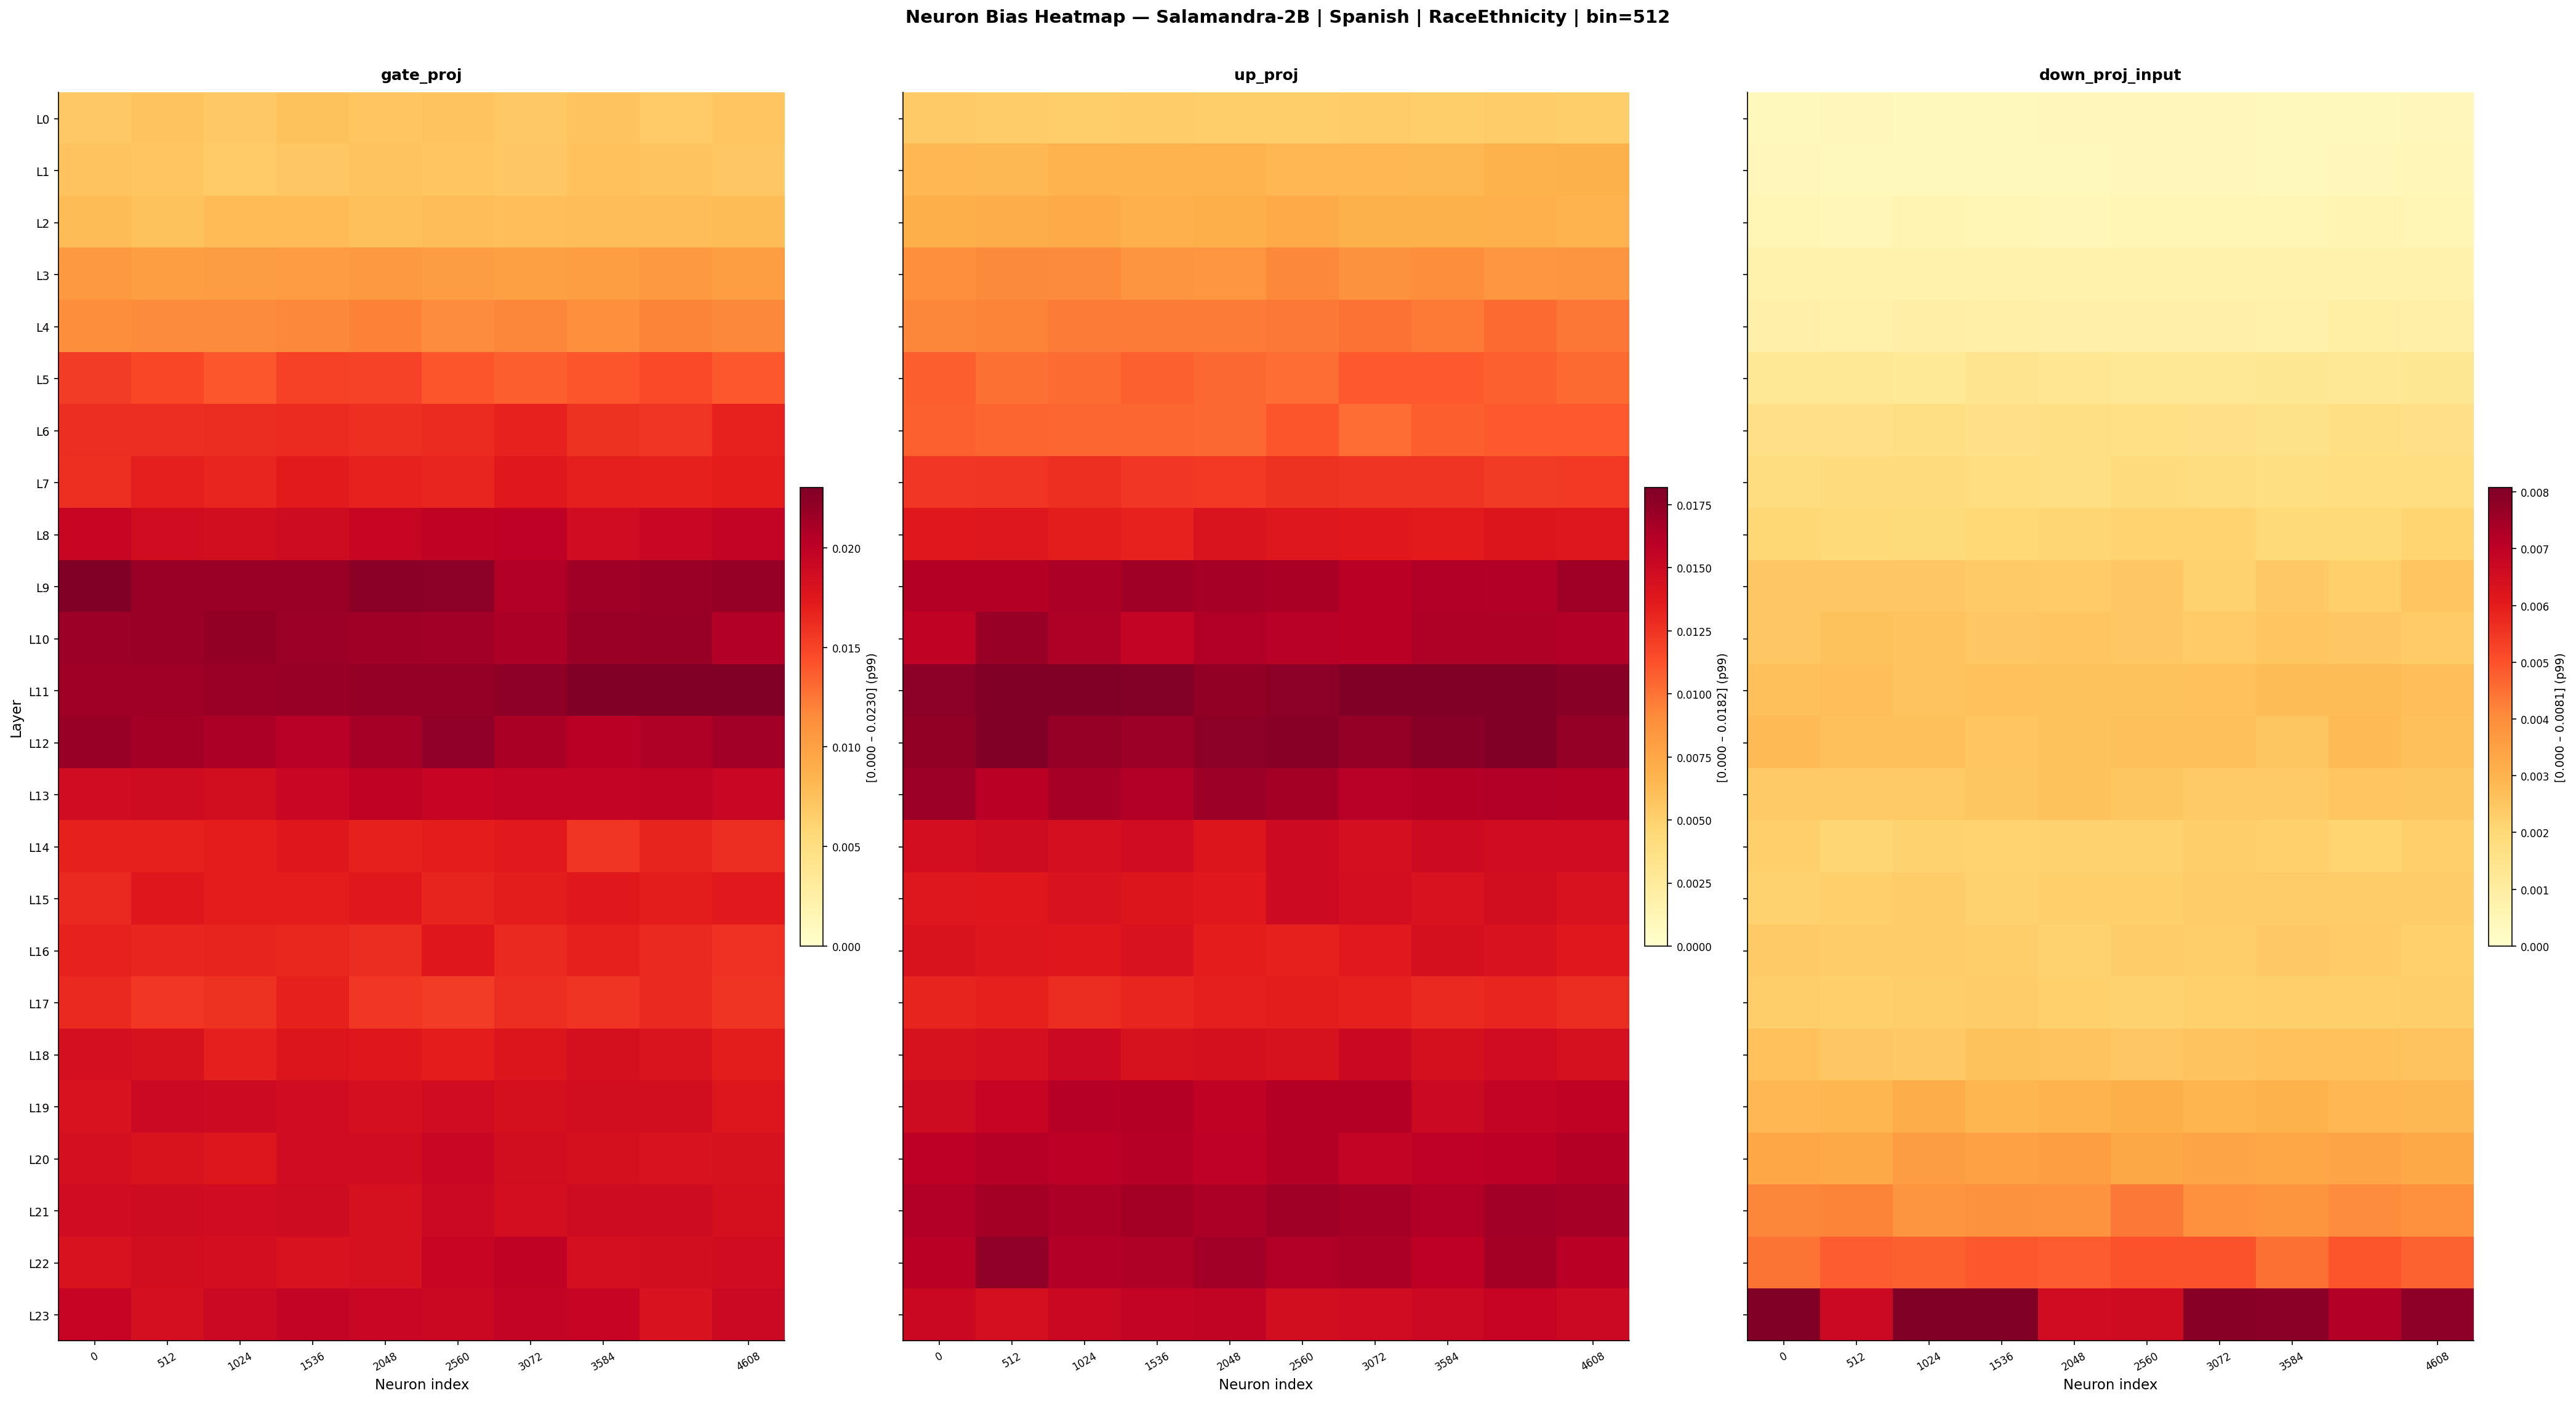


  salamandra-2B | ES | Religion
  gate_proj                     : vmax(p99)=0.053410 | abs max=0.054035
  up_proj                       : vmax(p99)=0.045445 | abs max=0.046998
  down_proj_input               : vmax(p99)=0.019596 | abs max=0.020922
Saved: neuron_heatmap_salamandra-2B_es_Religion_bin512


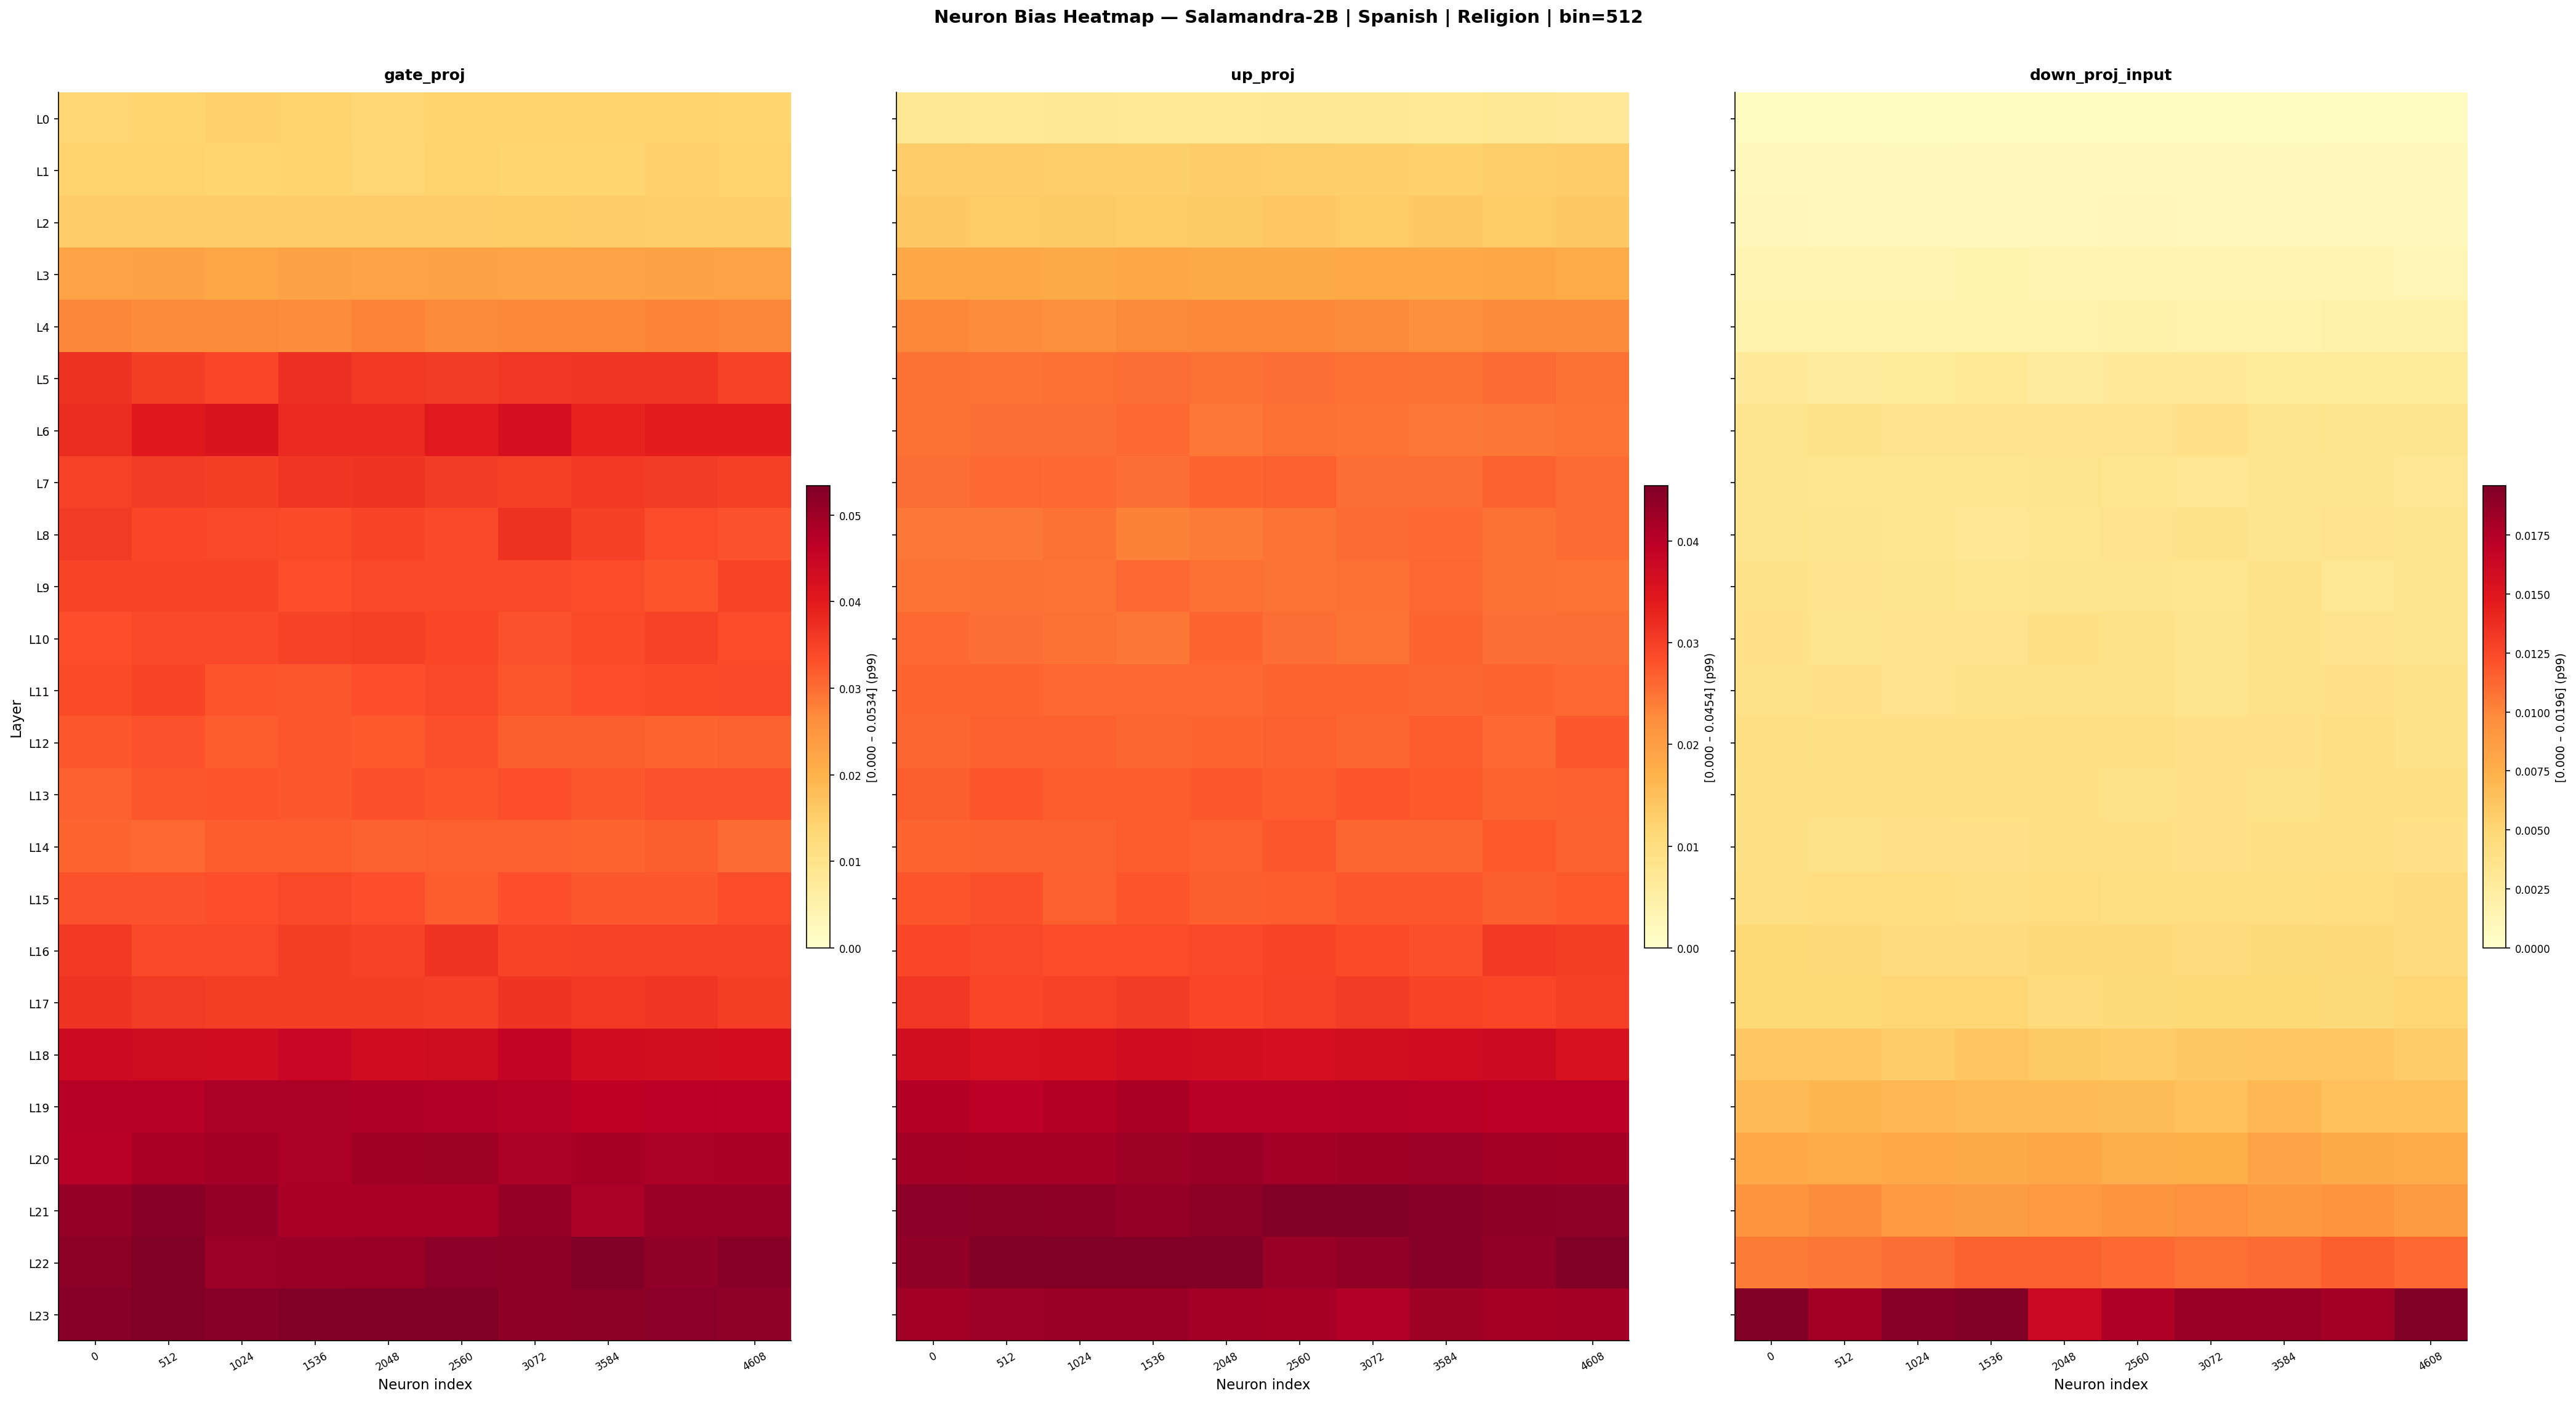

In [ ]:
"""
Complete neuron heatmap generation — all models, languages and categories.
Add this cell after the existing plot_neuron_heatmap calls in the notebook.

Generates Layer × Neuron-bin heatmaps (gate | up | GLU combined)
for all combinations of model × language × category.

Output: results/figures/bias_path/neuron_heatmap_{model}_{lang}_{category}_bin512.png/pdf
"""

BIN_SIZE = 512  # Change here to adjust granularity for all plots

for model_key in MODELS:
    for lang in ["en", "es"]:
        categories = CATEGORIES_BY_LANG[lang]
        for category in categories:
            print(f"\n{'='*60}")
            print(f"  {model_key} | {lang.upper()} | {category}")
            print(f"{'='*60}")
            plot_neuron_heatmap(model_key, lang, category, bin_size=BIN_SIZE)

**Utility**

The Layer × Neuron-bin heatmap provides the most granular view of bias localization available in this analysis. While the Bias Path heatmaps show which layers are most biased on average across categories, this plot adds a second dimension: within each layer, which specific neuron groups carry the bias signal. The three panels — gate_proj, up_proj, and down_proj_input — reflect the internal structure of the GLU MLP block. The first two capture the bias signal before the multiplicative interaction; the third captures the activation at the input of the down projection, after gate and up have been combined element-wise. This is the signal that actually propagates into the residual stream, making down_proj_input the most direct indicator of which neurons are effective bias carriers — and the primary basis for pruning candidate selection. Each panel uses a local color scale (p99 of that panel's values), so intensity is comparable across layers and neuron positions within a panel but not across panels.

**Interpretation**

The neuron-level data reveals three structural properties that the layer-aggregated heatmaps could only hint at.

The first is that bias within a layer is spatially distributed, not localized to a region of the neuron index. The average span covered by the top-50 most biased neurons in each deep layer is consistently between 0.94 and 0.98 of the layer width across all categories, models and languages. There is no "left side" or "right side" of the layer that concentrates bias — the high-scoring neurons are scattered along the full intermediate dimension. This rules out any pruning strategy based on contiguous neuron blocks and means that fairness pruning must operate on individual neuron indices.

The second is the radical concentration produced by the GLU multiplication at the layer level. Counting how many distinct layers contribute to the top-50 globally biased neurons, the contrast between projections is sharp. In gate_proj and up_proj the top-50 typically spans 12-22 layers — meaning bias signal builds up gradually across most of the model's depth. In down_proj_input the same count collapses to 1-13 layers. The most extreme cases are in Salamandra-2B, where down_proj_input concentrates the top-50 of every PhysicalAppearance category into a single layer (L23, with all 50 neurons): the GLU multiplication acts as an almost binary depth filter. The Llama models show a milder but still substantial filtering effect, with down_proj_input typically narrowing to 6-12 distinct layers from 12-22 in the individual projections.

The third is the model-family difference in how concentrated the post-GLU signal becomes. Looking at the top-200 globally biased neurons per category and counting how many fall in the final layer alone:

* Salamandra-2B places 79-94% of its top-200 neurons in L23 across all categories and both languages
* Llama-1B places 53-80% in L15
* Llama-3B is the most distributed, with 38-68% in L27

Adding the penultimate layer raises these figures to 87-99% for Salamandra, 75-87% for Llama-1B, and 47-76% for Llama-3B. The implication for pruning is concrete: a Salamandra fairness intervention can target two layers and capture almost all the candidates, while a Llama-3B intervention needs to consider at least three to five layers per category to cover the same fraction. This is one of the clearest architectural differences observed in the analysis.

Beyond these structural patterns, two category-specific observations are worth noting.

Gender behaves differently from the other categories under GLU filtering. While other categories collapse aggressively into the final layer (Salamandra particularly), Gender consistently retains the widest distribution across layers in down_proj_input. In Llama-3B English, Gender's top-50 spans 18 distinct layers with the dominant layer (L27) containing only 14 of the 50 neurons — by far the least concentrated profile in the entire table. This contradicts the common reading that Gender bias is "easy to target" because of its sparse outlier-based encoding: the post-GLU signal is sparse in magnitude but distributed across depth. Effective Gender pruning would therefore require a multi-layer intervention, not a surgical strike on one or two layers.

The categories with the highest peak intensity in the top-50 are not always the categories with the highest mean bias score. Religion in Llama-3B Spanish (avg top-50 value 0.129) and Llama-1B English (0.102), and Gender in Llama-1B Spanish (0.099) and Llama-3B Spanish (0.114), all exceed the corresponding PhysicalAppearance values in deep layers. PhysicalAppearance dominates the mean scores because its bias is encoded across many moderately biased neurons; the top-50 values reveal that other categories produce more extreme individual neurons even when their average is lower. For pruning strategies that target only the most biased neurons (rather than the broadest signal), Religion and Gender may be more sensitive intervention targets than the mean-based ranking suggests.

In [ ]:
# --- Generate for Llama-1B, PhysicalAppearance, EN and ES ---
#plot_neuron_heatmap("llama-3.2-1B", "en", "PhysicalAppearance", bin_size=512)
#plot_neuron_heatmap("llama-3.2-1B", "es", "PhysicalAppearance", bin_size=512)

---
## Sprint 3 — Overlap Analysis
### 3.1 Jaccard Index between bias categories

In [14]:
def jaccard_index(set_a, set_b):
    """Jaccard Index between two sets. Returns 0.0 if both are empty."""
    if not set_a and not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0


def build_jaccard_matrix(top_k_dict, categories):
    """
    Build a symmetric Jaccard matrix for the given categories.

    Returns
    -------
    matrix : np.ndarray of shape (n_categories, n_categories)
    """
    n = len(categories)
    matrix = np.zeros((n, n))
    for i, cat_a in enumerate(categories):
        for j, cat_b in enumerate(categories):
            set_a = top_k_dict.get(cat_a, set())
            set_b = top_k_dict.get(cat_b, set())
            matrix[i, j] = jaccard_index(set_a, set_b)
    return matrix


In [15]:
def plot_jaccard_matrix(matrix, categories, title, save_stem=None):
    """Plot a Jaccard similarity heatmap."""
    col_labels = [CATEGORY_LABELS[c] for c in categories]
    mask = np.eye(len(categories), dtype=bool)  # mask diagonal for clarity

    fig, ax = plt.subplots(figsize=(len(categories) * 1.4 + 1, len(categories) * 1.2 + 1))

    sns.heatmap(
        matrix,
        ax=ax,
        cmap="Blues",
        annot=True,
        fmt=".3f",
        xticklabels=col_labels,
        yticklabels=col_labels,
        vmin=0, vmax=1,
        linewidths=0.5,
        cbar_kws={"label": "Jaccard Index", "shrink": 0.7},
        mask=mask,
    )
    # Fill diagonal manually
    for i in range(len(categories)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, color="#f0f0f0", lw=0))
        ax.text(i + 0.5, i + 0.5, "1.0", ha="center", va="center",
                fontsize=9, color="#888888")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()

    if save_stem:
        for ext in ["png", "pdf"]:
            fpath = FIGURES_DIR / f"{save_stem}.{ext}"
            plt.savefig(fpath, bbox_inches="tight")
        print(f"Saved: {save_stem}")

    plt.show()

In [16]:
# --- Extended Top-K extraction adding Top-0.1% ---
TOP_K_THRESHOLDS = {"Out01": 0.001, "top1": 0.01, "top5": 0.05}

top_k_neurons = {}

for model_key in MODELS:
    top_k_neurons[model_key] = {}
    for lang in ["en", "es"]:
        top_k_neurons[model_key][lang] = {}
        for threshold_name, threshold_val in TOP_K_THRESHOLDS.items():
            top_k_neurons[model_key][lang][threshold_name] = extract_top_k_neurons(
                bias_data_norm[model_key][lang], threshold_val
            )

# --- Summary ---
print(f"{'Model':<20} {'Lang':<5} {'Threshold':<10} {'Category':<22} {'Neurons':>8}")
print("-" * 70)
for model_key in MODELS:
    for lang in ["en", "es"]:
        for threshold_name in TOP_K_THRESHOLDS:
            for category, neurons in top_k_neurons[model_key][lang][threshold_name].items():
                print(f"{model_key:<20} {lang:<5} {threshold_name:<10} {category:<22} {len(neurons):>8}")

Model                Lang  Threshold  Category                Neurons
----------------------------------------------------------------------
llama-3.2-1B         en    Out01      Age                         132
llama-3.2-1B         en    Out01      Gender                      132
llama-3.2-1B         en    Out01      PhysicalAppearance          132
llama-3.2-1B         en    Out01      RaceEthnicity               132
llama-3.2-1B         en    Out01      Religion                    132
llama-3.2-1B         en    top1       Age                        1311
llama-3.2-1B         en    top1       Gender                     1311
llama-3.2-1B         en    top1       PhysicalAppearance         1311
llama-3.2-1B         en    top1       RaceEthnicity              1311
llama-3.2-1B         en    top1       Religion                   1311
llama-3.2-1B         en    top5       Age                        6554
llama-3.2-1B         en    top5       Gender                     6554
llama-3.2-1B       

In [17]:
import pandas as pd

# Build a compact summary of Jaccard statistics per (model, lang, threshold)
rows = []
for model_key in MODELS:
    for lang in ["en", "es"]:
        categories = CATEGORIES_BY_LANG[lang]
        for threshold_name in TOP_K_THRESHOLDS:
            top_k_dict = top_k_neurons[model_key][lang][threshold_name]
            pairs = []
            for i, cat_a in enumerate(categories):
                for cat_b in categories[i+1:]:
                    j = jaccard_index(top_k_dict.get(cat_a, set()),
                                      top_k_dict.get(cat_b, set()))
                    pairs.append((cat_a, cat_b, j))
            pairs.sort(key=lambda x: x[2], reverse=True)

            values = [p[2] for p in pairs]
            highest = pairs[0]
            lowest = pairs[-1]

            # Pairs involving Gender vs all others
            gender_pairs = [p for p in pairs if "Gender" in (p[0], p[1])]
            gender_values = [p[2] for p in gender_pairs]

            rows.append({
                "model": model_key,
                "lang": lang,
                "threshold": threshold_name,
                "n_pairs": len(pairs),
                "min": round(min(values), 3),
                "max": round(max(values), 3),
                "median": round(np.median(values), 3),
                "mean": round(np.mean(values), 3),
                "highest_pair": f"{highest[0]}+{highest[1]}",
                "lowest_pair": f"{lowest[0]}+{lowest[1]}",
                "gender_mean": round(np.mean(gender_values), 3),
                "gender_max": round(max(gender_values), 3),
                "non_gender_mean": round(
                    np.mean([p[2] for p in pairs if "Gender" not in (p[0], p[1])]), 3
                ),
            })

df_jaccard = pd.DataFrame(rows)
print("=" * 110)
print("JACCARD SUMMARY — per (model, lang, threshold)")
print("=" * 110)
for (model_key, lang), grp in df_jaccard.groupby(["model", "lang"]):
    print(f"\n--- {model_key} | {lang} ---")
    for _, r in grp.iterrows():
        print(f"  {r['threshold']:6s} | range [{r['min']:.3f}, {r['max']:.3f}] "
              f"med={r['median']:.3f} mean={r['mean']:.3f} | "
              f"top: {r['highest_pair']:40s} | "
              f"bot: {r['lowest_pair']:40s} | "
              f"Gender pairs avg={r['gender_mean']:.3f} (vs non-Gender={r['non_gender_mean']:.3f})")

# Verify the L23-concentration artifact for Salamandra at Top-0.1%
print("\n" + "=" * 110)
print("VERIFICATION — Top-0.1% candidate concentration in single layer")
print("=" * 110)
for model_key in MODELS:
    n_layers = MODELS[model_key]["n_layers"]
    last_layer = n_layers - 1
    for lang in ["en", "es"]:
        top_k_dict = top_k_neurons[model_key][lang]["Out01"]
        for category in CATEGORIES_BY_LANG[lang]:
            neurons = top_k_dict.get(category, set())
            n_total = len(neurons)
            n_in_last = sum(1 for (li, ni, p) in neurons if li == last_layer)
            pct = n_in_last / n_total if n_total > 0 else 0
            print(f"  {model_key:18s} | {lang} | {category:20s} | "
                  f"total={n_total:3d} | in L{last_layer}={n_in_last:3d} ({pct:.1%})")

JACCARD SUMMARY — per (model, lang, threshold)

--- llama-3.2-1B | en ---
  Out01  | range [0.163, 0.320] med=0.231 mean=0.235 | top: PhysicalAppearance+Religion              | bot: Gender+RaceEthnicity                     | Gender pairs avg=0.183 (vs non-Gender=0.270)
  top1   | range [0.263, 0.321] med=0.302 mean=0.295 | top: Age+PhysicalAppearance                   | bot: Age+Gender                               | Gender pairs avg=0.272 (vs non-Gender=0.311)
  top5   | range [0.253, 0.310] med=0.289 mean=0.286 | top: PhysicalAppearance+Religion              | bot: Gender+RaceEthnicity                     | Gender pairs avg=0.270 (vs non-Gender=0.297)

--- llama-3.2-1B | es ---
  Out01  | range [0.105, 0.234] med=0.160 mean=0.168 | top: RaceEthnicity+Religion                   | bot: Gender+PhysicalAppearance                | Gender pairs avg=0.127 (vs non-Gender=0.195)
  top1   | range [0.204, 0.312] med=0.249 mean=0.251 | top: RaceEthnicity+Religion                   | bot: Age+Gen

Saved: jaccard_llama-3.2-1B_en_Out01


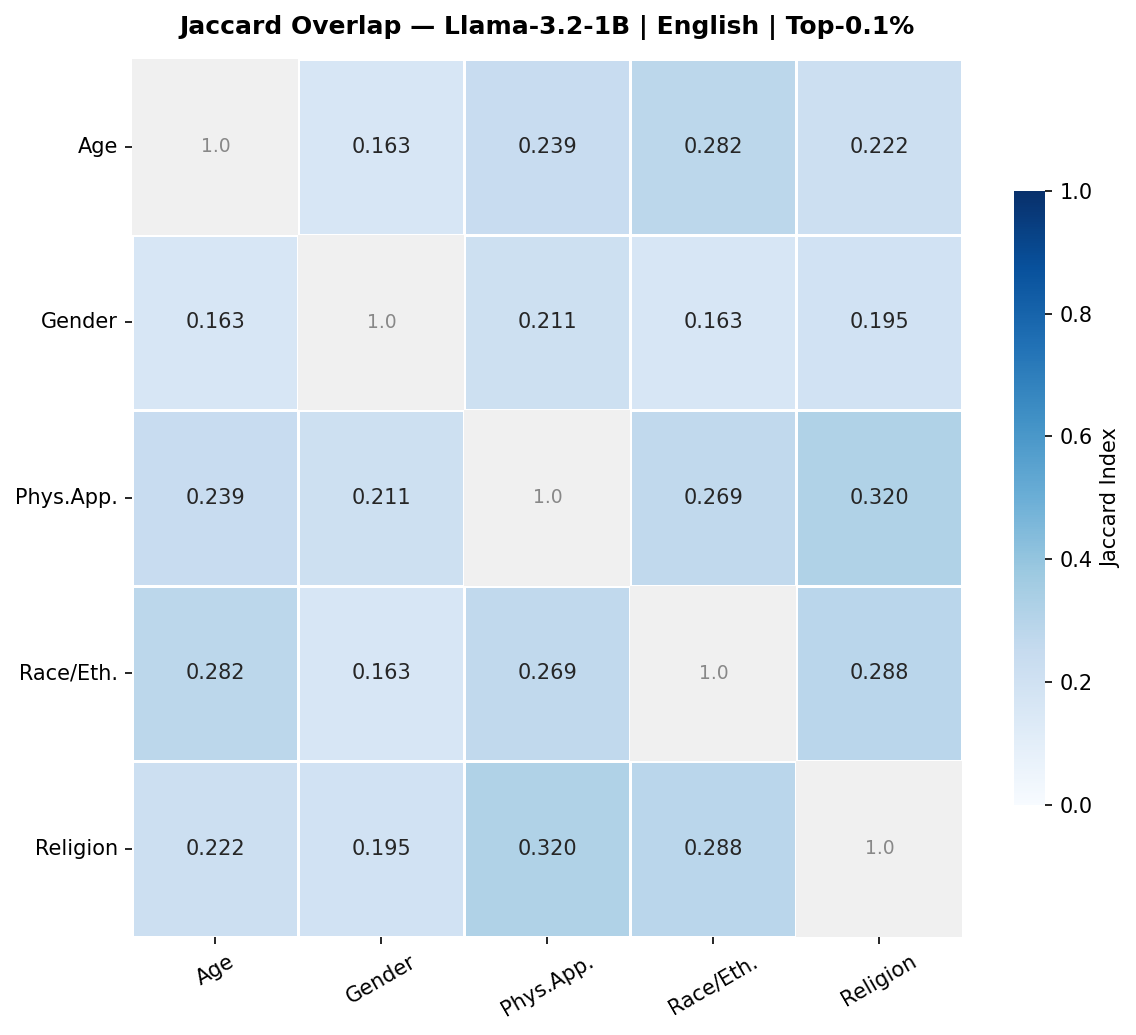

Saved: jaccard_llama-3.2-1B_en_top1


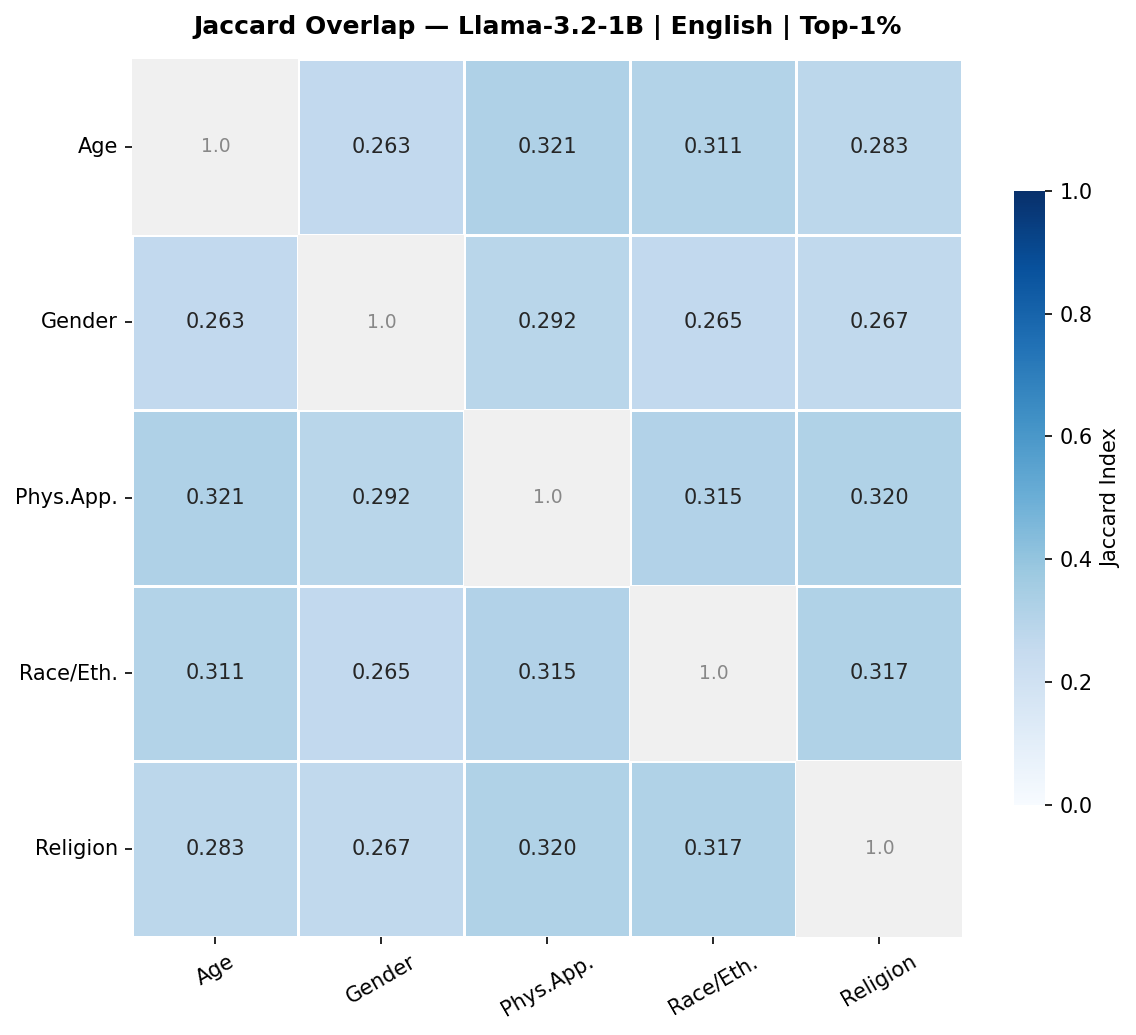

Saved: jaccard_llama-3.2-1B_en_top5


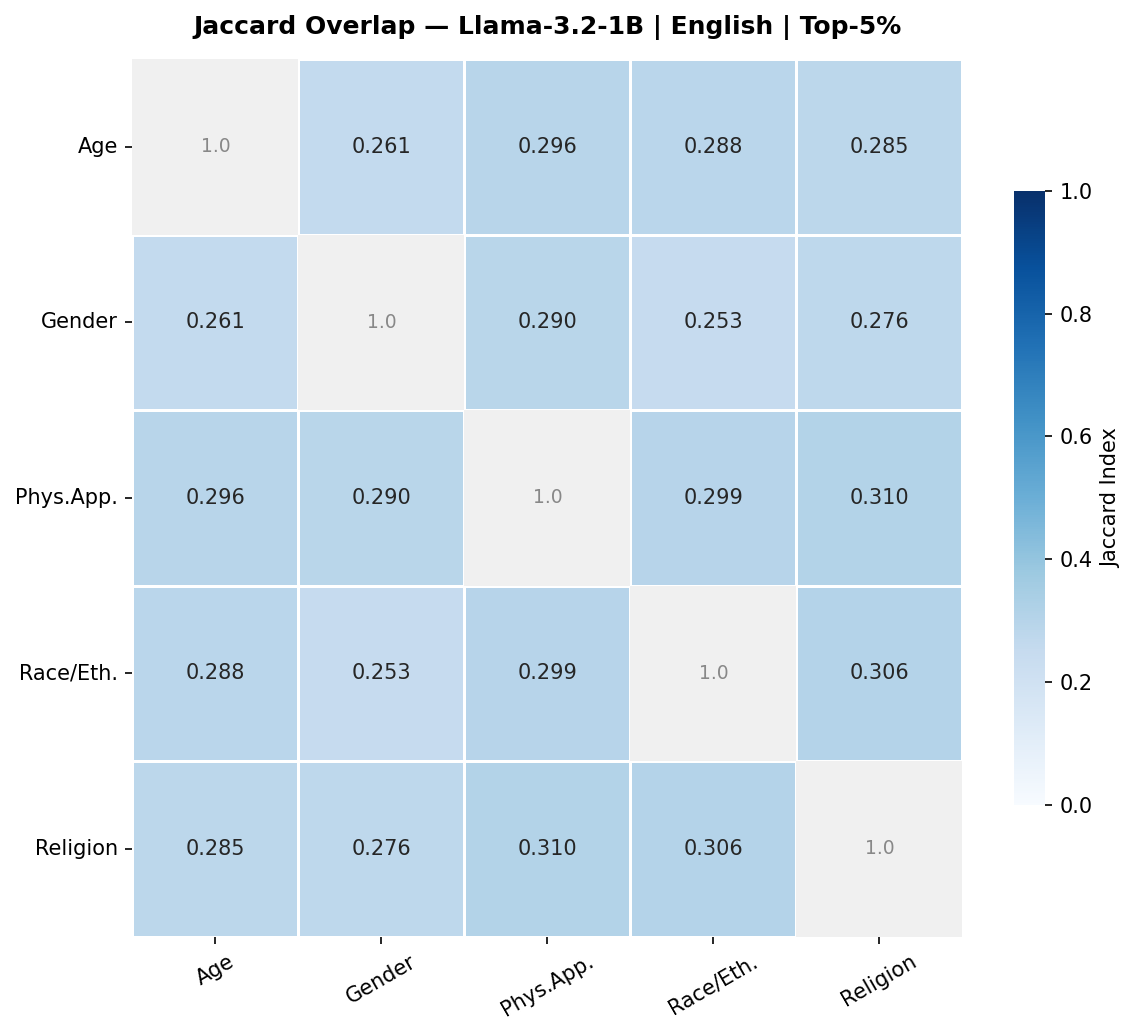

Saved: jaccard_llama-3.2-1B_es_Out01


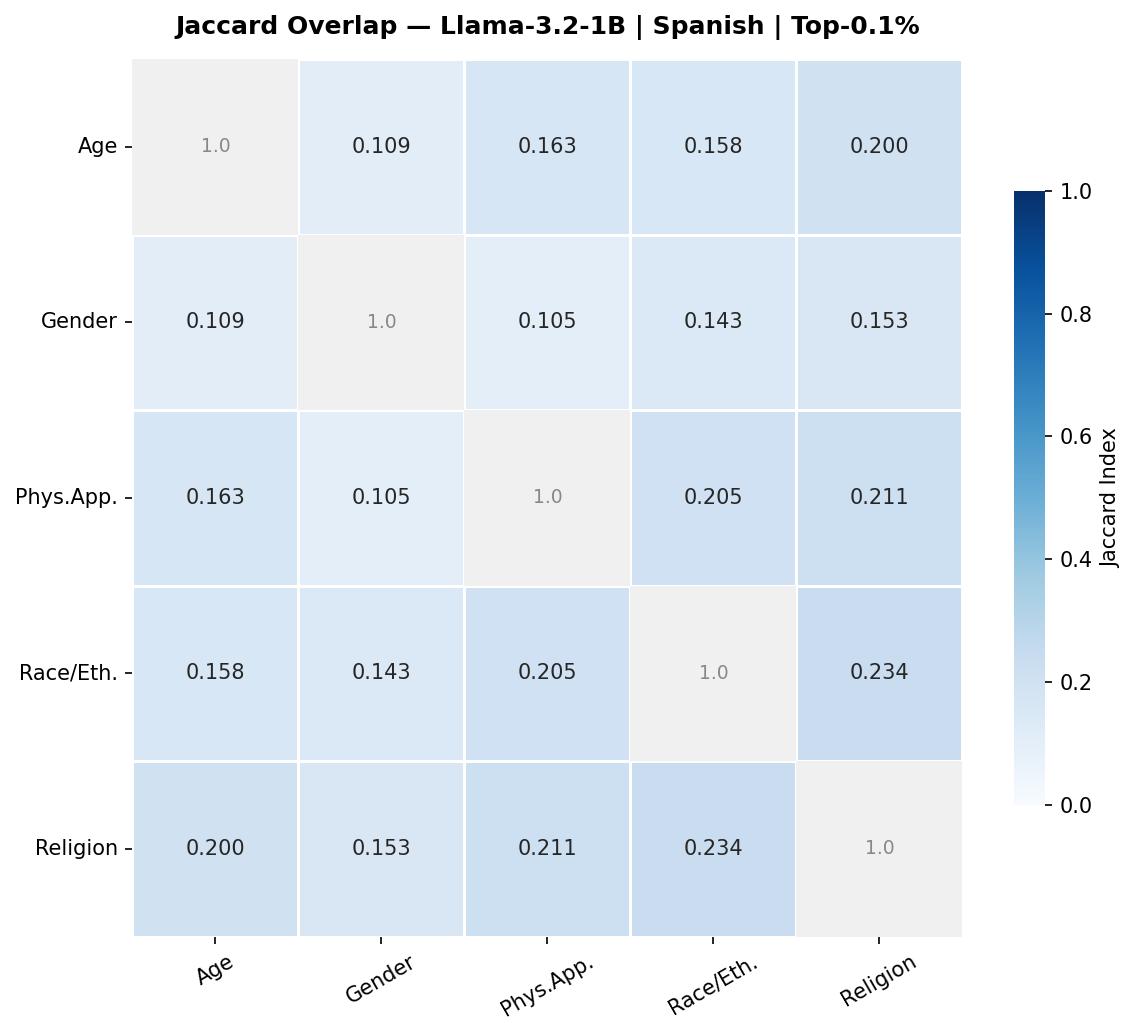

Saved: jaccard_llama-3.2-1B_es_top1


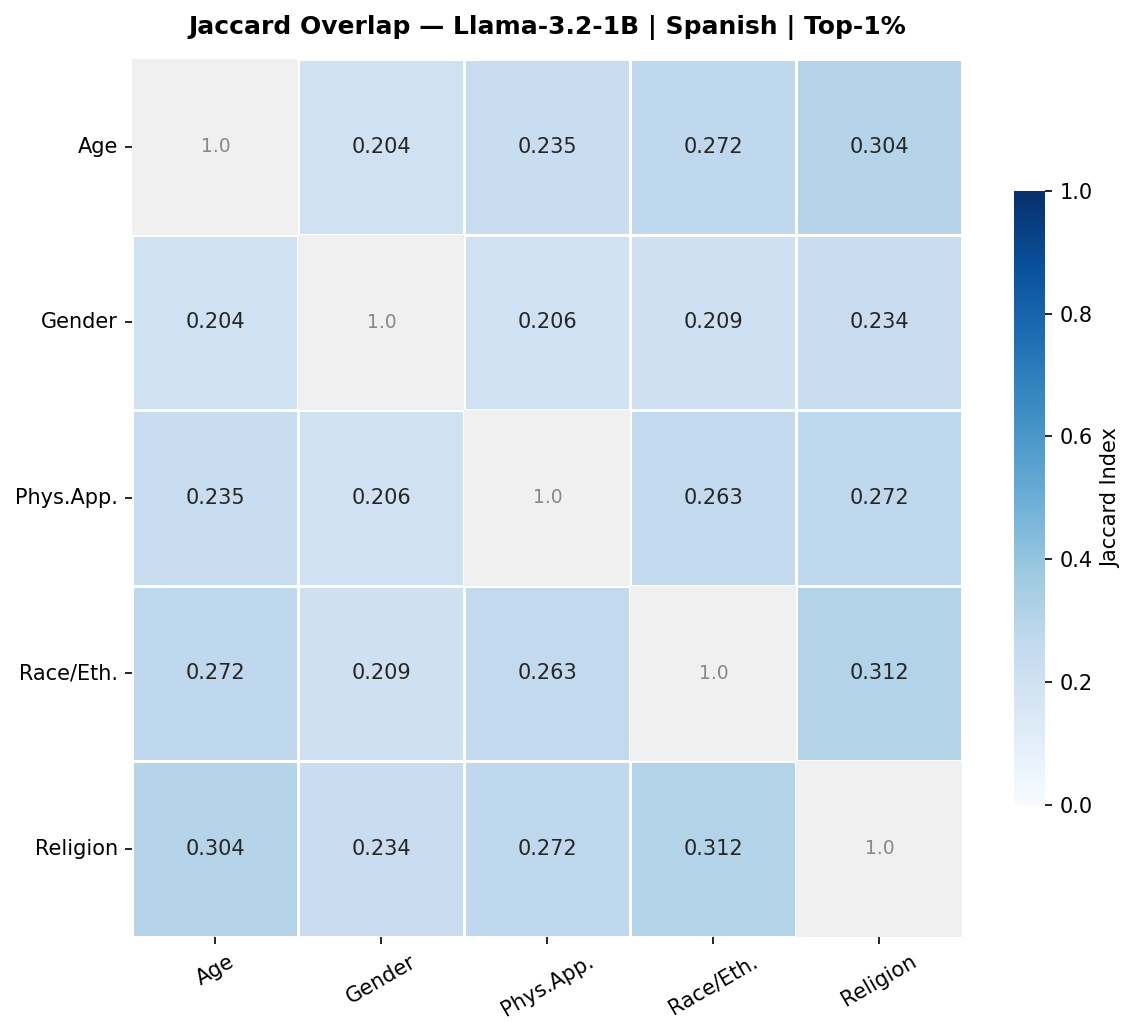

Saved: jaccard_llama-3.2-1B_es_top5


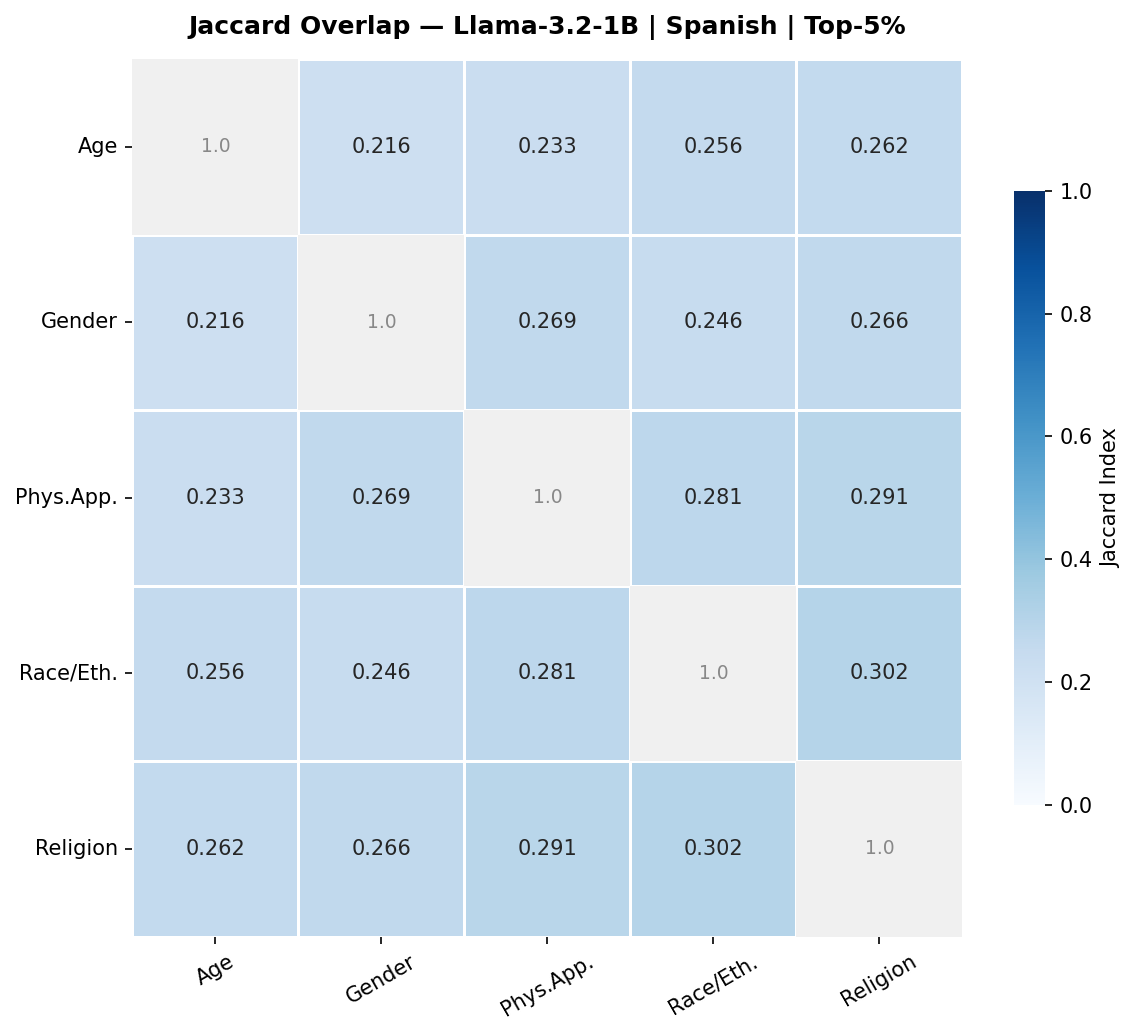

Saved: jaccard_llama-3.2-3B_en_Out01


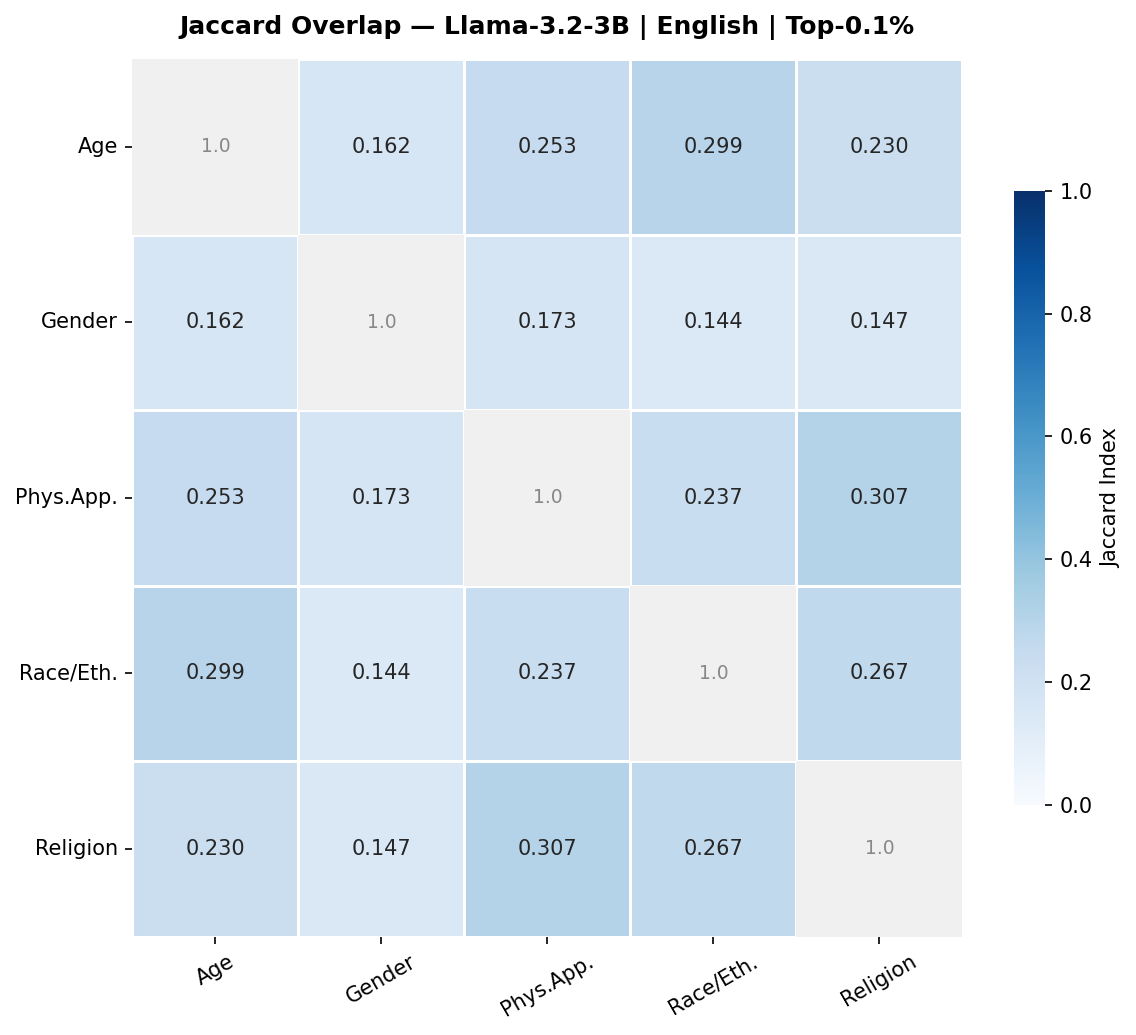

Saved: jaccard_llama-3.2-3B_en_top1


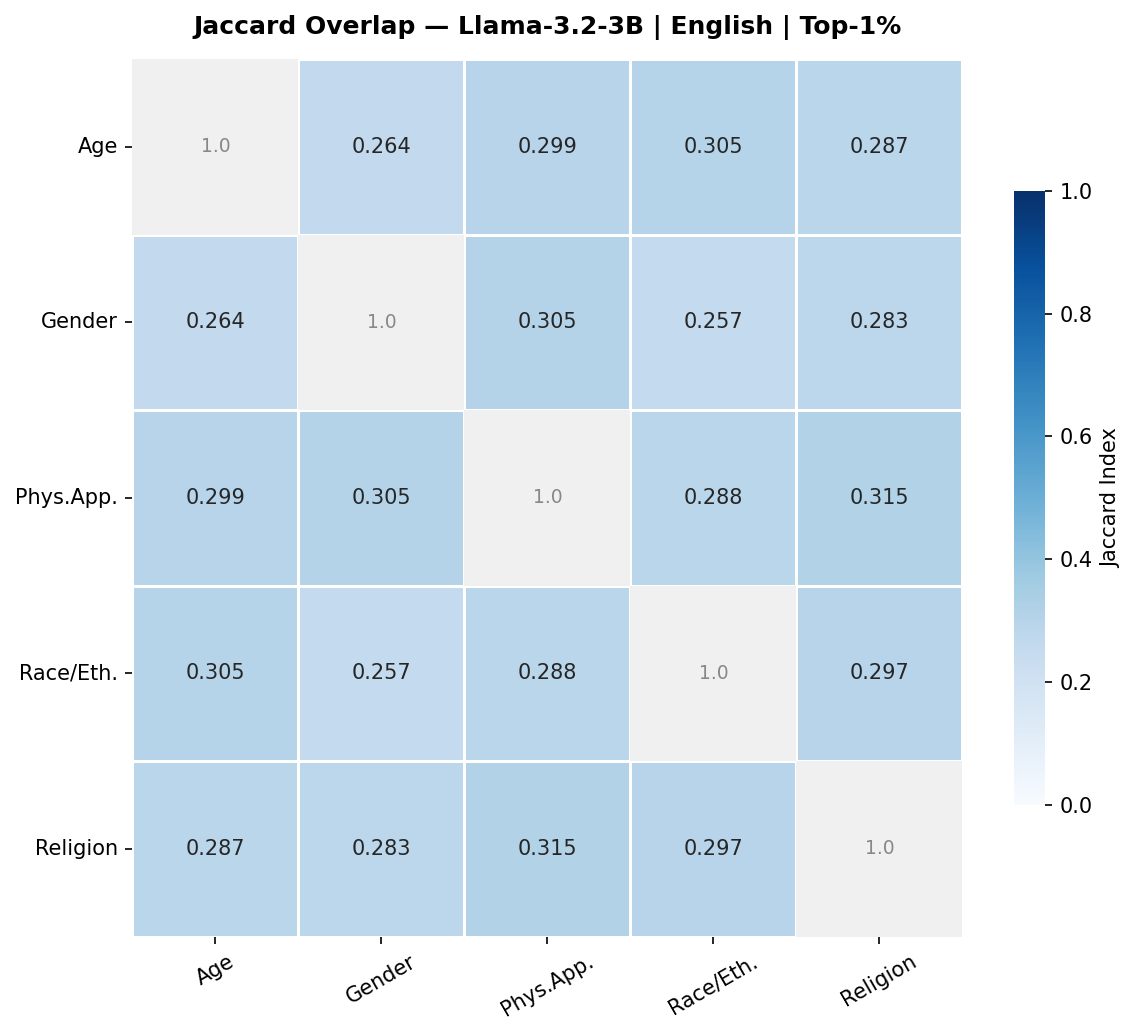

Saved: jaccard_llama-3.2-3B_en_top5


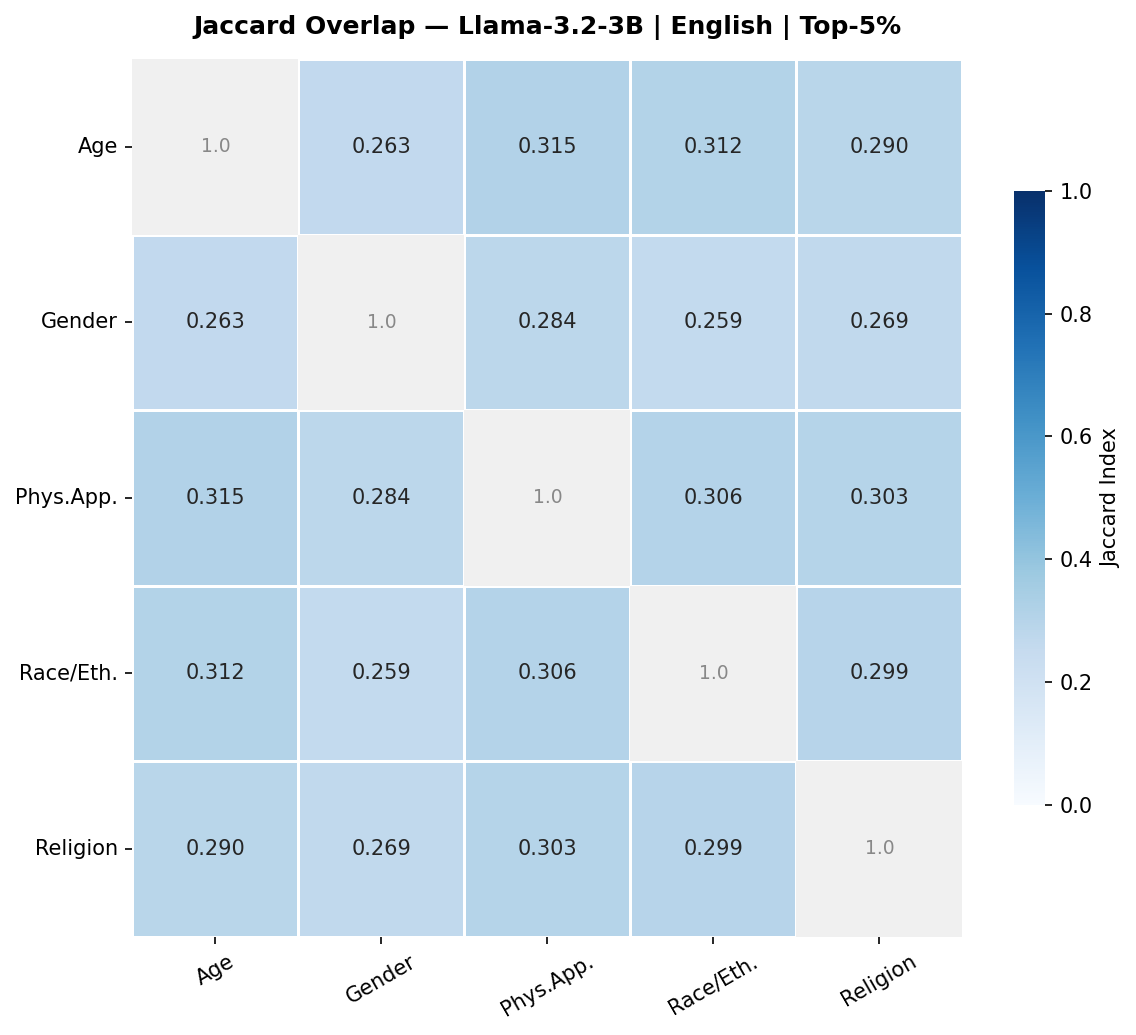

Saved: jaccard_llama-3.2-3B_es_Out01


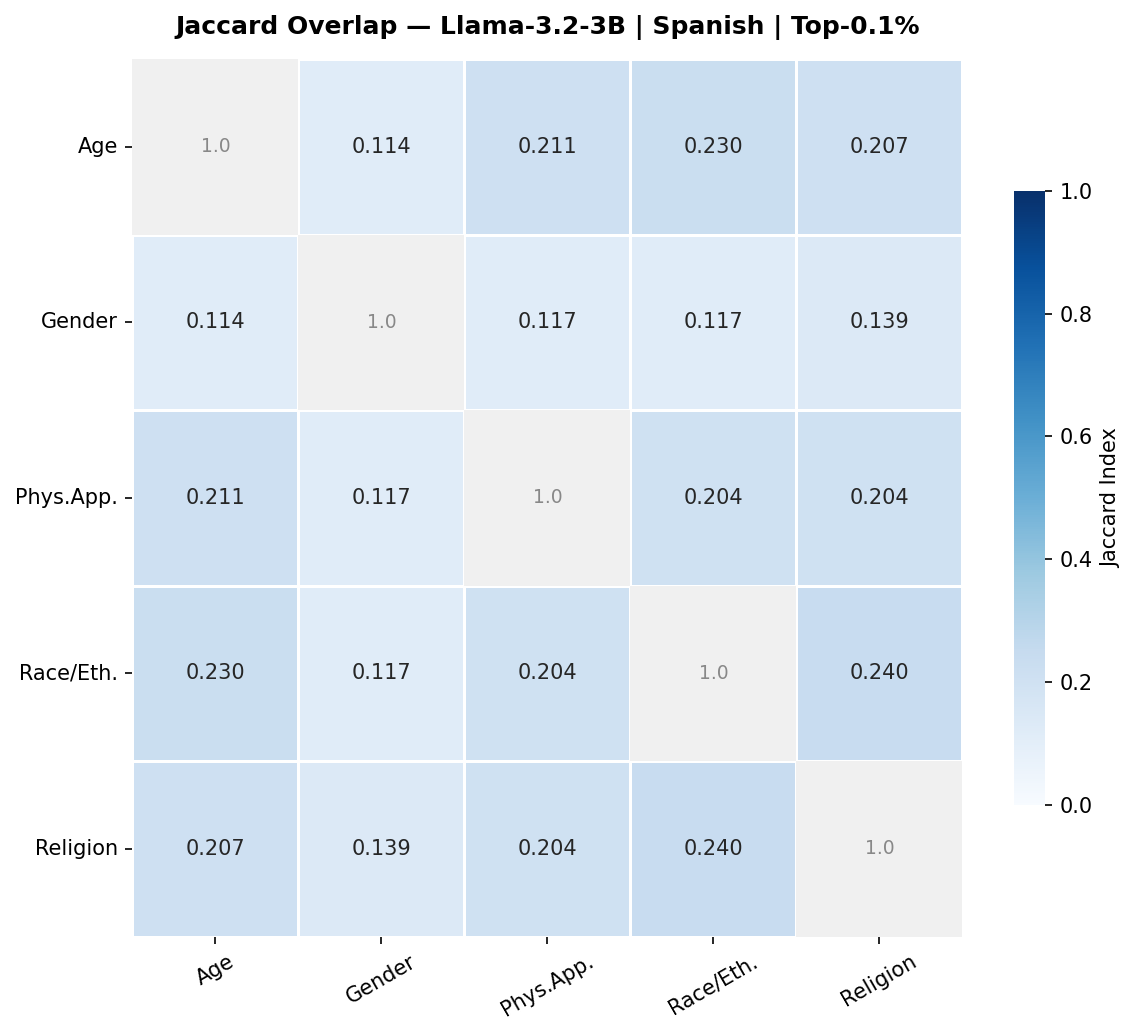

Saved: jaccard_llama-3.2-3B_es_top1


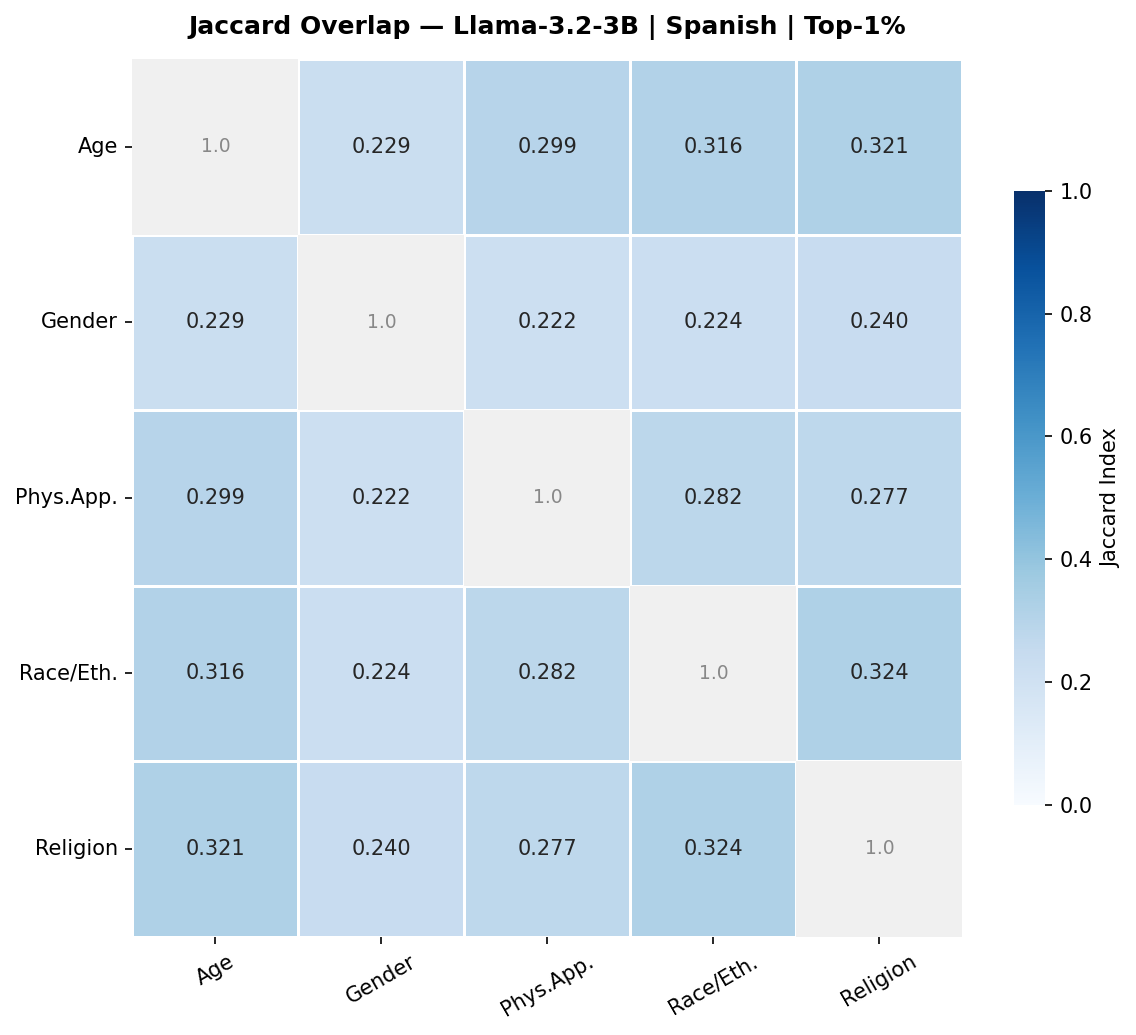

Saved: jaccard_llama-3.2-3B_es_top5


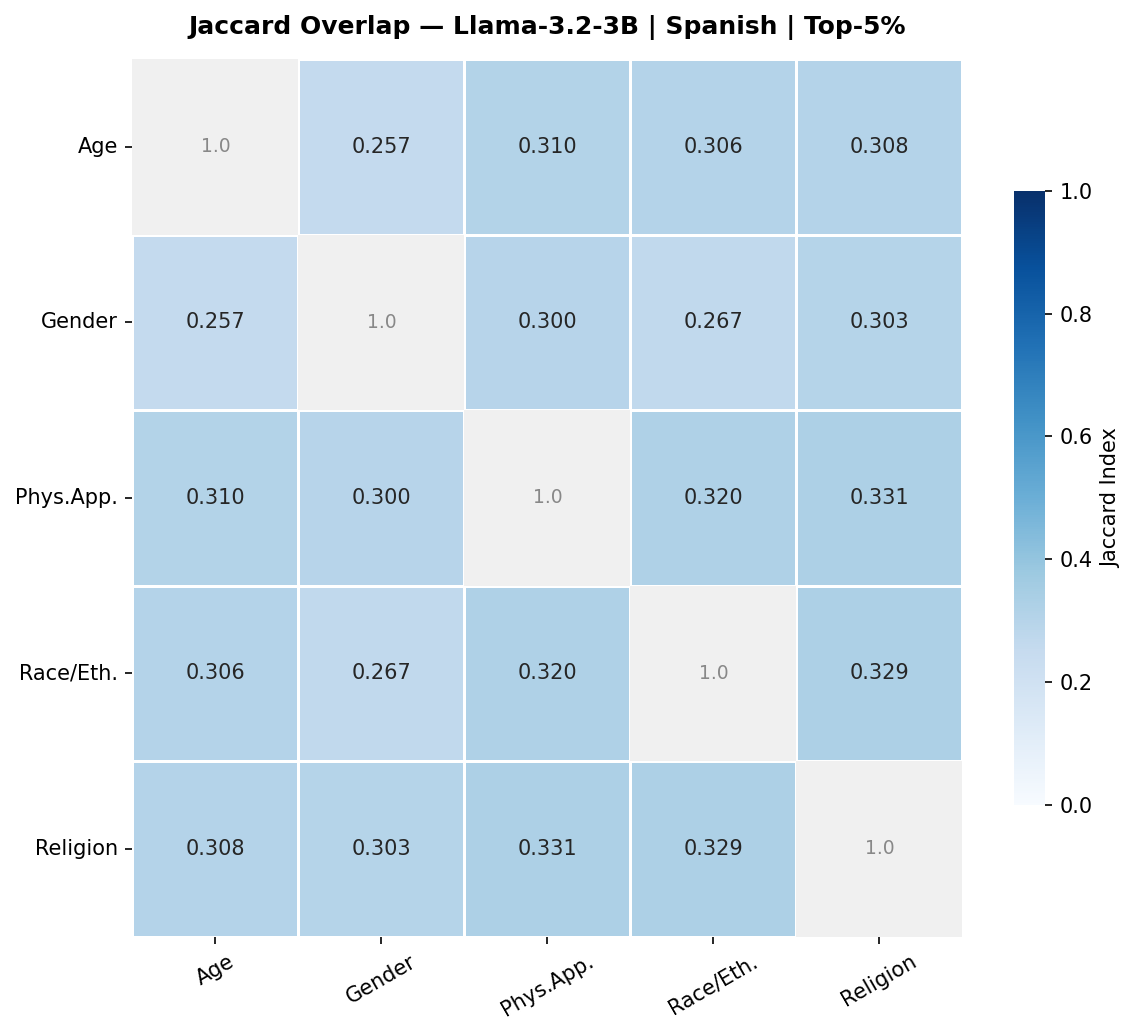

Saved: jaccard_salamandra-2B_en_Out01


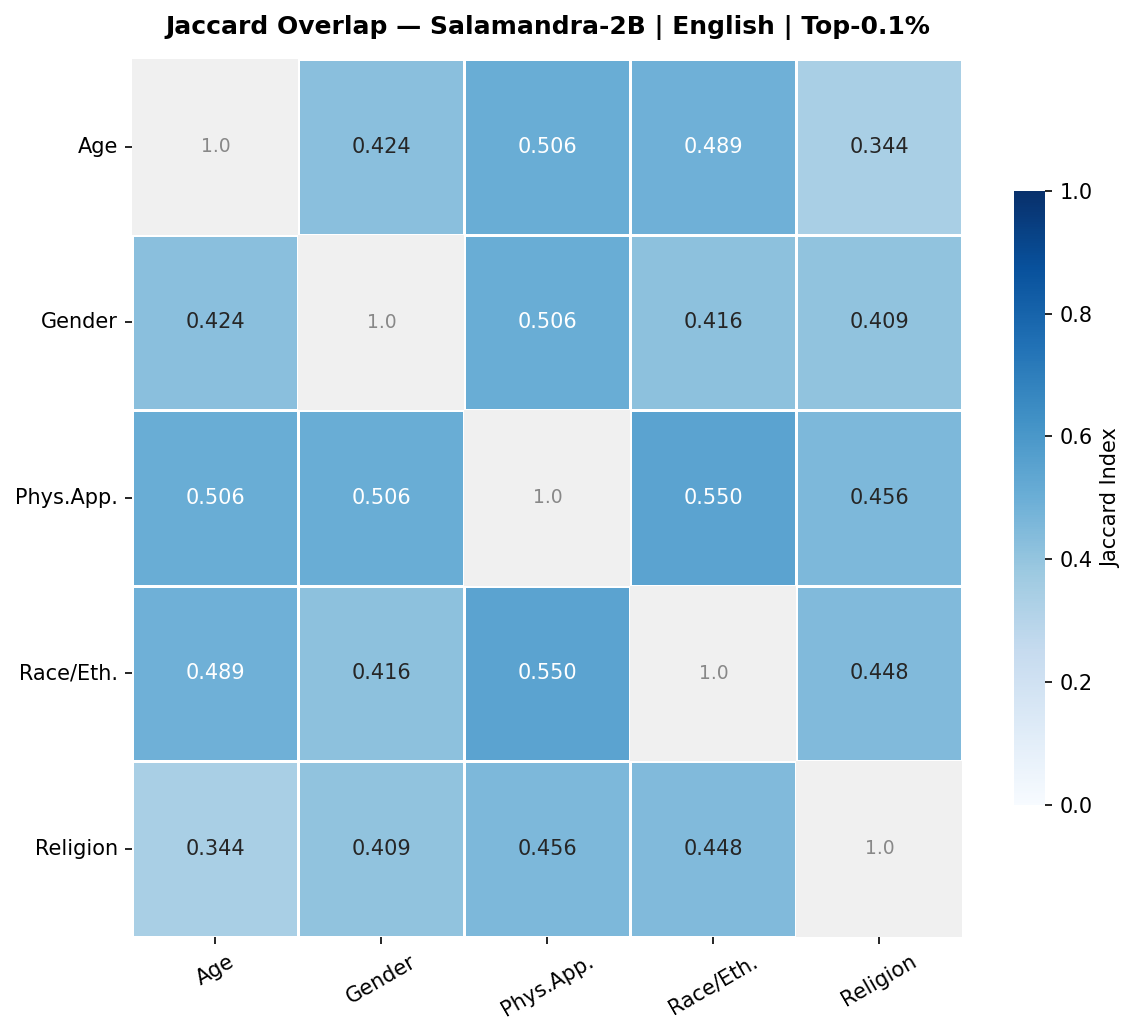

Saved: jaccard_salamandra-2B_en_top1


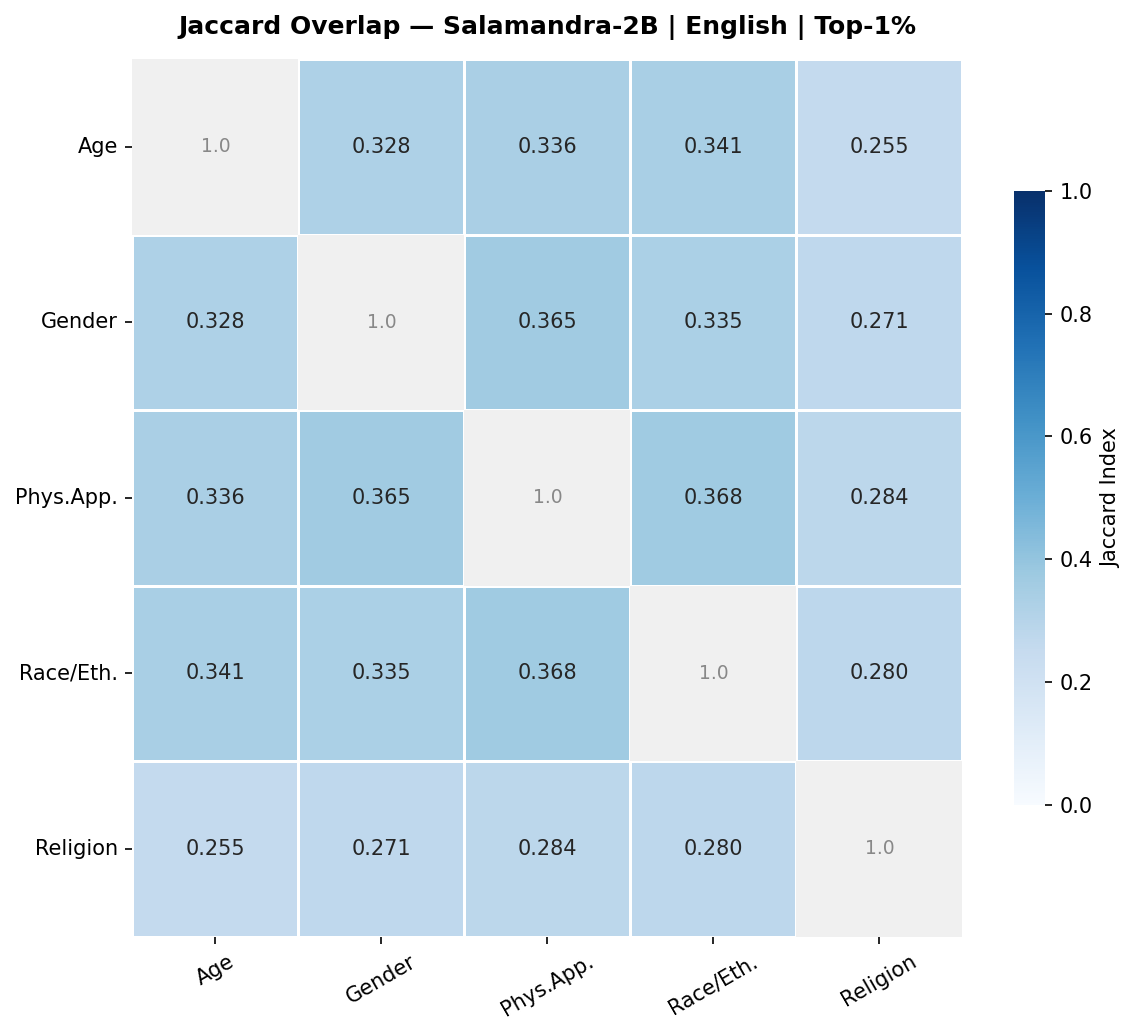

Saved: jaccard_salamandra-2B_en_top5


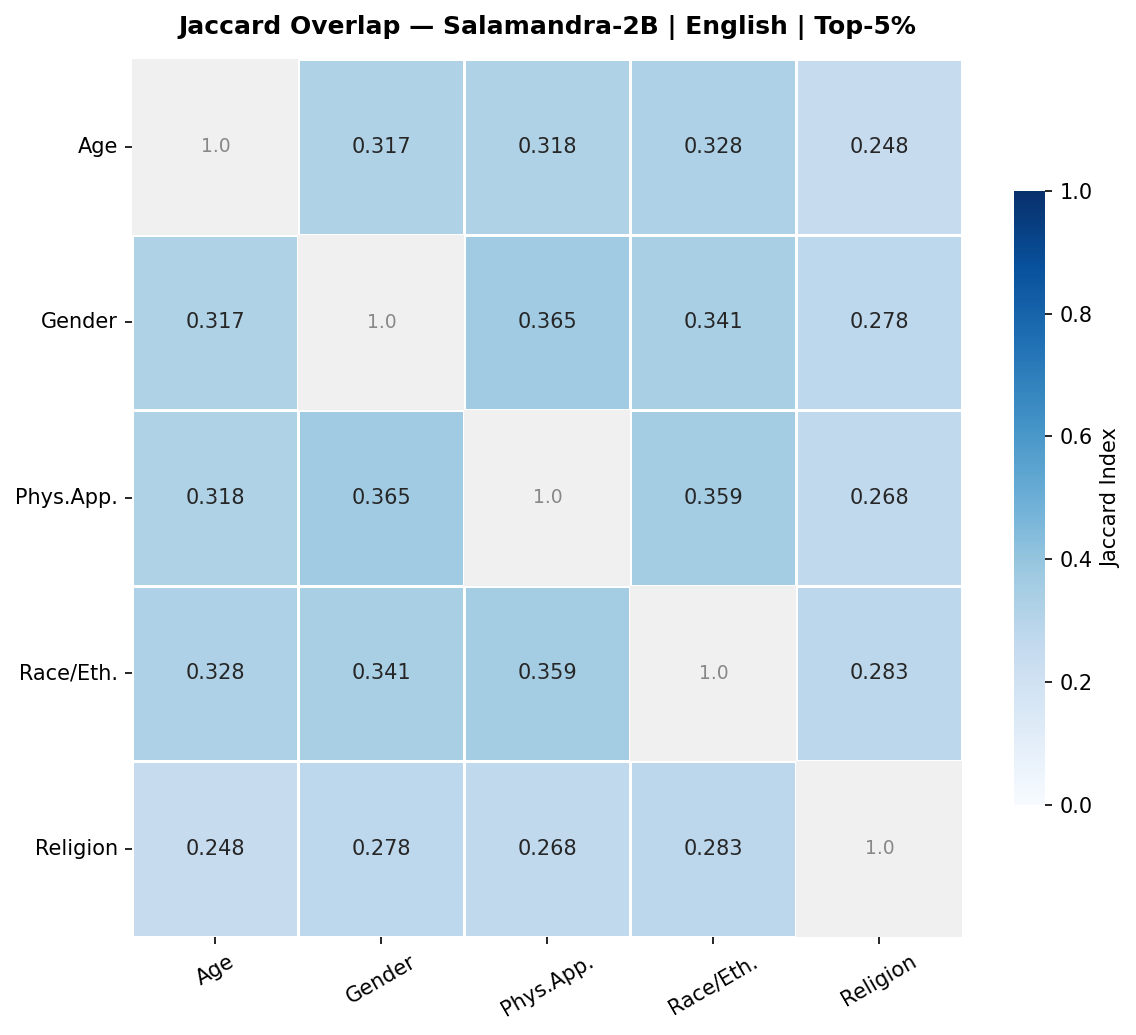

Saved: jaccard_salamandra-2B_es_Out01


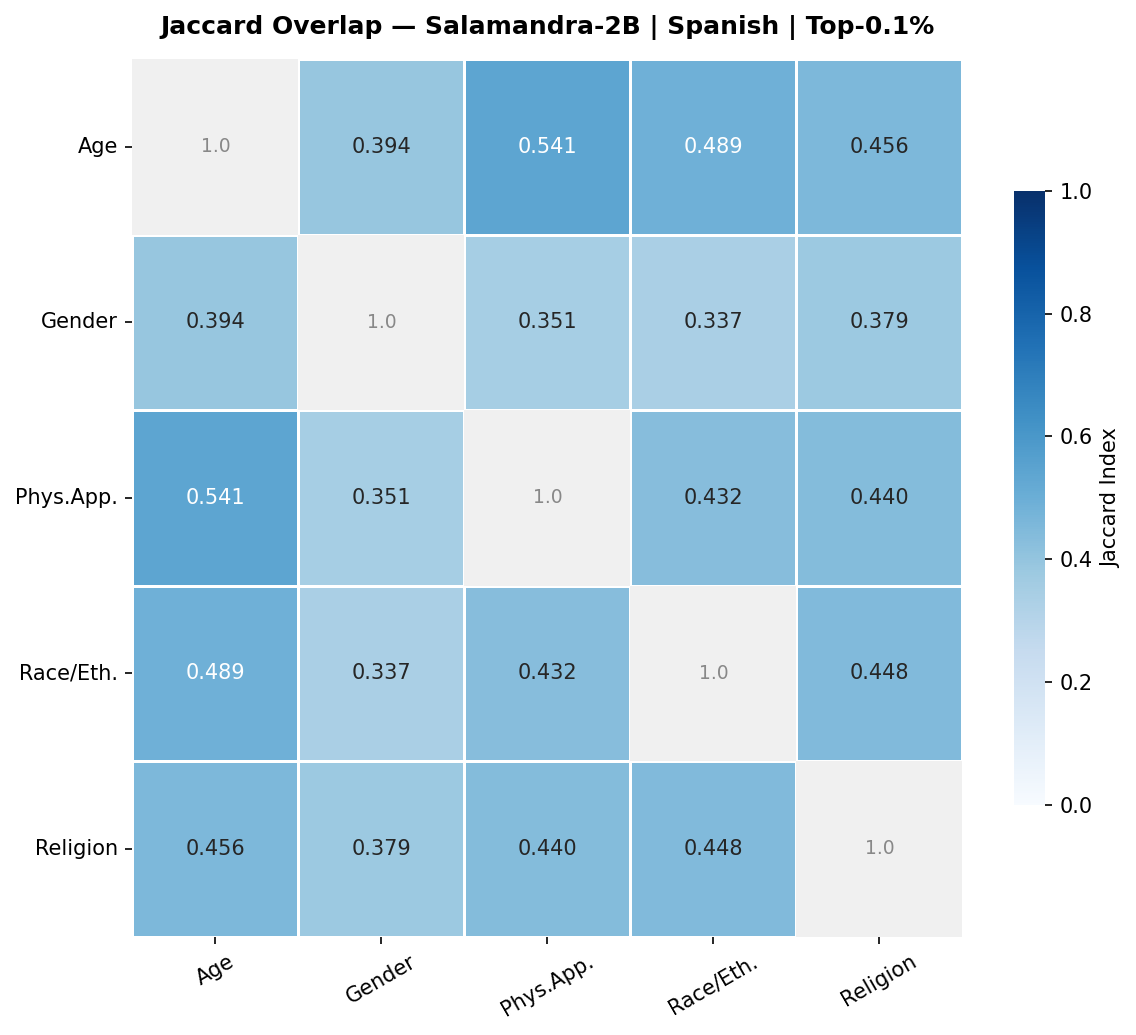

Saved: jaccard_salamandra-2B_es_top1


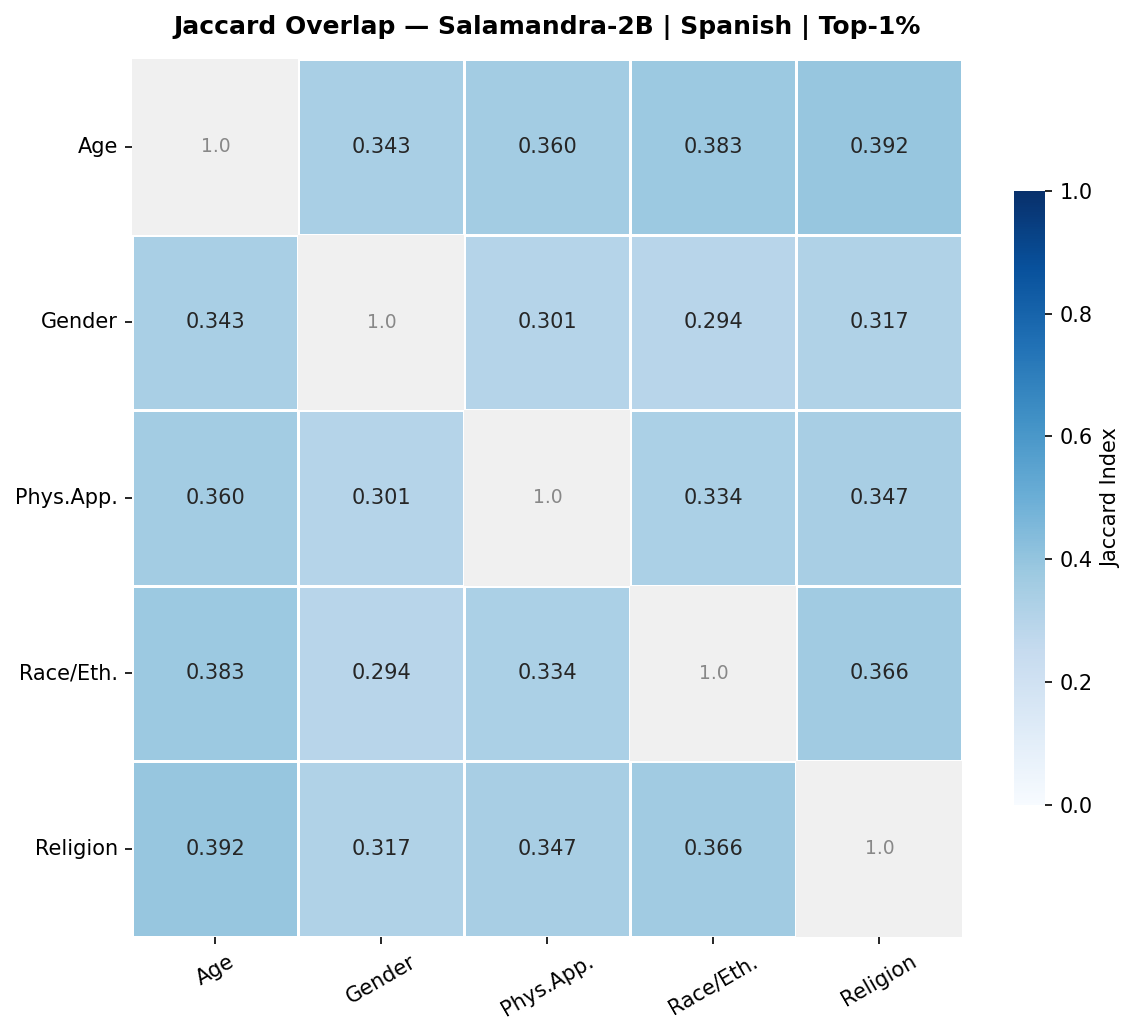

Saved: jaccard_salamandra-2B_es_top5


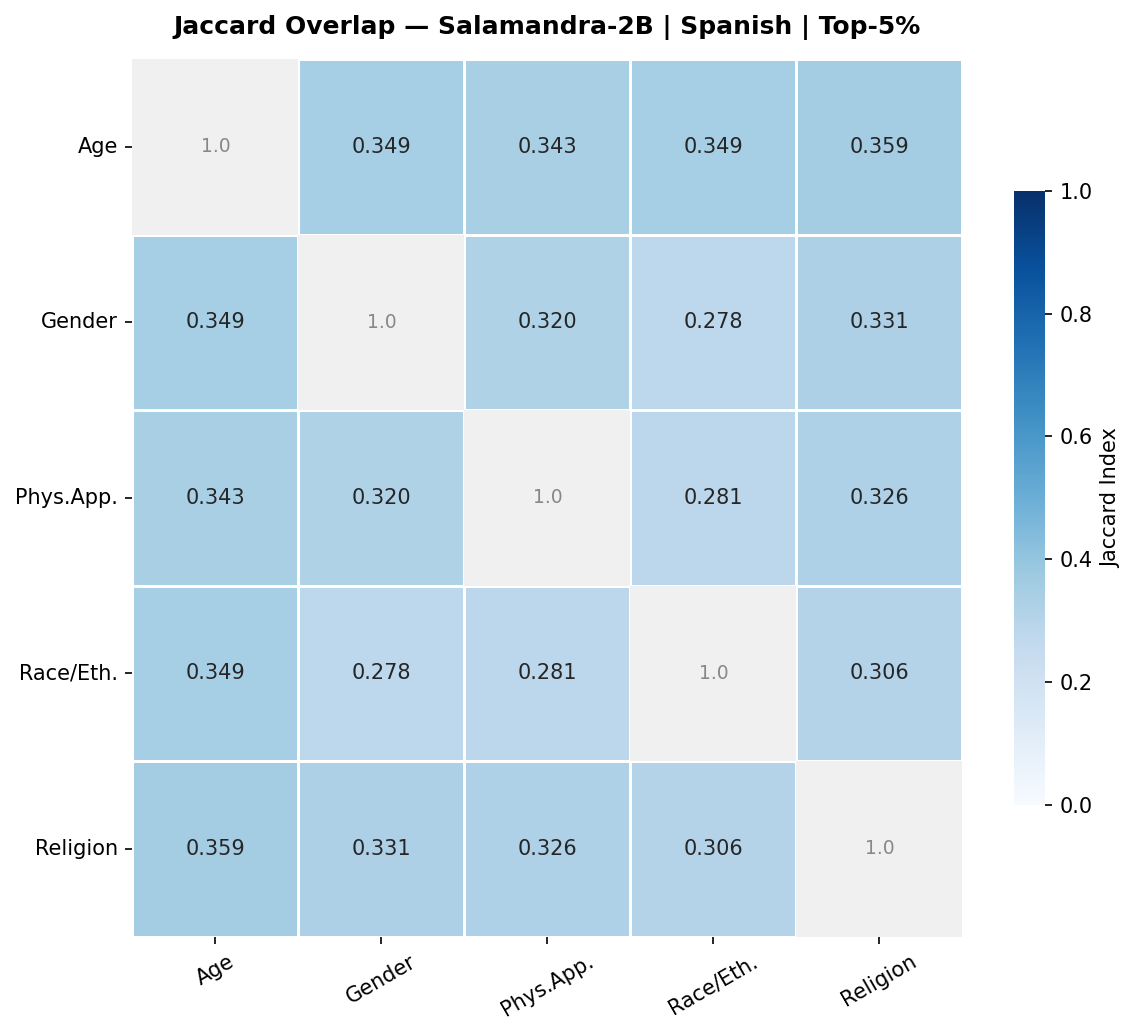

In [ ]:
# --- Compute and plot Jaccard matrices ---
jaccard_results = {}  # {model_key: {lang: {threshold_name: matrix}}
threshold_labels = {"Out01": "0.1", "top1": "1", "top5": "5"}
for model_key in MODELS:
    jaccard_results[model_key] = {}
    for lang in ["en", "es"]:
        jaccard_results[model_key][lang] = {}
        categories = CATEGORIES_BY_LANG[lang]
        lang_label = "English" if lang == "en" else "Spanish"
        model_label = MODELS[model_key]["label"]

        for threshold_name in TOP_K_THRESHOLDS:
            top_k_dict = top_k_neurons[model_key][lang][threshold_name]
            matrix = build_jaccard_matrix(top_k_dict, categories)
            jaccard_results[model_key][lang][threshold_name] = matrix

            title = (
                f"Jaccard Overlap — {model_label} | {lang_label} | "
                f"Top-{threshold_labels[threshold_name]}%"
            )
            save_stem = f"jaccard_{model_key}_{lang}_{threshold_name}"
            plot_jaccard_matrix(matrix, categories, title, save_stem)

In [ ]:
# Print Jaccard values as text table
print(f"{'Model':<20} {'Lang':<5} {'Threshold':<10} {'Cat A':<20} {'Cat B':<20} {'Jaccard':>8}")
print("-" * 90)
for model_key in MODELS:
    for lang in ["en", "es"]:
        categories = CATEGORIES_BY_LANG[lang]
        model_label = MODELS[model_key]["label"]
        for threshold_name in TOP_K_THRESHOLDS:
            top_k_dict = top_k_neurons[model_key][lang][threshold_name]
            for i, cat_a in enumerate(categories):
                for cat_b in categories[i+1:]:
                    j = jaccard_index(top_k_dict.get(cat_a, set()), top_k_dict.get(cat_b, set()))
                    print(f"{model_label:<20} {lang:<5} {threshold_name:<10} {cat_a:<20} {cat_b:<20} {j:>8.4f}")

Model                Lang  Threshold  Cat A                Cat B                 Jaccard
------------------------------------------------------------------------------------------
Llama-3.2-1B         en    Out01      Age                  Gender                 0.1630
Llama-3.2-1B         en    Out01      Age                  PhysicalAppearance     0.2394
Llama-3.2-1B         en    Out01      Age                  RaceEthnicity          0.2816
Llama-3.2-1B         en    Out01      Age                  Religion               0.2222
Llama-3.2-1B         en    Out01      Gender               PhysicalAppearance     0.2110
Llama-3.2-1B         en    Out01      Gender               RaceEthnicity          0.1630
Llama-3.2-1B         en    Out01      Gender               Religion               0.1946
Llama-3.2-1B         en    Out01      PhysicalAppearance   RaceEthnicity          0.2692
Llama-3.2-1B         en    Out01      PhysicalAppearance   Religion               0.3200
Llama-3.2-1B       

In [ ]:
# Detail of Top-0.1% neurons by layer for Salamandra-2B EN, all categories
model_key = "salamandra-2B"
lang = "en"
threshold_name = "Out01"

print(f"Top-0.1% neuron distribution by layer — {model_key} | {lang}\n")
for category in CATEGORIES_BY_LANG[lang]:
    neurons = top_k_neurons[model_key][lang][threshold_name][category]
    # Count neurons per layer
    layer_counts = {}
    for (layer_idx, neuron_idx, proj) in neurons:
        layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1
    sorted_layers = sorted(layer_counts.items(), key=lambda x: x[1], reverse=True)
    print(f"{category:25s} total={len(neurons):4d} | by layer: {sorted_layers}")

Top-0.1% neuron distribution by layer — salamandra-2B | en

Age                       total= 131 | by layer: [(23, 125), (22, 4), (15, 1), (18, 1)]
Gender                    total= 131 | by layer: [(23, 111), (20, 7), (21, 4), (22, 3), (12, 1), (13, 1), (9, 1), (18, 1), (1, 1), (17, 1)]
PhysicalAppearance        total= 131 | by layer: [(23, 128), (22, 2), (19, 1)]
RaceEthnicity             total= 131 | by layer: [(23, 125), (22, 2), (21, 2), (15, 1), (20, 1)]
Religion                  total= 131 | by layer: [(23, 114), (22, 6), (21, 3), (19, 2), (20, 2), (11, 1), (17, 1), (1, 1), (18, 1)]


In [ ]:
# Detail of Top-0.1% neurons by layer for Salamandra-2B EN, all categories
model_key = "llama-3.2-1B"
lang = "en"
threshold_name = "Out01"

print(f"Top-0.1% neuron distribution by layer — {model_key} | {lang}\n")
for category in CATEGORIES_BY_LANG[lang]:
    neurons = top_k_neurons[model_key][lang][threshold_name][category]
    # Count neurons per layer
    layer_counts = {}
    for (layer_idx, neuron_idx, proj) in neurons:
        layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1
    sorted_layers = sorted(layer_counts.items(), key=lambda x: x[1], reverse=True)
    print(f"{category:25s} total={len(neurons):4d} | by layer: {sorted_layers}")

Top-0.1% neuron distribution by layer — llama-3.2-1B | en

Age                       total= 132 | by layer: [(15, 92), (14, 9), (10, 6), (13, 5), (12, 5), (11, 5), (9, 3), (2, 2), (8, 2), (4, 2), (5, 1)]
Gender                    total= 132 | by layer: [(15, 68), (14, 11), (10, 9), (12, 9), (11, 8), (13, 7), (5, 5), (6, 4), (8, 3), (9, 3), (4, 2), (3, 2), (2, 1)]
PhysicalAppearance        total= 132 | by layer: [(15, 101), (13, 10), (10, 6), (14, 4), (12, 4), (8, 2), (5, 2), (4, 1), (11, 1), (9, 1)]
RaceEthnicity             total= 132 | by layer: [(15, 94), (11, 6), (9, 6), (14, 6), (12, 5), (10, 5), (13, 4), (5, 3), (4, 2), (8, 1)]
Religion                  total= 132 | by layer: [(15, 106), (14, 10), (12, 4), (10, 4), (13, 3), (5, 2), (11, 1), (4, 1), (7, 1)]


In [ ]:
# Detail of Top-0.1% neurons by layer for Salamandra-2B EN, all categories
model_key = "salamandra-2B"
lang = "es"
threshold_name = "Out01"

print(f"Top-0.1% neuron distribution by layer — {model_key} | {lang}\n")
for category in CATEGORIES_BY_LANG[lang]:
    neurons = top_k_neurons[model_key][lang][threshold_name][category]
    # Count neurons per layer
    layer_counts = {}
    for (layer_idx, neuron_idx, proj) in neurons:
        layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1
    sorted_layers = sorted(layer_counts.items(), key=lambda x: x[1], reverse=True)
    print(f"{category:25s} total={len(neurons):4d} | by layer: {sorted_layers}")

**Utility**

The Jaccard overlap matrices quantify the degree to which different bias categories share the same candidate neurons at each threshold level, computed exclusively over down_proj_input neurons — the post-GLU signal that enters the residual stream. For every pair of categories, the Jaccard Index measures the size of the intersection of their Top-K neuron sets divided by the size of their union. Three thresholds are computed: Top-0.1% to focus on the most extreme neurons, Top-1% as the standard reference, and Top-5% to verify robustness. These matrices provide the quantitative evidence for RQ2: whether different types of demographic bias share structural overlap in the MLP circuits of the model.

---

**Interpretation**

The three Jaccard thresholds tell a consistent story for the Llama family and a more complex one for Salamandra-2B.

In the Llama models, pairwise overlap between bias categories stays in the 0.10–0.33 range across all thresholds, with median values around 0.16–0.30. No pair reaches 0.33 except at Top-5% in Llama-3B Spanish (PhysicalAppearance+Religion = 0.331), which is a marginal exception rather than a systemic one. The interpretation is direct: bias circuits are largely category-specific in the Llama family, with roughly two-thirds to four-fifths of the candidate neurons being unique to each category at any given threshold. This holds across model size and language.

Gender stands out as the most categorically distinct of the five attributes. In every Llama condition (six combinations of model × language × threshold among the most conservative thresholds), the pairs involving Gender have a mean Jaccard that is between 0.05 and 0.11 lower than the mean of the non-Gender pairs. The single lowest pair in five of the twelve Llama matrices involves Gender, most often Gender+RaceEthnicity or Gender+Age. The post-GLU Gender circuit overlaps less with other circuits than any other pair, which is consistent with the sparse, outlier-driven encoding documented in Sprints 2.1 and 2.3.

Salamandra-2B presents a qualitatively different picture that requires careful interpretation. At Top-0.1%, all pairwise Jaccard values cluster in the 0.34–0.55 range — far above the corresponding Llama numbers. This is the methodological artifact already flagged in earlier sprints: between 85% and 98% of the Top-0.1% candidates for every category fall in L23 alone, and with such extreme single-layer concentration two sets of ~131 neurons drawn mostly from the same pool of 5,440 neurons in L23 will overlap heavily regardless of any shared functional structure. The Top-0.1% Jaccard values for Salamandra should therefore not be read as evidence of shared bias circuits.

The genuinely informative finding is that even at Top-1% and Top-5%, where the L23 concentration no longer dominates and candidates span multiple layers, Salamandra still shows higher overlap than either Llama model: median Jaccard around 0.33 at Top-1% and 0.32 at Top-5%, compared to 0.25–0.31 for the Llama family at the same thresholds. The architectural difference is real, just smaller than the Top-0.1% figures suggest. Salamandra's bias circuits are not as cleanly separable as those of the Llama models.

The Gender distinction also weakens in Salamandra. In English at Top-1% and Top-5%, Salamandra's Gender pairs actually have a slightly higher mean than its non-Gender pairs (0.325 vs 0.311 at Top-1%, 0.325 vs 0.300 at Top-5%) — a complete inversion of the Llama pattern. In Spanish, Gender pairs are again the lowest at the most conservative threshold, restoring the Llama-like behaviour. This suggests Salamandra's Gender circuits in English are more entangled with other categories than in Llama, while its Spanish encoding follows the more familiar pattern. Given Salamandra's stronger Spanish training profile, this is plausible — Gender in its weaker language may not have settled into a dedicated circuit.

One cross-language regularity is worth flagging. The category pair with the highest Jaccard differs systematically between English and Spanish in the Llama models. In English the top pair is consistently PhysicalAppearance+Religion across both model sizes and most thresholds; in Spanish it shifts to RaceEthnicity+Religion. The asymmetry holds at all three thresholds for Llama-1B and at two of three for Llama-3B. The implication is that the strongest cross-category coupling involves Religion in both languages, but its partner changes — paired with PhysicalAppearance in English and with RaceEthnicity in Spanish. This is the kind of cross-lingual finding that the paper should mention as it points to language-specific circuit organization beyond simple per-category bias intensity.

### 3.2 N-way intersection across all categories

In [19]:
def n_way_intersection(top_k_dict, categories):
    """
    Return the set of neurons that appear in ALL categories simultaneously.
    """
    sets = [top_k_dict.get(cat, set()) for cat in categories]
    if not sets:
        return set()
    result = sets[0]
    for s in sets[1:]:
        result = result & s
    return result


print("N-way intersection (neurons shared by ALL categories)\n")
print(f"{'Model':<20} {'Lang':<5} {'Threshold':<10} {'N shared neurons':<18} {'Details'}")
print("-" * 85)

for model_key in MODELS:
    for lang in ["en", "es"]:
        categories = CATEGORIES_BY_LANG[lang]
        for threshold_name in TOP_K_THRESHOLDS:
            top_k_dict = top_k_neurons[model_key][lang][threshold_name]
            shared = n_way_intersection(top_k_dict, categories)
            details = str(sorted(shared)[:5]) + (" ..." if len(shared) > 5 else "")
            print(
                f"{model_key:<20} {lang:<5} {threshold_name:<10} "
                f"{len(shared):<18} {details}"
            )

N-way intersection (neurons shared by ALL categories)

Model                Lang  Threshold  N shared neurons   Details
-------------------------------------------------------------------------------------
llama-3.2-1B         en    Out01      21                 [(13, 6427, 'down_proj_input'), (14, 7351, 'down_proj_input'), (15, 100, 'down_proj_input'), (15, 655, 'down_proj_input'), (15, 840, 'down_proj_input')] ...
llama-3.2-1B         en    top1       328                [(4, 2189, 'down_proj_input'), (5, 2771, 'down_proj_input'), (5, 3466, 'down_proj_input'), (5, 5065, 'down_proj_input'), (6, 5337, 'down_proj_input')] ...
llama-3.2-1B         en    top5       1509               [(3, 2094, 'down_proj_input'), (3, 4552, 'down_proj_input'), (3, 6677, 'down_proj_input'), (4, 2189, 'down_proj_input'), (4, 3232, 'down_proj_input')] ...
llama-3.2-1B         es    Out01      13                 [(13, 4665, 'down_proj_input'), (13, 7999, 'down_proj_input'), (14, 7050, 'down_proj_input'), (14, 

In [20]:
# Verify layer distribution of the N-way intersection neurons (Top-0.1%)
print("N-way intersection at Top-0.1% — layer distribution of shared neurons")
print("=" * 80)
for model_key in MODELS:
    for lang in ["en", "es"]:
        categories = CATEGORIES_BY_LANG[lang]
        top_k_dict = top_k_neurons[model_key][lang]["Out01"]
        shared = n_way_intersection(top_k_dict, categories)

        # Count neurons by layer
        layer_counts = {}
        for (layer_idx, neuron_idx, proj) in shared:
            layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1

        sorted_layers = sorted(layer_counts.items(), key=lambda x: x[1], reverse=True)
        n_distinct_layers = len(sorted_layers)
        last_layer = MODELS[model_key]["n_layers"] - 1
        n_in_last = layer_counts.get(last_layer, 0)
        pct_in_last = n_in_last / len(shared) if shared else 0

        print(f"\n{model_key:18s} | {lang} | total shared={len(shared):3d} | "
              f"distinct layers={n_distinct_layers:2d} | in L{last_layer}={n_in_last} "
              f"({pct_in_last:.1%})")
        print(f"   layer distribution: {sorted_layers[:6]}")

# Same for Top-1% (where the L23 artifact for Salamandra no longer dominates)
print("\n" + "=" * 80)
print("N-way intersection at Top-1% — layer distribution of shared neurons")
print("=" * 80)
for model_key in MODELS:
    for lang in ["en", "es"]:
        categories = CATEGORIES_BY_LANG[lang]
        top_k_dict = top_k_neurons[model_key][lang]["top1"]
        shared = n_way_intersection(top_k_dict, categories)

        layer_counts = {}
        for (layer_idx, neuron_idx, proj) in shared:
            layer_counts[layer_idx] = layer_counts.get(layer_idx, 0) + 1

        sorted_layers = sorted(layer_counts.items(), key=lambda x: x[1], reverse=True)
        n_distinct_layers = len(sorted_layers)
        last_layer = MODELS[model_key]["n_layers"] - 1
        n_in_last = layer_counts.get(last_layer, 0)
        pct_in_last = n_in_last / len(shared) if shared else 0

        # Compute fraction in top 25% of the model
        threshold_layer = int(MODELS[model_key]["n_layers"] * 0.75)
        n_in_deep = sum(c for li, c in sorted_layers if li >= threshold_layer)
        pct_in_deep = n_in_deep / len(shared) if shared else 0

        print(f"\n{model_key:18s} | {lang} | total shared={len(shared):4d} | "
              f"distinct layers={n_distinct_layers:2d} | "
              f"in L{last_layer}={n_in_last} ({pct_in_last:.1%}) | "
              f"in deep 25%={n_in_deep} ({pct_in_deep:.1%})")
        print(f"   top 5 layers: {sorted_layers[:5]}")

N-way intersection at Top-0.1% — layer distribution of shared neurons

llama-3.2-1B       | en | total shared= 21 | distinct layers= 3 | in L15=19 (90.5%)
   layer distribution: [(15, 19), (13, 1), (14, 1)]

llama-3.2-1B       | es | total shared= 13 | distinct layers= 3 | in L15=9 (69.2%)
   layer distribution: [(15, 9), (14, 2), (13, 2)]

llama-3.2-3B       | en | total shared= 36 | distinct layers= 3 | in L27=33 (91.7%)
   layer distribution: [(27, 33), (26, 2), (22, 1)]

llama-3.2-3B       | es | total shared= 26 | distinct layers= 4 | in L27=19 (73.1%)
   layer distribution: [(27, 19), (26, 3), (25, 2), (24, 2)]

salamandra-2B      | en | total shared= 42 | distinct layers= 1 | in L23=42 (100.0%)
   layer distribution: [(23, 42)]

salamandra-2B      | es | total shared= 36 | distinct layers= 1 | in L23=36 (100.0%)
   layer distribution: [(23, 36)]

N-way intersection at Top-1% — layer distribution of shared neurons

llama-3.2-1B       | en | total shared= 328 | distinct layers=12 

**Utility**

The N-way intersection identifies neurons that appear in the Top-K candidate set of every bias category simultaneously — neurons that are highly responsive to demographic attributes regardless of the specific category. These represent candidates for a category-agnostic intervention: neurons that could be targeted once to reduce bias signal across all categories simultaneously.

The N-way intersection identifies neurons that appear in the Top-K candidate set of every bias category simultaneously — neurons that are highly responsive to demographic attributes regardless of the specific category. These represent candidates for a category-agnostic intervention, with the important caveat that any such intervention is effectively a single-layer intervention given the layer distribution documented below.

---

**Interpretation**

Two patterns emerge from the layer distribution of the shared sets, and both qualify the simpler reading of "category-agnostic bias neurons" that the raw counts might suggest.

The first is that the shared sets are not just small but also extremely concentrated in the final layer of the model. At Top-0.1%, Salamandra-2B places 100% of its shared neurons in L23 across both languages — the geometric inevitability already documented for the pairwise Jaccard becomes total in the N-way intersection. The Llama models follow the same pattern more moderately: 90.5% of Llama-1B EN's shared neurons sit in L15 (19 of 21), and 91.7% of Llama-3B EN's are in L27 (33 of 36). Even at Top-1%, where candidates span multiple layers, the final layer alone holds 70–87% of the shared neurons in five of the six conditions. Across all conditions and all thresholds, between 95% and 99% of the shared sets fall in the final 25% of the model's depth. The "universal bias circuit" is therefore not a distributed multi-layer substrate but a single-layer phenomenon, with adjacent deep layers contributing a thin shell of additional neurons.

The second pattern is the exception that defines the rule. Llama-3B Spanish at Top-1% places only 50.4% of its shared neurons in L27 — the lowest concentration figure in the entire table by a wide margin. The remaining 49.6% is spread across L26 (97), L25 (90), L24 (22) and L23 (12). This is the same model that showed the dominance of Age and the more distributed depth profile in Sprints 2.1 and 2.2, and the same pattern reappears here at a different level of analysis. Whatever produces the unusual Llama-3B Spanish profile operates not only on per-category bias intensity but also on the cross-category overlap structure: the model encodes its universal demographic sensitivity across roughly four layers in Spanish where it concentrates it in essentially one layer in English.

A practical consequence follows for the pruning strategy. A category-agnostic intervention targeting only the N-way shared neurons would be effectively a single-layer operation in five of the six (model × language) configurations — modifying L23, L15 or L27 alone would cover most of the universal bias signal. In Llama-3B Spanish the same intervention would need to span four layers (L24–L27) to reach equivalent coverage. The decision of whether to prune by N-way shared neurons or by per-category top-K therefore has different operational implications depending on the model, and this should be reflected in the design of the experiments in Section 3.4.

One observation on size scaling is also worth noting. The shared sets at Top-1% scale roughly with model size in Llama: 239–328 neurons for the 1B model, 472–489 for the 3B. Salamandra at 2B parameters falls between the two (356–404), which is consistent with what would be expected from a model of intermediate size. There is no anomaly here: the existence of a "universal" set of bias-sensitive neurons grows in absolute count with model capacity, even if its layer concentration profile differs across architectures.

### 3.3 Cross-lingual consistency (EN vs ES)

In [21]:
def cross_lingual_overlap(top_k_en, top_k_es, categories_shared):
    """
    For each shared category, compute Jaccard between EN and ES Top-K sets.
    Returns a dict {category: jaccard_score}.
    """
    return {
        cat: jaccard_index(top_k_en.get(cat, set()), top_k_es.get(cat, set()))
        for cat in categories_shared
    }


# Categories present in both EN and ES
CATEGORIES_SHARED = [c for c in CATEGORIES_EN if c in CATEGORIES_ES]

print("Cross-lingual neuron overlap (EN vs ES)")
print("High Jaccard → same neurons encode this bias in both languages\n")

rows = []
for model_key in MODELS:
    for threshold_name in TOP_K_THRESHOLDS:
        top_k_en = top_k_neurons[model_key]["en"][threshold_name]
        top_k_es = top_k_neurons[model_key]["es"][threshold_name]
        overlaps = cross_lingual_overlap(top_k_en, top_k_es, CATEGORIES_SHARED)
        for cat, jac in overlaps.items():
            rows.append({
                "model": MODELS[model_key]["label"],
                "threshold": threshold_name,
                "category": CATEGORY_LABELS[cat],
                "jaccard_en_es": round(jac, 4),
            })

df_crosslingual = pd.DataFrame(rows)
print(df_crosslingual.to_string(index=False))

# Save as CSV
csv_path = FIGURES_DIR / "cross_lingual_overlap.csv"
df_crosslingual.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

Cross-lingual neuron overlap (EN vs ES)
High Jaccard → same neurons encode this bias in both languages

        model threshold  category  jaccard_en_es
 Llama-3.2-1B     Out01       Age         0.1234
 Llama-3.2-1B     Out01    Gender         0.1579
 Llama-3.2-1B     Out01 Phys.App.         0.1478
 Llama-3.2-1B     Out01 Race/Eth.         0.1630
 Llama-3.2-1B     Out01  Religion         0.2692
 Llama-3.2-1B      top1       Age         0.1664
 Llama-3.2-1B      top1    Gender         0.1480
 Llama-3.2-1B      top1 Phys.App.         0.1297
 Llama-3.2-1B      top1 Race/Eth.         0.1726
 Llama-3.2-1B      top1  Religion         0.1995
 Llama-3.2-1B      top5       Age         0.1837
 Llama-3.2-1B      top5    Gender         0.1729
 Llama-3.2-1B      top5 Phys.App.         0.1813
 Llama-3.2-1B      top5 Race/Eth.         0.1985
 Llama-3.2-1B      top5  Religion         0.2298
 Llama-3.2-3B     Out01       Age         0.1058
 Llama-3.2-3B     Out01    Gender         0.1330
 Llama-3.2-3B 

In [22]:
# Compute cross-lingual Jaccard ranking per model and threshold
print("Cross-lingual Jaccard — ranking per model × threshold")
print("=" * 80)
for model_key in MODELS:
    print(f"\n--- {model_key} ---")
    for threshold_name in TOP_K_THRESHOLDS:
        top_k_en = top_k_neurons[model_key]["en"][threshold_name]
        top_k_es = top_k_neurons[model_key]["es"][threshold_name]

        per_cat = []
        for cat in CATEGORIES_SHARED:
            j = jaccard_index(top_k_en.get(cat, set()), top_k_es.get(cat, set()))
            per_cat.append((cat, j))
        per_cat.sort(key=lambda x: x[1], reverse=True)

        most = per_cat[0]      # Highest cross-lingual overlap = most language-AGNOSTIC
        least = per_cat[-1]    # Lowest = most language-SPECIFIC
        mean_val = np.mean([j for _, j in per_cat])

        print(f"  {threshold_name:6s} | most language-agnostic: {most[0]:20s}={most[1]:.3f} "
              f"| most language-specific: {least[0]:20s}={least[1]:.3f} | mean={mean_val:.3f}")
        # Full ranking
        ranking = " > ".join([f"{c}({j:.3f})" for c, j in per_cat])
        print(f"           full ranking: {ranking}")

Cross-lingual Jaccard — ranking per model × threshold

--- llama-3.2-1B ---
  Out01  | most language-agnostic: Religion            =0.269 | most language-specific: Age                 =0.123 | mean=0.172
           full ranking: Religion(0.269) > RaceEthnicity(0.163) > Gender(0.158) > PhysicalAppearance(0.148) > Age(0.123)
  top1   | most language-agnostic: Religion            =0.199 | most language-specific: PhysicalAppearance  =0.130 | mean=0.163
           full ranking: Religion(0.199) > RaceEthnicity(0.173) > Age(0.166) > Gender(0.148) > PhysicalAppearance(0.130)
  top5   | most language-agnostic: Religion            =0.230 | most language-specific: Gender              =0.173 | mean=0.193
           full ranking: Religion(0.230) > RaceEthnicity(0.199) > Age(0.184) > PhysicalAppearance(0.181) > Gender(0.173)

--- llama-3.2-3B ---
  Out01  | most language-agnostic: Religion            =0.220 | most language-specific: Age                 =0.106 | mean=0.150
           full ranking: Re

**Interpretation**

Three patterns emerge from the cross-lingual analysis: a stable cross-lingual ranking in the Llama family, a complete inversion in Salamandra-2B at the most restrictive threshold, and a global confirmation that bias circuits are predominantly language-specific across all architectures.

The Llama models show a remarkably stable ranking. Religion is the category with the highest cross-lingual Jaccard in all six (model × threshold) combinations — reaching 0.27 for Llama-1B and 0.22 for Llama-3B at Top-0.1%, and remaining first at Top-1% and Top-5% for both models. The neurons encoding religious attribute distinctions in these models are the most language-agnostic of all five categories: between roughly 20 and 27% of the most-biased Religion neurons in English are also among the most-biased in Spanish. This is a reversal from the previous gate+up analysis, where Gender held that position; the post-GLU signal reveals that Religion's encoding is structurally more transferable across languages than Gender's, a finding that may be related to the more lexicalised nature of religious vocabulary (concrete nouns referring to communities and practices) compared to gender (often encoded through morphology and agreement, which differs sharply between languages).

The most language-specific category varies by threshold rather than by model. At Top-0.1%, Age is the lowest in both Llama models (0.123 and 0.106). At Top-1%, PhysicalAppearance is the lowest (0.130 and 0.129). At Top-5%, Gender is the lowest (0.173 and 0.171). This is not a methodological artifact — it reflects a real shift in which category looks most language-specific depending on whether the focus is on extreme outlier neurons (Top-0.1%) or on the broader pool of biased neurons (Top-5%). For the operational purposes of pruning, the Top-1% values are the most relevant reference, where PhysicalAppearance emerges as the category whose neurons are most distinct between the two languages.

Salamandra-2B presents a qualitatively different picture that has two layers. The Top-0.1% values of 0.34–0.49 are inflated by the same L23 concentration artifact already documented in Sprints 3.1 and 3.2 — with 85–98% of Top-0.1% candidates in a single layer for both languages, cross-lingual overlap will be high by construction. The appropriate reference for Salamandra is again Top-1%, where the values drop to 0.19–0.22 and become genuinely interpretable.

Once the artifact is removed, what remains is a complete inversion of the Llama ranking. In Salamandra-2B, Religion is the most language-specific category at Top-0.1% (0.351) and at Top-5% (0.202), not the least.
PhysicalAppearance, which is among the most language-specific in Llama, becomes the most language-agnostic in Salamandra at Top-0.1% (0.489). The cross-lingual ordering that holds robustly in the Llama family does not transfer to Salamandra. A plausible reading is that Salamandra's substantially stronger Spanish pretraining produces more language-differentiated Religion circuits — the cultural and lexical content associated with religious attributes differs between English and Spanish in ways that Salamandra has had the training signal to encode separately, while Llama, with weaker Spanish exposure, falls back on a more shared encoding. The same logic applied in reverse may explain why PhysicalAppearance — a category dominated by adjective-based attributes with closer cross-lingual correspondence — becomes more transferable in Salamandra's representations.

A global observation closes the analysis. Salamandra-2B at Top-1% shows mean cross-lingual Jaccard of 0.20, against 0.16 for Llama-1B and 0.15 for Llama-3B at the same threshold. The 25–30% relative improvement is consistent with the stronger multilingual pretraining producing somewhat more language-consistent bias circuits overall — though the qualitative conclusion holds across all three architectures: bias circuits are predominantly language-specific, with roughly 80% of the most-biased neurons differing between English and Spanish even in the most cross-lingually consistent model. Pruning decisions therefore cannot be transferred across languages without re-running the candidate selection.

---
## Sprint 4 — Summary findings

Sprint 4 reuses the functions from Sprints 1–3 applied to all three models simultaneously.

The side-by-side comparison figures were already generated in Sprint 2.2 and discussed there.

This sprint consolidates the layer-level localization findings into a single dominant-layers summary table that serves as the primary reference for any layer-targeted pruning strategy.

In [ ]:
def dominant_layers(data_norm, categories, n_layers, projection, top_n=3):
    """
    For each category, return the top_n layers with highest mean bias score.
    """
    result = {}
    for category in categories:
        if category not in data_norm:
            continue
        layer_means = [
            (layer_idx, data_norm[category].get(f"{projection}_layer_{layer_idx}",
                                                  np.array([0])).mean())
            for layer_idx in range(n_layers)
        ]
        layer_means.sort(key=lambda x: x[1], reverse=True)
        result[category] = layer_means[:top_n]
    return result


print("=" * 80)
print("DOMINANT LAYERS BY BIAS CATEGORY — down_proj_input — English")
print("=" * 80)

rows = []
for model_key, model_cfg in MODELS.items():
    dom = dominant_layers(
        bias_data_norm[model_key]["en"],
        CATEGORIES_EN,
        model_cfg["n_layers"],
        "down_proj_input"
    )
    for category, top_layers in dom.items():
        top_str = ", ".join([f"L{l}({s:.3f})" for l, s in top_layers])
        rows.append({
            "model": model_cfg["label"],
            "category": category,
            "top_3_layers": top_str,
        })

df_dominant = pd.DataFrame(rows)
print(df_dominant.to_string(index=False))

csv_path = FIGURES_DIR / "dominant_layers_summary.csv"
df_dominant.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

DOMINANT LAYERS BY BIAS CATEGORY — down_proj_input — English
        model           category                       top_3_layers
 Llama-3.2-1B                Age L15(0.010), L14(0.006), L13(0.005)
 Llama-3.2-1B             Gender L15(0.003), L14(0.002), L13(0.001)
 Llama-3.2-1B PhysicalAppearance L15(0.022), L14(0.013), L13(0.011)
 Llama-3.2-1B      RaceEthnicity L15(0.017), L14(0.010), L13(0.008)
 Llama-3.2-1B           Religion L15(0.016), L14(0.009), L13(0.008)
 Llama-3.2-3B                Age L27(0.016), L26(0.010), L25(0.008)
 Llama-3.2-3B             Gender L27(0.003), L26(0.002), L25(0.002)
 Llama-3.2-3B PhysicalAppearance L27(0.037), L26(0.023), L25(0.020)
 Llama-3.2-3B      RaceEthnicity L27(0.022), L26(0.013), L25(0.011)
 Llama-3.2-3B           Religion L27(0.023), L26(0.015), L25(0.013)
Salamandra-2B                Age L23(0.020), L22(0.012), L21(0.010)
Salamandra-2B             Gender L23(0.005), L22(0.003), L21(0.003)
Salamandra-2B PhysicalAppearance L23(0.024), L22(0.014)

**Utility**

The dominant layers summary table consolidates the numerical findings from the Bias Path heatmaps into a single reference structure. For each model and bias category, it reports the three layers with the highest mean normalized bias score in down_proj_input, along with their score values. This table serves two purposes: it provides a compact, citable summary of bias localization for the paper, and it is the primary input for any layer-targeted intervention strategy — whether uniform pruning, selective layer pruning, or zeroing.

---

**Interpretation**

A pattern in the table is the universality of the dominant layer set within each model. For every category in every model, the top three layers are the same: L13–L15 for Llama-1B (out of 16), L25–L27 for Llama-3B (out of 28), and L21–L23 for Salamandra-2B (out of 24). The ordering inside that triplet is also identical across categories — the deepest layer is always the strongest, with a monotonic decay backwards. What changes between categories is not which layers carry the bias but how intensely each one does it.

The intensity ranking confirms what the heatmaps suggested. PhysicalAppearance and RaceEthnicity sit at the top in all three models, with values of 0.022 and 0.017 in Llama-1B (L15), 0.037 and 0.022 in Llama-3B (L27), and 0.024 and 0.025 in Salamandra-2B (L23). Gender remains the weakest by a wide margin: 0.003, 0.003 and 0.005 at the same deepest layers, between 4× and 12× below the PhysicalAppearance value of the same model. This quantitative gap is the clearest single piece of evidence for the two encoding strategies identified throughout the analysis — distributed bias at moderate intensity for most categories, versus sparse bias at extreme intensity for Gender, which the GLU multiplication then largely filters out before the residual stream.

Salamandra-2B presents one detail worth flagging: RaceEthnicity at L23 (0.025) edges slightly above PhysicalAppearance at the same layer (0.024). This is the only configuration in the table where PhysicalAppearance is not the top category, and it is consistent with the broader Salamandra Spanish pattern observed in Sprint 2, where racial and religious attributes carry comparatively stronger post-GLU signal than in the Llama models. The gap is small (~4%), so the operational conclusion is unchanged — Salamandra still has two co-dominant categories at L23 rather than one — but it is the kind of architecture-specific nuance that the paper should mention rather than smooth over.

Llama-3B shows the most intense signal overall. Its PhysicalAppearance score at L27 (0.037) is nearly 70% higher than Llama-1B's at L15 (0.022) and 50% higher than Salamandra-2B's at L23 (0.024). The same pattern holds across the other categories: Llama-3B's top-layer values are systematically the largest. Within the Llama family this suggests that scaling up amplifies rather than dilutes the post-GLU bias concentration — a finding that argues for testing the pruning strategy on the larger model as a stress test, not just as a confirmation.

Finally, the dominant triplet occupies the final stretch of every model: L13–L15 covers the last 19% of Llama-1B's depth, L25–L27 the last 11% of Llama-3B, and L21–L23 the last 13% of Salamandra-2B. The scale invariance is not perfect — Llama-3B compresses the effective bias zone into a narrower fraction of its depth than the smaller models — but it is strong enough to justify the working assumption that pruning interventions for this generation of models should focus on the final ~15-20% of layers regardless of architecture or size.

---
## Git — Save outputs to repository

In [ ]:
# Configure git identity (required for Colab)
!git config user.email "oopere@gmail.com"
!git config user.name "Pere Martra"

In [ ]:
GITHUB_USER = "peremartra"
REPO_NAME = "fairness-pruning"

!git add results/figures/bias_path/
!git add notebooks/05_bias_path_analysis.ipynb
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   results/figures/bias_path/bias_path_comparison_en_down_proj_input.pdf
	new file:   results/figures/bias_path/bias_path_comparison_en_down_proj_input.png
	new file:   results/figures/bias_path/bias_path_comparison_es_down_proj_input.pdf
	new file:   results/figures/bias_path/bias_path_comparison_es_down_proj_input.png
	modified:   results/figures/bias_path/bias_path_heatmap_llama-3.2-1B_en.pdf
	modified:   results/figures/bias_path/bias_path_heatmap_llama-3.2-1B_en.png
	modified:   results/figures/bias_path/bias_path_heatmap_llama-3.2-1B_es.pdf
	modified:   results/figures/bias_path/bias_path_heatmap_llama-3.2-1B_es.png
	modified:   results/figures/bias_path/bias_path_heatmap_llama-3.2-3B_en.pdf
	modified:   results/figures/bias_path/bias_path_heatmap_llama-3.2-3B_en.png
	modified:   results/figures/bias_path/bias_path_heatmap_llama-3.2-

In [ ]:
REPO_NAME

'fairness-pruning'

In [ ]:
#from google.colab import userdata
#GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

In [ ]:
#!git commit -m "Migrate bias path analysis to down_proj_input (post-GLU signal)"

#remote_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git"
#!git push {remote_url} main

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
Enumerating objects: 167, done.
Counting objects: 100% (167/167), done.
Delta compression using up to 2 threads
Compressing objects: 100% (118/118), done.
Writing objects: 100% (119/119), 10.90 MiB | 7.16 MiB/s, done.
Total 119 (delta 28), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (28/28), completed with 15 local objects.
To https://github.com/peremartra/fairness-pruning.git
   9e9b9b8..df6b3ff  main -> main
